# 소규모 주점의 일매출 예측과 영업일 유형화
### POS 데이터와 공공데이터를 결합한 매출 요인 분석과 영업 패턴 유형화 (신대방역 '대전어상' 사례)

---

## 프로젝트 개요 및 분석 목표

### 1) 프로젝트 목적
소규모 주점 한 곳의 2년치 POS 데이터에 외부 공공데이터(날씨, 지하철 승하차 인원, 공휴일 등)를 결합해 **일매출액을 예측**하고 **날마다 매장이 어떤 방식으로 장사했는지 유형을 나누는 것**이 목적입니다.

POS 변수 중에는 매출액 계산식에 직접 들어가거나(예: 판매 수량) 장사가 끝나야 알 수 있는 값(예: 주류비율)이 있습니다. 이런 변수를 매출 예측에 넣으면 답을 미리 보는 셈이 되므로 예측 모델(묶음 A)에서는 빼고 대신 영업일 유형을 나누는 군집 분석(묶음 B)에 활용합니다.

### 2) 세부 분석 목표

#### ① [주 분석] 일매출액 예측과 매출 요인 파악 (회귀 분석)
* **변환과 파생변수**: 일매출액의 치우침을 확인해 필요하면 로그로 변환합니다. 자기상관·그랜저 검정에서 의미 있게 나온 시차를 근거로 시차·이동평균 변수를 만들고 요일·공휴일·영업 흐름·날씨·유동인구·광고 변수와 함께 탐색해 모델에 넣을 변수를 고릅니다.
* **시계열 검증과 기준선 비교**: 마지막 20% 기간을 테스트용으로 떼어 두고 학습 구간에는 시간 순서를 지키는 5겹 교차검증(`TimeSeriesSplit`)을 적용합니다. 단순 기준선(전체 평균, 최근 4주 같은 요일 평균, **학습 구간 요일별 중앙값**)과 오차를 비교하고 특히 요일만 쓰는 기준선보다 모델이 정말 나은지를 검정으로 확인합니다.
* **평가 지표와 최종 모델 선택**: 오차는 운영자가 바로 이해할 수 있도록 원 단위로 되돌려 계산합니다. 단체 손님처럼 드물게 튀는 날보다 평소 날의 오차를 줄이는 것이 중요하므로 **MAE(평균 절대 오차)**를 주 지표로, **RMSE(평균 제곱근 오차)**와 R²를 보조 지표로 삼아 **최종 모델 하나**를 고릅니다.
* **SHAP 해석**: 최종 모델에 SHAP을 적용해 어떤 변수가 예측을 얼마나, 어느 방향으로 움직였는지 봅니다. 트리 계열이 선택되면 변수 간 상호작용(의존성 그래프)을, 선형 모델이 선택되면 변수별 기여도와 요일별 워터폴 분해를 중심으로 해석합니다.

#### ② [보조 분석] POS 구성으로 영업일 유형 나누기 (군집 분석)
* **입력 변수**: 매출액·요일·날씨처럼 결과이거나 외부에서 주어지는 변수는 빼고 그날의 영업 방식을 나타내는 4개 변수(`주류비율`(수량 기준), `메인비율`, `피크집중도`, `팀당_주문수량`)만 넣어 K-Means로 나눕니다.
* **군집 수와 유형 이름**: 엘보우와 실루엣 평가로 군집 수(k)를 정한 뒤, 군집별 대표값(평균 또는 중앙값)을 보고 각 유형에 이름을 붙입니다. 군집에 넣지 않은 `매출액`·`평균 객단가`·`영수증수`로 유형별 실적 수준도 비교합니다.
* **달력 변수와의 관계**:
  * `영업일 유형`과 `요일`·`공휴일여부`·`공휴일전날여부`·`연휴여부`의 관계를 카이제곱 독립성 검정으로 확인합니다. (4번 검정하므로 홀름 보정을 적용하고 기대빈도 가정이 깨지면 몬테카를로 순열검정으로 보완)
  * 조정 표준화 잔차로 어떤 유형이 어떤 날에 기대보다 많거나 적게 나타나는지 봅니다.

#### ③ [최종 산출] 운영 가이드
* 주 분석(매출 수준)과 보조 분석(영업일 유형)의 결과를 미리 알 수 있는 달력 조건별로 묶어 **운영 캘린더**로 정리합니다. 식자재 발주, 인력 배치, 재료 준비에 바로 쓸 수 있는 형태를 목표로 합니다.

---

> **안내**  
> 이 노트북은 교육 과정에서 배포된 분석 모듈(`my_*`)을 기반으로 작성했습니다.  
> 코드 작성·디버깅과 보고서 문장 교정에 생성형 AI(Gemini, Claude Code)를 보조 도구로 사용했으며, 활용 범위와 검증 방식은 마지막 **부록: AI 활용 방식**에 정리했습니다.  

---

### 주요 모듈 구성

* **데이터 품질 점검·전처리 (`my_qtcheck`, `my_prep`)**: 결측치·이상치 처리, 스케일링, 변수 타입 변환  
* **통계 분석·시각화 (`my_stats`, `my_plot`)**: 가설 검정, 분포 확인, 결과 시각화  
* **시계열 분석 (`my_ts`)**: 성분 분해, 자기상관, 정상성·그랜저 검정  
* **모델링·진단 (`my_ml`, `my_diag`, `my_cluster`)**: 회귀·군집 파이프라인, 과적합 진단, SHAP 해석  

---

> **참고**  
> 코드 셀마다 무엇을 왜 하는지 주석으로 적어 두었습니다.  

## 1. 준비작업

### 1.1 라이브러리 및 모듈 참조

In [1]:
# 필수 데이터 분석 라이브러리와 자체 전처리/분석 헬퍼 모듈을 임포트하고 데이터 출력 옵션을 설정합니다.
from helpers import *
import pandas as pd
import numpy as np
from pathlib import Path
from pandas import DataFrame
from IPython.display import display, Markdown

# 모든 컬럼을 생략 없이 시각적으로 확인할 수 있도록 출력 옵션 설정합니다.
pd.set_option("display.max_columns", None)

📦 helpers: 데이터 분석용 자체 헬퍼 모듈 (품질 점검·전처리·통계·시각화·시계열·머신러닝·모델 진단)
📧 Email: yeoldul123@gmail.com
🐙 GitHub: https://github.com/yeoldul123
📚 참고: 아이티윌 이광호 강사님의 hossam 라이브러리(https://py.hossam.kr)를 바탕으로 만들었습니다.
🔖 Version: 0.1.0


### 1.2 데이터 불러오기

In [2]:
# 원본 엑셀 파일 데이터를 불러오고 상위 5개 행을 조회하여 초기 데이터를 확인합니다.
# 원본 파일 경로 (실행 환경에 맞게 이 한 줄만 수정)
DATA_PATH = r"origin.xlsx"  # 노트북과 같은 폴더의 원본 파일
origin = pd.read_excel(DATA_PATH)
origin.head()

,영업일,매출액,메인메뉴 판매건수,전통주류 판매건수,일반주류 판매건수,전체메뉴 판매건수,영수증수,평균 객단가,피크집중도,고유판매 메뉴수,연속영업일수,휴무여부,공휴일여부,공휴일전날여부,요일,계절,연휴여부,승차총승객수,하차총승객수,광고_경과일수,광고_실시여부,기상특보여부,총강수량(mm),일평균기온,리뷰조회수
0,2024-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Monday,여름,0,26718,25946,0,0,0.0,0.0,26.05,NaN
1,2024-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Tuesday,여름,0,25577,24961,0,0,0.0,63.5,23.32,NaN
2,2024-07-03,124000.0,0.0,3.0,0.0,13.0,3.0,41333.0,0.00,5.0,1,0,0,0,Wednesday,여름,0,27628,26773,0,0,0.0,2.4,24.65,NaN
3,2024-07-04,28000.0,0.0,2.0,0.0,4.0,2.0,14000.0,0.00,3.0,2,0,0,0,Thursday,여름,0,27292,26438,0,0,0.0,3.6,26.53,NaN
4,2024-07-05,432500.0,1.0,8.0,4.0,34.0,8.0,54062.0,0.75,15.0,3,0,0,0,Friday,여름,0,28178,26640,0,0,0.0,4.1,23.65,NaN


## 2. 데이터 구조 점검

### 2.1 데이터 크기 확인

In [3]:
# 관측치(행) 수와 변수(열) 수 등 데이터셋의 전체 규모를 확인합니다.
print(f"데이터 크기: {origin.shape}")

데이터 크기: (730, 25)


### 2.2 변수별 타입 및 결측치 점검

In [4]:
origin

,영업일,매출액,메인메뉴 판매건수,전통주류 판매건수,일반주류 판매건수,전체메뉴 판매건수,영수증수,평균 객단가,피크집중도,고유판매 메뉴수,연속영업일수,휴무여부,공휴일여부,공휴일전날여부,요일,계절,연휴여부,승차총승객수,하차총승객수,광고_경과일수,광고_실시여부,기상특보여부,총강수량(mm),일평균기온,리뷰조회수
0,2024-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Monday,여름,0,26718,25946,0,0,0.0,0.0,26.05,NaN
1,2024-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Tuesday,여름,0,25577,24961,0,0,0.0,63.5,23.32,NaN
2,2024-07-03,124000.0,0.0,3.0,0.0,13.0,3.0,41333.0,0.000,5.0,1,0,0,0,Wednesday,여름,0,27628,26773,0,0,0.0,2.4,24.65,NaN
3,2024-07-04,28000.0,0.0,2.0,0.0,4.0,2.0,14000.0,0.000,3.0,2,0,0,0,Thursday,여름,0,27292,26438,0,0,0.0,3.6,26.53,NaN
4,2024-07-05,432500.0,1.0,8.0,4.0,34.0,8.0,54062.0,0.750,15.0,3,0,0,0,Friday,여름,0,28178,26640,0,0,0.0,4.1,23.65,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2026-06-26,1924500.0,12.0,17.0,11.0,65.0,8.0,240562.0,0.375,23.0,11,0,0,0,Friday,여름,0,28514,26717,149,0,0.0,0.0,23.32,10.0
726,2026-06-27,401000.0,3.0,11.0,3.0,19.0,3.0,133667.0,0.000,12.0,12,0,0,0,Saturday,여름,0,22324,20535,150,0,0.0,0.0,26.14,20.0
727,2026-06-28,412500.0,3.0,5.0,3.0,23.0,4.0,103125.0,0.250,16.0,13,0,0,0,Sunday,여름,0,17186,16303,151,0,0.0,0.0,26.14,9.0
728,2026-06-29,102000.0,2.0,0.0,3.0,5.0,1.0,102000.0,0.000,3.0,14,0,0,0,Monday,여름,0,26492,25564,152,0,1.0,0.0,26.05,30.0


In [5]:
# 각 컬럼의 데이터 타입, Non-Null 데이터 개수, 메모리 사용량을 전반적으로 요약 점검합니다.
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   영업일        730 non-null    datetime64[ns]
 1   매출액        708 non-null    float64       
 2   메인메뉴 판매건수  708 non-null    float64       
 3   전통주류 판매건수  708 non-null    float64       
 4   일반주류 판매건수  708 non-null    float64       
 5   전체메뉴 판매건수  708 non-null    float64       
 6   영수증수       708 non-null    float64       
 7   평균 객단가     708 non-null    float64       
 8   피크집중도      708 non-null    float64       
 9   고유판매 메뉴수   708 non-null    float64       
 10  연속영업일수     730 non-null    int64         
 11  휴무여부       730 non-null    int64         
 12  공휴일여부      730 non-null    int64         
 13  공휴일전날여부    730 non-null    int64         
 14  요일         730 non-null    object        
 15  계절         730 non-null    object        
 16  연휴여부       730 non-null    int64         
 1

#### 2.2.1 변수설명 및 기본정보 요약

전체 **730일(2년 관측)** 데이터셋에 포함된 총 25개 컬럼의 데이터 타입, 결측치 현황, 비즈니스/분석적 의미를 기능별 그룹으로 나누어 정리한 세부 명세입니다.  

> ※ 자료형 표기는 2.3절(범주형)·3.3절(정수/실수형) 변환 **완료 후** 기준이며 non-null 건수는 결측 대체 **전** 원본 기준입니다. (원본 `info()` 상에서는 판매건수류가 결측 때문에 `float64`, 0/1 플래그가 `int64`로 표시됩니다.)

---

#### 1. 기본 시간 및 영업 상태 변수
* **`영업일`** (`datetime64[ns]`, 730 non-null)
  * **의미**: 분석 및 예측의 시계열 기본 단위가 되는 관측 일자 (Primary Key 역할)  
  * **결측 현황**: 결측치 없음 (730일 연속 데이터 확립)  
* **`연속영업일수`** (`int64`, 730 non-null)
  * **의미**: 이전 휴무일 이후 며칠 동안 연속으로 매장을 열었는지 나타내는 누적 일수  
  * **분석적 역할**: 휴무일 때문에 영업일 사이 간격이 끊기는 부분을 보완하고 쉬지 않고 영업한 기간의 길이와 매출의 관계를 보기 위한 변수 
* **`휴무여부`** (`category`, 730 non-null)
  * **의미**: 해당 일자의 매장 영업 여부 (`0`: 정상 영업일, `1`: 정기/임시 휴무일)  
  * **분석적 역할**: 영업일과 휴무일을 구분하는 변수로, 실적 변수 결측과의 관련성은 3.2절에서 검증  

---

#### 2. 매장 영업 실적 변수 (22건 결측)
* **`매출액`** (`float64`, 708 non-null)
  * **의미**: 해당 영업일에 발생한 총 당일 매출 금액 (원 단위, 예측 모델의 종속변수)  
* **`메인메뉴 판매건수`** (`int64`, 708 non-null)
  * **의미**: 카테고리 `M(메인)`에 해당하는 안주/요리 메뉴의 일간 총 판매 수량  
* **`전통주류 판매건수`** (`int64`, 708 non-null)
  * **의미**: 카테고리 `T(전통주)` 주류의 일간 총 판매 수량  
* **`일반주류 판매건수`** (`int64`, 708 non-null)
  * **의미**: 카테고리 `A(일반주류)`(소주, 맥주 등)의 일간 총 판매 수량  
* **`전체메뉴 판매건수`** (`int64`, 708 non-null)
  * **의미**: 메인 요리, 주류, 사이드/음료 등을 포함한 매장 전체 메뉴의 일간 합산 판매 수량  
  * **주의사항**: 메인메뉴, 전통주류, 일반주류 판매건수의 **합산수량**이 전체메뉴 판매건수와 일치하지 않음 (사이드 메뉴, 음료 등 기타 품목 수량이 포함되어 있기 때문)  
* **`영수증수`** (`int64`, 708 non-null)
  * **의미**: 일간 결제 완료된 총 영수증 건수 (당일 방문한 총 테이블/팀 수의 Proxy 지표)  
* **`평균 객단가`** (`float64`, 708 non-null)
  * **의미**: 영수증 1건당 평균 결제 금액 (`매출액 / 영수증수`)  
* **`피크집중도`** (`float64`, 708 non-null)
  * **의미**: 전체 영수증 중 첫 주문 시간이 주요 주류 소비 시간대인 19시~21시 사이에 속하는 영수증의 비율  
* **`고유판매 메뉴수`** (`int64`, 708 non-null)
  * **의미**: 하루 동안 최소 1건 이상 판매된 서로 다른 메뉴 종류의 총개수 (메뉴 판매 다양성 지표)  

---

#### 3. 달력 및 영업 리듬 변수
* **`요일`** (`category`, 730 non-null)
  * **의미**: 월요일부터 일요일까지 해당 일자의 요일 범주 (7일 주간 영업 리듬 분석)  
* **`계절`** (`category`, 730 non-null)
  * **의미**: 봄, 여름, 가을, 겨울 4계절 범주 변수  
* **`공휴일여부`** (`category`, 730 non-null)
  * **의미**: 해당 일자가 법정 공휴일인지 여부 (`0`: 평일/일반 주말, `1`: 공휴일)  
* **`공휴일전날여부`** (`category`, 730 non-null)
  * **의미**: 익일이 공휴일인지 여부 (`0`: 일반일, `1`: 공휴일 전날)  
  * **의의**: 다음 날 쉬는 사람이 많아 저녁 술자리 수요가 늘 수 있는 날을 나타내는 변수 (실제 효과는 5장에서 확인)  
* **`연휴여부`** (`category`, 730 non-null)
  * **의미**: 2일 이상 연속되는 명절 및 장기 연휴 기간 여부 (`0`: 일반일, `1`: 연휴 기간)  

---

#### 4. 외부 유동인구 및 마케팅 변수
* **`승차총승객수`** (`int64`, 730 non-null)
  * **의미**: 매장 인근 지하철역(**신대방역**)의 일간 승차 승객 총수  
* **`하차총승객수`** (`int64`, 730 non-null)
  * **의미**: 매장 인근 지하철역(**신대방역**)의 일간 하차 승객 총수 (상권 유입 유동인구 규모 반영)  
* **`광고_실시여부`** (`category`, 730 non-null)
  * **의미**: 블로그 리뷰체험단 마케팅 광고 집행 여부 (`0`: 미실시, `1`: 집행)  
  * **연계성**: 블로그 리뷰체험단 광고의 집행 상태를 나타내며 `리뷰조회수` 수집 및 광고 종료 후 영향 분석의 기준이 되는 변수  
* **`광고_경과일수`** (`int64`, 730 non-null)
  * **의미**: 블로그 리뷰체험단 **광고 종료 후** 경과 일수  
  * **연계성**: 광고 종료 후 시간 경과에 따른 포스팅 노출 감쇄 패턴 및 잔존 마케팅 효과를 파악하는 지표  
* **`리뷰조회수`** (`int64`, 582 non-null)
  * **의미**: 블로그 리뷰체험단 광고 시작 이후 집계된 블로그 리뷰들의 하루 총 조회수  
  * **연계성**: 블로그 리뷰체험단 광고 진행 중과 종료 후의 실제 온라인 관심도를 직접 측정하는 성과 지표  

---

#### 5. 외부 기상 환경 변수
* **`일평균기온`** (`float64`, 730 non-null)
  * **의미**: 해당 일자의 야외 일평균 기온 (℃ 단위)  
* **`총강수량(mm)`** (`float64`, 730 non-null)
  * **의미**: 시간별 비(강수량, mm)와 눈(적설량, cm)을 기상학적 환산 기준(1cm 적설 ≈ 1mm 강수량)으로 합산하여 일 단위로 누적 집계한 일간 총 강수량 지표  
* **`기상특보여부`** (`category`, 668 non-null)
  * **의미**: 외부 기상 특보 중 **폭염 및 한파 특보** 발효 여부 (`0`: 미발효, `1`: 발효)  

### 2.3 자료형 변환

In [6]:
# 1. 범주형으로 변환할 변수 지정 (0/1 플래그 및 문자열 범주)
as_category = [
    '요일',
    '계절',
    '휴무여부',
    '공휴일여부',
    '공휴일전날여부',
    '연휴여부',
    '기상특보여부',
    '광고_실시여부',
]

# 2. 정수형으로 변환할 수치 변수 지정 (개수, 횟수, 누적 일수 등)
as_int = [
    '연속영업일수',
    '메인메뉴 판매건수',
    '전통주류 판매건수',
    '일반주류 판매건수',
    '전체메뉴 판매건수',
    '영수증수',
    '고유판매 메뉴수',
    '승차총승객수',
    '하차총승객수',
    '광고_경과일수',
    '리뷰조회수',
]

# 3. 실수형으로 변환할 수치 변수 지정 (매출액, 비율, 기온, 강수량 등)
as_float = [
    '매출액',
    '평균 객단가',
    '피크집중도',
    '일평균기온',
    '총강수량(mm)',
]

# 4. 결측에 따라 우선 범주형만 처리 (my_qtcheck 함수)
df = my_qtcheck.set_type(
    origin, 
    as_category=as_category
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   영업일        730 non-null    datetime64[ns]
 1   매출액        708 non-null    float64       
 2   메인메뉴 판매건수  708 non-null    float64       
 3   전통주류 판매건수  708 non-null    float64       
 4   일반주류 판매건수  708 non-null    float64       
 5   전체메뉴 판매건수  708 non-null    float64       
 6   영수증수       708 non-null    float64       
 7   평균 객단가     708 non-null    float64       
 8   피크집중도      708 non-null    float64       
 9   고유판매 메뉴수   708 non-null    float64       
 10  연속영업일수     730 non-null    int64         
 11  휴무여부       730 non-null    category      
 12  공휴일여부      730 non-null    category      
 13  공휴일전날여부    730 non-null    category      
 14  요일         730 non-null    category      
 15  계절         730 non-null    category      
 16  연휴여부       730 non-null    category      
 1

### 2.4 중복 데이터 점검

In [7]:
# 데이터프레임 내 중복 행 존재 여부를 검사하고, 중복 건수가 존재할 경우 이를 자동으로 제거하여 정제합니다.
df = my_qtcheck.check_duplicates(df, drop=True)

중복된 행의 수: 0



### 2.5 수치형 변수의 형식 및 표기단위 점검

데이터의 단위 오류, 음수 발생 여부, 스케일 이상 등을 파악하기 위해 수치형 변수별 최댓값과 최솟값을 점검합니다.  

In [8]:
# 1. 25개 원본 컬럼(영업일 제외 24개) 중 수치형 변수(16개) 목록을 정확히 지정합니다.
fields = [
    '매출액',
    '메인메뉴 판매건수',
    '전통주류 판매건수',
    '일반주류 판매건수',
    '전체메뉴 판매건수',
    '영수증수',
    '평균 객단가',
    '피크집중도',
    '고유판매 메뉴수',
    '연속영업일수',
    '승차총승객수',
    '하차총승객수',
    '광고_경과일수',
    '총강수량(mm)',
    '일평균기온',
    '리뷰조회수'
]

# 2. 데이터 품질 점검 모듈을 활용하여 수치형 변수의 최소/최댓값을 산출합니다.
minmax_df = my_qtcheck.numerical_summary(df, columns=fields)[['min', 'max']]
display(minmax_df)

,min,max
매출액,12000.0,5813000.00
메인메뉴 판매건수,0.0,19.00
전통주류 판매건수,0.0,18.00
일반주류 판매건수,0.0,57.00
전체메뉴 판매건수,1.0,111.00
영수증수,1.0,18.00
평균 객단가,7833.0,2439000.00
피크집중도,0.0,1.00
고유판매 메뉴수,1.0,33.00
연속영업일수,0.0,181.00


#### 2.5 수치형 변수 점검 결과 요약

---

* **음수 값 여부**  
  * 기온(`일평균기온`, -9.5℃ ~ 32.72℃)을 빼면 매출액(최소 12,000원), 판매건수, 영수증수 등 모든 수치형 변수에 음수가 없습니다. 수량·금액이 음수로 잘못 들어간 경우는 없습니다.  

* **단위와 범위**  
  * `피크집중도`는 비율이라 0~1 사이에 있고 `영수증수`(1~18건)와 `고유판매 메뉴수`(1~33개)도 평범한 영업일 범위입니다.  
  * `총강수량(mm)`의 최댓값은 479.7mm로 집중호우가 있던 날의 기록이며 지하철 승하차 인원(`승차총승객수`, `하차총승객수`)은 하루 약 9,700~32,400명 범위입니다.  

* **따로 볼 값**  
  * `평균 객단가`의 최댓값이 **2,439,000원**(최솟값 7,833원)입니다. 영수증이 적은 날에 큰 금액의 단체 결제가 있었던 것으로 보이며 4.2의 이상치 점검에서 다시 확인합니다.  

### 2.6 범주형 변수 요약 점검

범주형 변수의 클래스별 분포 균형, 희소 범주 존재 여부 및 데이터 비율을 점검합니다.  

In [9]:
# 범주형(category) 타입 변수들의 범주별 빈도수(count) 및 비율(ratio) 요약 통계를 산출합니다.
cat_summary = my_qtcheck.categorical_summary2(df)

📊 컬럼 '휴무여부'의 빈도수 및 비율:


,count,ratio
휴무여부,,
0,708,0.969863
1,22,0.030137


📊 컬럼 '공휴일여부'의 빈도수 및 비율:


,count,ratio
공휴일여부,,
0,695,0.952055
1,35,0.047945


📊 컬럼 '공휴일전날여부'의 빈도수 및 비율:


...

,count,ratio
연휴여부,,
0,707,0.968493
1,23,0.031507


📊 컬럼 '광고_실시여부'의 빈도수 및 비율:


,count,ratio
광고_실시여부,,
1,431,0.590411
0,299,0.409589


📊 컬럼 '기상특보여부'의 빈도수 및 비율:


,count,ratio
기상특보여부,,
0.0,535,0.800898
1.0,133,0.199102


#### 2.6 범주형 변수 점검 결과 요약

---

* **요일과 계절**  
  * `요일`: 월·화요일 각 105일(14.4%), 수~일요일 각 104일(14.2%)로 고르게 들어 있습니다.  
  * `계절`: 봄 184일(25.2%), 여름 184일(25.2%), 가을 182일(24.9%), 겨울 180일(24.7%)로 한 계절에 쏠리지 않았습니다.  

* **영업 상태와 휴일 변수**  
  * `휴무여부`: 영업일(0) **708일(97.0%)**, 휴무일(1) **22일(3.0%)**입니다.  
  * `공휴일여부`와 `공휴일전날여부`는 각각 **35일(4.8%)**, `연휴여부`는 **23일(3.1%)**로 드물게 나타나는 변수입니다.  

* **광고와 기상특보**  
  * `광고_실시여부`: 광고 집행(1) **431일(59.0%)**, 미집행(0) **299일(41.0%)**입니다.  
  * `기상특보여부`: 특보 없음(0) **535일(80.1%)**, 특보 발효(1) **133일(19.9%)**로, 합계가 668일이라 **62일이 비어 있습니다**(3.1에서 확인).  

### 2.7 시계열 변수 점검

날짜 컬럼의 연속성과 누락 구간 존재 여부를 점검하고 시계열 분석에 쓸 인덱스와 관측 간격을 설정합니다.  

In [10]:
# 1. 날짜 컬럼을 인덱스로 지정하고 일별 관측 간격('D')을 설정하여 시계열 구조로 재설정합니다.
df = my_ts.set_index(df, column='영업일', freq='D')

# 2. 데이터의 시작일, 종료일, 전체 일수 및 날짜 누락 여부를 확인합니다.
print(f"시작일 : {df.index.min().strftime('%Y-%m-%d')}")
print(f"종료일   : {df.index.max().strftime('%Y-%m-%d')}")
print(f"총 관측일수 : {len(df)}일")
print(f"결측 날짜 수 : {df.index.isnull().sum()}건")

시작일 : 2024-07-01
종료일   : 2026-06-30
총 관측일수 : 730일
결측 날짜 수 : 0건


#### 2.7 시계열 변수 점검 결과 요약

---

* **관측 기간**: **2024년 7월 1일 ~ 2026년 6월 30일**, 총 **730일(2년)**입니다.  
* **빠진 날짜**: **0건**입니다. 날짜를 새로 채우지 않고 바로 시계열 분석에 쓸 수 있습니다.  
* **인덱스 설정**: `영업일`을 하루 간격('D')의 날짜 인덱스로 지정해, 이후 성분 분해·자기상관·시차 변수 계산에 사용합니다.  

## 3. 데이터 품질 점검

### 3.1 결측치 점검

데이터프레임 전체 컬럼을 대상으로 결측치 개수와 비율을 산출하여 데이터 완전성을 검증하고 대체 전략을 세웁니다.  

In [11]:
# 1. 품질 점검 모듈을 활용하여 컬럼별 결측치 개수 및 비율(%)을 산출합니다.
missing_df = my_qtcheck.check_missing_values(df)

# 2. 결측치가 1건 이상 존재하는 컬럼만 선별하여 출력합니다.
display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing Ratio (%)
매출액,22,3.013699
메인메뉴 판매건수,22,3.013699
전통주류 판매건수,22,3.013699
일반주류 판매건수,22,3.013699
전체메뉴 판매건수,22,3.013699
영수증수,22,3.013699
평균 객단가,22,3.013699
피크집중도,22,3.013699
고유판매 메뉴수,22,3.013699
기상특보여부,62,8.493151


#### 3.1 결측치 점검 결과 요약

---

* **매장 영업 및 실적 변수 결측**  
  * `매출액`, `영수증수`, `평균 객단가`, `메인메뉴 판매건수` 등 매장 실적 변수 9종이 모두 동일하게 **22건(3.01%)** 결측되었습니다. 결측 건수가 `휴무여부 == 1`(22일)과 같아 휴무일에 따른 구조적 결측일 가능성이 있으며 3.2에서 일치 여부를 검증합니다.  

* **외부 기상 변수 결측**  
  * `기상특보여부` 변수에서 **62건(8.49%)**의 결측이 확인되었습니다. 결측 일자와 원인을 3.2에서 확인한 뒤 대체 방식을 정합니다.  

* **온라인 마케팅 변수 결측**  
  * `리뷰조회수` 변수에서 가장 높은 비중인 **148건(20.27%)**의 결측이 발생하였습니다. 광고 집행 여부와의 관련 가능성을 3.2에서 확인한 뒤 결측 보충 방식을 정합니다.  

### 3.2 결측치 정합성 검증 및 기상특보 결측일자 추출

매장 실적 및 마케팅 변수의 결측 원인을 교차 검증하고 `기상특보여부` 결측치 62건의 날짜 목록과 기상 정보(기온·강수량)를 추출하여 확인합니다.  

In [12]:
# 1. 매출 관련 결측치 22건과 휴무일('휴무여부' == 1)의 일치 여부를 검증합니다.
sales_na_mask = df['매출액'].isna()
sales_closed_match = (sales_na_mask & (df['휴무여부'] == 1)).sum()
print(f"1) 매출 결측치({sales_na_mask.sum()}건) 중 휴무일('휴무여부'==1) 일치 건수: {sales_closed_match}건 / 전체 {sales_na_mask.sum()}건")


# 2. 리뷰조회수 결측 148건 중 광고 미실시('광고_실시여부' == 0) 일치 여부를 검증합니다.
review_na_mask = df['리뷰조회수'].isna()
review_no_ad_match = (review_na_mask & (df['광고_실시여부'] == 0)).sum()
print(f"2) 리뷰조회수 결측({review_na_mask.sum()}건) 중 광고 미실시('광고_실시여부'==0) 일치 건수: {review_no_ad_match}건 / 전체 {review_na_mask.sum()}건")


# 3. '기상특보여부' 결측일자(62건)를 DatetimeIndex 상태로 직접 조회합니다.
weather_na_df = df.loc[df['기상특보여부'].isna(), ['일평균기온', '기상특보여부']]
print(f"\n3) '기상특보여부' 결측일자 목록 (총 {len(weather_na_df)}건):")
display(weather_na_df)


# 4. 최초 광고 집행 시작일을 조회하고, 광고 진행 중 리뷰조회수 결측 2건을 상세 검증합니다.
first_ad_date = df[df['광고_실시여부'] == 1].index.min()
active_ad_na_df = df.loc[
    review_na_mask & (df['광고_실시여부'] == 1),
    ['광고_실시여부', '광고_경과일수', '리뷰조회수']
]

print(f"\n4) 최초 광고 집행 시작일 : {first_ad_date.strftime('%Y-%m-%d')}")
print(f"   광고 집행 중 리뷰조회수 결측 건수 : {len(active_ad_na_df)}건\n")
display(active_ad_na_df)

1) 매출 결측치(22건) 중 휴무일('휴무여부'==1) 일치 건수: 22건 / 전체 22건
2) 리뷰조회수 결측(148건) 중 광고 미실시('광고_실시여부'==0) 일치 건수: 146건 / 전체 148건

3) '기상특보여부' 결측일자 목록 (총 62건):


,일평균기온,기상특보여부
영업일,,
2024-10-01,19.04,NaN
2024-10-02,14.90,NaN
2024-10-03,16.18,NaN
2024-10-04,17.60,NaN
2024-10-05,17.43,NaN
2024-10-06,15.35,NaN
2024-10-07,16.85,NaN
2024-10-08,17.53,NaN
2024-10-09,18.68,NaN



4) 최초 광고 집행 시작일 : 2024-11-24
   광고 집행 중 리뷰조회수 결측 건수 : 2건



,광고_실시여부,광고_경과일수,리뷰조회수
영업일,,,
2024-11-24,1,0,NaN
2025-03-02,1,0,NaN


#### 3.2 결측치 원인 확인 결과 및 처리 방침

* **매장 실적 변수 (22건)**  
  * `매출액`, `영수증수`, `평균 객단가` 등 실적 변수 9개의 결측 22건은 **휴무일(`휴무여부 == 1`) 22일과 모두 일치**했습니다(22/22). 문을 닫은 날이라 값이 없는 것입니다.

* **리뷰조회수 (148건)**  
  * 148건 중 **146건은 광고를 하지 않은 기간(`광고_실시여부 == 0`)**이라 집계할 리뷰가 없었던 날입니다.  
  * 나머지 **2건은 광고 기간 중**에 비어 있습니다.  
    1. **`2024-11-24`**: 광고를 처음 시작한 날(`광고_경과일수 = 0`)로, 첫날 집계가 시작되지 않은 것으로 보입니다.  
    2. **`2025-03-02`**: 광고가 이어지던 중간에 하루 빠진 값입니다.

* **기상특보여부 (62건)**  
  * 결측 62일은 2024년 10월과 2025년 10월에 몰려 있습니다. 이 날짜들을 기상청 특보 이력과 따로 대조한 결과(노트북 밖에서 확인), 폭염·한파 특보가 발효된 날은 없었습니다.

---

* **처리 방침**
  * **값이 원래 없는 경우 (169건)**: 휴무일 실적(22건), 광고 미실시 기간의 리뷰조회수(146건), 광고 첫날 리뷰조회수(1건, `2024-11-24`)는 **0으로 채웁니다.**  
  * **기상특보여부 (62건)**: 특보가 없었던 날이므로 **0(미발효)으로 채웁니다.**  
  * **광고 기간 중 빠진 리뷰조회수 (1건, `2025-03-02`)**: 광고가 이어지던 날이므로 0으로 채우면 조회수가 실제보다 낮아집니다. **앞뒤 날짜 값으로 선형 보간**합니다.

### 3.3 결측치 대체 실행

3.2 단계에서 확정한 정합성 검증 결과와 세부 전처리 방침에 따라 변수 그룹별 결측치를 일괄 대체합니다.

In [13]:
# 1. 매장 실적 관련 변수의 결측치를 휴무일 실적 0원으로 대체합니다 (my_prep 모듈 활용).
sales_cols = [
    '매출액', '메인메뉴 판매건수', '전통주류 판매건수', '일반주류 판매건수', '전체메뉴 판매건수',
    '영수증수', '평균 객단가', '피크집중도', '고유판매 메뉴수'
]
existing_sales_cols = [col for col in sales_cols if col in df.columns]

# my_prep 모듈을 활용하여 0 대체 처리를 실행합니다.
df = my_prep.replace_missing(df, columns=existing_sales_cols, method='value', value=0, verbose=False)


# 2. 마케팅 변수('리뷰조회수')의 결측치를 정제합니다.
#  - 광고 진행 중 중간 누락(2025-03-02) : 시계열 인덱스 기준 선형 보간을 실행합니다.
#  - 광고 미실시(146건) 및 최초 개시일 지연(1건) : my_prep 모듈을 활용하여 0으로 대체합니다.
df['리뷰조회수'] = df['리뷰조회수'].interpolate(method='linear')
df = my_prep.replace_missing(df, columns=['리뷰조회수'], method='value', value=0, verbose=False)


# 3. 기상특보여부 결측치를 0(특보 미발효)으로 대체합니다 (기상청 이력 검증 기반 / my_prep 활용).
df = my_prep.replace_missing(df, columns=['기상특보여부'], method='value', value=0, verbose=False)


# 4. 전처리 후 잔여 결측치가 존재하는지 최종 재점검합니다 (my_qtcheck 모듈 활용).
missing_check = my_qtcheck.check_missing_values(df)
remaining_na = missing_check['Missing Count'].sum()

print("=" * 65)
print(f"결측치 정제 완료! 데이터프레임 전체 잔여 결측치 총합: {remaining_na}건")
print("=" * 65)

# 잔여 결측치 현황 표를 출력합니다.
display(missing_check)

결측치 정제 완료! 데이터프레임 전체 잔여 결측치 총합: 0건


,Missing Count,Missing Ratio (%)
매출액,0,0.0
메인메뉴 판매건수,0,0.0
전통주류 판매건수,0,0.0
일반주류 판매건수,0,0.0
전체메뉴 판매건수,0,0.0
영수증수,0,0.0
평균 객단가,0,0.0
피크집중도,0,0.0
고유판매 메뉴수,0,0.0
연속영업일수,0,0.0


In [14]:
# 4. 앞서 변환하지 못했던 나머지 변수 타입 지정 (my_qtcheck 함수)
df = my_qtcheck.set_type(
    df, 
    as_int=as_int, as_float=as_float
)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 730 entries, 2024-07-01 to 2026-06-30
Freq: D
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   매출액        730 non-null    float64 
 1   메인메뉴 판매건수  730 non-null    int64   
 2   전통주류 판매건수  730 non-null    int64   
 3   일반주류 판매건수  730 non-null    int64   
 4   전체메뉴 판매건수  730 non-null    int64   
 5   영수증수       730 non-null    int64   
 6   평균 객단가     730 non-null    float64 
 7   피크집중도      730 non-null    float64 
 8   고유판매 메뉴수   730 non-null    int64   
 9   연속영업일수     730 non-null    int64   
 10  휴무여부       730 non-null    category
 11  공휴일여부      730 non-null    category
 12  공휴일전날여부    730 non-null    category
 13  요일         730 non-null    category
 14  계절         730 non-null    category
 15  연휴여부       730 non-null    category
 16  승차총승객수     730 non-null    int64   
 17  하차총승객수     730 non-null    int64   
 18  광고_경과일수    730 non-null    int64   
 19  광고

## 4. 기술통계 분석 및 데이터 저장

결측치 대체가 완료된 데이터셋의 범주형·연속형 변수 기술통계량을 최종 확인해 저장하고 정제된 데이터프레임도 저장합니다.

### 4.1 범주형 변수 기술통계 분석 및 저장
* **분석 및 저장**: 범주형(`category`) 변수들의 빈도수와 비율을 확인하고 `save_path` 옵션으로 `cat_summary.xlsx` 엑셀 파일로 자동 저장합니다.

In [15]:
# 1. 범주형 변수들의 기술통계량(빈도수 및 비율)을 산출하고 'cat_summary.xlsx' 파일로 자동 저장합니다.
cat_summary = my_qtcheck.categorical_summary2(df, save_path="cat_summary.xlsx")

print("범주형 기술통계 엑셀 저장 완료")

# 2. 범주형 기술통계 요약표를 출력합니다.
display(cat_summary)

📊 컬럼 '휴무여부'의 빈도수 및 비율:


,count,ratio
휴무여부,,
0,708,0.969863
1,22,0.030137


📊 컬럼 '공휴일여부'의 빈도수 및 비율:


,count,ratio
공휴일여부,,
0,695,0.952055
1,35,0.047945


📊 컬럼 '공휴일전날여부'의 빈도수 및 비율:


...

,count,ratio
광고_실시여부,,
1,431,0.590411
0,299,0.409589


📊 컬럼 '기상특보여부'의 빈도수 및 비율:


,count,ratio
기상특보여부,,
0.0,597,0.817808
1.0,133,0.182192


범주형 기술통계 엑셀 저장 완료


,휴무여부,공휴일여부,공휴일전날여부,요일,계절,연휴여부,광고_실시여부,기상특보여부
count,730,730,730,730,730,730,730,730.0
unique,2,2,2,7,4,2,2,2.0
top,0,0,0,Monday,봄,0,1,0.0
freq,708,695,695,105,184,707,431,597.0


#### 4.1.1 범주형 변수 기술통계 확인

결측치를 채운 뒤 730일(2024.07 ~ 2026.06) 전체에 대해 범주형 변수 8개의 분포를 다시 확인했습니다.

---

##### 1) 결측과 균형
* **결측 0건**: 8개 변수 모두 `count = 730`으로 빈 값이 없습니다.
* **요일·계절**: `요일`(요일별 104~105일)과 `계절`(계절별 180~184일)이 고르게 들어 있어 요일이나 계절에 따른 차이를 비교하기에 무리가 없습니다.

---

##### 2) 변수별 분포

* **`광고_실시여부`**
  * **분포**: 집행(1) 431일 (**59.0%**) vs 미집행(0) 299일 (**41.0%**)
  * **해석**: 두 범주가 한쪽으로 크게 쏠리지 않아 광고 기간과 비광고 기간을 비교할 수 있습니다. 다만 광고를 하지 않은 날이 언제에 몰려 있는지는 5.4.4의 시계열 그래프에서 따로 확인합니다.

* **`기상특보여부`**
  * **분포**: 미발효(0) 597일 (**81.8%**) vs 발효(1) 133일 (**18.2%**)
  * **해석**: 3.3에서 결측 62일을 0(미발효)으로 채워 미발효 비율이 80.1% → 81.8%로 늘었습니다. 폭염·한파 특보일이 약 18% 있어 매출 차이를 비교할 수 있으며, 실제 차이는 5.4에서 확인합니다.

* **`휴무여부`**
  * **분포**: 영업일(0) 708일 (**97.0%**) vs 휴무일(1) 22일 (**3.0%**)
  * **해석**: 휴무일은 매출이 0원으로 채워져 있어 매출 예측 대상이 아닙니다. 5장부터는 영업일(708일)만 사용합니다.

* **`공휴일여부`, `공휴일전날여부`, `연휴여부`**
  * **분포**: 공휴일(1) 35일 (**4.8%**), 공휴일 전날(1) 35일 (**4.8%**), 연휴(1) 23일 (**3.1%**)
  * **해석**: 세 변수 모두 5% 미만으로 드뭅니다. 주점은 휴일 전후로 매출이 달라질 수 있으므로 후보로 두고 실제 차이는 5.4와 모델링에서 확인합니다.  

### 4.2 연속형 변수 기술통계 분석 및 저장

* **분석 및 저장**: 수치형(`float64`, `int64`) 변수들의 요약통계량(평균, 중앙값, IQR, 왜도, 첨도 등)을 산출하고 `save_path` 옵션을 통해 `num_summary.xlsx` 엑셀 파일로 자동 저장합니다.

In [16]:
# 1. 수치형 변수들의 통합 요약통계량을 산출하고 'num_summary.xlsx' 파일로 자동 저장합니다.
num_summary = my_qtcheck.numerical_summary(df, save_path="num_summary.xlsx")

print("연속형 기술통계 엑셀 저장 완료")

# 2. 연속형 기술통계 통합 결과표를 출력합니다.
display(num_summary.T)

연속형 기술통계 엑셀 저장 완료


,매출액,메인메뉴 판매건수,전통주류 판매건수,일반주류 판매건수,전체메뉴 판매건수,영수증수,평균 객단가,피크집중도,고유판매 메뉴수,연속영업일수,승차총승객수,하차총승객수,광고_경과일수,총강수량(mm),일평균기온,리뷰조회수
count,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0,730.0
mean,562590.136986,4.713699,2.917808,13.056164,29.660274,5.738356,98643.328767,0.289168,12.739726,48.654795,24357.009589,23330.3,16.138356,6.930548,14.371014,57.820548
std,513355.570986,3.272943,2.969684,9.882901,18.611756,3.175054,128008.854932,0.243033,5.981057,43.516312,4502.688037,4387.76496,37.322291,28.390195,10.955225,54.902851
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9974.0,9683.0,0.0,0.0,-9.5,0.0
25%,247000.0,2.0,0.0,6.0,16.25,4.0,60062.5,0.1,9.0,14.0,21424.0,19890.75,0.0,0.0,4.8025,21.0
50%,441250.0,4.0,2.0,11.0,26.0,5.0,79472.0,0.25,12.0,36.0,26499.5,25516.0,0.0,0.0,15.245,50.0
75%,718750.0,7.0,4.0,18.0,40.0,8.0,108360.25,0.428571,17.0,71.0,27596.5,26569.75,0.0,0.8,24.1475,80.75
max,5813000.0,19.0,18.0,57.0,111.0,18.0,2439000.0,1.0,33.0,181.0,32447.0,31637.0,153.0,479.7,32.72,531.0
rel_diff,0.274992,0.178425,0.458904,0.186924,0.14078,0.147671,0.241234,0.156672,0.061644,0.351522,0.08085,0.08566,inf,inf,0.057329,0.156411
rdiff_flag,diff,diff,diff,diff,diff,diff,diff,diff,similar,diff,similar,similar,large_diff,large_diff,similar,diff


#### 4.2.1 연속형 변수 기술통계 확인

730일 전체(휴무일 0원 포함)에 대해 수치형 변수 16개의 평균·중앙값, 흩어진 정도, 이상치, 왜도·첨도, 로그 변환 필요성(`log_need`)을 확인했습니다.

---

##### 1) 매장 실적·주문 변수

* **`매출액`**
  * **분포**: 하루 평균 약 **562,590원**(중앙값 441,250원), 최댓값 **5,813,000원**입니다.
  * **치우침**: 왜도 **3.43**, 첨도 **21.90**으로 오른쪽 꼬리가 매우 깁니다. IQR 기준 상한(`1,426,375원`)을 넘는 날이 **36일(4.93%)**입니다.
  * **변환**: 치우침을 줄이기 위해 로그 계열 변환 대상으로 판정되었습니다(`log_need = log1p`, 휴무일 0원 때문에 log1p).

* **`평균 객단가`**
  * **분포**: 평균 약 **98,643원**(중앙값 79,472원), 최댓값 **2,439,000원**입니다.
  * **치우침**: 왜도 **12.97**, 첨도 **212.66**으로 매우 치우쳐 있고 이상치가 **53일(7.26%)**입니다. 영수증이 1~2건인 날에 큰 단체 결제가 섞이면 값이 크게 튀기 때문으로 보입니다. **`log1p` 변환** 대상입니다.

* **주문·메뉴 구성 변수**
  * **`영수증수`**: 하루 평균 **5.74건**(최대 18건)으로, 그날 방문한 팀 수를 대신 보여 줍니다.
  * **판매건수**: 메인메뉴 평균 4.71건(왜도 0.91), 전통주류 2.92건(1.42), 일반주류 13.06건(1.15), 전체메뉴 29.66건(0.92)으로 모두 **`log1p` 변환** 대상입니다. (전체메뉴에는 사이드·음료가 포함되어 세 카테고리의 합과 다릅니다.)
  * **`피크집중도`**: 19~21시에 첫 주문이 들어온 영수증 비율로 평균 **0.289**(0~1)이며, **`log1p` 변환** 대상으로 판정되었습니다.
  * **`고유판매 메뉴수`**: 평균 12.74개(최대 33개), 왜도 **0.22**로 거의 대칭이라 변환이 필요 없습니다(`none`).

---

##### 2) 외부 환경·영업 흐름 변수

* **`일평균기온`**
  * **분포**: -9.5℃ ~ 32.72℃(평균 14.37℃)입니다.
  * **변환**: 왜도 **-0.25**, 첨도 **-1.11**로 치우침이 작아 로그 변환이 필요 없습니다(`none`).

* **`총강수량(mm)`**
  * **분포**: 평균 6.93mm이지만 75% 지점이 0.8mm로, 대부분 비가 오지 않은 날(0mm)입니다. 최댓값은 **479.7mm**입니다.
  * **치우침**: 왜도 **10.32**, 첨도 **141.18**, 이상치 **160일(21.92%)**로 매우 치우쳐 **`log1p` 변환** 대상입니다.

* **지하철 승하차 인원 (`승차총승객수`, `하차총승객수`)**
  * **`승차총승객수`**: 평균 약 **24,357명**(9,974 ~ 32,447명), 왜도 **-1.07**로 왼쪽 꼬리가 깁니다. 왼쪽 꼬리용 **`reverse_log1p`(뒤집은 뒤 log1p)** 대상입니다.
  * **`하차총승객수`**: 평균 약 **23,330명**, 왜도 **-0.98**로 기준(-1)에 조금 못 미쳐 변환하지 않습니다(`none`).

* **`연속영업일수`**
  * **분포**: 평균 **48.65일**(최대 181일), 왜도 **1.13**으로 오른쪽 꼬리가 길어 **`log1p` 변환** 대상입니다.

---

##### 3) 광고·리뷰 변수

* **`광고_경과일수`**
  * **분포**: 75% 지점까지 **0일**이고 최대 **153일**입니다.
  * **해석**: 이 변수는 광고가 끝난 뒤에만 값이 늘어나므로, 광고 전과 광고 중에는 모두 0입니다. 왜도 **2.29**로 **`log1p` 변환** 대상입니다.

* **`리뷰조회수`**
  * **분포**: 하루 평균 **57.82회**(중앙값 50회), 최댓값 **531회**입니다.
  * **치우침**: 왜도 **2.69**, 첨도 **16.13**으로 조회수가 갑자기 뛰는 날이 있어 상한 이상치가 **22일(3.01%)**입니다. **`log1p` 변환** 대상입니다.

---

##### 4) 변환 후보 요약
1. **`log1p` 변환 대상 (12개)**: `매출액`, `메인메뉴 판매건수`, `전통주류 판매건수`, `일반주류 판매건수`, `전체메뉴 판매건수`, `영수증수`, `평균 객단가`, `피크집중도`, `연속영업일수`, `광고_경과일수`, `총강수량(mm)`, `리뷰조회수`
2. **`reverse_log1p` 변환 대상 (1개)**: `승차총승객수`
3. **변환하지 않음 (`none`, 3개)**: `고유판매 메뉴수`, `하차총승객수`, `일평균기온`

> ※ 위 판정은 휴무일(0원)을 포함한 730일 기준의 후보 목록입니다. 실제 변환은 5장에서 휴무일을 빼고 모델에 넣을 변수를 고른 뒤(5.4.5), 고른 변수에 대해서만 다시 판정해 적용합니다.

### 4.3 정제 데이터 최종 저장

* **데이터 저장**: 결측치 정제 및 기술통계 확인이 마감된 최종 데이터프레임을 `df_qtcheck.xlsx` 엑셀 파일로 최종 저장합니다.

In [17]:
# 1. 정제 완료된 데이터프레임을 'df_qtcheck.xlsx' 엑셀 파일로 저장합니다.
file_name = "df_qtcheck.xlsx"
df.to_excel(file_name, index=True)

print(f"Excel 파일 저장 완료 : {file_name}")

# 2. 저장된 데이터프레임의 구조 및 시계열 인덱스 기간을 최종 확인합니다.
print("=" * 65)
print(f"저장된 데이터프레임 규모: {df.shape[0]}행 × {df.shape[1]}열")
print(f"인덱스 기간      : {df.index.min().strftime('%Y-%m-%d')} ~ {df.index.max().strftime('%Y-%m-%d')}")
print("=" * 65)

Excel 파일 저장 완료 : df_qtcheck.xlsx
저장된 데이터프레임 규모: 730행 × 24열
인덱스 기간      : 2024-07-01 ~ 2026-06-30


## 5. 시계열 탐색적 데이터 분석 및 변수 선별

본 데이터셋은 2년간(730일) 관측된 단일 매장의 시계열 데이터이며, 휴무일(22일)로 인해 영업일 간격이 일정하지 않습니다. 5장에서는 매출액의 시계열 구조를 먼저 진단한 뒤, 그 결과를 근거로 파생변수를 만들고 모델에 투입할 변수를 선별합니다.

---

#### 5장 진행 순서

| 단계 | 내용 | 산출물 |
| :---: | :--- | :--- |
| **5.1** | 시계열 성분 분해 (`my_ts.decompose`) | 추세·주기·잔차 구조 확인 |
| **5.2** | 매출액 ACF/PACF 진단, ADF 정상성 검정, 리뷰조회수 → 매출액 그랜저 인과성 검정 | 파생변수로 만들 시차의 근거 |
| **5.3** | 5.2 결과를 근거로 시차·이동평균 파생변수 구축 및 초기 결측 행 정리 | 분석용 데이터셋(`df_final`) |
| **5.4** | 3대 관문에 따른 변수 역할 분리 → 단변량·이변량 탐색 → 최종 투입 변수 선정 | 회귀용 변수(묶음 A), 군집용 변수(묶음 B) |

---

#### 분석 전반에 적용하는 원칙

* **차분 대신 시차 변수 사용**: 요일 주기와 매출 수준을 그대로 살리기 위해 시계열을 차분하지 않고 진단에서 의미 있게 나온 시차를 변수로 만들어 모델에 넣습니다. 단, 그랜저 검정은 비정상 시계열에서 가짜 관계가 잡힐 수 있으므로 ADF 검정 결과에 따라 필요하면 차분한 뒤 수행합니다.
* **휴무일 처리**: 휴무일(매출 0원)은 예측 대상이 아니며, 0원을 그대로 쓰면 시차·평균 계산에 "매출 0원"이라는 잘못된 정보가 섞입니다. 그래서 단계별로 다르게 처리합니다.
  * **5.1 성분 분해**: 휴무일 매출을 비워 두고 앞뒤 영업일 값으로 보간한 시계열을 사용합니다.
  * **5.2 자기상관 진단**: 휴무일을 제외한 영업일 시계열로 진단합니다.
  * **5.3 파생변수 생성**: 휴무일 행을 남겨 둔 달력(730일) 위에서 휴무일 매출만 비워 두고(NaN) 계산한 뒤, 마지막에 휴무일 행을 제거합니다. 휴무일 행을 먼저 지우면 `shift(7)`이 "7일 전"이 아니라 "7영업일 전"이 되어, 휴무가 낀 주에는 지난주 같은 요일이 아닌 다른 요일을 가리키게 되기 때문입니다.
* **미래 정보 누수 차단**: 모든 시차·이동평균 변수는 `shift(1)` 이상을 먼저 적용한 뒤 계산하여 당일 실적이 입력에 섞이지 않도록 합니다.
* **변수 선별 3대 관문 (5.4)**:
  1. **Q1. 계산식 등장 여부 (항등식)**: 매출액 산출식에 직접 들어가는 POS 판매수량 변수는 회귀 입력에서 제외합니다.
  2. **Q2. 예측 시점(전날) 인지 가능 여부 (미래 누수)**: 장사 종료 후에야 확정되는 POS 세부 변수는 회귀 입력에서 제외합니다.
  3. **Q3. 매출과의 관련성**: 탐색 결과 매출과 관련이 있거나, 다른 변수와 함께 넣었을 때 역할이 있을 것으로 보이는 변수만 최종 선별합니다.

### 5.1 시계열 성분 분해 및 추세·계절성 탐색
* **분석 목적**: 매출액의 추세, 요일/계절 주기, 불규칙 성분을 분리 검증합니다.
* **분석 방식**: 휴무일(매출 0원)을 그대로 넣으면 추세가 0 근처로 꺼지는 왜곡이 생기므로, 휴무일 매출을 비워 두고 앞뒤 영업일 값으로 보간한 시계열로 분해합니다. 휴무일 행을 지우지 않으므로 7일 주기의 달력 간격은 그대로 유지됩니다.

보간한 휴무일 22일 / 남은 결측 0건
결합 방식 지정: additive
관측치 730개 중 추세·잔차가 계산된 구간 724개


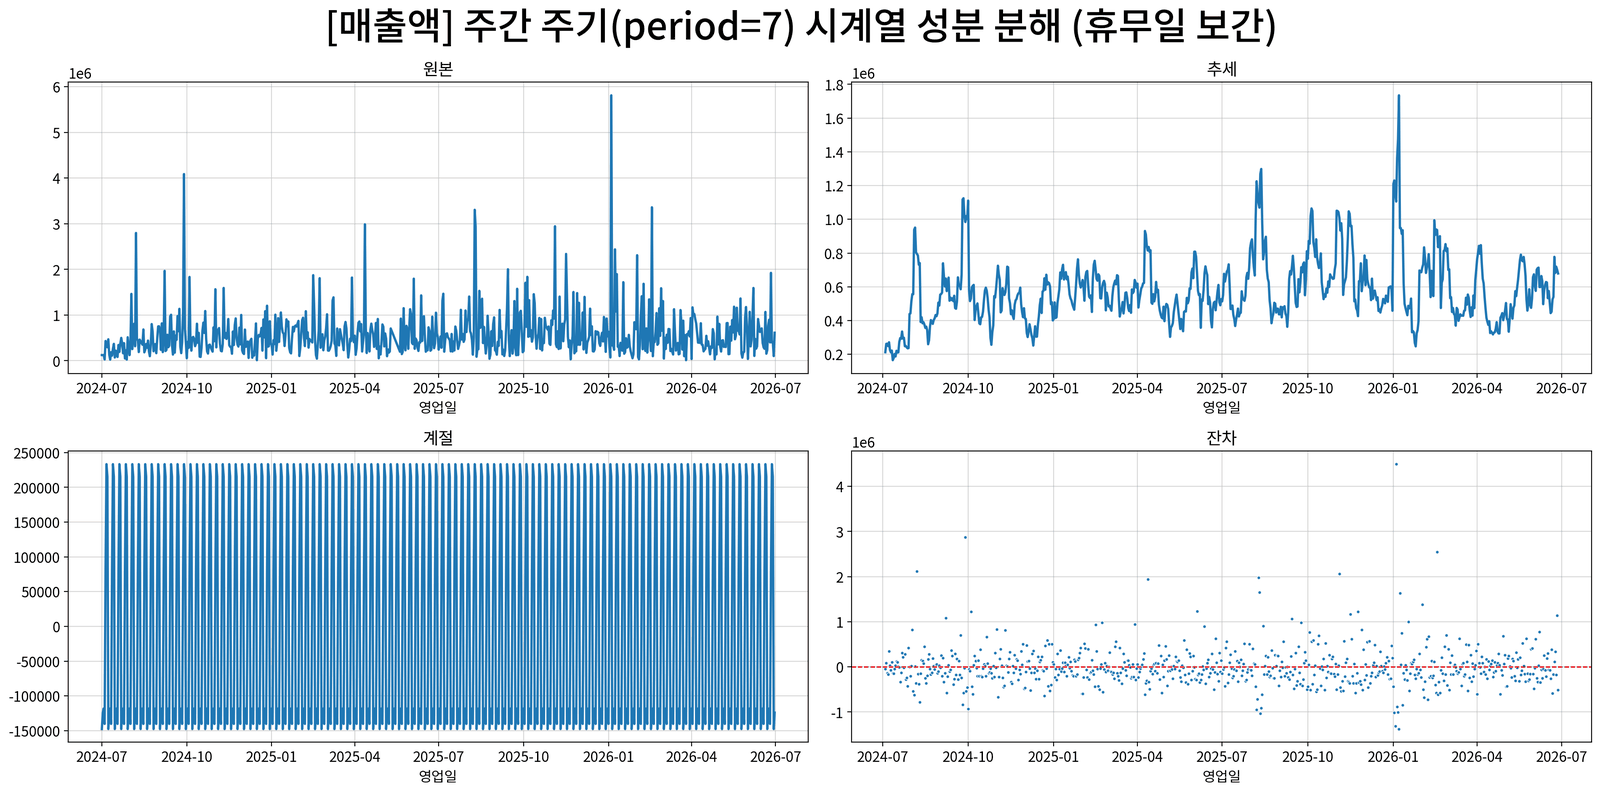

In [18]:
# 1. 휴무일(휴무여부 == 1)의 매출을 '정보 없음(NaN)'으로 두고, 앞뒤 영업일 값으로 선형 보간한 시계열을 만든다.
#    - 휴무일 0원이 그대로 들어가면 추세가 0 근처로 꺼지는 왜곡이 생긴다.
#    - 휴무일 행을 지우지 않고 보간하므로 달력 간격(7일 주기)은 그대로 유지된다.
df_decomp = df[["매출액"]].copy()
df_decomp.loc[df["휴무여부"] == 1, "매출액"] = np.nan
df_decomp["매출액"] = df_decomp["매출액"].interpolate(method="time", limit_direction="both")
#    (limit_direction="both": 첫날·마지막 날이 휴무여서 양 끝에 생긴 빈칸도 가장 가까운 영업일 값으로 채움)

# 보간 후 남은 결측 확인 (0이어야 분해 가능)
print(f"보간한 휴무일 {int((df['휴무여부'] == 1).sum())}일 / 남은 결측 {int(df_decomp['매출액'].isna().sum())}건")

# 2. 주간 주기성(period=7) 및 가법 모델(model='additive')을 지정하여 매출액 성분을 분해합니다.
decomp_df = my_ts.decompose(
    data=df_decomp,
    column='매출액',
    period=7,
    model='additive',
    plot=True,
    title="[매출액] 주간 주기(period=7) 시계열 성분 분해 (휴무일 보간)"
)

#### 5.1.1 시계열 성분 분해 결과 해석

730일(2024.07 ~ 2026.06) 매출액을 7일 주기(period=7)의 가법 모델로 분해한 결과입니다. 휴무일 22일은 매출을 비워 두고 앞뒤 영업일 값으로 보간했으며(남은 결측 0건), 분해 결과는 원본 = 추세 + 주기(계절) + 잔차로 읽습니다.

---

##### 1) 성분별 해석

* **원본**
  * 대부분의 날은 수십만 원대에서 움직이지만 가끔 **약 280만~580만 원까지 크게 튀는 날**이 있습니다. 튀는 날은 일정한 간격 없이 드문드문 나타납니다.
  * 이런 큰 값이 모델을 흔들지 않도록, 4.2에서 판정한 로그 변환이 필요하다는 점을 그래프로도 확인할 수 있습니다.

* **추세** (7일 이동평균에 가까운 흐름)
  * 개업 직후인 2024년 7월에는 약 20만~30만 원 수준이었고 이후 대체로 **40만~80만 원 사이**에서 오르내립니다.
  * 2024년 9~10월(약 110만 원), 2025년 8월(약 130만 원), 2026년 1월(약 175만 원)에 추세가 크게 솟는 구간이 있습니다. 이 그래프만으로는 원인을 알 수 없으며, 큰 매출이 있었던 날 몇 개가 7일 평균을 끌어올린 결과일 수 있습니다.
  * 휴무일을 보간했기 때문에 연속 휴무 기간에도 추세가 0 근처로 꺼지지 않고, 영업일의 흐름만 반영됩니다.

* **주기(계절) 성분, period=7**
  * 약 -15만 원 ~ +23만 원 폭의 7일 파형입니다. 가법 분해는 주기 성분을 매주 같은 모양으로 계산하므로, 그래프에서는 똑같은 파형이 반복됩니다.
  * 이 그래프만으로는 어느 요일이 높은지 알 수 없으므로, 요일별 차이는 5.4의 요일별 ANOVA에서 확인합니다. 다만 7일 주기가 뚜렷하므로 요일 정보와 주 단위 시차 정보를 모델에 넣을 필요가 있으며, 구체적인 시차는 5.2의 자기상관 진단으로 정합니다.

* **잔차**
  * 대부분 0 근처에 모여 있습니다.
  * **2026년 1월에 잔차가 약 +450만 원으로 크게 튀는 날**이 있습니다. 추세와 요일 주기로 설명되지 않는 하루로, 단체 예약 같은 일회성 사건이었을 가능성이 있지만 이 데이터로는 원인을 확인할 수 없습니다.

### 5.2 매출액 자기상관(ACF/PACF)과 리뷰조회수 → 매출액 그랜저 검정
* **분석 목적**: 매출액이 며칠 전 매출과 얼마나 닮았는지(ACF/PACF)를 보고, ADF 검정(`my_ts.adf_test`)으로 정상성을 확인한 뒤, 전날까지의 `리뷰조회수`($X$)가 `매출액`($Y$) 예측에 도움이 되는지 그랜저 검정(`my_ts.granger_test`)으로 확인합니다.

관측치 708개 | 유의성 기준값 0.075 | 최대 시차 21 (상한 N/4=177)
AR 차수 후보 (p): 0   ← PACF가 lag 1부터 비유의
MA 차수 후보 (q): 0   ← ACF가 lag 1부터 비유의
계절 AR 차수 후보 (P): 1   ← 계절 PACF가 lag 7 이후 절단 (판정 시차 [7, 14, 21])
계절 MA 차수 후보 (Q): 3   ← 계절 ACF가 lag 21 이후 절단 (판정 시차 [7, 14, 21])
→ SARIMA(0, d, 0)(1, D, 3)[7] — d·D 는 차분 단계의 결과를 넣는다


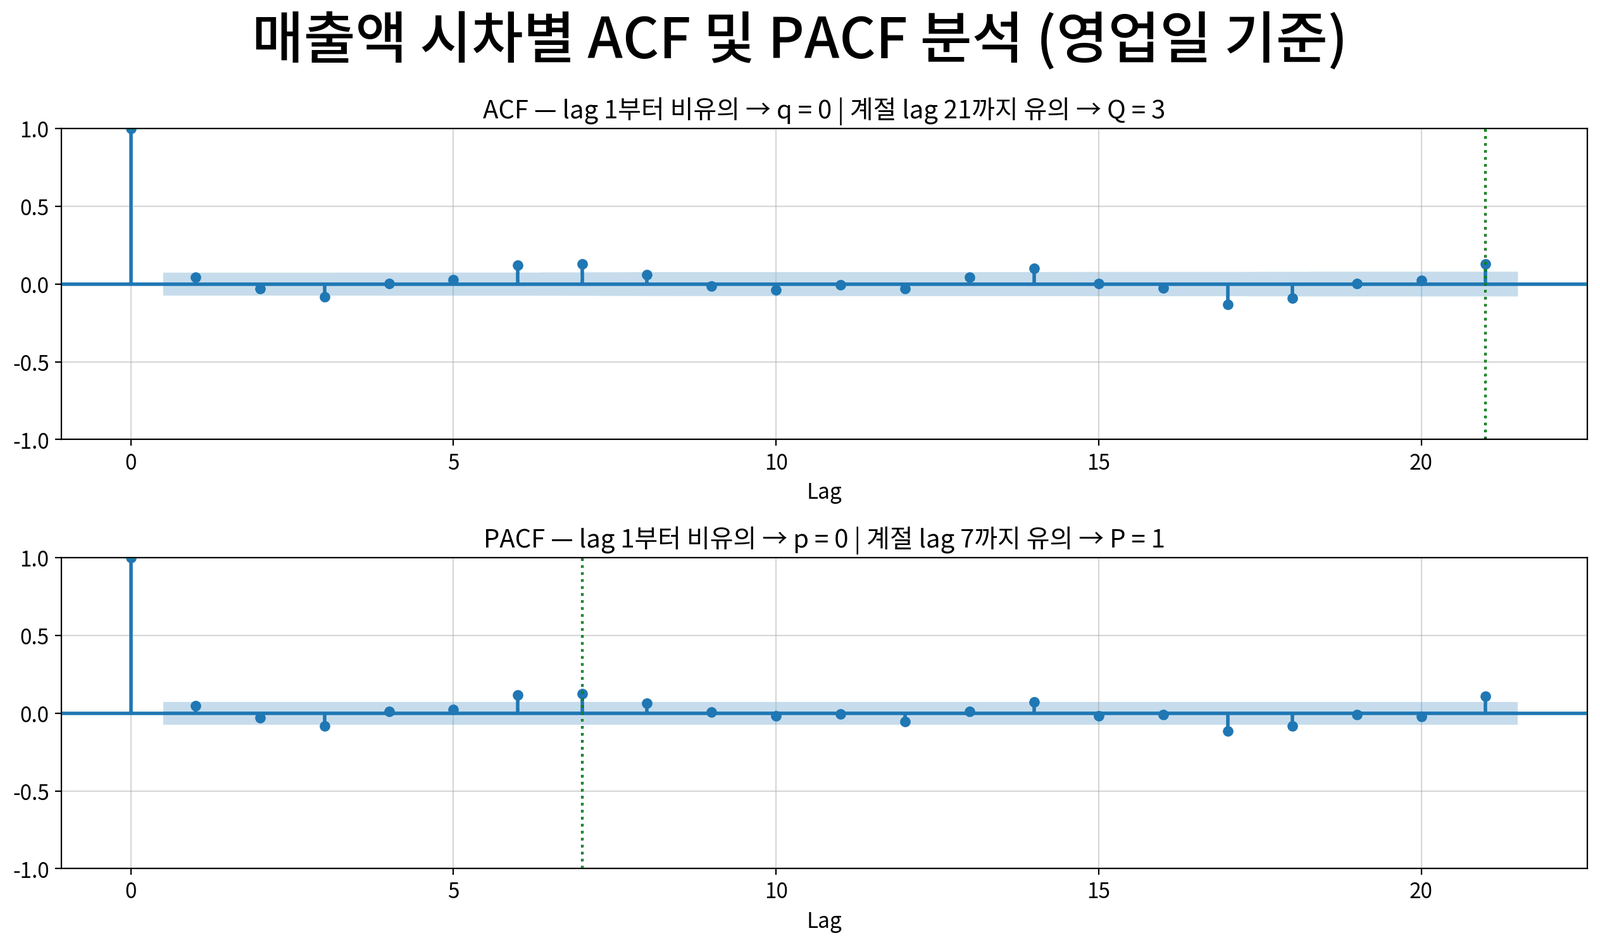

,acf,acf 유의성,pacf,pacf 유의성,기준값,p,q,P,Q
lag,,,,,,,,,
1,0.046,False,0.046,False,0.075,,,,
2,-0.028,False,-0.030,False,0.075,,,,
3,-0.083,True,-0.081,True,0.075,,,,
4,0.004,False,0.011,False,0.075,,,,
5,0.028,False,0.023,False,0.075,,,,
6,0.123,True,0.116,True,0.075,,,,
7,0.130,True,0.126,True,0.075,,,◀,
8,0.061,False,0.065,False,0.075,,,,
9,-0.015,False,0.007,False,0.075,,,,


=== 사전 ADF 정상성 검정 결과 (영업일 기준) ===


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
매출액,708,-5.882,0.0000,20,-3.44,-2.866,-2.569,511448.432,True,정상
리뷰조회수,708,-4.340,0.0004,6,-3.44,-2.866,-2.569,53.667,True,정상


정상 시계열 확인 -> 영업일 기준 원본 수준 진단

■ 리뷰조회수 → 매출액

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.1187  , p=0.0428  , df_denom=704, df_num=1
ssr based chi2 test:   chi2=4.1362  , p=0.0420  , df=1
likelihood ratio test: chi2=4.1242  , p=0.0423  , df=1
parameter F test:         F=4.1187  , p=0.0428  , df_denom=704, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.1111  , p=0.1219  , df_denom=701, df_num=2
ssr based chi2 test:   chi2=4.2523  , p=0.1193  , df=2
likelihood ratio test: chi2=4.2395  , p=0.1201  , df=2
parameter F test:         F=2.1111  , p=0.1219  , df_denom=701, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4003  , p=0.2415  , df_denom=698, df_num=3
ssr based chi2 test:   chi2=4.2429  , p=0.2364  , df=3
likelihood ratio test: chi2=4.2302  , p=0.2377  , df=3
parameter F test:         F=1.4003  , p=0.2415  , df_denom=698, df_num=3

Granger Causality
number of lags (no zero) 4
ssr 

관측치 수  F 통계량  p-value     인과     판정       권장
독립변수  시차                                              
리뷰조회수 1     708  4.119   0.0428   True  인과 있음  ★ 권장 시차
      2     708  2.111   0.1219  False  인과 없음         
      3     708  1.400   0.2415  False  인과 없음         
      4     708  1.145   0.3342  False  인과 없음         
      5     708  0.978   0.4300  False  인과 없음         
      6     708  0.780   0.5857  False  인과 없음         
      7     708  0.467   0.8584  False  인과 없음

In [19]:
# 0. 5.2 진단은 휴무일을 제외한 영업일 시계열로 수행한다 (진단용 복사본 df_open).
#    원본 df 는 5.3에서 달력(730일) 기준으로 시차 변수를 만들기 위해 휴무일을 포함한 채 유지한다.
df_open = df[df["휴무여부"] == 0].copy()

# ==========================================
# 1. 영업일 기준 매출액 자체 자기상관 및 부분자기상관(ACF/PACF) 분석
# ==========================================
acf_pacf_df = my_ts.auto_correlation(
    data=df_open,
    column="매출액",
    period=7,
    plot=True,
    title="매출액 시차별 ACF 및 PACF 분석 (영업일 기준)",
)
display(acf_pacf_df)

# ==========================================
# 2. 리뷰조회수(X)와 매출액(Y) 간 Granger 인과성 검정 파이프라인
# ==========================================
# 2-1) 사전 ADF 정상성 검정 (my_ts.adf_test 활용)
adf_sales = my_ts.adf_test(data=df_open, column="매출액")
adf_review = my_ts.adf_test(data=df_open, column="리뷰조회수")
adf_summary = pd.concat([adf_sales, adf_review])
print("=== 사전 ADF 정상성 검정 결과 (영업일 기준) ===")
display(adf_summary)

# 2-2) 정상성 판정에 따른 조건부 차분 (p-value >= 0.05인 비정상 시계열 존재 시 차분 적용)
if (adf_summary["p-value"] >= 0.05).any():
    print("비정상 시계열 검출 -> 진단용 1차 차분 적용")
    df_granger_input = df_open[["매출액", "리뷰조회수"]].diff().dropna()
else:
    print("정상 시계열 확인 -> 영업일 기준 원본 수준 진단")
    df_granger_input = df_open[["매출액", "리뷰조회수"]].dropna()

# 2-3) 정제된 영업일 시계열 상에서 Granger 인과성 검정 수행 (maxlag=7)
granger_res = my_ts.granger_test(
    data=df_granger_input, y="매출액", x="리뷰조회수", maxlag=7
)
display(granger_res)

#### 5.2.1 자기상관(ACF/PACF)·정상성·그랜저 검정 결과 해석

영업일 708일의 매출액과 리뷰조회수에 대해 시차별 자기상관(ACF), 부분자기상관(PACF), ADF 정상성 검정, 그랜저 인과성 검정을 수행한 결과입니다. (확인 시차 1~21, 유의 기준선 0.075)

---

##### 1) 매출액의 시차별 자기상관

유의한 시차는 **양(+)의 7일 주기 신호(6, 7, 14, 21)**와 **음(−)의 신호(3, 17, 18)**로 나뉘며, 시차 1은 유의하지 않습니다.

* **시차 1 (바로 전 영업일)**
  * ACF 0.046, PACF 0.046으로 기준선(0.075)보다 작아 유의하지 않습니다.
  * 오늘 매출은 어제 매출보다 일주일 단위의 반복 패턴과 더 관련이 있다는 뜻입니다.

* **시차 6·7 (약 일주일 전, 양의 상관)**
  * 시차 6(ACF 0.123, PACF 0.116)과 시차 7(ACF 0.130, PACF 0.126) 모두 기준선을 넘어 유의합니다.
  * 7일 주기의 반복이 통계적으로 확인되었으며 지난주 같은 요일의 매출이 오늘 매출을 가늠하는 단서가 될 수 있습니다.

* **시차 14·21 (2~3주 전, 양의 상관)**
  * 시차 14는 ACF(0.101)만 유의하고 PACF(0.072)는 유의하지 않으며 시차 21은 ACF(0.130)와 PACF(0.114) 모두 유의합니다.
  * 같은 요일 간의 비슷함이 2~3주 전까지 이어진다는 뜻이며, 같은 요일 최근 4회 평균(`dow_ma4`)을 만드는 근거가 됩니다.

* **시차 3·17·18 (음의 상관)**
  * 시차 3(ACF −0.083, PACF −0.081), 시차 17(ACF −0.130, PACF −0.116), 시차 18(ACF −0.089, PACF −0.086)이 기준선을 넘습니다. 단, 시차 3은 기준선을 겨우 넘는 수준(|0.083| vs 0.075)입니다.
  * 7일 파동의 골(3.5, 10.5, 17.5일 부근)에 해당하는 구간으로, 시차 7·14·21의 양의 신호와 짝을 이루는 같은 주간 패턴의 다른 면으로 볼 수 있습니다.
  * **이 시차로는 변수를 따로 만들지 않습니다.**
    ① 크기가 작습니다(시차 3의 |ACF| 0.083은 설명력으로 약 0.7%).
    ② 21개 시차를 한꺼번에 검정했으므로 우연히 유의하게 나온 시차(5% 수준에서 1개 안팎)가 섞일 수 있습니다.
    ③ 같은 골 구간인 시차 10(ACF −0.036)은 유의하지 않아, 음의 신호가 일관되게 나타나지 않습니다.
    ④ 시차 3·17·18은 영업상 이유를 설명하기 어렵지만 시차 7·14·21은 "같은 요일"이라는 분명한 이유가 있습니다.
    ⑤ 요일 패턴은 `lag7_매출`과 `dow_ma4`가 이미 반영합니다.

---

##### 2) 정상성 검정과 그랜저 인과성 검정

* **ADF 정상성 검정**: `매출액`(ADF = -5.882, $p < 0.001$)과 `리뷰조회수`(ADF = -4.340, $p = 0.0004$) 모두 유의수준 5%에서 "정상 시계열이 아니다"라는 귀무가설을 기각했습니다. 두 시계열 모두 **차분하지 않은 원래 수준에서 정상성을 만족**하므로 원 데이터로 그랜저 검정을 진행했습니다.
* **리뷰조회수 → 매출액 그랜저 검정**: 시차 1~7 중 **시차 1에서만** F = 4.119, $p = 0.0428$로 유의했습니다. (시차 2~7은 모두 $p > 0.05$)
* **해석**: 전날 리뷰조회수와 오늘 매출 사이에는 예측에 약간 도움이 되는 선형 관계가 있습니다. 그랜저 인과성은 "먼저 움직인 변수가 예측에 도움이 된다"는 의미일 뿐, 리뷰조회수가 매출을 올린다는 실제 인과관계를 뜻하지는 않습니다. 이 결과를 근거로 `lag1_리뷰조회수`를 후보 변수로 만듭니다.

---

##### 3) 파생변수 설계로 연결

* **만들 시계열 파생변수**:
  1. `lag1_매출`: 전 영업일 매출 (시차 1은 유의하지 않지만, 가장 기본적인 시차 변수로 후보에 둠)
  2. `lag7_매출`: 지난주 같은 요일(달력 7일 전) 매출 (시차 7의 ACF·PACF 유의)
  3. `ma7_매출`: 직전 7일 중 영업일 매출 평균 (튀는 날의 영향을 줄인 최근 매출 수준. 7일을 평균하면 주 안의 높고 낮은 날이 상쇄됨)
  4. `dow_ma4`: 같은 요일 최근 4회 평균 (시차 7·14·21의 반복 패턴)
  5. 리뷰조회수 시차 변수 (`lag1`, `lag2`, `lag7`, `ma7`): 그랜저 검정에서 시차 1이 유의($p = 0.0428$)했으므로 `lag1`을 중심으로, 나머지는 비교용 후보로 만듦
* **시차 3·17·18**: 위 1)의 이유로 별도 변수를 만들지 않고, 시차 7·14·21 기반 변수(`lag7_매출`, `dow_ma4`)만 둡니다.
* **미래 정보 차단**: 모든 시차·이동평균 변수는 `shift(1)` 이상을 먼저 적용한 뒤 계산해 예측하려는 당일의 실적이 입력에 섞이지 않게 합니다.

### 5.3 시계열 파생변수 구축 및 결측 일괄 정제
* **분석 목적**: 5.2의 진단 결과를 근거로 시차·이동평균 파생변수를 구축(`shift(1)` 기반 미래 정보 누수 차단)하고 연산 과정에서 발생한 상단 초기 결측(`NaN`) 행을 단 1회 일괄 정제합니다.

#### 생성 파생변수 명세 (5.2.1 결과 반영)

| 구분 | 변수명 | 정의 | 5.2 근거 |
| :--- | :--- | :--- | :--- |
| 매출 시차 | `lag1_매출` | 직전 영업일 매출 (휴무일은 건너뜀) | 시차 1 자체는 비유의하나 단기 연속성 보완용 기본 변수 |
| 매출 시차 | `lag7_매출` | 지난주 같은 요일(달력 7일 전) 매출. 그날이 휴무였으면 지지난주 같은 요일, 그것도 휴무였으면 `dow_ma4`로 채움 | 시차 7의 ACF·PACF 유의 |
| 매출 롤링 | `ma7_매출` | 직전 7일(달력) 중 영업일 매출 평균 (영업일 4일 이상일 때 계산) | 주기 내 양·음 구간을 상쇄한 단기 매출 수준 |
| 매출 롤링 | `dow_ma4` | 영업한 같은 요일 최근 4회 평균 (휴무 주는 건너뜀, 2회 이상일 때 계산) | 시차 7·14·21의 다중 주간 주기성 |
| 리뷰 시차 | `lag1_리뷰조회수` | 1일 전 리뷰조회수 | 그랜저 인과성 시차 1 유의 (p = 0.0428) |
| 리뷰 시차 | `lag2_리뷰조회수`, `lag7_리뷰조회수` | 2일·7일 전 리뷰조회수 | 그랜저 비유의이나 이변량 단계(5.4)에서 재검토할 후보 |
| 리뷰 롤링 | `ma7_리뷰조회수` | 직전 7일 평균 리뷰조회수 | 주간 누적 노출 효과 후보 |
| 유동인구 | `전일_승하차합계` | 전일 신대방역 승차+하차 합계 | 당일 값은 예측 시점에 알 수 없으므로 1일 시차 적용 |


* **계산 방식**: 모든 변수는 휴무일 행을 남겨 둔 달력(730일) 위에서, 휴무일 매출을 비워 둔(NaN) 상태로 계산합니다. 따라서 `lag7_매출`과 `dow_ma4`는 휴무가 끼어도 정확히 같은 요일을 가리키며, 평균 계산에서는 휴무일이 자동으로 빠집니다. 리뷰조회수와 유동인구 시차는 휴무일에도 값이 있으므로 달력상 "전날" 값을 사용합니다. 계산이 끝난 뒤 휴무일 행을 제거합니다.

In [20]:
# =========================================================================
# 0. 달력(730일) 기준 계산 준비
# =========================================================================
# 휴무일 행을 먼저 지우면 shift(7) 이 '7일 전'이 아니라 '7영업일 전'이 되어 요일이 어긋난다.
# 그래서 휴무일 행은 남겨 두고, 휴무일 매출만 '정보 없음(NaN)'으로 바꾼 뒤 변수를 계산한다.
# (0원으로 두면 '매출 0원'이라는 잘못된 정보가 시차·평균에 섞인다. 평균 계산은 NaN 을 자동으로 건너뛴다.)
sales_cal = df["매출액"].where(df["휴무여부"] == 0)

# =========================================================================
# 1. 매출액 시차/롤링 파생변수 생성 (shift(1) 이상 적용으로 미래 누수 차단)
# =========================================================================
# (1) 직전 영업일 매출: 휴무일 빈칸을 직전 영업일 값으로 채운 뒤 하루 밀기
df["lag1_매출"] = sales_cal.ffill().shift(1)

# (2) 같은 요일 최근 4회 평균: 휴무로 빈 주는 건너뛰고, 영업한 같은 요일이 2회 이상일 때 계산
df["dow_ma4"] = sales_cal.groupby(df["요일"], observed=True).transform(
    lambda s: s.shift(1).rolling(4, min_periods=2).mean()
)

# (3) 지난주 같은 요일 매출 (달력 7일 전)
#     지난주 같은 요일이 휴무였으면 지지난주(14일 전) 값, 그것도 휴무였으면 dow_ma4 로 채운다.
df["lag7_매출"] = sales_cal.shift(7).fillna(sales_cal.shift(14)).fillna(df["dow_ma4"])

# (4) 직전 7일(달력) 중 영업일 매출 평균 (영업일이 4일 이상일 때 계산)
df["ma7_매출"] = sales_cal.shift(1).rolling(7, min_periods=4).mean()

# 매출액 시차 파생변수 상위 15개 행 검증 출력
display(df[["매출액", "lag1_매출", "lag7_매출", "ma7_매출", "dow_ma4"]].head(15))

# 2. 외부 유동인구 전일 시차 변수 (달력 기준 전날)
# 전체 유동인구 규모 (Foot Traffic 체급)
df["승하차합계"] = df["승차총승객수"] + df["하차총승객수"]
df["전일_승하차합계"] = df["승하차합계"].shift(1)

# 3. 마케팅 리뷰조회수 시차/롤링 파생변수군 (달력 기준, 리뷰 조회는 휴무일에도 발생)
df["lag1_리뷰조회수"] = df["리뷰조회수"].shift(1)
df["lag2_리뷰조회수"] = df["리뷰조회수"].shift(2)
df["lag7_리뷰조회수"] = df["리뷰조회수"].shift(7)
df["ma7_리뷰조회수"] = (
    df["리뷰조회수"].shift(1).rolling(window=7).mean()
)

# 4. 변수 계산이 끝났으므로 휴무일 행을 제거 (휴무일은 예측 대상이 아님)
df = df[df["휴무여부"] == 0].copy()

# 컬럼별 결측 현황 (my_qtcheck.check_missing_values 활용)
missing_df = my_qtcheck.check_missing_values(df)
null_status = missing_df.loc[missing_df["Missing Count"] > 0, ["Missing Count"]].reset_index()
null_status.columns = ["컬럼명", "결측행수"]

print("=== 시차/롤링 파생변수 생성 후 컬럼별 결측치 발생 현황 ===")
display(null_status)

# 5. 파생변수 연산으로 발생한 상단 초기 결측 행 일괄 제거
df_dropped = df.dropna()
df_final = df_dropped.reset_index(drop=True)

# 인덱스 초기화로 사라지는 날짜를 별도로 보존 (6.3.2 기간별 성능 확인 등에 사용)
영업일_final = df_dropped.index.to_series().reset_index(drop=True)

print(
    f"[5.3 완료] 최종 분석 데이터 크기: {df_final.shape} (잔여 결측치: {df_final.isna().sum().sum()}건)"
)

,매출액,lag1_매출,lag7_매출,ma7_매출,dow_ma4
영업일,,,,,
2024-07-01,0.0,NaN,NaN,NaN,NaN
2024-07-02,0.0,NaN,NaN,NaN,NaN
2024-07-03,124000.0,NaN,NaN,NaN,NaN
2024-07-04,28000.0,124000.0,NaN,NaN,NaN
2024-07-05,432500.0,28000.0,NaN,NaN,NaN
2024-07-06,360000.0,432500.0,NaN,NaN,NaN
2024-07-07,294000.0,360000.0,NaN,236125.000000,NaN
2024-07-08,469500.0,294000.0,NaN,247700.000000,NaN
2024-07-09,132000.0,469500.0,NaN,284666.666667,NaN


=== 시차/롤링 파생변수 생성 후 컬럼별 결측치 발생 현황 ===


,컬럼명,결측행수
0,lag1_매출,1
1,dow_ma4,14
2,lag7_매출,7
3,ma7_매출,8
4,lag7_리뷰조회수,5
5,ma7_리뷰조회수,5


[5.3 완료] 최종 분석 데이터 크기: (690, 34) (잔여 결측치: 0건)


### 5.4 변수 탐색 및 역할 분리

* **목적**: 3가지 기준으로 변수를 걸러 회귀 예측용(묶음 A)과 군집 분석용(묶음 B)으로 나누고 분포·관련성·다중공선성(VIF)을 확인해 모델에 넣을 변수를 고릅니다.

---

#### 변수 역할 분리 기준

* **묶음 A (회귀 예측용 후보)**:
  * 매출을 예측하는 시점(전날)에 이미 알 수 있는 변수만 넣습니다.
  * 매출액 계산식에 들어가는 변수와 장사가 끝나야 알 수 있는 POS 변수는 모두 빼서 **답을 미리 보는 문제(데이터 누수)를 막습니다.**
* **묶음 B (군집 분석용)**:
  * 그날 장사가 끝난 뒤 POS에서 집계되는 **영업 방식 지표(주류비율, 메인비율, 피크집중도, 고유판매 메뉴수)**입니다.
  * 매출 예측에는 쓸 수 없지만 그날 어떤 손님이 어떻게 주문했는지를 보여 주므로 영업일 유형을 나누는 데 씁니다.

---

#### 기준 적용 결과

* **[묶음 A: 회귀 예측용 후보 (20개)]**
  * 매출 시차 (4개): `lag1_매출`, `lag7_매출`, `ma7_매출`, `dow_ma4`
  * 달력·영업 흐름 (6개): `요일`, `계절`, `연속영업일수`, `공휴일여부`, `공휴일전날여부`, `연휴여부`
  * 날씨 (3개): `일평균기온`, `총강수량(mm)`, `기상특보여부`
  * 유동인구 (1개): `전일_승하차합계`
  * 광고·리뷰 (6개): `광고_실시여부`, `광고_경과일수`, `lag1_리뷰조회수`, `lag2_리뷰조회수`, `lag7_리뷰조회수`, `ma7_리뷰조회수`
* **[묶음 B-1: 군집 입력 변수 (4개)]**: `주류비율`(수량 기준), `메인비율`(수량 기준), `피크집중도`, 팀당 메뉴 지표(`팀당_메뉴종류수`와 `팀당_주문수량` 중 영수증수와의 상관이 0에 가까운 쪽을 코드에서 선택)
  * `매출액`, `요일`, 날씨 같은 결과·외부 변수는 군집 입력에서 뺍니다. 넣으면 "매출이 높은 날"처럼 이미 아는 구분이 다시 나오기 때문입니다.
  * `고유판매 메뉴수`는 손님이 많을수록 늘어나 방문 규모를 대신하게 되므로, 영수증수로 나눈 팀당 지표로 바꿔 규모의 영향을 뺍니다.
  * 영수증 2건 이하인 날은 비율 변수가 0 또는 1로 극단화되므로 군집에서 빼고 '미분류'로 둡니다.
* **[묶음 B-2: 군집 해석용 변수 (3개)]**: `매출액`, `평균 객단가`, `영수증수` (군집에는 넣지 않고 유형별 실적 비교에만 사용)

In [21]:
# =========================================================================
# 5.4 EDA 기반 변수 탐색 및 역할 분리 (영업일 필터링 및 휴무일 22일 정제 검증)
# =========================================================================
# -------------------------------------------------------------------------
# 1. [묶음 B 전처리] 군집 분석용 POS 세부 비율 파생변수 생성
# -------------------------------------------------------------------------
total_qty = df_final["전체메뉴 판매건수"]

df_final["주류비율"] = (
    (df_final["전통주류 판매건수"] + df_final["일반주류 판매건수"])
    / total_qty
).fillna(0)

df_final["메인비율"] = (df_final["메인메뉴 판매건수"] / total_qty).fillna(0)

# 팀당 메뉴 지표 후보 2종: 방문 규모(영수증수)의 영향을 뺀 '한 팀의 주문 성향'
#   - 팀당_메뉴종류수 = 고유판매 메뉴수 ÷ 영수증수
#       메뉴 종류는 메뉴판 크기에서 멈추므로, 주문 성향이 같아도 손님이 많을수록 값이 작아질 수 있다.
#   - 팀당_주문수량   = 전체메뉴 판매건수 ÷ 영수증수
#       겹치는 메뉴도 모두 세므로 손님 수가 분자·분모에서 상쇄된다.
df_final["팀당_메뉴종류수"] = df_final["고유판매 메뉴수"] / df_final["영수증수"]
df_final["팀당_주문수량"] = total_qty / df_final["영수증수"]

# 영수증 2건 이하인 날은 비율 변수가 0·1로 극단화되므로 군집에서 제외한다 (미분류)
MIN_RECEIPTS = 3

# 방문 규모(영수증수)와의 상관이 0에 더 가까운 후보를 군집 입력으로 선택 (my_stats.multi_correlation)
size_check = my_stats.multi_correlation(
    df_final[df_final["영수증수"] >= MIN_RECEIPTS],
    columns=["팀당_메뉴종류수", "팀당_주문수량", "영수증수"], alpha=0.05, plot=False,
)
corr_with_size = {}
for (a, b), row in size_check.iterrows():
    if "영수증수" in (a, b):
        corr_with_size[b if a == "영수증수" else a] = row["coef"]
team_col = min(corr_with_size, key=lambda k: abs(corr_with_size[k]))
display(Markdown("##### 팀당 메뉴 지표 후보와 영수증수의 상관 (0에 가까울수록 방문 규모와 무관)"))
display(DataFrame({"영수증수와의 상관계수": corr_with_size}).round(3))
print(f"군집 입력으로 선택된 변수: {team_col}")

# -------------------------------------------------------------------------
# 2. [변수 역할 분리 정의 및 군집 전용 데이터셋(df_cluster_final) 생성]
# -------------------------------------------------------------------------
# [묶음 A: 회귀 예측용 독립변수 후보군 (선행/외생 변수 20개)]
feature_cols_reg = [
    "lag1_매출",
    "lag7_매출",
    "ma7_매출",
    "dow_ma4",
    "요일",
    "계절",
    "연속영업일수",
    "공휴일여부",
    "공휴일전날여부",
    "연휴여부",
    "일평균기온",
    "총강수량(mm)",
    "기상특보여부",
    "전일_승하차합계",
    "광고_실시여부",
    "광고_경과일수",
    "lag1_리뷰조회수",
    "lag2_리뷰조회수",
    "lag7_리뷰조회수",
    "ma7_리뷰조회수",
]

# [묶음 B-1: 군집 투입용 내생 변수 4개]
feature_cols_cluster = ["주류비율", "메인비율", "피크집중도", team_col]

# [묶음 B-2: 군집 실적 프로파일링/해석용 변수 3개]
feature_cols_perf = ["매출액", "평균 객단가", "영수증수"]

# 군집 전용 데이터셋(df_cluster_final)에 군집변수(4개) + 실적해석변수(3개) 함께 보존
df_cluster_all = df_final[feature_cols_cluster + feature_cols_perf].copy()          # 전체 영업일 (9장 캘린더용)
df_cluster_final = df_cluster_all[df_cluster_all["영수증수"] >= MIN_RECEIPTS].copy()  # 군집 대상 (영수증 3건 이상)
print(f"군집 대상 {len(df_cluster_final)}일 / 미분류(영수증 {MIN_RECEIPTS - 1}건 이하) {len(df_cluster_all) - len(df_cluster_final)}일")

# -------------------------------------------------------------------------
# 3. 변수 역할 분리 및 정제 결과 검증 출력
# -------------------------------------------------------------------------
display(
    Markdown(
        "##### [5.4] 변수 역할 분리 결과 요약\n"
        f"- **마스터 데이터셋 (`df_final`)**: `{df_final.shape[0]}행 {df_final.shape[1]}열` (회귀 분석 파이프라인용 전체 변수 유지)\n"
        f"- **군집 전용 데이터셋 (`df_cluster_final`)**: `{df_cluster_final.shape[0]}행 {df_cluster_final.shape[1]}열` (군집 4개 + 실적해석 3개, 영수증 3건 이상인 날)\n"
        f"- **묶음 A (회귀 예측용 후보군)**: 총 `{len(feature_cols_reg)}개` 변수\n"
        f"- **묶음 B-1 (군집 모델링 입력용)**: 총 `{len(feature_cols_cluster)}개` 변수\n"
        f"- **묶음 B-2 (군집 실적 프로파일링용)**: 총 `{len(feature_cols_perf)}개` 변수"
    )
)

,팀당_메뉴종류수,팀당_주문수량,영수증수
팀당_메뉴종류수,1.000,0.450,-0.464
팀당_주문수량,0.450,1.000,0.036
영수증수,-0.464,0.036,1.000


##### 팀당 메뉴 지표 후보와 영수증수의 상관 (0에 가까울수록 방문 규모와 무관)

,영수증수와의 상관계수
팀당_메뉴종류수,-0.464
팀당_주문수량,0.036


군집 입력으로 선택된 변수: 팀당_주문수량
군집 대상 610일 / 미분류(영수증 2건 이하) 80일


##### [5.4] 변수 역할 분리 결과 요약
- **마스터 데이터셋 (`df_final`)**: `690행 38열` (회귀 분석 파이프라인용 전체 변수 유지)
- **군집 전용 데이터셋 (`df_cluster_final`)**: `610행 7열` (군집 4개 + 실적해석 3개, 영수증 3건 이상인 날)
- **묶음 A (회귀 예측용 후보군)**: 총 `20개` 변수
- **묶음 B-1 (군집 모델링 입력용)**: 총 `4개` 변수
- **묶음 B-2 (군집 실적 프로파일링용)**: 총 `3개` 변수

#### 5.4.1 단변량 탐색

종속변수 `매출액`과 회귀 예측용 후보 변수(20개)의 분포(평균, 중앙값, 흩어진 정도, 왜도)와 이상치를 하나씩 확인합니다. 영업일 690일(휴무일과 시차 계산으로 생긴 초기 결측 행 제외) 기준입니다.

##### 1. 종속변수 단변량 분석: `매출액`

##### 종속변수 [매출액] 기술통계 요약표

,mean,std,50%,rel_diff,iqr,outliers,skew
매출액,588619.275362,514220.02129,455000.0,0.293669,464875.0,35,3.510972


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data, x=x, y=y, hue=hue, orient=orient, palette=palette,


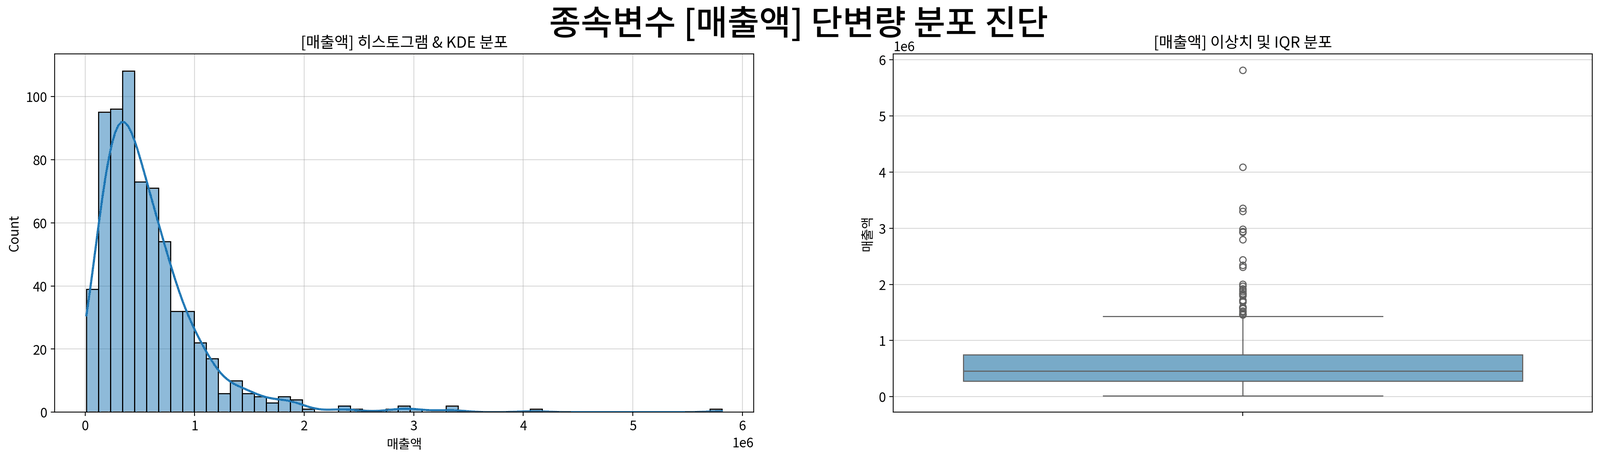

In [22]:
# 1. 종속변수 [매출액] 기술통계 요약표 출력 (my_qtcheck 활용)
display(Markdown("##### 종속변수 [매출액] 기술통계 요약표"))
target_stat_df = my_qtcheck.numerical_summary(df_final, columns=["매출액"])
display(
    target_stat_df[
        ["mean", "std", "50%", "rel_diff", "iqr", "outliers", "skew"]
    ]
)

# 2. 종속변수 시각화를 위한 캔버스 초기화 (가로 1280, 세로 600, 1행 2열 서브플롯)
fig, ax = my_plot.init(
    width=1280,
    height=600,
    rows=1,
    cols=2,
    title="종속변수 [매출액] 단변량 분포 진단",
)

# 3. 첫 번째 서브플롯: [매출액] 히스토그램 & 커널 밀도 추정 곡선 (KDE) 결합 그래프
my_plot.histplot(data=df_final, x="매출액", kde=True, palette="Blues", ax=ax[0])
ax[0].set_title("[매출액] 히스토그램 & KDE 분포")

# 4. 두 번째 서브플롯: [매출액] 이상치 및 IQR 분포 상자 그림 생성
my_plot.boxplot(data=df_final, y="매출액", palette="Blues", ax=ax[1])
ax[1].set_title("[매출액] 이상치 및 IQR 분포");

##### 분포와 이상치 확인

* **오른쪽으로 치우친 분포**
  * 히스토그램을 보면 대부분의 날이 낮은~중간 매출에 몰려 있고, 오른쪽 꼬리가 깁니다(왜도 3.51).
  * 큰 매출이 있는 날 때문에 평균(약 58.9만 원)이 중앙값(약 45.5만 원)보다 높습니다. 평소 수준을 말할 때는 중앙값과 IQR이 더 적절합니다.

---

* **이상치 35일**
  * 상한 경계($Q_3 + 1.5 \times \text{IQR}$)를 넘는 날이 35일 있습니다.
  * 최솟값·최댓값에 입력 오류로 볼 만한 값이 없으므로, 실제로 매출이 높았던 날로 보고 지우지 않습니다. 대신 모델에서는 로그 변환으로 영향을 줄입니다.

##### 2. 회귀 예측용 독립변수 (묶음 A - 20개) 단변량 분석 및 정제

##### [Part 1] 매출 시계열 파생변수 (4개) 기술통계 요약표

,mean,std,50%,min,max,iqr,outliers,skew
lag1_매출,587308.405797,514606.925128,453500.000000,12000.000000,5.813000e+06,473375.000000,35,3.509523
lag7_매출,584077.971014,512910.398880,452250.000000,12000.000000,5.813000e+06,476500.000000,34,3.534585
ma7_매출,585782.317115,191757.838655,552714.285714,177714.285714,1.734857e+06,211214.285714,28,1.252140
dow_ma4,578748.623188,301727.899813,513750.000000,73750.000000,2.010250e+06,338739.583333,30,1.479445


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)


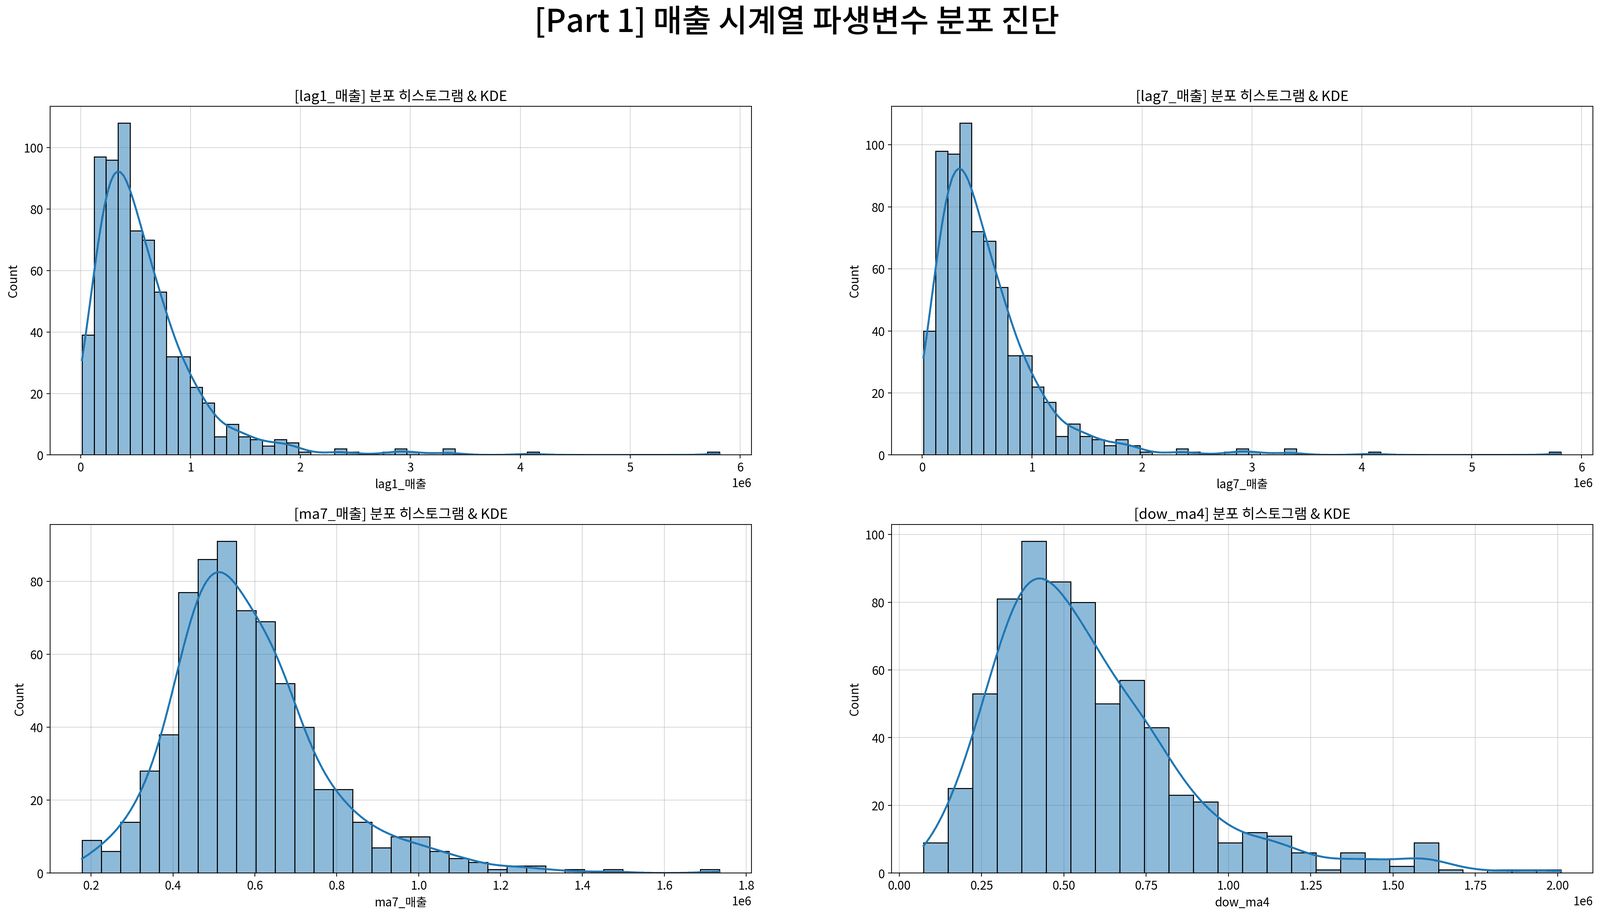

In [23]:
# =========================================================================
# [Part 1] 매출 시계열 파생변수군 (4개) 기술통계 및 시각화
# =========================================================================
vars_ts_sales = ["lag1_매출", "lag7_매출", "ma7_매출", "dow_ma4"]

# 1. 기술통계 요약표 출력
display(
    Markdown(
        "##### [Part 1] 매출 시계열 파생변수 (4개) 기술통계 요약표"
    )
)
display(
    my_qtcheck.numerical_summary(df_final, columns=vars_ts_sales)[
        ["mean", "std", "50%", "min", "max", "iqr", "outliers", "skew"]
    ]
)

# 2. 분포 시각화 (2행 2열)
fig, ax = my_plot.init(
    width=1400,
    height=700,
    rows=2,
    cols=2,
    title="[Part 1] 매출 시계열 파생변수 분포 진단",
)
for idx, var in enumerate(vars_ts_sales):
    my_plot.histplot(
        data=df_final, x=var, kde=True, palette="Blues", ax=ax[idx]
    )
    ax[idx].set_title(f"[{var}] 분포 히스토그램 & KDE")

##### 분포와 이상치 확인

* **하루짜리 시차 변수는 매출액처럼 치우쳐 있고 평균 변수는 덜 치우칩니다**
  * **`lag1_매출`, `lag7_매출`**: 왜도 3.51, 3.53으로 매출액과 거의 같게 오른쪽 꼬리가 깁니다. 평균(약 58.7만 원 / 58.4만 원)이 중앙값(약 45.4만 원 / 45.2만 원)보다 높습니다.
  * **`ma7_매출`, `dow_ma4`**: 여러 날을 평균했기 때문에 왜도가 1.25, 1.48로 낮아졌습니다. 하루짜리 큰 값의 영향이 줄어든 것입니다.

---

* **이상치와 흩어진 정도**
  * `lag1_매출`(35일), `lag7_매출`(34일)의 이상치는 매출액의 큰 값이 하루·일주일 밀려서 들어온 것이므로 지우지 않습니다.
  * `ma7_매출`은 표준편차 19.2만 원, IQR 21.1만 원으로 `lag1_매출`(표준편차 51.5만 원)보다 훨씬 덜 흩어져 있습니다. `dow_ma4`는 최솟값이 약 7.4만 원으로, 하루 값의 최솟값(1.2만 원)보다 높습니다. 같은 요일 여러 날의 평균이라 아주 낮은 값이 잘 나오지 않습니다.

##### [Part 2] 리뷰 시계열 파생변수 (4개) 기술통계 요약표

,mean,std,50%,min,max,iqr,outliers,skew
lag1_리뷰조회수,59.173913,55.418151,50.000000,0.0,531.000000,58.000000,22,2.716007
lag2_리뷰조회수,59.223188,55.569301,50.500000,0.0,531.000000,58.750000,22,2.697390
lag7_리뷰조회수,58.950725,55.589209,50.000000,0.0,531.000000,58.750000,22,2.702108
ma7_리뷰조회수,58.966046,41.362274,57.785714,0.0,217.571429,50.321429,12,0.595655


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)


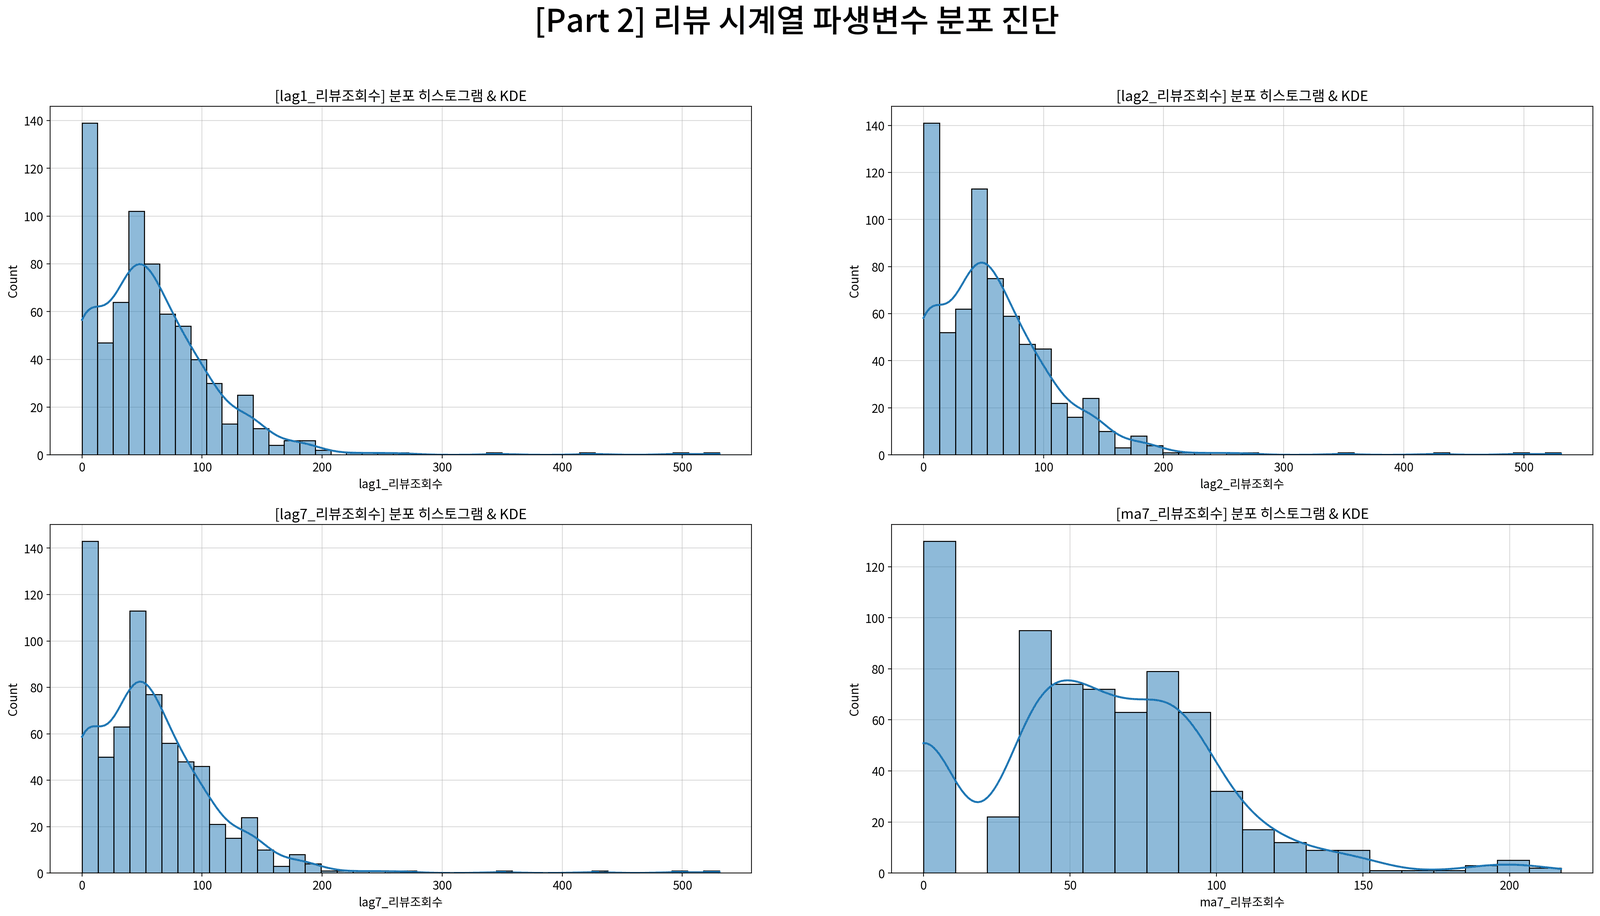

In [24]:
# =========================================================================
# [Part 2] 리뷰 시계열 파생변수군 (4개) 기술통계 및 시각화
# =========================================================================
vars_ts_review = [
    "lag1_리뷰조회수",
    "lag2_리뷰조회수",
    "lag7_리뷰조회수",
    "ma7_리뷰조회수",
]

# 1. 기술통계 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 2] 리뷰 시계열 파생변수 (4개) 기술통계 요약표"
    )
)
display(
    my_qtcheck.numerical_summary(df_final, columns=vars_ts_review)[
        ["mean", "std", "50%", "min", "max", "iqr", "outliers", "skew"]
    ]
)

# 2. 분포 시각화 (가로 1400, 세로 700, 2행 2열 서브플롯)
fig, ax = my_plot.init(
    width=1400,
    height=700,
    rows=2,
    cols=2,
    title="[Part 2] 리뷰 시계열 파생변수 분포 진단",
)

for idx, var in enumerate(vars_ts_review):
    my_plot.histplot(
        data=df_final, x=var, kde=True, palette="Purples", ax=ax[idx]
    )
    ax[idx].set_title(f"[{var}] 분포 히스토그램 & KDE")

##### 분포와 이상치 확인

* **시차 변수는 치우치고 7일 평균은 덜 치우칩니다**
  * **`lag1`, `lag2`, `lag7`**: 평균(약 59.0~59.2회)이 중앙값(50.0~50.5회)보다 높고 왜도가 2.70~2.72로, 조회수가 갑자기 뛰는 날이 있습니다. 광고 집행과의 관계는 5.4.4에서 확인합니다.
  * **`ma7_리뷰조회수`**: 7일 평균을 내니 왜도가 0.60으로 낮아졌습니다.

---

* **이상치**
  * `lag1`, `lag2`, `lag7`에는 상한을 넘는 날이 각 22일(최대 531회) 있고 `ma7_리뷰조회수`에서는 12일(최대 217.57회)로 줄어듭니다.
  * 입력 오류로 볼 근거가 없어 지우지 않습니다. 광고 글이 한꺼번에 많이 읽힌 날일 가능성이 있지만 이 데이터로 원인을 확인할 수는 없습니다. 모델에서는 로그 변환으로 큰 값의 영향을 줄입니다.

##### [Part 3] 기상 및 외부 환경 변수 (2개) 기술통계 요약표

,mean,std,50%,min,max,iqr,outliers,skew
일평균기온,14.031290,10.979372,14.85,-9.5,32.72,19.230,0,-0.204301
총강수량(mm),7.035507,29.019357,0.00,0.0,479.70,0.775,153,10.194622


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)


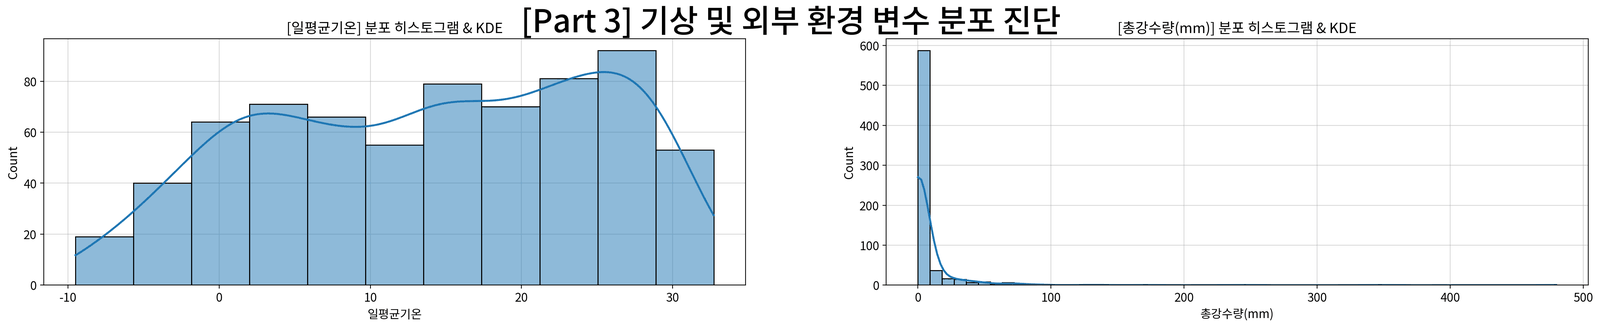

In [25]:
# =========================================================================
# [Part 3] 기상 및 외부 환경 변수군 (2개) 기술통계 및 시각화
# =========================================================================
vars_weather = ["일평균기온", "총강수량(mm)"]

# 1. 기술통계 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 3] 기상 및 외부 환경 변수 (2개) 기술통계 요약표"
    )
)
display(
    my_qtcheck.numerical_summary(df_final, columns=vars_weather)[
        ["mean", "std", "50%", "min", "max", "iqr", "outliers", "skew"]
    ]
)

# 2. 분포 시각화 (가로 1400, 세로 450, 1행 2열 서브플롯)
fig, ax = my_plot.init(
    width=1400,
    height=450,
    rows=1,
    cols=2,
    title="[Part 3] 기상 및 외부 환경 변수 분포 진단",
)

for idx, var in enumerate(vars_weather):
    my_plot.histplot(
        data=df_final, x=var, kde=True, palette="Greens", ax=ax[idx]
    )
    ax[idx].set_title(f"[{var}] 분포 히스토그램 & KDE")

##### 분포와 이상치 확인

* **기온은 대칭, 강수량은 대부분 0**
  * **`일평균기온`**: 평균(14.03℃)과 중앙값(14.85℃)이 비슷하고 왜도가 -0.20으로 거의 대칭입니다.
  * **`총강수량(mm)`**: 비가 오지 않은 날(0mm)이 대부분이라 중앙값이 0mm이고 왜도 10.19로 극단적으로 치우쳐 있습니다.

---

* **강수량 이상치 153일**
  * IQR 상한을 넘는 날이 153일(최대 479.70mm)입니다. 중앙값이 0이라 비가 조금만 와도 이상치로 잡히는 구조이며 실제 강수 기록이므로 지우지 않습니다.
  * 강수량은 0이 너무 많아 양(mm)보다 "비가 왔는지 여부"가 더 쓸모 있을 수 있습니다. 그래서 다음 셀에서 **`우천여부`(0/1) 변수를 만들어** 두 가지를 함께 비교하고 실제 매출과의 관련성은 5.4.2에서 확인합니다.

In [26]:
# =========================================================================
# 기상 파생변수 생성: 강수량 이진변수(우천여부)
# =========================================================================

# 1. 강수량(mm) 기준 이진 파생변수 생성 및 범주형(category) 타입 변환
df_final["우천여부"] = (
    (df_final["총강수량(mm)"] > 0).astype(int).astype("category")
)

# 2. 생성된 [우천여부] 빈도 및 비율 검증 (my_qtcheck 활용)
display(Markdown("##### 파생변수 [우천여부] 빈도 및 비율 요약"))
display(my_qtcheck.categorical_summary(df_final, columns=["우천여부"]))

##### 파생변수 [우천여부] 빈도 및 비율 요약

📊 컬럼 '우천여부'의 value_counts():


,count
우천여부,
0,474
1,216


,우천여부
count,690
unique,2
top,0
freq,474


##### `우천여부` 빈도 확인

* **분포**: 영업일 690일 중 비가 오지 않은 날(0) 474일(약 68.7%), 비가 온 날(1) **216일(약 31.3%)**입니다.
* **의미**: 0이 대부분이던 강수량을 "비가 왔는가"로 바꾸니 두 집단이 적당한 크기로 나뉘었습니다. 비 온 날이 216일이나 되므로 비 온 날과 안 온 날의 매출을 비교하기에 충분합니다.

##### [Part 4] 영업 및 외부 유동성 변수 (3개) 기술통계 요약표

,mean,std,50%,min,max,iqr,outliers,skew
연속영업일수,51.308696,43.287932,39.0,1.0,181.0,57.75,20,1.098042
전일_승하차합계,47735.755072,8851.510461,52060.5,19657.0,64084.0,12570.00,7,-1.054241
광고_경과일수,16.594203,37.777370,0.0,0.0,153.0,0.00,149,2.243774


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)
C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:321: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.histplot(data=data, x=x, hue=hue, linewidth=linewidth, palette=palette, kde=kde, bins=bins, ax=ax, **params)


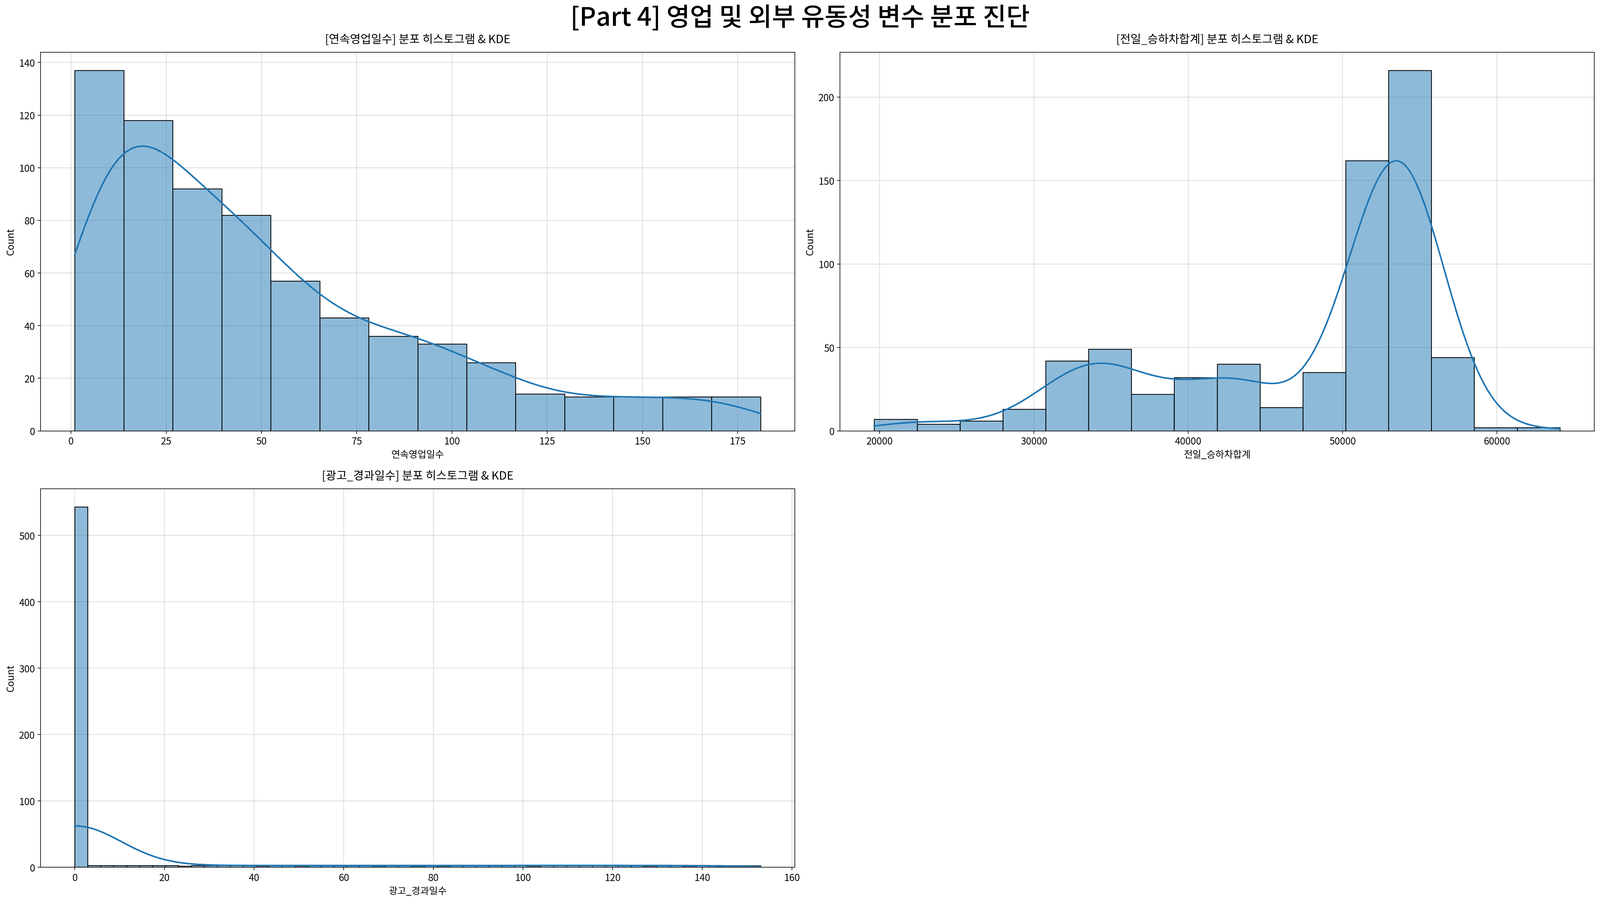

In [27]:
# =========================================================================
# [Part 4] 영업 및 외부 유동성 변수군 (3개) 기술통계 및 시각화
# =========================================================================
vars_ops = ["연속영업일수", "전일_승하차합계", "광고_경과일수"]

# 1. 기술통계 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 4] 영업 및 외부 유동성 변수 (3개) 기술통계 요약표"
    )
)
display(
    my_qtcheck.numerical_summary(df_final, columns=vars_ops)[
        ["mean", "std", "50%", "min", "max", "iqr", "outliers", "skew"]
    ]
)

# 2. 분포 시각화 (2행 2열 구조 유지)
fig, ax = my_plot.init(
    width=1400,
    height=800,
    rows=2,
    cols=2,
    title="[Part 4] 영업 및 외부 유동성 변수 분포 진단",
)

axes = ax   # my_plot.init 은 여러 칸일 때 이미 1차원 배열로 펼쳐서 반환한다

for idx, var in enumerate(vars_ops):
    my_plot.histplot(
        data=df_final, x=var, kde=True, palette="Oranges", ax=axes[idx]
    )
    axes[idx].set_title(f"[{var}] 분포 히스토그램 & KDE", pad=12)

# 변수 개수가 서브플롯 칸수보다 적으므로, 남는 마지막 빈 슬롯(인덱스 3)은 숨김 처리
if len(axes) > len(vars_ops):
    axes[-1].set_visible(False)

# 메인 타이틀 및 행/열 간격 보정
fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)

my_plot.show()

##### 분포와 이상치 확인

* **`연속영업일수`**: 평균(51.3일)이 중앙값(39일)보다 크고 왜도 1.10으로, 쉬지 않고 오래 영업한 기간이 오른쪽 꼬리를 만듭니다.
* **`전일_승하차합계`**: 왜도 -1.05이며 히스토그램에서 봉우리가 두 개 보입니다. 평일과 주말(또는 휴일)의 유동인구 차이 때문으로 보입니다.
* **`광고_경과일수`**: 광고 전과 광고 기간에는 모두 0이라 약 540일이 0에 몰려 있고 왜도 2.24로 크게 치우쳐 있습니다.

---

##### 이상치 처리

* **`연속영업일수` (20일)**: 쉬는 날 없이 오래 영업한 실제 기록이므로 유지합니다.
* **`전일_승하차합계` (7일), `광고_경과일수` (149일)**: 실제 기록이므로 유지합니다. `광고_경과일수`는 0이 대부분이라 광고 종료 후의 모든 날이 이상치로 잡힌 것입니다. 매출과의 관련성과 다중공선성은 5.4.2에서 확인합니다.

##### [Part 5] 시간 및 계절 주기 변수 (2개) 빈도 요약표

📊 컬럼 '요일'의 value_counts():


,count
요일,
Friday,100
Monday,93
Saturday,101
Sunday,100
Thursday,100
Tuesday,97
Wednesday,99


📊 컬럼 '계절'의 value_counts():


,count
계절,
가을,181
겨울,178
봄,167
여름,164


,요일,계절
count,690,690
unique,7,4
top,Saturday,가을
freq,101,181


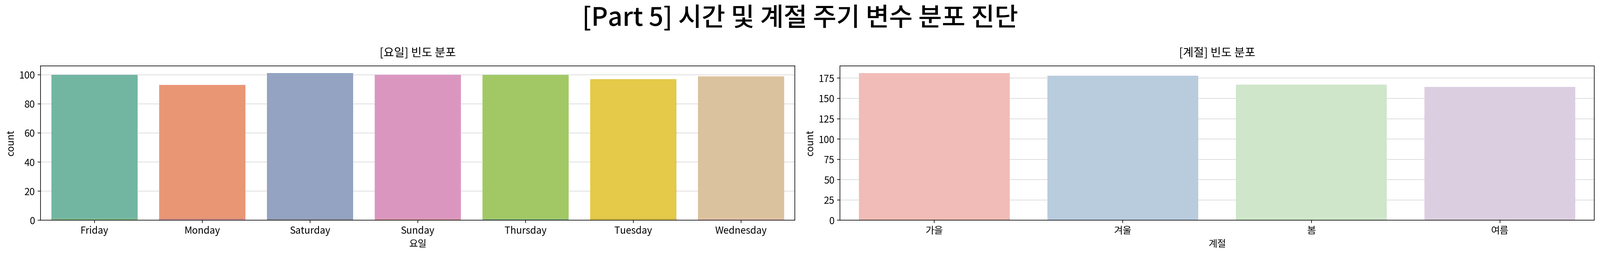

In [28]:
# =========================================================================
# [Part 5] 시간 및 계절 주기 변수군 (2개) 기술통계 및 시각화
# =========================================================================
vars_cat_part5 = ["요일", "계절"]

# 1. 범주형 기술통계 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 5] 시간 및 계절 주기 변수 (2개) 빈도 요약표"
    )
)
display(my_qtcheck.categorical_summary(df_final, columns=vars_cat_part5))

# 2. 빈도 분포 시각화 (1행 2열)
fig, ax = my_plot.init(
    width=1400,
    height=450,
    rows=1,
    cols=2,
    title="[Part 5] 시간 및 계절 주기 변수 분포 진단",
)

for idx, var in enumerate(vars_cat_part5):
    my_plot.countplot(
        data=df_final, x=var, palette="Set2" if idx == 0 else "Pastel1", ax=ax[idx]
    )
    ax[idx].set_title(f"[{var}] 빈도 분포", pad=12)

fig.subplots_adjust(top=0.82)
my_plot.show()

##### 빈도 확인

* **`요일`**: 영업일 690일 중 금 100일, 월 93일, 토 101일, 일 100일, 목 100일, 화 97일, 수 99일로 고르게 분포합니다. (월요일이 조금 적은 것은 휴무일이 월요일에 가장 많았기 때문으로 보입니다.)
* **`계절`**: 가을 181일, 겨울 178일, 봄 167일, 여름 164일로 큰 쏠림은 없습니다.

---

##### 모델 투입 방식

* 요일과 계절은 범주형이라 모델에 넣을 때 더미 변수(0/1)로 바꿉니다. 이때 한 범주를 기준으로 빼야 하며 기준 범주는 5.4.2의 사후검정 결과를 보고 정합니다.
* 범주마다 표본이 충분해(최소 93일) 어느 범주를 기준으로 삼아도 비교가 불안정해지지 않습니다.

##### [Part 6] 휴일 및 연휴 이벤트 변수 (3개) 기술통계 및 빈도 요약

📊 컬럼 '공휴일여부'의 빈도수 및 비율:


,count,ratio
공휴일여부,,
0,655,0.949275
1,35,0.050725


📊 컬럼 '공휴일전날여부'의 빈도수 및 비율:


,count,ratio
공휴일전날여부,,
0,655,0.949275
1,35,0.050725


📊 컬럼 '연휴여부'의 빈도수 및 비율:


,count,ratio
연휴여부,,
0,667,0.966667
1,23,0.033333


,공휴일여부,공휴일전날여부,연휴여부
count,690,690,690
unique,2,2,2
top,0,0,0
freq,655,655,667


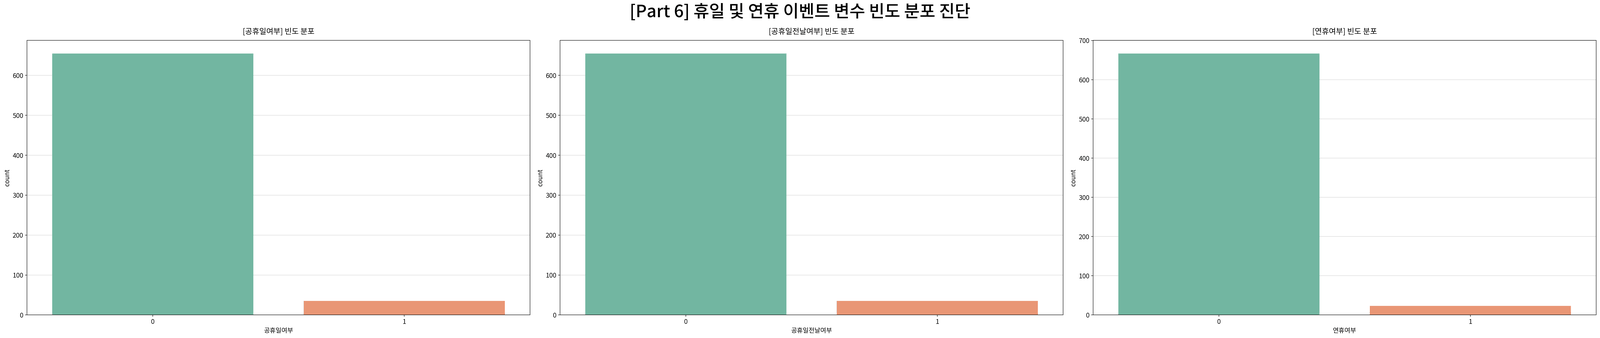

In [29]:
# =========================================================================
# [Part 6] 휴일 및 연휴 이벤트 변수군 (3개) 기술통계 및 빈도 분포 진단
# =========================================================================
vars_holiday = ["공휴일여부", "공휴일전날여부", "연휴여부"]

# 1. 기술통계 및 빈도/비율(ratio) 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 6] 휴일 및 연휴 이벤트 변수 (3개) 기술통계 및 빈도 요약"
    )
)
display(my_qtcheck.categorical_summary2(df_final, columns=vars_holiday))

# 2. 빈도 분포 시각화 (가로 1400, 세로 450, 1행 3열 서브플롯)
fig, ax = my_plot.init(
    width=1400,
    height=900,
    rows=1,
    cols=3,
    title="[Part 6] 휴일 및 연휴 이벤트 변수 빈도 분포 진단",
)

axes = ax   # my_plot.init 은 여러 칸일 때 이미 1차원 배열로 펼쳐서 반환한다

for idx, var in enumerate(vars_holiday):
    my_plot.countplot(
        data=df_final,
        x=var,
        hue=var,
        palette="Set2",
        ax=axes[idx],
    )
    axes[idx].set_title(f"[{var}] 빈도 분포", pad=12)

# 메인 타이틀 및 서브플롯 간격 보정
fig.subplots_adjust(top=0.82, wspace=0.25)

my_plot.show()

##### 빈도 확인

* **`공휴일여부`**: 일반 영업일(0) 655일(약 94.9%), 공휴일(1) **35일(약 5.1%)**입니다.
* **`공휴일전날여부`**: 일반 영업일(0) 655일(약 94.9%), 공휴일 전날(1) **35일(약 5.1%)**입니다.
* **`연휴여부`**: 비연휴(0) 667일(약 96.7%), 연휴(1) **23일(약 3.3%)**로 셋 중 가장 드뭅니다.

---

##### 모델 투입 방식

* 세 변수 모두 발생일이 3~5%로 적지만 주점은 휴일 전후로 손님이 달라질 수 있어 후보로 둡니다. 실제 매출 차이는 5.4.2의 ANOVA에서 확인합니다.
* 발생일이 적으면 효과를 추정하기 어려우므로, 결과를 해석할 때는 표본 수(35일, 23일)를 함께 봅니다.

##### [Part 7] 외부 환경 및 마케팅 이벤트 변수 (2개) 빈도 요약표

📊 컬럼 '기상특보여부'의 빈도수 및 비율:


,count,ratio
기상특보여부,,
0.0,566,0.82029
1.0,124,0.17971


📊 컬럼 '광고_실시여부'의 빈도수 및 비율:


,count,ratio
광고_실시여부,,
1,414,0.6
0,276,0.4


,기상특보여부,광고_실시여부
count,690.0,690
unique,2.0,2
top,0.0,1
freq,566.0,414


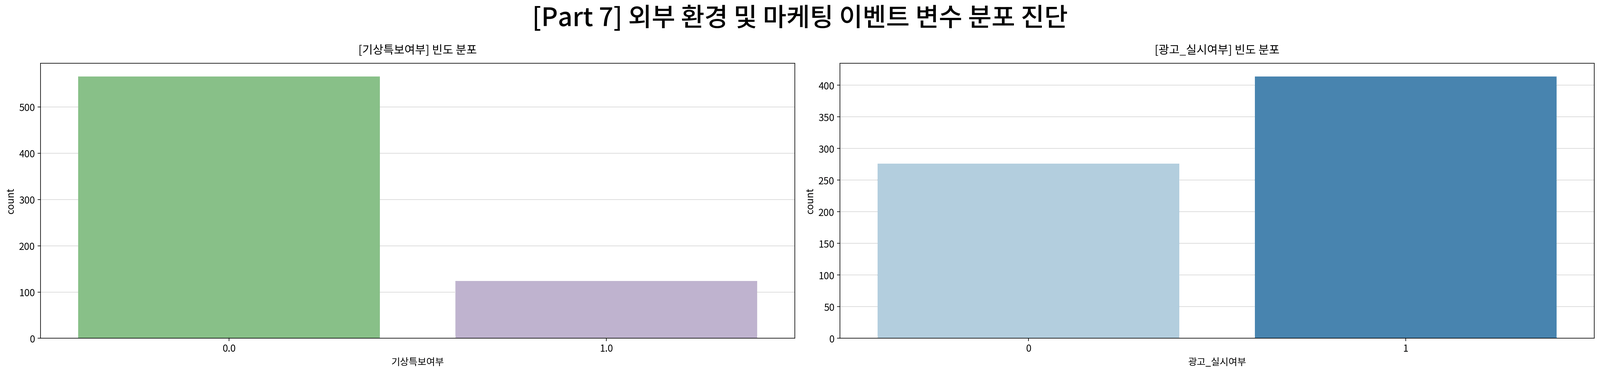

In [30]:
# =========================================================================
# [Part 7] 외부 환경 및 마케팅 이벤트 변수군 (2개) 기술통계 및 시각화
# =========================================================================
vars_cat_part7 = ["기상특보여부", "광고_실시여부"]

# 1. 범주형 기술통계 요약표 출력 (my_qtcheck 활용)
display(
    Markdown(
        "##### [Part 7] 외부 환경 및 마케팅 이벤트 변수 (2개) 빈도 요약표"
    )
)
display(my_qtcheck.categorical_summary2(df_final, columns=vars_cat_part7))

# 2. 빈도 분포 시각화 (가로 1400, 세로 600, 1행 2열 서브플롯)
fig, ax = my_plot.init(
    width=1400,
    height=660,
    rows=1,
    cols=2,
    title="[Part 7] 외부 환경 및 마케팅 이벤트 변수 분포 진단",
)

for idx, var in enumerate(vars_cat_part7):
    my_plot.countplot(
        data=df_final,
        x=var,
        palette="Accent" if idx == 0 else "Blues",
        ax=ax[idx],
    )
    ax[idx].set_title(f"[{var}] 빈도 분포", pad=12)

fig.subplots_adjust(top=0.82)
my_plot.show()

##### 빈도 확인

* **`기상특보여부`**: 영업일 690일 중 특보 없음(0) 566일(약 82.0%), 폭염·한파 특보(1) **124일(약 18.0%)**입니다.
* **`광고_실시여부`**: 광고 없음(0) 276일(40.0%), 광고 집행(1) **414일(60.0%)**로 광고 기간이 더 깁니다.

---

##### 모델 투입 방식

* 두 변수 모두 0/1 변수라 그대로 넣을 수 있습니다. 특보일에는 매출이 줄고 광고일에는 늘 것이라고 예상해 볼 수 있지만 실제 차이는 5.4.2의 ANOVA에서 확인합니다.
* `광고_실시여부`는 `광고_경과일수`, 리뷰조회수 시차 변수와 서로 얽혀 있으므로, 세 변수의 관계는 5.4.4에서 따로 살펴봅니다.

#### 5.4.2 이변량 탐색

`매출액`과 각 후보 변수의 관계(상관계수, 집단 간 평균 차이)를 확인하고 후보 변수끼리 너무 비슷해 서로 겹치는지(다중공선성)도 함께 봅니다. 세 부분으로 나눠 진행합니다.

* **[Part 1]** 수치형 변수 13개와 매출액의 상관분석, 산점도
* **[Part 2]** 수치형 변수 13개끼리의 상관과 VIF
* **[Part 3]** 범주형 변수 8개별 매출액 평균 차이(ANOVA)와 사후검정

##### [5.4.2 Part 1] 수치형 독립변수 (13개) vs 매출액 상관분석 요약표

C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


,매출액,lag1_매출,lag7_매출,ma7_매출,dow_ma4,lag1_리뷰조회수,lag2_리뷰조회수,lag7_리뷰조회수,ma7_리뷰조회수,일평균기온,총강수량(mm),광고_경과일수,연속영업일수,전일_승하차합계
매출액,1.000,0.114,0.161,0.040,0.298,0.103,0.074,0.044,0.035,-0.010,-0.038,0.005,0.097,0.069
lag1_매출,0.114,1.000,0.136,0.319,0.155,0.053,0.110,0.005,0.041,-0.021,-0.008,0.001,0.093,-0.201
lag7_매출,0.161,0.136,1.000,0.353,0.596,0.130,0.084,0.079,0.078,-0.028,-0.019,-0.012,0.135,0.055
ma7_매출,0.040,0.319,0.353,1.000,0.176,0.102,0.105,0.125,0.119,-0.075,-0.023,-0.014,0.262,-0.099
dow_ma4,0.298,0.155,0.596,0.176,1.000,0.187,0.169,0.110,0.135,-0.125,-0.019,0.006,0.184,0.066
lag1_리뷰조회수,0.103,0.053,0.130,0.102,0.187,1.000,0.691,0.627,0.826,-0.332,0.040,-0.114,0.089,0.091
lag2_리뷰조회수,0.074,0.110,0.084,0.105,0.169,0.691,1.000,0.651,0.835,-0.334,0.018,-0.108,0.081,-0.009
lag7_리뷰조회수,0.044,0.005,0.079,0.125,0.110,0.627,0.651,1.000,0.799,-0.329,-0.097,-0.083,0.031,0.043
ma7_리뷰조회수,0.035,0.041,0.078,0.119,0.135,0.826,0.835,0.799,1.000,-0.387,0.001,-0.221,0.085,-0.002
일평균기온,-0.010,-0.021,-0.028,-0.075,-0.125,-0.332,-0.334,-0.329,-0.387,1.000,0.052,0.013,0.036,0.024


method    coef  p-value strength  significant  normality_x  \
x   y                                                                          
매출액 dow_ma4     Spearman  0.2979   0.0000     Weak         True        False   
    lag7_매출     Spearman  0.1611   0.0000     Weak         True        False   
    lag1_매출     Spearman  0.1138   0.0027     Weak         True        False   
    lag1_리뷰조회수  Spearman  0.1034   0.0065     Weak         True        False   
    연속영업일수      Spearman  0.0969   0.0109     Weak         True        False   
    lag2_리뷰조회수  Spearman  0.0737   0.0528     Weak        False        False   
    전일_승하차합계    Spearman  0.0686   0.0717     Weak        False        False   
    lag7_리뷰조회수  Spearman  0.0441   0.2468     Weak        False        False   
    ma7_매출      Spearman  0.0403   0.2909     Weak        False        False   
    총강수량(mm)    Spearman -0.0378   0.3218     Weak        False        False   
    ma7_리뷰조회수   Spearman  0.0347   0.3624     Weak        False        False   
    일평균기온       Spearman -0.0104   0.7860     Weak        False        False   
    광고_경과일수     Spearman  0.0048   0.8999     Weak        False        False   

                normality_y  linearity  influential_outlier  high_skew  
x   y                                                                   
매출액 dow_ma4           False      False                False       True  
    lag7_매출           False       True                False       True  
    lag1_매출           False       True                False       True  
    lag1_리뷰조회수        False       True                False       True  
    연속영업일수            False       True                False       True  
    lag2_리뷰조회수        False       True                False       True  
    전일_승하차합계          False      False                False       True  
    lag7_리뷰조회수        False       True                False       True  
    ma7_매출            False       True                False       True  
    총강수량(mm)          False       True                False       True  
    ma7_리뷰조회수         False       True                False       True  
    일평균기온             False       True                False       True  
    광고_경과일수           False       True                False       True

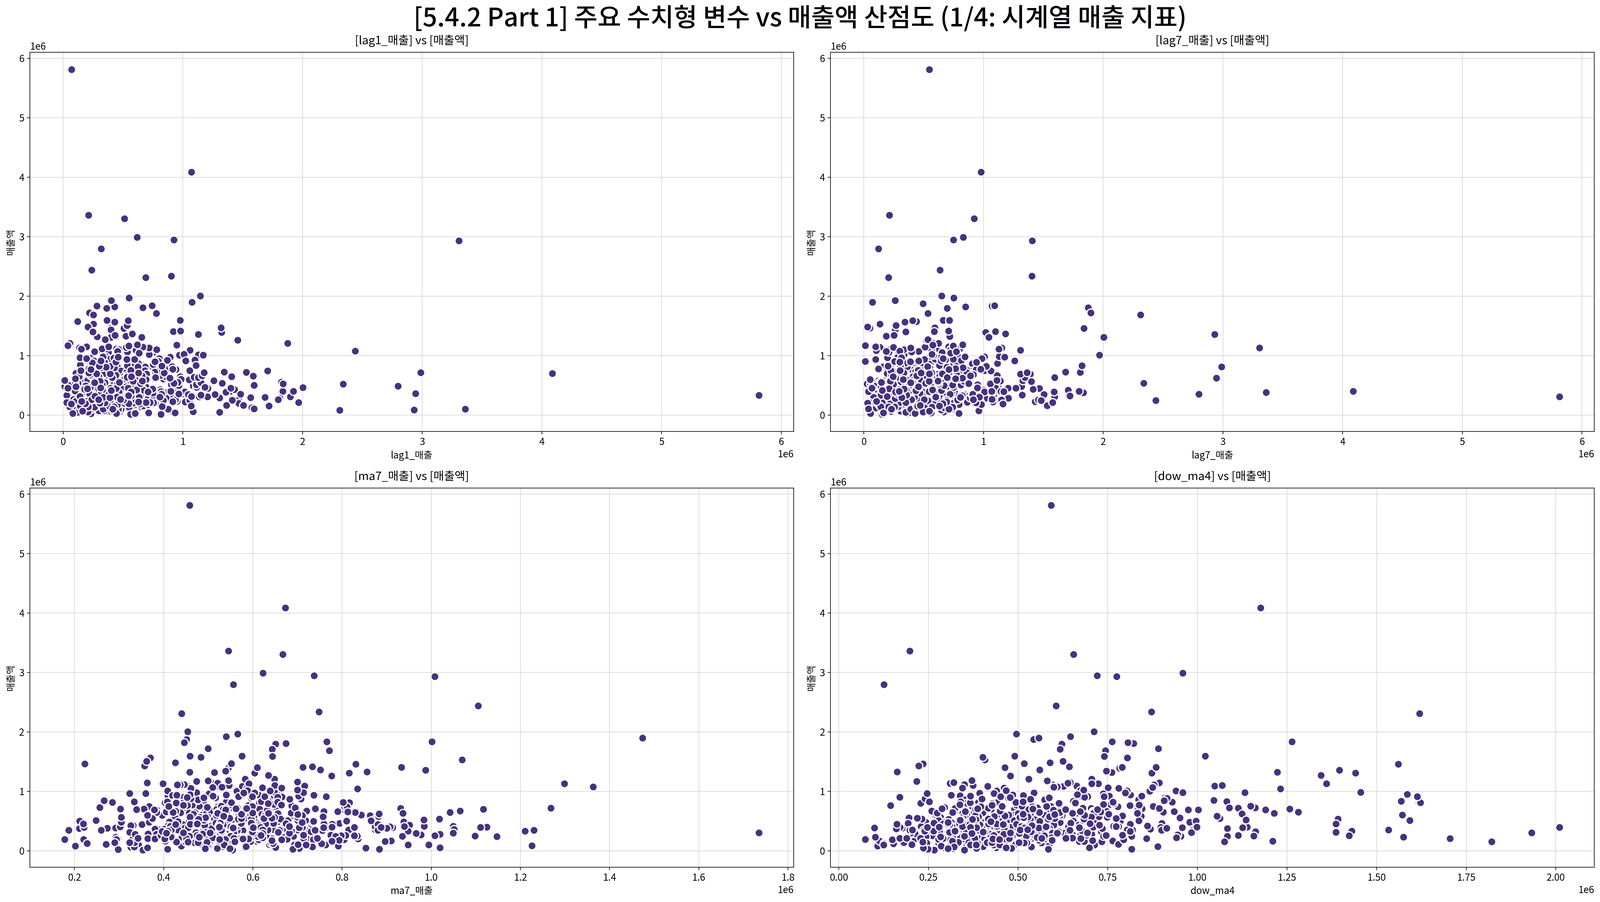

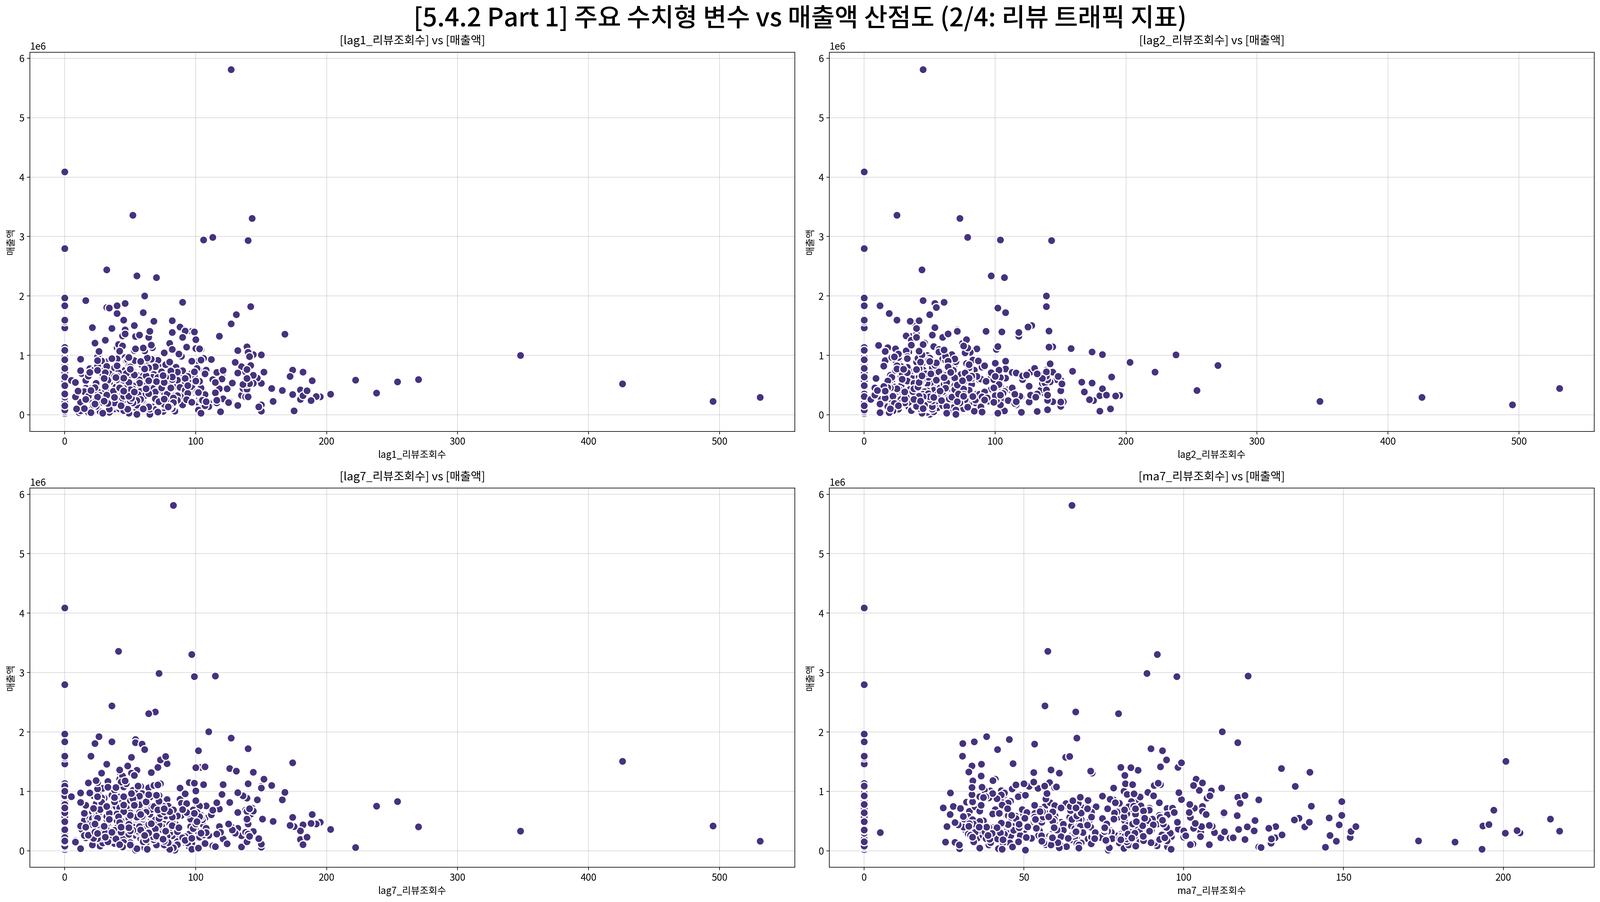

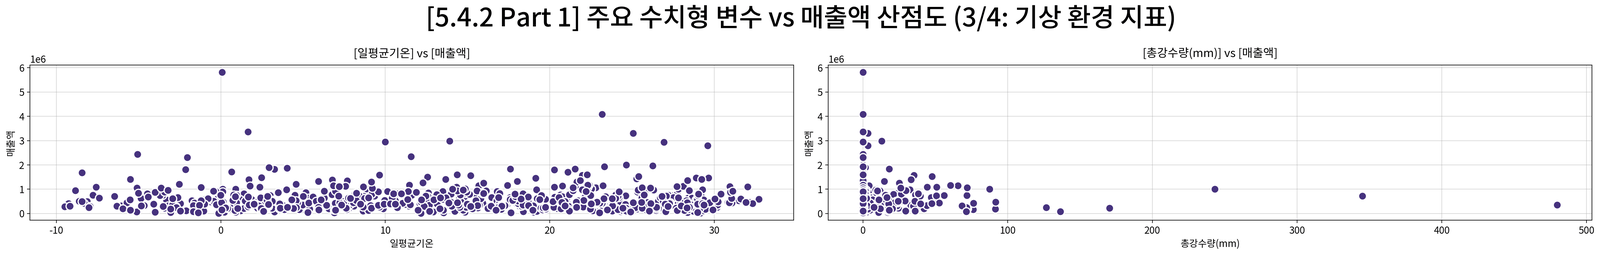

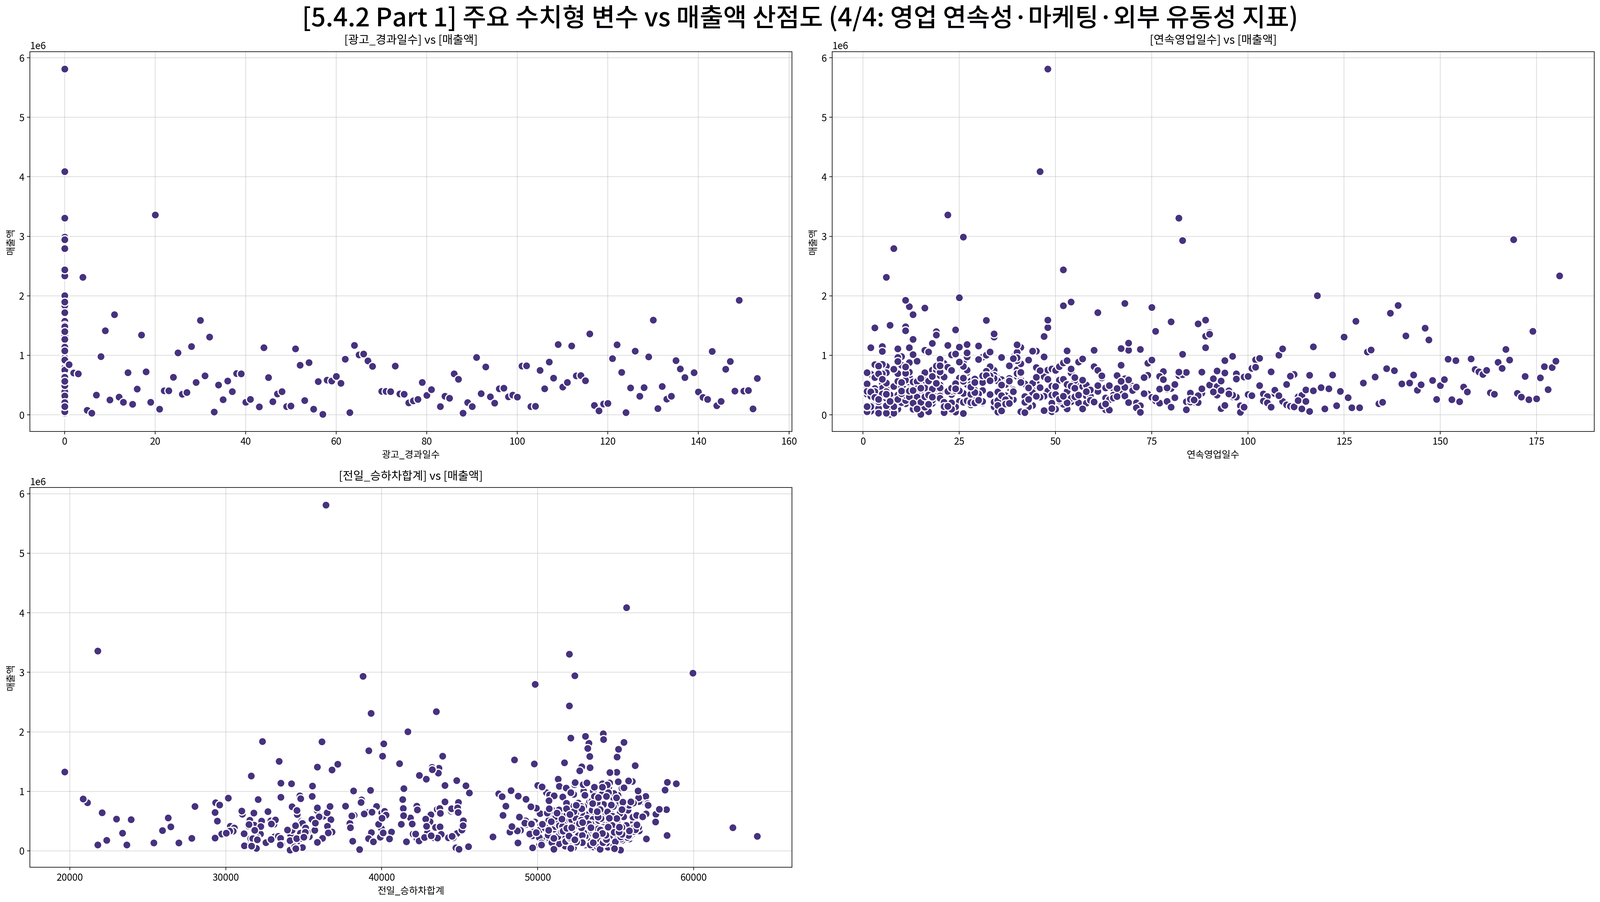

##### [5.4.2 Part 2] 지정 수치형 독립변수 (13개) 간 상관계수 행렬 및 다중공선성 위험 변수 집계

,max-y,max-coef,count,columns
x,,,,
ma7_리뷰조회수,lag2_리뷰조회수,0.8345,3,"lag2_리뷰조회수, lag1_리뷰조회수, lag7_리뷰조회수"
lag2_리뷰조회수,ma7_리뷰조회수,0.8345,1,ma7_리뷰조회수
lag1_리뷰조회수,ma7_리뷰조회수,0.8255,1,ma7_리뷰조회수
lag7_리뷰조회수,ma7_리뷰조회수,0.7995,1,ma7_리뷰조회수
dow_ma4,lag7_매출,0.5963,0,-
lag7_매출,dow_ma4,0.5963,0,-
광고_경과일수,연속영업일수,-0.4042,0,-
연속영업일수,광고_경과일수,-0.4042,0,-
일평균기온,ma7_리뷰조회수,-0.3871,0,-


##### [5.4.2 Part 2] 지정 수치형 독립변수 (13개) VIF(분산팽창계수) 진단표

,VIF
ma7_리뷰조회수,6.075320
lag2_리뷰조회수,2.608608
lag1_리뷰조회수,2.406267
lag7_리뷰조회수,2.373603
lag7_매출,1.824364
dow_ma4,1.610449
ma7_매출,1.558802
lag1_매출,1.299521
일평균기온,1.246319
연속영업일수,1.237411


In [31]:
# =========================================================================
# 5.4.3 지정 수치형 독립변수(13개) 상관분석, 산점도 및 다중공선성 진단
# =========================================================================
# -------------------------------------------------------------------------
# [Part 1] 수치형 독립변수(13개) vs 매출액 상관분석 및 테마별 산점도
# -------------------------------------------------------------------------
# 1. 분석 대상 수치형 독립변수 13개 및 Target 정의
num_cols_bivariate = [
    "매출액",  # Target
    "lag1_매출",
    "lag7_매출",
    "ma7_매출",
    "dow_ma4",
    "lag1_리뷰조회수",
    "lag2_리뷰조회수",
    "lag7_리뷰조회수",
    "ma7_리뷰조회수",
    "일평균기온",
    "총강수량(mm)",
    "광고_경과일수",
    "연속영업일수",
    "전일_승하차합계",
]

# 2. 다중 변수 상관분석 실행 (my_stats 모듈 활용)
display(
    Markdown(
        "##### [5.4.2 Part 1] 수치형 독립변수 (13개) vs 매출액 상관분석 요약표"
    )
)
corr_results = my_stats.multi_correlation(
    df_final, columns=num_cols_bivariate, alpha=0.05, plot=False
)

# 종속변수['매출액']과의 상관계수만 추출하여 절댓값 기준 내림차순 정렬
target_corr = corr_results[
    (corr_results.index.get_level_values(0) == "매출액")
    | (corr_results.index.get_level_values(1) == "매출액")
].sort_values(by="coef", key=abs, ascending=False)

display(target_corr)

# 3. 테마별 그룹화 (4개 그룹: 4개, 4개, 2개, 3개)
variable_groups = [
    ["lag1_매출", "lag7_매출", "ma7_매출", "dow_ma4"],
    ["lag1_리뷰조회수", "lag2_리뷰조회수", "lag7_리뷰조회수", "ma7_리뷰조회수"],
    ["일평균기온", "총강수량(mm)"],
    ["광고_경과일수", "연속영업일수", "전일_승하차합계"],
]

group_titles = [
    "1/4: 시계열 매출 지표",
    "2/4: 리뷰 트래픽 지표",
    "3/4: 기상 환경 지표",
    "4/4: 영업 연속성·마케팅·외부 유동성 지표",
]

# 4. 그룹별 상세 산점도 출력 (my_plot 모듈 활용)
for group_idx, (group_vars, group_title) in enumerate(
    zip(variable_groups, group_titles), 1
):
    rows = 2 if len(group_vars) > 2 else 1
    cols = 2
    width = 1400
    height = 800 if rows == 2 else 450

    fig, ax = my_plot.init(
        width=width,
        height=height,
        rows=rows,
        cols=cols,
        title=f"[5.4.2 Part 1] 주요 수치형 변수 vs 매출액 산점도 ({group_title})",
    )

    axes = ax   # my_plot.init 은 여러 칸일 때 이미 1차원 배열로 펼쳐서 반환한다

    for idx, var in enumerate(group_vars):
        my_plot.scatterplot(
            data=df_final,
            x=var,
            y="매출액",
            palette="viridis",
            ax=axes[idx],
        )
        axes[idx].set_title(f"[{var}] vs [매출액]", pad=10)

    # 빈 서브플롯 축 숨기기
    for idx in range(len(group_vars), len(axes)):
        axes[idx].set_visible(False)

    fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)
    my_plot.show()

# -------------------------------------------------------------------------
# [Part 2] 지정 수치형 독립변수(13개) 간 다중공선성 위험 진단
# -------------------------------------------------------------------------
# Target '매출액'을 제외한 지정 수치형 독립변수 13개 리스트 정의
num_cols_vif = [c for c in num_cols_bivariate if c != "매출액"]

# 1. 13개 독립변수 간 상관관계 행렬 산출 및 강한 상관관계(|r| >= 0.7) 위험 변수 집계
display(
    Markdown(
        "##### [5.4.2 Part 2] 지정 수치형 독립변수 (13개) 간 상관계수 행렬 및 다중공선성 위험 변수 집계"
    )
)

# Part 1 결과에서 '매출액' 관련 쌍을 제외한 순수 독립변수 간 상관관계만 필터링
corr_df_vif = corr_results[
    (corr_results.index.get_level_values(0) != "매출액")
    & (corr_results.index.get_level_values(1) != "매출액")
]

corr_summary = my_stats.correlation_summary(corr_df_vif, strength="Strong")
display(corr_summary)

# 2. 지정 독립변수 13개 대상 VIF(분산팽창계수) 산출 (my_stats.compute_vif 활용)
display(
    Markdown(
        "##### [5.4.2 Part 2] 지정 수치형 독립변수 (13개) VIF(분산팽창계수) 진단표"
    )
)
vif_df = my_stats.compute_vif(df_final, columns=num_cols_vif)
display(vif_df)

#### 5.4.2 [Part 1·2] 수치형 변수 결과 해석 (상관분석·다중공선성)

---

##### 전체 요약

* **스피어만 상관계수 사용**: 모든 변수가 정규분포가 아니고(`normality = False`) 치우침이 커서(`high_skew = True`) 순위 기반인 스피어만 상관계수(ρ)를 썼습니다.
* **매출과 유의한 변수 5개**: 13개 중 `dow_ma4`, `lag7_매출`, `lag1_매출`, `lag1_리뷰조회수`, `연속영업일수`가 p < 0.05였습니다. 가장 큰 `dow_ma4`도 ρ = 0.30으로 **약한 상관**이며, 나머지는 0.10~0.16입니다.
* **다중공선성 문제 없음**: 13개 변수의 VIF가 1.11~6.08로 모두 기준(10) 아래라, VIF 때문에 빼야 할 변수는 없습니다.

---

##### 1. [그룹 1] 매출 시차 변수 (4개) — VIF 1.30 ~ 1.82

* **`dow_ma4` (같은 요일 최근 4회 평균)**: ρ = 0.2979 (p < 0.001) — 수치형 변수 중 매출과의 상관이 가장 크지만 강도는 약합니다. (VIF 1.61)
* **`lag7_매출` (지난주 같은 요일 매출)**: ρ = 0.1611 (p < 0.001) — 약한 양의 상관입니다. (VIF 1.82)
* **`lag1_매출` (직전 영업일 매출)**: ρ = 0.1138 (p = 0.0027) — 약한 양의 상관입니다. (VIF 1.30)
* **`ma7_매출` (직전 7일 중 영업일 평균)**: ρ = 0.0403 (p = 0.2909) — 유의하지 않습니다. (VIF 1.56)
* **시사점**: 같은 요일 정보를 담은 `dow_ma4`와 `lag7_매출`이 매출과의 상관이 가장 큽니다. 두 변수끼리도 ρ = 0.60으로 관련이 있지만 VIF가 모두 1.82 이하라 함께 넣어도 서로 겹치는 문제는 없습니다.

---

##### 2. [그룹 2] 리뷰조회수 변수 (4개) — VIF 2.37 ~ 6.08

* **`lag1_리뷰조회수`**: ρ = 0.1034 (p = 0.0065) — 약하지만 유의한 양의 상관입니다. (VIF 2.41)
* **`lag2_리뷰조회수`**: ρ = 0.0737 (p = 0.0528) — 유의 기준을 아주 조금 넘어 유의하지 않습니다. (VIF 2.61)
* **`lag7_리뷰조회수`**: ρ = 0.0441 (p = 0.2468). (VIF 2.37)
* **`ma7_리뷰조회수`**: ρ = 0.0347 (p = 0.3624) — VIF가 13개 중 가장 높은 6.08입니다. 7일 평균 안에 다른 시차 값이 들어 있어 `lag2_리뷰조회수`(ρ = 0.83) 등과 상관이 높기 때문입니다.
* **시사점**: 전날 리뷰조회수만 매출과 약한 관련을 보였습니다. 다만 리뷰조회수가 0인 날은 광고 시작 전(개업 초기)에 몰려 있어 이 관련이 리뷰의 효과인지 개업 초기 효과인지는 5.4.4와 6.6에서 따로 확인합니다.

---

##### 3. [그룹 3] 날씨 변수 (2개) — VIF 1.11 ~ 1.25

* **`일평균기온`**: ρ = -0.0104 (p = 0.7860). (VIF 1.25)
* **`총강수량(mm)`**: ρ = -0.0378 (p = 0.3218). (VIF 1.11)
* **시사점**: 두 변수 모두 매출과 상관이 거의 없고 다른 변수와도 거의 겹치지 않습니다.

---

##### 4. [그룹 4] 영업 흐름·광고·유동인구 (3개) — VIF 1.13 ~ 1.24

* **`연속영업일수`**: ρ = 0.0969 (p = 0.0109) — 쉬지 않고 영업한 날이 길수록 매출이 아주 조금 높은 경향입니다. (VIF 1.24)
* **`전일_승하차합계`**: ρ = 0.0686 (p = 0.0717) — 유의하지 않습니다. (VIF 1.13)
* **`광고_경과일수`**: ρ = 0.0048 (p = 0.8999) — 유의하지 않습니다. (VIF 1.16)

---

##### 5. 다중공선성 결론

* 13개 변수의 VIF는 최소 1.11(`총강수량(mm)`)부터 최대 6.08(`ma7_리뷰조회수`)까지로 **모두 10 미만**입니다.
* 따라서 VIF 기준으로 빼는 변수는 없고 13개 모두 다음 단계의 후보로 넘어갑니다. 최종 선택은 매출과의 관련성을 함께 보고 5.4.3에서 정합니다.

##### [5.4.2 Part 3] 범주형 독립변수 (8개) vs 매출액 집단 간 평균 차이 검정 요약표

,독립변수,test,ddof1,ddof2,F,p_unc,np2,effect_size
0,광고_실시여부,anova,1,688.000000,1.290592,2.563344e-01,0.001872,Negligible
1,기상특보여부,anova,1,688.000000,0.738397,3.904742e-01,0.001072,Negligible
2,공휴일여부,anova,1,688.000000,2.030405,1.546330e-01,0.002942,Negligible
3,공휴일전날여부,anova,1,688.000000,3.860035,4.985136e-02,0.005579,Negligible
4,연휴여부,anova,1,688.000000,2.040304,1.536329e-01,0.002957,Negligible
5,계절,anova,3,686.000000,1.088177,3.533674e-01,0.004736,Negligible
6,요일,welch_anova,6,301.960251,12.040249,3.943827e-12,0.102661,Medium
7,우천여부,anova,1,688.000000,0.498410,4.804387e-01,0.000724,Negligible


##### [사후검정] 다중 범주 변수(계절, 요일) 그룹 간 세부 평균 차이 분석

**[계절] 그룹 간 사후검정**

비교한 조합 쌍: 6개
유의한 쌍: 0개
평균 차이가 가장 큰 쌍: (가을) vs (봄) → 차이 91526.486, 효과크기 Negligible, p-value 0.346
평균 차이가 가장 작은 쌍: (가을) vs (겨울) → 차이 21101.152, 효과크기 Negligible, p-value 0.980


...

**[요일] 범주별 평균 효과크기(|Hedges' g|) — 작은 순**

,순위,범주,평균효과크기,최대효과크기,유의한쌍수,비교쌍수,기준범주
0,1,Tuesday,0.3066,0.6468,3,6,True
1,2,Wednesday,0.3269,0.6848,3,6,False
2,3,Thursday,0.3620,0.7512,3,6,False
3,4,Monday,0.4228,0.8161,3,6,False
4,5,Sunday,0.4452,0.6757,4,6,False
5,6,Friday,0.4748,0.7212,4,6,False
6,7,Saturday,0.5362,0.8161,4,6,False


##### 다중 범주 변수별 기준범주 (평균 효과크기 최소) 요약표

,독립변수,사후검정,기준범주,평균효과크기,최대효과크기,유의한쌍수/비교쌍수
0,계절,Tukey HSD,겨울,0.0812,0.1365,0/3
1,요일,Games-Howell,Tuesday,0.3066,0.6468,3/6


기준범주: {'계절': '겨울', '요일': 'Tuesday'}


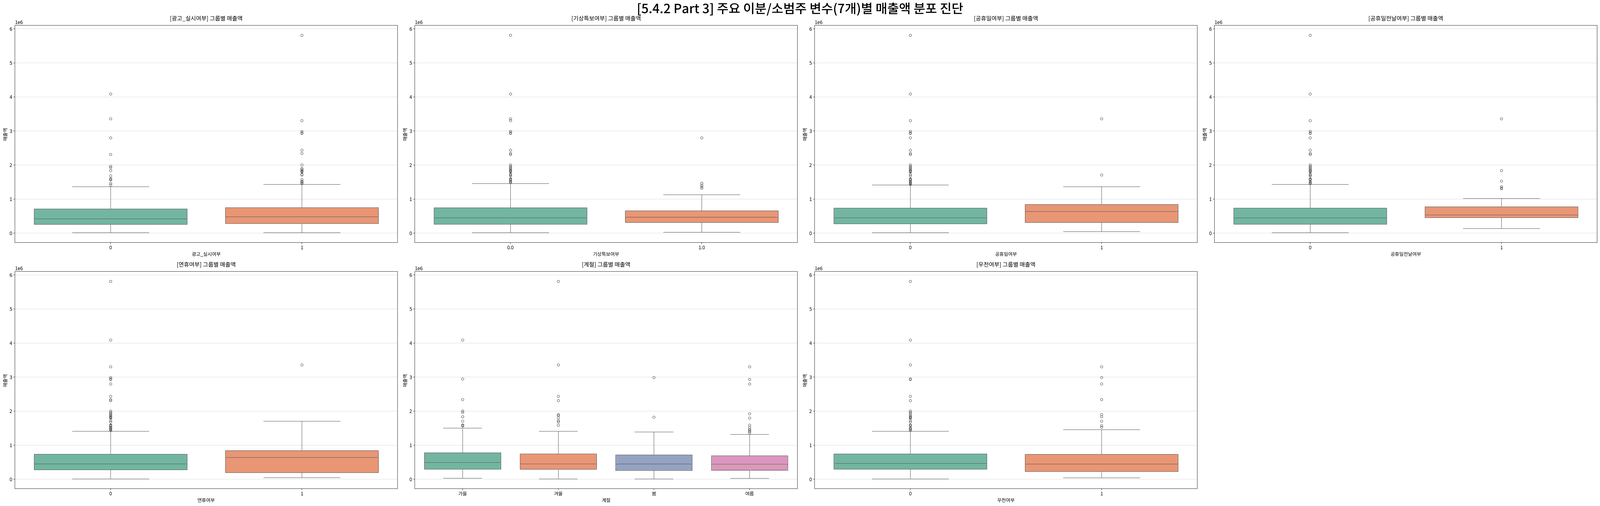

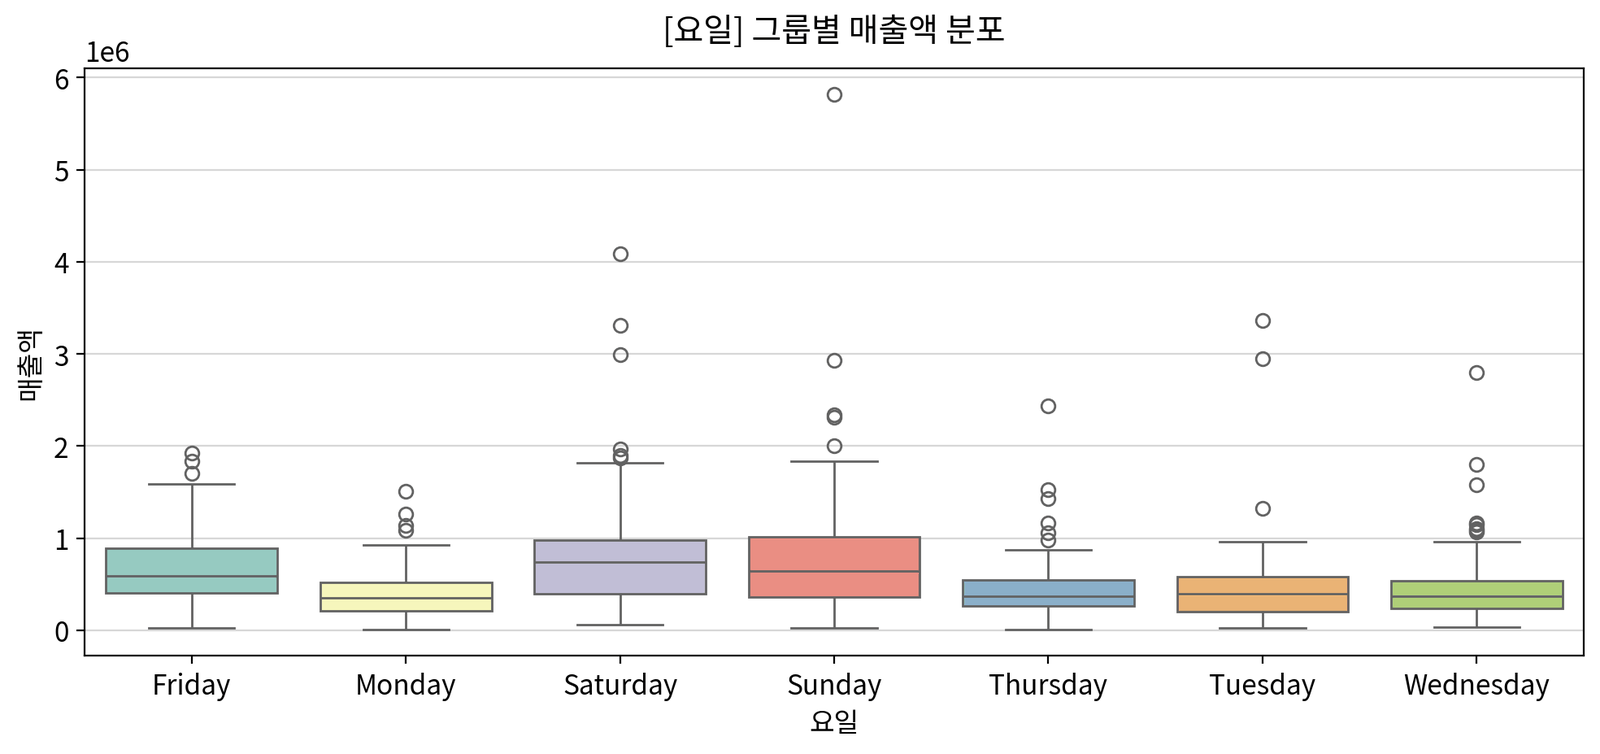

In [32]:
# 1. 원본 범주형 독립변수 리스트 정의 (총 8개)
cat_vars = [
    "광고_실시여부",
    "기상특보여부",
    "공휴일여부",
    "공휴일전날여부",
    "연휴여부",
    "계절",
    "요일",
    "우천여부"
]

# 2. 범주형 변수별 매출액 평균 차이 검정 (my_stats.anova_oneway 활용)
#    - 등분산성 검정 결과에 따라 ANOVA / Welch-ANOVA 자동 분기
anova_results = []
for var in cat_vars:
    res = my_stats.anova_oneway(df_final, y="매출액", between=var)
    # pingouin의 Source 컬럼은 독립변수명과 동일하므로 제거
    res = res.drop(columns=["Source"], errors="ignore")
    res.insert(0, "독립변수", var)
    anova_results.append(res)

df_cat_anova = pd.concat(anova_results, ignore_index=True)

# 결과 요약표 출력
display(
    Markdown(
        "##### [5.4.2 Part 3] 범주형 독립변수 (8개) vs 매출액 집단 간 평균 차이"
        " 검정 요약표"
    )
)
display(df_cat_anova)

# 3. 3개 이상 범주(계절, 요일)에 대한 사후검정 + 범주별 평균 효과크기 → 기준범주 선정
display(
    Markdown(
        "##### [사후검정] 다중 범주 변수(계절, 요일) 그룹 간 세부 평균 차이"
        " 분석"
    )
)

posthoc_results = {}   # 변수별 사후검정 원본 결과 보관
ref_categories = {}    # 변수별 기준범주 (이후 라벨링에서 0/drop 대상)
ref_rows = []          # 기준범주 요약표용

for multi_var in ["계절", "요일"]:
    display(Markdown(f"**[{multi_var}] 그룹 간 사후검정**"))
    # 등분산성에 따라 Tukey HSD / Games-Howell 자동 적용
    ph = my_stats.posthoc_oneway(
        df_final, y="매출액", between=multi_var, plot=False, summary=True
    )
    posthoc_results[multi_var] = ph

    # 3-1. 각 범주가 A 또는 B로 등장하는 모든 쌍을 세로로 펼치기
    long_es = pd.concat(
        [
            ph[["A", "hedges", "significant"]].rename(columns={"A": "범주"}),
            ph[["B", "hedges", "significant"]].rename(columns={"B": "범주"}),
        ],
        ignore_index=True,
    )
    long_es["abs_hedges"] = long_es["hedges"].abs()   # 방향(부호) 제거, 크기만 사용

    # 3-2. 범주별 평균 |Hedges' g| 계산 → 작은 순으로 정렬
    es_by_level = (
        long_es.groupby("범주", observed=True)
        .agg(
            평균효과크기=("abs_hedges", "mean"),
            최대효과크기=("abs_hedges", "max"),
            유의한쌍수=("significant", "sum"),
            비교쌍수=("abs_hedges", "count"),
        )
        .sort_values("평균효과크기")
        .reset_index()
    )
    es_by_level.insert(0, "순위", range(1, len(es_by_level) + 1))
    es_by_level["기준범주"] = es_by_level["순위"] == 1

    display(Markdown(f"**[{multi_var}] 범주별 평균 효과크기(|Hedges' g|) — 작은 순**"))
    display(es_by_level.round(4))

    # 3-3. 평균 효과크기가 가장 작은 범주 = 기준범주
    best = es_by_level.iloc[0]
    ref_categories[multi_var] = best["범주"]
    ref_rows.append(
        {
            "독립변수": multi_var,
            "사후검정": ph["test"].iloc[0],
            "기준범주": best["범주"],
            "평균효과크기": best["평균효과크기"],
            "최대효과크기": best["최대효과크기"],
            "유의한쌍수/비교쌍수": f"{int(best['유의한쌍수'])}/{int(best['비교쌍수'])}",
        }
    )

# 3-4. 변수별 기준범주 요약표
df_ref = pd.DataFrame(ref_rows)
display(Markdown("##### 다중 범주 변수별 기준범주 (평균 효과크기 최소) 요약표"))
display(df_ref.round(4))
print("기준범주:", ref_categories)

# 4-1. 이분 및 소범주 변수 7개 시각화 (2행 4열 배치)
binary_cat_vars = [
    "광고_실시여부",
    "기상특보여부",
    "공휴일여부",
    "공휴일전날여부",
    "연휴여부",
    "계절",
    "우천여부"
]

fig1, ax1 = my_plot.init(
    width=1400,
    height=900,
    rows=2,
    cols=4,
    title="[5.4.2 Part 3] 주요 이분/소범주 변수(7개)별 매출액 분포 진단",
)

axes1 = ax1   # my_plot.init 은 여러 칸일 때 이미 1차원 배열로 펼쳐서 반환한다

for idx, var in enumerate(binary_cat_vars):
    my_plot.boxplot(
        data=df_final,
        x=var,
        y="매출액",
        hue=var,
        palette="Set2",
        ax=axes1[idx],
    )
    axes1[idx].set_title(f"[{var}] 그룹별 매출액", pad=12)

# 남은 8번째 빈 서브플롯 제거 로직 추가
if len(axes1) > len(binary_cat_vars):
    for idx in range(len(binary_cat_vars), len(axes1)):
        fig1.delaxes(axes1[idx])

# 위아래 간격(hspace) 및 여백 조정으로 제목 겹침 방지
fig1.subplots_adjust(top=0.88, hspace=0.38, wspace=0.25)
my_plot.show()

# 4-2. 다중 범주변수 '요일' 단독 시각화 (여유로운 가로 단독 배치)
fig2, ax2 = my_plot.init(
    width=1000,
    height=480,
    rows=1,
    cols=1,
    title="[5.4.2 Part 3] 요일별(7개 집단) 매출액 분포 세부 진단",
)

my_plot.boxplot(
    data=df_final,
    x="요일",
    y="매출액",
    hue="요일",
    palette="Set3",
    ax=ax2,
)
ax2.set_title("[요일] 그룹별 매출액 분포", pad=12)

fig2.subplots_adjust(top=0.85)
my_plot.show()

#### 5.4.2 [Part 3] 범주형 변수 결과 해석 (ANOVA·사후검정)

범주형 변수 8개(`광고_실시여부`, `기상특보여부`, `공휴일여부`, `공휴일전날여부`, `연휴여부`, `계절`, `요일`, `우천여부`)에 대해 집단 간 매출액 평균 차이의 유의성(p값)과 효과크기(부분 에타제곱, $\eta_p^2$)를 확인했습니다.

---

##### 1. 검정 방법 선택

`my_stats.anova_oneway`와 `my_stats.posthoc_oneway`는 등분산 검정 결과에 따라 방법을 자동으로 고릅니다.

* **분산이 같으면**: 일반 일원분산분석(ANOVA) → 사후검정은 **Tukey HSD**
  * 해당 변수: `광고_실시여부`, `기상특보여부`, `공휴일여부`, `공휴일전날여부`, `연휴여부`, `계절`, `우천여부`
* **분산이 다르면**: **Welch-ANOVA** → 사후검정은 **Games-Howell**
  * 해당 변수: `요일`

---

##### 2. 변수별 결과

* **`요일`**
  * 분산이 요일마다 달라 Welch-ANOVA를 적용했습니다.
  * $p = 3.94 \times 10^{-12}$로 유의하고 효과크기 $\eta_p^2 = 0.103$(중간)으로 8개 변수 중 **유일하게 의미 있는 크기의 차이**를 보였습니다. 요일이 매출 변동의 약 10.3%를 설명한다는 뜻입니다.
  * 사후검정 21쌍 중 **12쌍이 유의**했습니다.
    * 차이가 가장 큰 쌍: **월요일 vs 토요일**, 평균 차이 **404,963원** ($p < 0.001$, 효과크기 큼)
    * 차이가 가장 작은 쌍: 화요일 vs 수요일, 평균 차이 1,582원 ($p = 1.000$)
  * 금·토·일과 월~목 사이에 매출 차이가 뚜렷합니다.

* **`계절`**
  * 분산이 같아 일반 ANOVA를 적용했습니다. $p = 0.3534$로 유의하지 않습니다.
  * 사후검정 6쌍 중 유의한 쌍은 없습니다(0/6).
    * 차이가 가장 큰 쌍: 가을 vs 봄, 91,526원 ($p = 0.346$)
    * 차이가 가장 작은 쌍: 가을 vs 겨울, 21,101원 ($p = 0.980$)
  * 이 매장에서는 계절보다 요일에 따른 차이가 훨씬 큽니다.

* **`공휴일전날여부`**
  * $F = 3.86, p = 0.0499$로 유의 기준을 겨우 넘었지만 효과크기는 $\eta_p^2 = 0.006$으로 매우 작습니다.

* **나머지 0/1 변수 (`광고_실시여부`, `기상특보여부`, `우천여부`, `공휴일여부`, `연휴여부`)**
  * 모두 유의하지 않고($p > 0.05$) 효과크기도 $\eta_p^2 < 0.003$으로 매우 작습니다.
  * `광고_실시여부` ($F = 1.29, p = 0.2563$), `기상특보여부` ($F = 0.74, p = 0.3905$), `우천여부` ($F = 0.50, p = 0.4804$), `공휴일여부` ($F = 2.03, p = 0.1546$), `연휴여부` ($F = 2.04, p = 0.1536$)

---

##### 3. 모델링으로 연결

1. **`요일`은 가장 중요한 변수로 채택합니다.** 요일 간 평균 차이가 최대 40.5만 원으로 크므로, `요일`과 같은 요일 평균(`dow_ma4`)을 모델의 기본 변수로 둡니다.
2. **요일 더미의 기준 범주는 화요일로 정합니다.** 다른 요일과의 평균 효과크기(|Hedges' g|)가 가장 작은 범주를 기준으로 삼았습니다(화요일 0.307). 계절의 기준 범주는 겨울(0.081)이지만, 계절은 유의하지 않아 모델에서 빠집니다.
3. **효과가 작은 0/1 변수는 바로 버리지 않습니다.** `공휴일여부`, `연휴여부`, `광고_실시여부` 등은 혼자서는 차이가 작지만 요일 차이가 워낙 커서 효과가 가려졌을 수 있습니다. 5.4.4에서 한 번 더 검토합니다.

#### 5.4.3 1차 변수 선정표

**[선정 기준]**
* **채택**: 유의하고($p < 0.05$) 크기도 기준 이상인 변수 (범주형은 $\eta_p^2 \ge 0.06$, 수치형은 $\vert{}\rho\vert{} \ge 0.25$)
* **후보**: 유의하지만($p < 0.05$) 크기가 기준에 못 미치는 변수
* **제외**: 유의하지 않은 변수($p \ge 0.05$)

| 판정 | 구분 | 변수명 | 효과크기 / 상관 | 분포 | 공선성 (VIF) | 근거 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **⭐ 채택** | 📅 범주형 | **`요일`** | ηₚ² 0.1027 | - | - | ηₚ² ≥ 0.06, Welch-ANOVA p = 3.94 × 10⁻¹². 금·토·일과 월~목의 차이가 뚜렷함 |
| **⭐ 채택** | 🔢 수치형 | **`dow_ma4`** | ρ +0.2979 (약함) | 비정규·치우침 | 1.61 | ρ ≥ 0.25, 수치형 중 매출과의 상관이 가장 큼 |
| **📌 후보** | 🔢 수치형 | **`lag7_매출`** | ρ +0.1611 (약함) | 비정규·치우침 | 1.82 | 유의하지만 ρ < 0.25. 지난주 같은 요일 매출 |
| **📌 후보** | 🔢 수치형 | **`lag1_매출`** | ρ +0.1138 (약함) | 비정규·치우침 | 1.30 | 유의하지만 ρ < 0.25. 직전 영업일 매출 |
| **📌 후보** | 🔢 수치형 | **`lag1_리뷰조회수`** | ρ +0.1034 (약함) | 비정규·치우침 | 2.41 | 유의하지만 ρ < 0.25. 개업 초기와 겹치는 점은 5.4.4·6.6에서 확인 |
| **📌 후보** | 🔢 수치형 | **`연속영업일수`** | ρ +0.0969 (약함) | 비정규·치우침 | 1.24 | 유의하지만 ρ < 0.25. 쉬지 않고 영업한 기간 |
| **📌 후보** | 📅 범주형 | **`공휴일전날여부`** | ηₚ² 0.0056 | - | - | p = 0.0499로 유의하지만 효과크기가 매우 작음 |
| **❌ 제외** | 🔢 수치형 | **`전일_승하차합계`** | ρ +0.0686 | 비정규·치우침 | 1.13 | p = 0.0717 |
| **❌ 제외** | 🔢 수치형 | **`lag2_리뷰조회수`** | ρ +0.0737 | 비정규·치우침 | 2.61 | p = 0.0528 |
| **❌ 제외** | 🔢 수치형 | **`lag7_리뷰조회수`** | ρ +0.0441 | 비정규·치우침 | 2.37 | p = 0.2468 |
| **❌ 제외** | 🔢 수치형 | **`ma7_매출`** | ρ +0.0403 | 비정규·치우침 | 1.56 | p = 0.2909 |
| **❌ 제외** | 🔢 수치형 | **`ma7_리뷰조회수`** | ρ +0.0347 | 비정규·치우침 | 6.08 | p = 0.3624, VIF도 13개 중 가장 높음 |
| **❌ 제외** | 🔢 수치형 | **`광고_경과일수`** | ρ +0.0048 | 비정규·치우침 | 1.16 | p = 0.8999 |
| **❌ 제외** | 🔢 수치형 | **`일평균기온`** | ρ -0.0104 | 대칭에 가까움 | 1.25 | p = 0.7860 |
| **❌ 제외** | 🔢 수치형 | **`총강수량(mm)`** | ρ -0.0378 | 0이 대부분·치우침 | 1.11 | p = 0.3218 |
| **❌ 제외** | 📅 범주형 | **`연휴여부`** | ηₚ² 0.0030 | - | - | p = 0.1536 |
| **❌ 제외** | 📅 범주형 | **`공휴일여부`** | ηₚ² 0.0029 | - | - | p = 0.1546 |
| **❌ 제외** | 📅 범주형 | **`광고_실시여부`** | ηₚ² 0.0019 | - | - | p = 0.2563 |
| **❌ 제외** | 📅 범주형 | **`기상특보여부`** | ηₚ² 0.0011 | - | - | p = 0.3905 |
| **❌ 제외** | 📅 범주형 | **`우천여부`** | ηₚ² 0.0007 | - | - | p = 0.4804 |
| **❌ 제외** | 📅 범주형 | **`계절`** | ηₚ² 0.0047 | - | - | p = 0.3534 |

* 1차 기준으로는 채택 2개, 후보 5개입니다. 다만 이 기준은 변수를 하나씩 매출과 비교한 결과라, 요일처럼 영향이 큰 변수에 가려진 효과를 놓칠 수 있습니다. 제외된 변수 중 광고·휴일 변수는 5.4.4에서 다시 검토합니다.

#### 5.4.4 제외·후보 변수 2차 검토

##### 1. 2차 검토를 하는 이유
5.4.2의 상관분석과 ANOVA는 변수 하나와 매출의 관계만 봅니다. 그래서 다른 변수를 함께 넣었을 때 비로소 효과가 드러나는 변수를 놓칠 수 있습니다.

* **광고·리뷰 변수 (`광고_실시여부`, `광고_경과일수`, `lag1_리뷰조회수`)**: "광고 집행 → 리뷰 글 조회 → 다음 날 방문·매출"이라는 흐름을 예상할 수 있습니다. 1차에서는 `lag1_리뷰조회수`만 약하게 유의했고 광고 변수 2개는 유의하지 않았습니다. 세 변수의 관계가 데이터에서 어디까지 보이는지 아래에서 그래프와 상관분석으로 먼저 확인합니다.
* **휴일 변수 (`공휴일여부`, `공휴일전날여부`, `연휴여부`)**: `공휴일전날여부`만 겨우 유의했고(p = 0.0499) 나머지는 유의하지 않았지만 요일 차이가 워낙 커서 휴일 효과가 가려졌을 수도 있습니다. 예를 들어 평일에 낀 공휴일은 평소 평일보다 매출이 높을 수 있습니다. 이 효과는 요일을 함께 넣은 모델에서만 확인할 수 있으므로, 따로 검정하지 않고 모델 후보에 넣어 다변량 모델에서 확인합니다.

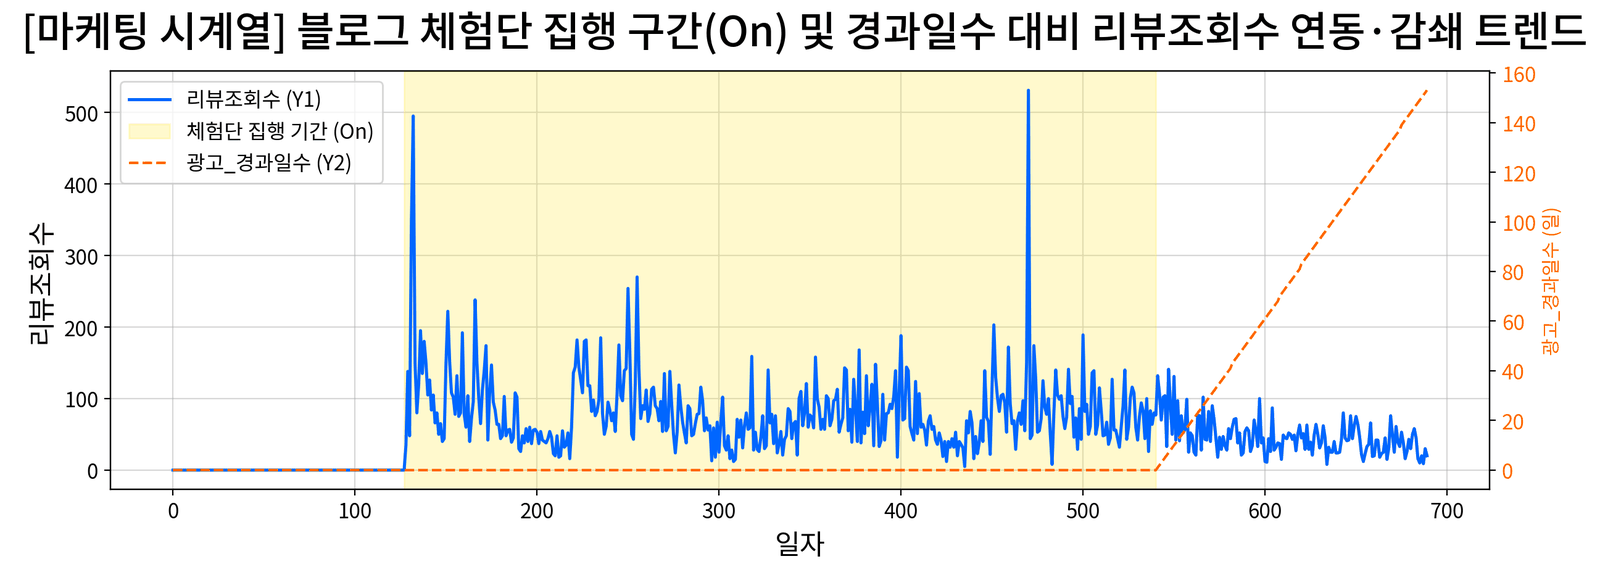

[my_stats] 마케팅 집행·잔존 변수 세트 vs 매출액 상관성 진단


C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\yeold\OneDrive\Desktop\helpers\my_stats.py:897: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]


,광고_실시여부,광고_경과일수,lag1_리뷰조회수,매출액
광고_실시여부,1.000,-0.636,0.611,0.059
광고_경과일수,-0.636,1.000,-0.114,0.005
lag1_리뷰조회수,0.611,-0.114,1.000,0.103
매출액,0.059,0.005,0.103,1.000


method    coef  p-value  strength  significant
x          y                                                           
광고_실시여부    광고_경과일수     Spearman -0.6365   0.0000  Moderate         True
           lag1_리뷰조회수  Spearman  0.6109   0.0000  Moderate         True
           매출액         Spearman  0.0590   0.1216      Weak        False
광고_경과일수    lag1_리뷰조회수  Spearman -0.1136   0.0028      Weak         True
           매출액         Spearman  0.0048   0.8999      Weak        False
lag1_리뷰조회수 매출액         Spearman  0.1034   0.0065      Weak         True

In [33]:
# =========================================================================
# 마케팅 잔존·감쇄 및 상관성 진단 
# =========================================================================
# -------------------------------------------------------------------------
# 0. 범주형(category) 컬럼의 수치형(int) 형변환
# -------------------------------------------------------------------------
# 이진 범주형(광고_실시여부)을 int로 형변환하여 점상관계수 유효성 확보
if "광고_실시여부" in df_final.columns:
    df_final["광고_실시여부"] = df_final["광고_실시여부"].astype(int)

# -------------------------------------------------------------------------
# 1. my_plot 모듈 기반 시계열 트렌드 이중 축 시각화 + 체험단 집행 구간(On) 음영
# -------------------------------------------------------------------------
fig, ax1 = my_plot.init(
    width=1280,
    height=480,
    title=(
        " [마케팅 시계열] 블로그 체험단 집행 구간(On) 및 경과일수 대비 리뷰조회수"
        " 연동·감쇄 트렌드"
    ),
    xlabel="일자",
    ylabel="리뷰조회수",
)

# [왼쪽 Y축] 리뷰조회수 (실질 트래픽 흐름)
my_plot.lineplot(
    data=df_final,
    x=df_final.index,
    y="리뷰조회수",
    color="#0066ff",
    linewidth=1.8,
    label="리뷰조회수 (Y1)",
    ax=ax1,
)

# [오른쪽 Y축] 광고_경과일수 (시간 경과 감쇄 스위치)
ax2 = ax1.twinx()
ax2.set_ylabel("광고_경과일수 (일)", color="#ff6600", fontsize=11)
ax2.plot(
    df_final.index,
    df_final["광고_경과일수"],
    color="#ff6600",
    linestyle="--",
    linewidth=1.5,
    label="광고_경과일수 (Y2)",
)
ax2.tick_params(axis="y", labelcolor="#ff6600")

# [광고_실시여부 == 1] 연속 집행 기간 배경 음영(axvspan) 하이라이트
on_mask = df_final["광고_실시여부"] == 1
if on_mask.any():
    group_blocks = (on_mask != on_mask.shift()).cumsum()[on_mask]
    for _, block in df_final.groupby(group_blocks):
        start_idx = block.index[0]
        end_idx = block.index[-1]
        ax1.axvspan(
            start_idx,
            end_idx,
            color="#ffeb3b",
            alpha=0.25,
            label="체험단 집행 기간 (On)",
        )

# 범례 중복 제거 및 통합 표시
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), loc="upper left")

my_plot.show()

# -------------------------------------------------------------------------
# 2. my_stats 모듈 기반 핵심 마케팅 변수 세트 다중 상관분석
# -------------------------------------------------------------------------
print("=" * 70)
print("[my_stats] 마케팅 집행·잔존 변수 세트 vs 매출액 상관성 진단")
print("=" * 70)

mkt_cols = ["광고_실시여부", "광고_경과일수", "lag1_리뷰조회수", "매출액"]
existing_mkt_cols = [c for c in mkt_cols if c in df_final.columns]

corr_mkt_df = my_stats.multi_correlation(
    df_final, columns=existing_mkt_cols, alpha=0.05, plot=False
)
display(corr_mkt_df[["method", "coef", "p-value", "strength", "significant"]])

##### 2. 광고·리뷰 변수 확인 결과

##### 1. [시계열 그래프] 광고 기간과 리뷰조회수

* **광고 기간 (노란색 음영)**
  * 영업일 순번 약 127번째(2024년 11월 24일)부터 블로그 체험단 광고가 시작되었고, 그때부터 리뷰조회수가 집계됩니다. 광고 기간에는 대체로 하루 50~200회가 조회되었고, 500회 안팎까지 튄 날도 두 번 있습니다.
  * 광고는 영업일 순번 약 541번째(2026년 1월 하순)에 끝났습니다. 광고 종료 후에는 `광고_경과일수`가 하루씩 늘어나고, 리뷰조회수는 하루 약 20~100회 수준으로 낮아졌습니다.
  * 광고가 끝나도 이미 올라간 글은 계속 조회되므로 조회수가 바로 0이 되지는 않습니다. 다만 그래프만으로 조회수가 줄어든 원인을 단정할 수는 없습니다.
* **분석 설계상 짚어 둘 점**: 광고를 하지 않은 날은 **개업 초기(약 127일)**와 **광고 종료 후(약 149일)** 두 구간뿐입니다. 6장에서 쓸 테스트 구간(마지막 20%, 552번째 행부터)은 **전부 광고 종료 후**에 해당하므로, 광고 변수의 효과는 학습 구간과 테스트 구간에서 성격이 다를 수 있습니다.

##### 2. [상관분석] 광고·리뷰 변수와 매출

* **`광고_실시여부` ↔ `lag1_리뷰조회수` (ρ = +0.6109, p < 0.001, 중간 강도)**
  * 광고 기간에는 전날 리뷰조회수도 높습니다. 광고로 올라간 글이 읽히는 것이므로 자연스러운 결과이며 두 변수가 상당 부분 같은 정보를 담고 있다는 뜻입니다.

* **`광고_경과일수` ↔ `lag1_리뷰조회수` (ρ = -0.1136, p = 0.0028, 약한 음의 상관)**
  * 광고가 끝난 뒤 시간이 지날수록 조회수가 조금씩 줄어드는 방향입니다. 상관이 약하므로 줄어드는 정도를 크게 해석하지는 않습니다.

* **`lag1_리뷰조회수` ↔ `매출액` (ρ = +0.1034, p = 0.0065)**
  * 전날 리뷰조회수가 많을수록 오늘 매출이 아주 조금 높은 약한 양의 관계입니다.

* **정리**
  * `광고_실시여부` ↔ `매출액`(ρ = +0.0590, p = 0.1216), `광고_경과일수` ↔ `매출액`(ρ = +0.0048, p = 0.8999)은 유의하지 않습니다.
  * 즉 **"광고 → 조회수"** 관계는 뚜렷하고, **"조회수 → 매출"**은 약하게 보이지만 **"광고 → 매출"**은 직접 확인되지 않았습니다.
  * 리뷰조회수가 0인 날은 광고 시작 전, 즉 개업 초기와 겹칩니다. 따라서 "조회수 → 매출"의 약한 관계가 리뷰의 효과인지, "가게가 자리를 잡아 가는 효과"인지 이 단계에서는 떼어 낼 수 없습니다.

---

##### 3. 모델 투입 방침

* 세 변수를 **후보로 모델에 넣어** 다른 변수와 함께 넣었을 때 예측에 보탬이 되는지 확인합니다.
* 모델에서 이 변수들이 어떤 방향으로 작용하는지는 6.4의 SHAP에서 보고 개업 초기 효과가 섞였는지는 6.6에서 학습 기간을 광고 시작 이후로 한정한 모델과 비교해 확인합니다. 그 전까지는 **광고·리뷰의 순수한 매출 효과로 해석하지 않습니다.**

#### 5.4.5 최종 투입 변수 선정표

**[선정 기준]**
* **채택**: 1차 기준(유의하고 크기도 기준 이상)을 만족한 변수
* **후보**: 1차 기준에서 유의하지만 크기가 작은 변수, 또는 5.4.4에서 다변량 모델로 다시 확인하기로 한 변수
* **제외**: 유의하지 않고 다시 확인할 이유도 없는 변수

| 판정 | 구분 | 변수명 | 효과크기 / 상관 | 공선성 (VIF) | 근거 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **⭐ 채택** | 📅 범주형 | **`요일`** | ηₚ² 0.1027 | - | 1차 채택. 요일 간 매출 차이가 뚜렷함 |
| **⭐ 채택** | 🔢 수치형 | **`dow_ma4`** | ρ +0.2979 (약함) | 1.61 | 1차 채택. 수치형 중 매출과의 상관이 가장 큼 |
| **📌 후보** | 🔢 수치형 | **`lag7_매출`** | ρ +0.1611 (약함) | 1.82 | 1차 후보. 지난주 같은 요일 매출 |
| **📌 후보** | 🔢 수치형 | **`lag1_매출`** | ρ +0.1138 (약함) | 1.30 | 1차 후보. 직전 영업일 매출 |
| **📌 후보** | 🔢 수치형 | **`lag1_리뷰조회수`** | ρ +0.1034 (약함) | 2.41 | 1차 후보. 개업 초기와 겹치는 점은 6.6에서 확인 |
| **📌 후보** | 🔢 수치형 | **`연속영업일수`** | ρ +0.0969 (약함) | 1.24 | 1차 후보. 쉬지 않고 영업한 기간 |
| **📌 후보** | 📅 범주형 | **`공휴일전날여부`** | ηₚ² 0.0056 | - | 1차 후보(p = 0.0499). 요일과 함께 넣어 효과 확인 |
| **📌 후보** | 🔢 수치형 | **`광고_경과일수`** | ρ +0.0048 | 1.16 | 매출과는 무관하지만 광고 종료 후 조회수 감소(ρ = -0.1136, p = 0.0028)를 나타내므로 함께 넣어 확인 |
| **📌 후보** | 📅 범주형 | **`광고_실시여부`** | ηₚ² 0.0019 | - | 매출과는 무관하지만(p = 0.2563) 조회수와 관련(ρ = +0.6109)이 있어 함께 넣어 확인 |
| **📌 후보** | 📅 범주형 | **`공휴일여부`** | ηₚ² 0.0029 | - | 단독 p = 0.1546. 요일 효과에 가려졌을 수 있어 요일과 함께 넣어 확인 |
| **📌 후보** | 📅 범주형 | **`연휴여부`** | ηₚ² 0.0030 | - | 단독 p = 0.1536. 요일 효과에 가려졌을 수 있어 요일과 함께 넣어 확인 |
| **❌ 제외** | 🔢 수치형 | **`전일_승하차합계`** | ρ +0.0686 | 1.13 | p = 0.0717. 다시 확인할 근거가 없음 |
| **❌ 제외** | 🔢 수치형 | **`lag2_리뷰조회수`** | ρ +0.0737 | 2.61 | p = 0.0528. `lag1_리뷰조회수`로 대표 |
| **❌ 제외** | 🔢 수치형 | **`lag7_리뷰조회수`** | ρ +0.0441 | 2.37 | p = 0.2468 |
| **❌ 제외** | 🔢 수치형 | **`ma7_매출`** | ρ +0.0403 | 1.56 | p = 0.2909 |
| **❌ 제외** | 🔢 수치형 | **`ma7_리뷰조회수`** | ρ +0.0347 | 6.08 | p = 0.3624, VIF도 가장 높음 |
| **❌ 제외** | 🔢 수치형 | **`일평균기온`** | ρ -0.0104 | 1.25 | p = 0.7860 |
| **❌ 제외** | 🔢 수치형 | **`총강수량(mm)`** | ρ -0.0378 | 1.11 | p = 0.3218 |
| **❌ 제외** | 📅 범주형 | **`기상특보여부`** | ηₚ² 0.0011 | - | p = 0.3905 |
| **❌ 제외** | 📅 범주형 | **`우천여부`** | ηₚ² 0.0007 | - | p = 0.4804 |
| **❌ 제외** | 📅 범주형 | **`계절`** | ηₚ² 0.0047 | - | p = 0.3534 |

* **최종 투입 변수는 11개**입니다(채택 2개 + 후보 9개). 다음 셀에서 이 변수와 `매출액`만 남기고, 치우친 변수는 로그 변환, 범주형 변수는 숫자로 바꿉니다.

In [34]:
# =========================================================================
# 1. 기존 df_final에서 최종 선정 변수(12종 = 종속 1 + 독립 11) 필터링
# =========================================================================
selected_cols = [
    # 종속변수
    "매출액",
    
    # 채택 변수 (2종)
    "요일",
    "dow_ma4",
    
    # 후보 변수 (9종)
    "lag7_매출",
    "연속영업일수",
    "lag1_매출",
    "lag1_리뷰조회수",
    "광고_실시여부",
    "광고_경과일수",
    "공휴일전날여부",
    "공휴일여부",
    "연휴여부",
]

df_final = df_final[selected_cols].copy()

# =========================================================================
# 2. my_qtcheck.set_type 모듈을 사용한 데이터 타입 강제 정제 (as_category 적용)
# =========================================================================
cat_cols = ["요일", "광고_실시여부", "공휴일여부", "공휴일전날여부", "연휴여부"]
num_cols = [c for c in df_final.columns if c not in cat_cols]

# my_qtcheck.set_type 함수로 수치형(float) 및 범주형(category) 타입 일괄 변환
print("my_qtcheck.set_type 모듈을 통한 데이터 타입 변환 적용 (category 타입):")
df_final = my_qtcheck.set_type(
    df_final,
    as_float=num_cols,
    as_category=cat_cols
)

# =========================================================================
# 3. 수치형 변수 기술통계 및 로그변환(log_need) 자동 판정 (my_qtcheck)
# =========================================================================
num_desc = my_qtcheck.numerical_summary(df_final, columns=num_cols)
display(num_desc[["mean", "skew", "log_need"]])

# log_need 진단 결과별 매핑
log_columns = num_desc.index[num_desc["log_need"] == "log"].tolist()
log1p_columns = num_desc.index[num_desc["log_need"] == "log1p"].tolist()
reflect_columns = num_desc.index[
    num_desc["log_need"] == "reverse_log1p"
].tolist()

# =========================================================================
# 4. 로그변환 및 범주형 라벨 인코딩 적용 (my_prep)
# =========================================================================
# (1) 수치형 변수 로그변환 (종속변수 '매출액' 포함)
df_final = my_prep.log_transform(
    df_final,
    log_columns=log_columns,
    log1p_columns=log1p_columns,
    reflect_columns=reflect_columns,
    verbose=True,
)

# (2) 범주형 변수 라벨링 (0부터 시작하는 정수형으로 변환)
#   - '요일'은 사후검정에서 평균 효과크기가 가장 작았던 기준범주가 0이 되도록 별도 처리
#     (my_prep.labeling 은 LabelEncoder 라 알파벳순으로만 번호를 매기므로 순서를 지정할 수 없음)
dow_ref = "Tuesday"   # 앞 단계의 ref_categories["요일"] 값

# 나머지 요일은 달력 순서(월→일)로 배치하고, 기준범주만 맨 앞으로 이동
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
present = df_final["요일"].astype(str).unique().tolist()
others = [d for d in week_order if d in present and d != dow_ref]
others += sorted(d for d in present if d not in week_order and d != dow_ref)  # 예외 값 대비
dow_order = [dow_ref] + others

df_final["요일"] = pd.Categorical(
    df_final["요일"].astype(str), categories=dow_order
).codes
print(f"요일 ({len(dow_order)}종): " + ", ".join(f"{v}={i}" for i, v in enumerate(dow_order)))

# 나머지 이분 범주형 변수는 기존대로 my_prep.labeling 적용
other_cat_cols = [c for c in cat_cols if c != "요일"]
df_final = my_prep.labeling(df_final, columns=other_cat_cols, verbose=True)

# =========================================================================
# 5. 최종 전처리 데이터셋 검증 및 엑셀 저장
# =========================================================================
print("\n" + "=" * 60)
print(
    f"최종 전처리 완료 데이터셋 구조: {df_final.shape[0]}행 x"
    f" {df_final.shape[1]}열"
)
print("=" * 60)
display(df_final.head())



# 엑셀(.xlsx) 파일 저장
save_path = "final_selected_dataset.xlsx"
df_final.to_excel(save_path, index=False, engine="openpyxl")
print(f"최종 데이터셋 엑셀 저장 완료: {save_path}")

my_qtcheck.set_type 모듈을 통한 데이터 타입 변환 적용 (category 타입):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   매출액         690 non-null    float64 
 1   요일          690 non-null    category
 2   dow_ma4     690 non-null    float64 
 3   lag7_매출     690 non-null    float64 
 4   연속영업일수      690 non-null    float64 
 5   lag1_매출     690 non-null    float64 
 6   lag1_리뷰조회수  690 non-null    float64 
 7   광고_실시여부     690 non-null    category
 8   광고_경과일수     690 non-null    float64 
 9   공휴일전날여부     690 non-null    category
 10  공휴일여부       690 non-null    category
 11  연휴여부        690 non-null    category
dtypes: category(5), float64(7)
memory usage: 42.1 KB


,mean,skew,log_need
매출액,588619.275362,3.510972,log
dow_ma4,578748.623188,1.479445,log
lag7_매출,584077.971014,3.534585,log
연속영업일수,51.308696,1.098042,log
lag1_매출,587308.405797,3.509523,log
lag1_리뷰조회수,59.173913,2.716007,log1p
광고_경과일수,16.594203,2.243774,log1p


컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
매출액       우측 꼬리     log(x)                exp(y)                   3.50 -> -0.62
dow_ma4   우측 꼬리     log(x)                exp(y)                   1.48 -> -0.19
lag7_매출   우측 꼬리     log(x)                exp(y)                   3.53 -> -0.64
연속영업일수    우측 꼬리     log(x)                exp(y)                   1.10 -> -0.83
lag1_매출   우측 꼬리     log(x)                exp(y)                   3.50 -> -0.61
lag1_리뷰조회수우측 꼬리     log(1+x)              exp(y)-1                 2.71 -> -1.20
광고_경과일수   우측 꼬리     log(1+x)              exp(y)-1                  2.24 -> 1.54
요일 (7종): Tuesday=0, Monday=1, Wednesday=2, Thursday=3, Friday=4, Saturday=5, Sunday=6


광고_실시여부 (2종): 0=0, 1=1
공휴일여부 (2종): 0=0, 1=1
공휴일전날여부 (2종): 0=0, 1=1
연휴여부 (2종): 0=0, 1=1

최종 전처리 완료 데이터셋 구조: 690행 x 12열


,매출액,요일,dow_ma4,lag7_매출,연속영업일수,lag1_매출,lag1_리뷰조회수,광고_실시여부,광고_경과일수,공휴일전날여부,공휴일여부,연휴여부
0,12.170445,2,11.208436,10.064756,2.708050,12.305918,0.0,0,0.0,0,0,0
1,11.320554,3,11.587569,12.141534,2.772589,12.170445,0.0,0,0.0,0,0,0
2,12.752748,4,12.510796,11.608236,2.833213,11.320554,0.0,0,0.0,0,0,0
3,12.170445,5,12.647548,12.476100,2.890372,12.752748,0.0,0,0.0,0,0,0
4,12.836014,6,12.712890,12.821258,2.944439,12.170445,0.0,0,0.0,0,0,0


최종 데이터셋 엑셀 저장 완료: final_selected_dataset.xlsx


## 6. 예측 모델링: 기준선, 하이퍼파라미터 튜닝, 최종 모델 선정

### 6.1 데이터 분할과 기준선 설정

#### 6.1.1 시계열 분할과 비교 기준선
* **시간 순서대로 분할**: 날짜를 섞어서 나누면 미래 날짜가 학습에 들어가 성능이 실제보다 좋게 나옵니다. 그래서 앞 80%를 학습용, **마지막 20%를 테스트용**으로 순서대로 나눕니다.
* **단순 기준선 3개**: 모델을 만들기 전에, 아주 단순한 예측 방법 3가지의 오차를 먼저 구해 둡니다.
  * **베이스라인 1**: 학습 구간 전체 평균 매출로 예측
  * **베이스라인 2**: 같은 요일 최근 4번의 평균(`dow_ma4`)으로 예측
  * **베이스라인 3**: 학습 구간의 요일별 중앙값으로 예측 (요일만 보고 찍는 가장 단순한 방법)
  * 모델이 베이스라인 3보다 오차를 얼마나 더 줄였는지 보면, 요일 외 변수(공휴일, 연속영업일수, 리뷰조회수 등)가 예측에 실제로 얼마나 도움이 되었는지 알 수 있습니다. 모델은 적어도 이 기준선들보다 오차가 작아야 쓸 가치가 있습니다.
* **모델 11종 비교**: 선형 모델(`Linear`, `Ridge`, `Lasso`, `ElasticNet`), 거리 기반 모델(`KNN`, `SVR`), 트리·부스팅 모델(`DecisionTree`, `RandomForest`, `XGBoost`, `LightGBM`, `CatBoost`)을 같은 조건(`my_ml.reg_baseline`, 기본 설정)으로 학습해 비교합니다.

#### 6.1.2 평가 지표
* **원 단위로 되돌려 평가**: 모델은 `log(매출액)`을 예측하므로, `np.exp()`로 원 단위로 되돌린 뒤 오차를 계산합니다. 운영자가 "하루 평균 몇 원 틀리는가"로 바로 이해할 수 있습니다.
* **주 지표 `MAE(원)`**: 오차의 절댓값 평균입니다. RMSE는 오차를 제곱하므로 단체 손님처럼 드물게 크게 틀린 날 몇 개에 순위가 크게 좌우됩니다. 이 매장은 튀는 날이 잦아 평소 날의 오차를 고르게 보는 MAE를 주 지표로 삼습니다.
* **보조 지표 `RMSE(원)`, `R²`**: RMSE로 크게 틀린 날이 많은지 감시하고 R²로 매출 변동을 얼마나 설명하는지 봅니다. (매출이 아주 적은 날(최소 12,000원)은 퍼센트 오차가 크게 부풀려지므로 `MAPE`는 쓰지 않습니다.)
* **모델 저장**: 학습한 모델은 `my_ml`이 `.pkl` 파일로 자동 저장합니다.

#### 6.1.3 모델 순위 결정 방식 (4단계 랭킹)

6장의 순위표는 모두 `my_ml._rank_score_table`의 4단계 랭킹으로 정합니다. 주 지표 하나로만 줄을 세우면 보조 지표가 크게 나쁜 모델이 위로 올라올 수 있으므로, 주 지표로 후보를 좁힌 뒤 보조 지표를 점검합니다.

| 단계 | 내용 | 기준 |
| :---: | :--- | :--- |
| **① 정렬** | 주 지표 `MAE`로 모델을 정렬 | 낮을수록 위 |
| **② 근소 격차 그룹** | 1등과 차이가 작은 모델을 `Contender`로 묶음 | 1등 MAE의 **5% 이내** (나머지는 `Outside`) |
| **③ 보조 지표 결함 점검** | 그룹 안에서 보조 지표가 크게 뒤지는지 확인 | `RMSE`: 그룹 최솟값의 **110% 초과**면 결함 / `R²`: 그룹 최댓값 **− 0.05 미만**이면 결함 / 값이 비어 있어도 결함 |
| **④ 최종 순위** | 그룹 안에서 결함이 적은 순 → 같으면 MAE 순 | 결함이 있어도 **빼지 않고 순위만 내림** |

* 임계값은 코드의 `metric_specs`(RMSE `rel_excess` 0.10, R² `abs_drop` 0.05)와 같습니다.
* 예를 들어 그룹 안 R² 최댓값이 0.10이면, R²가 0.05 미만인 모델은 결함 1개로 판정되어 MAE가 더 낮더라도 결함 없는 모델 뒤로 밀립니다.
* **척도 주의**: `my_ml.reg_baseline`·`reg_compare_models`·`reg_tunes`가 출력하는 순위표는 모델이 예측하는 **로그 매출 기준**입니다. 원 단위 기준 순위는 별도로 만든 통합표(6.2의 4단계 랭킹, 6.2.2의 교차검증 순위표)에서 확인합니다.

my_qtcheck.set_type 모듈을 통한 데이터 타입 변환 적용 (category 타입):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   매출액         690 non-null    float64 
 1   요일          690 non-null    category
 2   dow_ma4     690 non-null    float64 
 3   lag7_매출     690 non-null    float64 
 4   연속영업일수      690 non-null    float64 
 5   lag1_매출     690 non-null    float64 
 6   lag1_리뷰조회수  690 non-null    float64 
 7   광고_실시여부     690 non-null    category
 8   광고_경과일수     690 non-null    float64 
 9   공휴일전날여부     690 non-null    category
 10  공휴일여부       690 non-null    category
 11  연휴여부        690 non-null    category
dtypes: category(5), float64(7)
memory usage: 42.1 KB
시계열 데이터 분할 완료
   - Train Set: 552행 x 11열 (시작~80% 구간)
   - Test Set : 138행 x 11열 (최근 20% 구간)

[설계안 2-A] 머신러닝 모델이 반드시 이겨야 하는 최소 기준선:


,MAE(원),RMSE(원)
베이스라인1: 전체 평균,325578.0,440270.0
베이스라인2: 같은 요일 최근 4주 평균,325533.0,470743.0
베이스라인3: 학습구간 요일별 중앙값,274446.0,422479.0


작업 폴더: sales_prediction_proj\baseline
학습 완료 [ 1/11] : linear


학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso


학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors


...

학습 완료 [ 7/11] : decisiontree


학습 완료 [ 8/11] : randomforest


학습 완료 [ 9/11] : xgb


학습 완료 [10/11] : lgbm


학습 완료 [11/11] : catboost


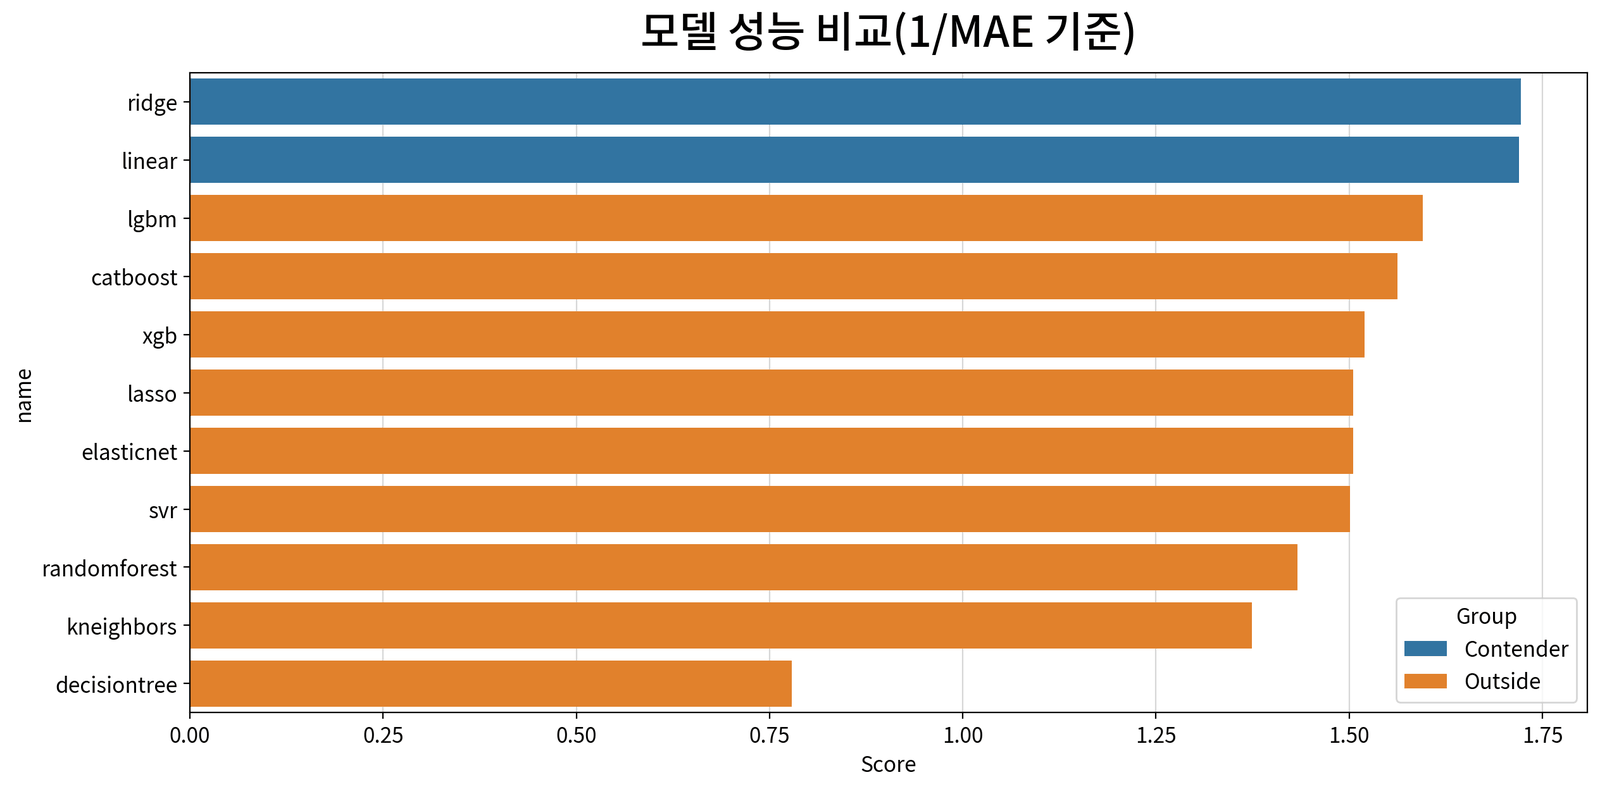


모델 11개 학습·저장 완료 → sales_prediction_proj\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,MAE_Gap,Score
name,,,,,,,,,,,,
ridge,1,Contender,Ridge,0.143990,0.580703,0.654024,0.808717,0.060927,0.047091,-0.016071,0.000,1.722050
linear,2,Contender,LinearRegression,0.144596,0.581483,0.653561,0.808431,0.060902,0.047148,-0.016370,0.001,1.719741
lgbm,3,Outside,LGBMRegressor,0.070665,0.626925,0.710047,0.842643,0.062970,0.050346,-0.011759,0.080,1.595086
catboost,4,Outside,CatBoostRegressor,0.087206,0.640003,0.697409,0.835110,0.062299,0.050798,0.002975,0.102,1.562493
xgb,5,Outside,XGBRegressor,0.036965,0.658003,0.735795,0.857785,0.063952,0.052492,-0.007411,0.133,1.519750
lasso,6,Outside,Lasso,-0.004866,0.664298,0.767756,0.876217,0.065520,0.053372,-0.009726,0.144,1.505348
elasticnet,7,Outside,ElasticNet,-0.004866,0.664298,0.767756,0.876217,0.065520,0.053372,-0.009726,0.144,1.505348
svr,8,Outside,SVR,0.000283,0.666193,0.763822,0.873969,0.065244,0.053331,-0.006738,0.147,1.501067
randomforest,9,Outside,RandomForestRegressor,-0.086951,0.697695,0.830472,0.911302,0.067240,0.054556,0.012650,0.201,1.433290


[통합 순위표] MAE(원화 오차) 기준 모델 평가 순위


,MAE(원),RMSE(원)
ML: ridge,269120.0,411020.0
ML: linear,270316.0,411512.0
베이스라인3: 학습구간 요일별 중앙값,274446.0,422479.0
ML: catboost,287686.0,442541.0
ML: lgbm,297999.0,441458.0
ML: elasticnet,310004.0,456324.0
ML: lasso,310004.0,456324.0
ML: randomforest,311726.0,477282.0
ML: xgb,311786.0,452184.0
ML: svr,312370.0,462673.0


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
# =========================================================================
# 1. 이전 단계에서 전처리 완료 및 저장된 최종 데이터셋 불러오기
# =========================================================================
df_final = pd.read_excel("final_selected_dataset.xlsx")


#모델링전 데이터 타입변환
print("my_qtcheck.set_type 모듈을 통한 데이터 타입 변환 적용 (category 타입):")
df_final = my_qtcheck.set_type(
    df_final,
    as_float=num_cols,
    as_category=cat_cols
)

# 독립변수(X) 및 종속변수(y) 분리
X = df_final.drop(columns=["매출액"])
y = df_final["매출액"]

# =========================================================================
# 2. 시계열 순차 Split (무작위 셔플 금지: shuffle=False, 8:2 비율)
# =========================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("=" * 70)
print(f"시계열 데이터 분할 완료")
print(f"   - Train Set: {X_train.shape[0]}행 x {X_train.shape[1]}열 (시작~80% 구간)")
print(f"   - Test Set : {X_test.shape[0]}행 x {X_test.shape[1]}열 (최근 20% 구간)")
print("=" * 70)

# =========================================================================
# 3. 최소 달성 기준선(단순 기준선 3종) 원화 오차 평가
# =========================================================================
# (1) 실제 매출(원) 복원
y_test_won = np.exp(y_test)

# (2) 단순 베이스라인 3종 예측값 생성 (원 단위 복원)
base_mean = np.full(len(y_test), np.exp(y_train).mean())  # 베이스라인 1: 학습구간 전체 평균
base_dow = np.exp(X_test["dow_ma4"])                       # 베이스라인 2: 같은 요일 최근 4주 평균
# 베이스라인 3: 학습구간 요일별 중앙값 (요일 정보만으로 얻을 수 있는 성능 → 모델의 '요일 외' 부가가치 판정 기준)
dow_median_won = np.exp(y_train).groupby(X_train["요일"].astype(int)).median()
base_dow_median = X_test["요일"].astype(int).map(dow_median_won).values

# (3) 단순 베이스라인 원화 오차 평가표 생성
baseline_table = pd.DataFrame(
    {
        "MAE(원)": [
            mean_absolute_error(y_test_won, base_mean),
            mean_absolute_error(y_test_won, base_dow),
            mean_absolute_error(y_test_won, base_dow_median),
        ],
        "RMSE(원)": [
            root_mean_squared_error(y_test_won, base_mean),
            root_mean_squared_error(y_test_won, base_dow),
            root_mean_squared_error(y_test_won, base_dow_median),
        ],
    },
    index=["베이스라인1: 전체 평균", "베이스라인2: 같은 요일 최근 4주 평균", "베이스라인3: 학습구간 요일별 중앙값"],
).round(0)

print("\n[설계안 2-A] 머신러닝 모델이 반드시 이겨야 하는 최소 기준선:")
display(baseline_table)

# =========================================================================
# 1. my_ml.reg_baseline 실행 (Primary=MAE 설정)
# =========================================================================
PROJECT_NAME = "sales_prediction_proj"

# 실행 방식 선택 (학습에 시간이 오래 걸리므로 저장된 결과를 재사용할 수 있다)
#   True  : 11종 베이스라인을 새로 학습하고 sales_prediction_proj/baseline/*.pkl 로 저장
#   False : 이미 저장된 .pkl 을 그대로 사용 (학습 생략)
#   ※ 데이터나 전처리(5장)를 바꾼 뒤에는 반드시 True 로 한 번 다시 학습할 것
#   ※ 저장된 .pkl 이 하나도 없으면 False 여도 자동으로 새로 학습한다
RUN_BASELINE = True   # 5.3 시차 변수 재구성으로 재학습 필요 (한 번 실행 후 False 로 바꾸면 재사용)

if RUN_BASELINE or not any((Path(PROJECT_NAME) / "baseline").glob("*.pkl")):
    # MAE를 주 지표로 변경하여 베이스라인 모델 학습/평가
    baseline_scores = my_ml.reg_baseline(
        project_name=PROJECT_NAME,
        x_train=X_train,
        y_train=y_train,
        x_test=X_test,
        y_test=y_test,
        primary="MAE",            # MAE를 주 지표로 지정
        aux=["RMSE", "R2"],       # RMSE, R2를 보조 지표로 지정
        plot=True,
        verbose=True
    )
else:
    print("저장된 베이스라인 모델(.pkl)을 재사용합니다. (새로 학습하려면 RUN_BASELINE = True)")
    # 저장된 모델로 순위표만 다시 계산 (학습 없이 테스트 세트 평가만 수행)
    baseline_scores = my_ml.reg_compare_models(
        {p.stem: my_ml.load_model(p) for p in sorted((Path(PROJECT_NAME) / "baseline").glob("*.pkl"))},
        X_test, y_test, primary="MAE", aux=["RMSE", "R2"], verbose=False,
    )
    display(baseline_scores)

# =========================================================================
# 2. 원화(KRW) 환산 및 MAE 기준 통합 비교표 작성
# =========================================================================
baseline_dir = Path(PROJECT_NAME) / "baseline"


def evaluate_won(model_dir, prefix, with_r2=False):
    """모델 폴더의 .pkl 을 모두 불러와 테스트 세트의 원화 MAE·RMSE(와 로그 R2)를 계산한다.

    Args:
        model_dir (str | Path): .pkl 파일이 저장된 폴더
        prefix (str): 결과표 행 이름 앞에 붙일 구분자 (예: "ML", "Tuned")
        with_r2 (bool): 로그 스케일 R2 를 함께 계산할지 여부

    Returns:
        DataFrame: '모델 구분'을 인덱스로 하는 오차표
    """
    rows = []
    for pkl_file in sorted(Path(model_dir).glob("*.pkl")):
        model = my_ml.load_model(pkl_file)

        # 로그 예측값 → 원화 예측값 복원 → 오차 계산
        y_pred_log = model.predict(X_test)
        y_pred_won = np.exp(y_pred_log)
        row = {
            "모델 구분": f"{prefix}: {pkl_file.stem}",
            "MAE(원)": round(mean_absolute_error(y_test_won, y_pred_won)),
            "RMSE(원)": round(root_mean_squared_error(y_test_won, y_pred_won)),
        }
        if with_r2:
            row["R2(로그)"] = round(r2_score(y_test, y_pred_log), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("모델 구분")


df_ml_results = evaluate_won(baseline_dir, "ML")

# 단순 베이스라인 3종(baseline_table)과 ML 모델 결과 통합 및 MAE 기준 정렬
final_comparison_mae = pd.concat([baseline_table, df_ml_results]).sort_values(by="MAE(원)")

print("=" * 75)
print("[통합 순위표] MAE(원화 오차) 기준 모델 평가 순위")
print("=" * 75)
display(final_comparison_mae)

In [36]:
# 6.1에서 저장한 베이스라인 모델(.pkl)을 모델 이름(name_)으로 불러온다
models = {}                                          # 모델명과 모델 객체를 저장할 딕셔너리
for p in sorted(baseline_dir.glob("*.pkl")):         # 베이스라인 폴더의 pkl 파일 경로 목록
    model = my_ml.load_model(p)                      # 모델 로드
    models[model.name_] = model                      # 모델명과 모델 객체를 딕셔너리에 저장

# 로드된 모델과 모델 객체의 타입 출력
for name, model in models.items():
    print(f"- {name}: {type(model)}")

- catboost: <class 'sklearn.pipeline.Pipeline'>
- decisiontree: <class 'sklearn.pipeline.Pipeline'>
- elasticnet: <class 'sklearn.pipeline.Pipeline'>
- kneighbors: <class 'sklearn.pipeline.Pipeline'>
- lasso: <class 'sklearn.pipeline.Pipeline'>
- lgbm: <class 'sklearn.pipeline.Pipeline'>
- linear: <class 'sklearn.pipeline.Pipeline'>
- randomforest: <class 'sklearn.pipeline.Pipeline'>
- ridge: <class 'sklearn.pipeline.Pipeline'>
- svr: <class 'sklearn.pipeline.Pipeline'>
- xgb: <class 'sklearn.pipeline.Pipeline'>


In [37]:
score_table = my_ml.reg_compare_models(models,    # 모델 객체들을 담은 딕셔너리
                         X_test,                  # 검증 데이터의 독립 변수 (학습데이터 사용하면 안됨!)
                         y_test,                  # 검증 데이터의 종속 변수 (학습데이터 사용하면 안됨!)
                         primary="MAE",           # 주 지표
                         aux=["RMSE", "R2"])            # 보조 지표 


◆ Score Table Ranking : primary='MAE', aux=['RMSE', 'R2']

▲ step1: 주 지표(MAE) 기준 정렬 — 낮을수록 좋음 (ASC)
    1. ridge          MAE   =            0.581
    2. linear         MAE   =            0.581
    3. lgbm           MAE   =            0.627
    4. catboost       MAE   =            0.640
    5. xgb            MAE   =            0.658
    6. elasticnet     MAE   =            0.664
    7. lasso          MAE   =            0.664
    8. svr            MAE   =            0.666
    9. randomforest   MAE   =            0.698
   10. kneighbors     MAE   =            0.728
   11. decisiontree   MAE   =            1.284

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
   - 1등 MAE    : 0.581
   - 허용 범위    : MAE ≤ 0.610
   - 근소 격차 그룹 (2) : ['ridge', 'linear']
   - 그룹 외부     (9) : ['lgbm', 'catboost', 'xgb', 'elasticnet', 'lasso', 'svr', 'randomforest', 'kneighbors', 'decisiontree']

▲ step3: 보조 지표 결정적 결함 점검 (근소 격차 그룹 내부)
       · RMSE   best=     0.808   결함조건: row > 0.889
       · R2     best=     0.145   결함조건: 

#### 6.1.4 기준선·기본 모델 평가 결과

##### 1) 결과 요약
* **단순 기준선보다 나은 모델**: 학습 구간 전체 평균(`베이스라인 1`, MAE 325,578원)에 비해 `Ridge`(269,120원)와 `Linear`(270,316원)는 오차를 **약 17% 줄였습니다.** 반면 `KNN`(351,865원)과 `DecisionTree`(433,009원)는 기본 설정에서 베이스라인 1·2보다도 오차가 컸습니다.
* **요일 기준선(베이스라인 3)과의 비교**: 요일별 중앙값만으로 예측한 `베이스라인 3`의 MAE는 **274,446원**으로, `Ridge`(269,120원)와 **5,326원(약 1.9%)** 차이입니다. 전체 평균 대비 줄어든 오차 56,458원 중 약 91%(51,132원)는 요일만으로 얻을 수 있는 몫이고 요일 외 변수가 더한 몫은 약 9%입니다. 또한 11종 중 `Ridge`와 `Linear`를 뺀 9종은 요일 기준선보다도 오차가 컸습니다. 이 차이가 우연인지는 6.3.3에서 검정합니다.
  * 같은 요일을 보는 `베이스라인 2`(최근 4주 평균, 325,533원)는 `베이스라인 3`보다 크게 부정확하고, 요일을 보지 않는 `베이스라인 1`과 비슷한 수준입니다. 참고하는 날이 4일뿐이라 단체 손님 같은 튀는 날 하나에 예측이 크게 흔들리기 때문입니다. 이 매장은 매출 수준이 크게 변하기보다 하루하루 들쭉날쭉한 편이라 최근 흐름보다 요일별 평소 수준이 더 안정적인 예측 근거가 됩니다.
* **로그 기준 순위**: 모듈 순위표(로그 MAE 기준)에서는 `Ridge`, `Linear` 2개만 근소 격차 그룹에 들었습니다. 11종 모두 기본 설정으로 학습한 결과입니다.

##### 2) 다음 단계 계획
* **하이퍼파라미터 튜닝(6.2)**: 11종 모두 핵심 하이퍼파라미터(선형 모델의 규제 강도 `alpha`·`l1_ratio`, 거리 기반 모델의 `n_neighbors`·`C`·`gamma`, 트리 계열의 `max_depth`·`learning_rate`·`n_estimators` 등)를 탐색합니다. 탐색에는 시간 순서를 지키는 `TimeSeriesSplit(n_splits=5)` 교차검증을 사용합니다.
* **후보 선정(6.2.2)**: 테스트 구간이 아니라 학습 구간 교차검증의 원화 MAE로 근소 격차 그룹을 다시 고릅니다.
* **과적합 진단과 최종 선정(6.3)**: 후보 모델의 훈련·교차검증 성능 차이로 과적합을 진단하고(`my_diag.overfit`), 통과한 모델 중에서 최종 모델을 고릅니다(6.3.1). 테스트 구간은 최종 확인에만 쓰고 SHAP은 선정 이후 해석(6.4)에 씁니다.
* **요일 기준선 검정(6.3.3)**: 최종 모델이 `베이스라인 3`보다 정말 나은지 날짜별 대응 검정·폴드별 비교·날짜 유형별 분해로 확인합니다.

### 6.2 전 모델 하이퍼파라미터 튜닝 (11종)

#### 1) 시계열 K-Fold 교차검증 (`TimeSeriesSplit`) 적용
* **데이터 누수 없는 그리드 탐색**: 
  튜닝 과정에서 일반 K-Fold를 사용하면 미래 데이터가 과거 훈련셋에 유입되므로 이를 방지하려고 **`TimeSeriesSplit(n_splits=5)`**를 `cv` 파라미터로 지정해 시계열 분할의 엄격성을 유지합니다.

#### 2) `my_ml.reg_tunes` 모듈 기반 전 모델 하이퍼파라미터 탐색
* **11종 선형·비선형·앙상블 알고리즘 최적화**: 
  6.1 단계에서 저장된 베이스라인 `.pkl` 객체를 로드해 선형 모델의 규제 계수(`alpha`, `l1_ratio`), 거리 기반 모델(`n_neighbors`, `C`, `gamma`), 트리/앙상블 모델(`max_depth`, `learning_rate`, `n_estimators` 등)을 일괄 그리드 탐색합니다.
* **주 평가지표(`MAE`) 기준 최적 파이프라인 자동 직렬화**: 
  `MAE` 기준 최적 하이퍼파라미터로 조합된 파이프라인 객체는 `sales_prediction_proj/tuned/` 디렉토리에 `.pkl` 파일로 자동 저장됩니다.

베이스라인 모델 11개 로드 완료: ['catboost', 'decisiontree', 'elasticnet', 'kneighbors', 'lasso', 'lgbm', 'linear', 'randomforest', 'ridge', 'svr', 'xgb']
작업 폴더: sales_prediction_proj\tuned
탐색 범위: 실무용


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
2 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 649, in fit
    self._final_estimator.fit(

탐색 완료 [ 1/11] : catboost (1719.1초, CV MAE=0.6095)
    최적 조합: {'model__depth': 10, 'model__iterations': 500, 'model__learning_rate': 0.03}


탐색 완료 [ 2/11] : decisiontree (0.3초, CV MAE=0.6180)
    최적 조합: {'model__max_depth': 4, 'model__min_samples_leaf': 20}


탐색 완료 [ 3/11] : elasticnet (0.3초, CV MAE=0.5734)
    최적 조합: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}


...

탐색 완료 [ 6/11] : lgbm (1.2초, CV MAE=0.6446)
    최적 조합: {'model__learning_rate': 0.03, 'model__n_estimators': 300, 'model__num_leaves': 31}
탐색 완료 [ 7/11] : linear (0.1초, CV MAE=0.5707)
    최적 조합: {'model__fit_intercept': True, 'model__positive': True}


탐색 완료 [ 8/11] : randomforest (3.4초, CV MAE=0.5934)
    최적 조합: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}


탐색 완료 [ 9/11] : ridge (0.3초, CV MAE=0.5704)
    최적 조합: {'model__alpha': 10.0, 'model__solver': 'auto'}


탐색 완료 [10/11] : svr (0.4초, CV MAE=0.5731)
    최적 조합: {'model__C': 1.0, 'model__epsilon': 0.2, 'model__gamma': 0.01}


탐색 완료 [11/11] : xgb (273.8초, CV MAE=0.6569)
    최적 조합: {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 300}


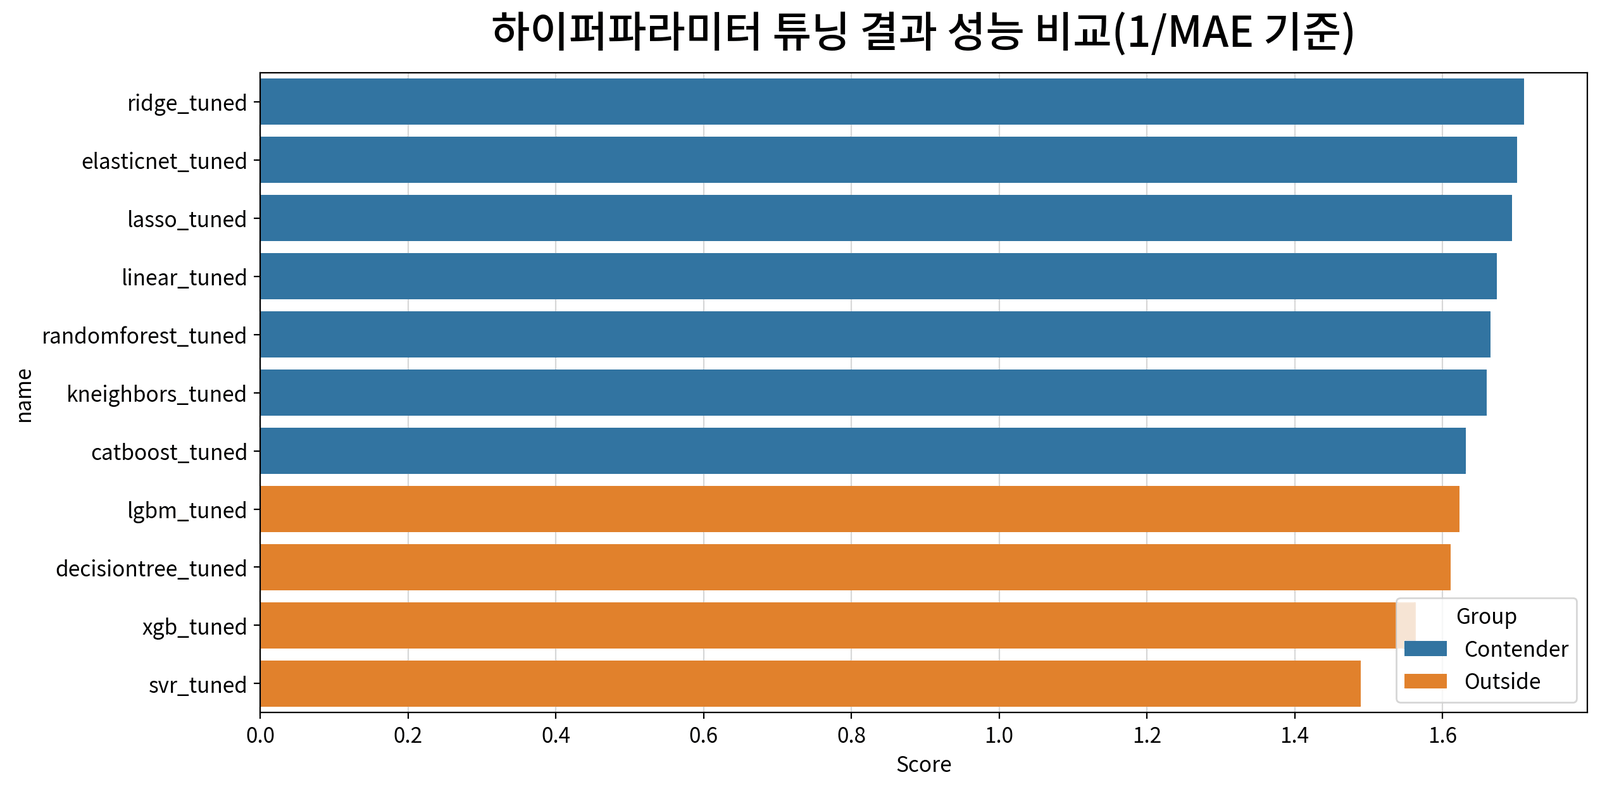


모델 11개 튜닝·저장 완료 → sales_prediction_proj\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,MAE_Gap,Score
name,,,,,,,,,,,,
ridge_tuned,1,Contender,Ridge,0.128783,0.584635,0.665643,0.815869,0.061468,0.047462,-0.016618,0.000,1.710468
elasticnet_tuned,2,Contender,ElasticNet,0.117193,0.587899,0.674498,0.821278,0.061887,0.047808,-0.018710,0.006,1.700973
lasso_tuned,3,Contender,Lasso,0.112051,0.590356,0.678427,0.823667,0.062063,0.048044,-0.020414,0.010,1.693894
linear_tuned,4,Contender,LinearRegression,0.091823,0.597611,0.693882,0.832996,0.062745,0.048697,-0.022339,0.022,1.673330
randomforest_tuned,5,Contender,RandomForestRegressor,0.141207,0.600493,0.656150,0.810031,0.060772,0.048236,-0.008377,0.027,1.665297
kneighbors_tuned,6,Contender,KNeighborsRegressor,0.114238,0.602553,0.676756,0.822652,0.061803,0.048627,-0.012695,0.031,1.659606
catboost_tuned,7,Contender,CatBoostRegressor,0.124712,0.612873,0.668753,0.817773,0.061158,0.048937,-0.002422,0.048,1.631660
lgbm_tuned,8,Outside,LGBMRegressor,0.095781,0.616151,0.690857,0.831178,0.062144,0.049518,-0.012433,0.054,1.622979
decisiontree_tuned,9,Outside,DecisionTreeRegressor,0.126992,0.620856,0.667011,0.816708,0.061028,0.049656,-0.009211,0.062,1.610679



[최종 통합 순위표] 튜닝 전/후 MAE(원화 오차) 기준 모델 비교


,MAE(원),RMSE(원)
ML: ridge,269120.0,411020.0
Tuned: ridge_tuned,269942.0,411563.0
ML: linear,270316.0,411512.0
Tuned: elasticnet_tuned,271623.0,409697.0
Tuned: lasso_tuned,273939.0,409271.0
베이스라인3: 학습구간 요일별 중앙값,274446.0,422479.0
Tuned: linear_tuned,277650.0,409385.0
Tuned: randomforest_tuned,279492.0,429722.0
Tuned: kneighbors_tuned,280213.0,429571.0
Tuned: catboost_tuned,282867.0,438505.0


In [38]:
from sklearn.model_selection import TimeSeriesSplit

# =========================================================================
# 1. 6.1 단계에서 저장된 11종 베이스라인 모델(.pkl) 일괄 로드
# =========================================================================
#   (PROJECT_NAME, baseline_dir 은 6.1 셀에서 정의한 것을 그대로 사용)
models = {p.stem: my_ml.load_model(p) for p in sorted(baseline_dir.glob("*.pkl"))}

print(f"베이스라인 모델 {len(models)}개 로드 완료: {list(models.keys())}")

# =========================================================================
# 2. 시계열 교차검증 분할기 설정
# =========================================================================
tscv = TimeSeriesSplit(n_splits=5)

# =========================================================================
# 3. my_ml.reg_tunes 모듈을 통한 11개 전 모델 하이퍼파라미터 튜닝 실행
# =========================================================================
# 실행 방식 선택 (그리드 탐색은 수십 분 걸리므로 저장된 결과를 재사용할 수 있다)
#   True  : 11종 전체를 다시 그리드 탐색하고 sales_prediction_proj/tuned/*.pkl 로 저장
#   False : 이미 저장된 튜닝 결과(.pkl)를 그대로 사용 (탐색 생략)
#   ※ 베이스라인을 새로 학습했거나 데이터·전처리를 바꾼 뒤에는 반드시 True 로 다시 탐색할 것
#   ※ 저장된 .pkl 이 하나도 없으면 False 여도 자동으로 새로 탐색한다
RUN_TUNING = True   # 5.3 시차 변수 재구성으로 재학습 필요 (한 번 실행 후 False 로 바꾸면 재사용)

if RUN_TUNING or not any((Path(PROJECT_NAME) / "tuned").glob("*.pkl")):
    # MAE를 주 평가지표로 지정하여 그리드 탐색 수행
    tuned_scores = my_ml.reg_tunes(
        project_name=PROJECT_NAME,
        models=models,
        x_train=X_train,
        y_train=y_train,
        x_test=X_test,
        y_test=y_test,
        primary="MAE",            # 주 평가지표 MAE
        aux=["RMSE", "R2"],       # 보조 평가지표
        cv=tscv,                  # 시계열 교차검증 분할기
        practice=False,           # Full Grid Search 탐색
        n_jobs=-1,                # 멀티프로세싱 탐색
        workdir="tuned",          # sales_prediction_proj/tuned/ 아래 저장
        plot=True,
        verbose=True
    )
else:
    print("저장된 튜닝 모델(.pkl)을 재사용합니다. (새로 탐색하려면 RUN_TUNING = True)")
    # 저장된 튜닝 모델로 순위표만 다시 계산 (탐색 없이 테스트 세트 평가만 수행)
    tuned_scores = my_ml.reg_compare_models(
        {p.stem: my_ml.load_model(p) for p in sorted((Path(PROJECT_NAME) / "tuned").glob("*.pkl"))},
        X_test, y_test, primary="MAE", aux=["RMSE", "R2"], verbose=False,
    )
    display(tuned_scores)

# =========================================================================
# 4. 튜닝 완료 모델(.pkl) 원화(KRW) 오차 환산 및 베이스라인과 통합 비교
# =========================================================================
tuned_dir = Path(PROJECT_NAME) / "tuned"
df_tuned_results = evaluate_won(tuned_dir, "Tuned")

# [단순 베이스라인 3종] + [ML 베이스라인 11종] + [Tuned ML 11종] 통합 비교
final_tuned_comparison = pd.concat([baseline_table, df_ml_results, df_tuned_results]).sort_values(by="MAE(원)")

print("\n" + "=" * 75)
print("[최종 통합 순위표] 튜닝 전/후 MAE(원화 오차) 기준 모델 비교")
print("=" * 75)
display(final_tuned_comparison)

In [39]:
# =========================================================================
# 4. 튜닝 완료 모델(.pkl) 원화(KRW) 오차 환산 및 베이스라인과 통합 비교 (로그 R2 포함)
# =========================================================================
df_tuned_results = evaluate_won(tuned_dir, "Tuned", with_r2=True)

# ML 베이스라인 11종에도 R2(로그)를 산출해 붙인다.
# (누락 시 NaN 이 되어 4단계 랭킹의 보조 지표 점검에서 '결함'으로 잘못 판정됨)
df_ml_results["R2(로그)"] = evaluate_won(baseline_dir, "ML", with_r2=True)["R2(로그)"]

# [단순 베이스라인 3종] + [ML 베이스라인 11종] + [Tuned ML 11종] 통합 비교
final_tuned_comparison = pd.concat([baseline_table, df_ml_results, df_tuned_results]).sort_values(by="MAE(원)")

print("\n" + "=" * 75)
print("[최종 통합 순위표] 튜닝 전/후 MAE(원화 오차) 기준 모델 비교")
print("=" * 75)
display(final_tuned_comparison)


[최종 통합 순위표] 튜닝 전/후 MAE(원화 오차) 기준 모델 비교


,MAE(원),RMSE(원),R2(로그)
ML: ridge,269120.0,411020.0,0.1440
Tuned: ridge_tuned,269942.0,411563.0,0.1288
ML: linear,270316.0,411512.0,0.1446
Tuned: elasticnet_tuned,271623.0,409697.0,0.1172
Tuned: lasso_tuned,273939.0,409271.0,0.1121
베이스라인3: 학습구간 요일별 중앙값,274446.0,422479.0,NaN
Tuned: linear_tuned,277650.0,409385.0,0.0918
Tuned: randomforest_tuned,279492.0,429722.0,0.1412
Tuned: kneighbors_tuned,280213.0,429571.0,0.1142
Tuned: catboost_tuned,282867.0,438505.0,0.1247


In [40]:
# =========================================================================
# 5. 통합 순위표 — 4단계 랭킹 전략 (주 지표 MAE / 보조 지표 RMSE·R2)
# =========================================================================

# (1) reg_compare_models 와 동일한 지표 메타데이터 (임계치도 같게 유지)
metric_specs = {
    'R2':    {'better': 'higher',         'flaw_type': 'abs_drop',   'threshold': 0.05},
    'MAE':   {'better': 'lower',          'flaw_type': 'rel_excess', 'threshold': 0.10},
    'MSE':   {'better': 'lower',          'flaw_type': 'rel_excess', 'threshold': 0.10},
    'RMSE':  {'better': 'lower',          'flaw_type': 'rel_excess', 'threshold': 0.10},
    'RMSLE': {'better': 'lower',          'flaw_type': 'rel_excess', 'threshold': 0.10},
    'MAPE':  {'better': 'lower',          'flaw_type': 'rel_excess', 'threshold': 0.10},
    'MPE':   {'better': 'closer_to_zero', 'flaw_type': 'abs_excess', 'threshold': 0.05},
}

# (2) 열 이름을 metric_specs 키에 맞춘다 (값은 그대로: MAE·RMSE=원화, R2=로그)
score_input = final_tuned_comparison.rename(
    columns={"MAE(원)": "MAE", "RMSE(원)": "RMSE", "R2(로그)": "R2"}
)[["MAE", "RMSE", "R2"]].copy()

# (3) Model 컬럼: pkl 에서 실제 모델 클래스명을 꺼낸다 (단순 베이스라인은 'Baseline')
def _model_class(pkl_path):
    model, _, _, _ = my_ml._unwrap_estimator(my_ml.load_model(pkl_path))
    return type(model).__name__

model_names = {}
for pkl in sorted((Path(PROJECT_NAME) / "baseline").glob("*.pkl")):
    model_names[f"ML: {pkl.stem}"] = _model_class(pkl)
for pkl in sorted((Path(PROJECT_NAME) / "tuned").glob("*.pkl")):
    model_names[f"Tuned: {pkl.stem}"] = _model_class(pkl)

score_input.insert(0, "Model", [model_names.get(i, "Baseline") for i in score_input.index])
score_input.index.name = "name"

# (4) 4단계 랭킹 (판정 과정 출력)
ranked_table = my_ml._rank_score_table(
    score_input, metric_specs, primary="MAE", aux=["RMSE", "R2"], verbose=True
)

# (5) 최종 순위표 출력
display(ranked_table.style.format({
    "MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.4f}",
    "MAE_Gap": "{:.3f}", "Score": "{:.3e}",
}, na_rep="-"))


◆ Score Table Ranking : primary='MAE', aux=['RMSE', 'R2']

▲ step1: 주 지표(MAE) 기준 정렬 — 낮을수록 좋음 (ASC)
    1. ML: ridge      MAE   =       269120.000
    2. Tuned: ridge_tuned MAE   =       269942.000
    3. ML: linear     MAE   =       270316.000
    4. Tuned: elasticnet_tuned MAE   =       271623.000
    5. Tuned: lasso_tuned MAE   =       273939.000
    6. 베이스라인3: 학습구간 요일별 중앙값 MAE   =       274446.000
    7. Tuned: linear_tuned MAE   =       277650.000
    8. Tuned: randomforest_tuned MAE   =       279492.000
    9. Tuned: kneighbors_tuned MAE   =       280213.000
   10. Tuned: catboost_tuned MAE   =       282867.000
   11. ML: catboost   MAE   =       287686.000
   12. Tuned: xgb_tuned MAE   =       291522.000
   13. Tuned: lgbm_tuned MAE   =       293026.000
   14. Tuned: decisiontree_tuned MAE   =       293721.000
   15. ML: lgbm       MAE   =       297999.000
   16. ML: elasticnet MAE   =       310004.000
   17. ML: lasso      MAE   =       310004.000
   18. ML: randomforest MAE  

,Rank,Group,Model,MAE,RMSE,R2,MAE_Gap
name,,,,,,,
ML: ridge,1,Contender,Ridge,"269,120","411,020",0.1440,0.000
Tuned: ridge_tuned,2,Contender,Ridge,"269,942","411,563",0.1288,0.003
ML: linear,3,Contender,LinearRegression,"270,316","411,512",0.1446,0.004
Tuned: elasticnet_tuned,4,Contender,ElasticNet,"271,623","409,697",0.1172,0.009
Tuned: lasso_tuned,5,Contender,Lasso,"273,939","409,271",0.1121,0.018
Tuned: randomforest_tuned,6,Contender,RandomForestRegressor,"279,492","429,722",0.1412,0.039
Tuned: kneighbors_tuned,7,Contender,KNeighborsRegressor,"280,213","429,571",0.1142,0.041
베이스라인3: 학습구간 요일별 중앙값,8,Contender,Baseline,"274,446","422,479",-,0.020
Tuned: linear_tuned,9,Contender,LinearRegression,"277,650","409,385",0.0918,0.032


#### 6.2.1 하이퍼파라미터 튜닝 결과 해석

##### 1) 기준선과의 비교 (테스트 구간, 원 단위)
* **단순 기준선 대비**: `베이스라인 1`(전체 평균, 325,578원), `베이스라인 2`(최근 4주 같은 요일 평균, 325,533원)에 비해 상위 모델들은 오차를 **26만~28만 원대(269,120원 ~ 280,213원)**로 낮춰 약 14~17% 줄였습니다.
* **요일 기준선 대비**: `베이스라인 3`(요일별 중앙값, 274,446원)보다 오차가 작은 튜닝 모델은 `Tuned: ridge`(269,942원), `Tuned: elasticnet`(271,623원), `Tuned: lasso`(273,939원) 3개뿐이고, 차이도 2% 이내입니다.

##### 2) 튜닝 전후 MAE 변화 (테스트 구간, 원 단위)

| 모델 | 튜닝 전 MAE(원) | 튜닝 후 MAE(원) | 변화(원) | 비고 |
| :--- | ---: | ---: | ---: | :--- |
| DecisionTree | 433,009 | 293,721 | **−139,288** | `max_depth=4`, `min_samples_leaf=20`으로 과적합을 줄임 |
| KNN | 351,865 | 280,213 | **−71,652** | `n_neighbors=30`, 맨해튼 거리, 균등 가중 |
| ElasticNet | 310,004 | 271,623 | **−38,381** | 규제 `alpha` 1.0 → 0.01 |
| Lasso | 310,004 | 273,939 | **−36,065** | 규제 `alpha` 1.0 → 0.001 |
| RandomForest | 311,726 | 279,492 | −32,234 | `max_depth=10`, `min_samples_leaf=5` |
| XGBoost | 311,786 | 291,522 | −20,264 | |
| LightGBM | 297,999 | 293,026 | −4,973 | |
| CatBoost | 287,686 | 282,867 | −4,819 | |
| Ridge | 269,120 | 269,942 | +822 | `alpha` 1.0 → 10.0, 사실상 같음 |
| SVR | 312,370 | 315,184 | +2,814 | 튜닝 후 조금 나빠짐 |
| Linear | 270,316 | 277,650 | +7,334 | `positive=True`(계수를 0 이상으로 제한)가 선택되며 나빠짐 |

* **규제가 너무 셌던 모델이 크게 좋아짐**: `Lasso`·`ElasticNet`은 기본 규제(`alpha=1.0`)가 너무 커서 성능이 낮았는데, 규제를 줄이자 3만~4만 원 개선되었습니다. 트리 계열도 깊이·잎 크기를 제한하자 크게 좋아졌습니다.
* **튜닝 효과가 없던 모델**: `Ridge`, `SVR`, `Linear`는 튜닝 후 테스트 MAE가 오히려 늘었습니다. 튜닝은 학습 구간 교차검증 성능으로 파라미터를 고르므로, 교차검증에서 개선되더라도 그 개선이 테스트 구간으로 그대로 이어지지 않을 수 있습니다.

##### 3) 통합 순위표 4단계 랭킹 결과 (테스트 구간, 원 단위)
* **근소 격차 그룹 (1위 MAE의 5% 이내, ≤ 282,576원)**: 모델 8개(`ML: ridge`, `Tuned: ridge`, `ML: linear`, `Tuned: elasticnet`, `Tuned: lasso`, `Tuned: linear`, `Tuned: randomforest`, `Tuned: kneighbors`)와 **`베이스라인 3`(요일 기준선)까지 총 9개**입니다. 요일만 보는 기준선이 상위 모델과 같은 그룹에 들어올 만큼 모델들의 차이가 작다는 뜻입니다.
* **보조 지표 점검**: RMSE 기준(그룹 최솟값 409,271원의 110%, 450,198원)과 R² 기준(그룹 최댓값 0.145 − 0.05 = 0.095)으로 점검한 결과, `Tuned: linear`(R² 0.0918)와 `베이스라인 3`(R² 값 없음)이 결함 1개로 판정되어 그룹 안 뒤쪽으로 밀렸습니다.
* **최종 순위**: ① `ML: ridge`(269,120원) ② `Tuned: ridge`(269,942원) ③ `ML: linear`(270,316원) ④ `Tuned: elasticnet` ⑤ `Tuned: lasso` ⑥ `Tuned: randomforest` ⑦ `Tuned: kneighbors` ⑧ `베이스라인 3` ⑨ `Tuned: linear`
  * ※ 이 순위는 테스트 구간 기준이라 참고용입니다. 테스트 구간으로 모델을 고르면 최종 성능이 낙관적으로 나오므로, 다음 6.2.2에서 학습 구간 교차검증으로 후보를 다시 고릅니다.

#### 6.2.2 교차검증 기준 근소 격차 그룹 선정

6.2.1의 순위는 테스트 세트 MAE 기준입니다. 테스트 세트로 모델을 고르면 최종 성능 평가가 낙관적으로 편향되므로, 과적합 진단 대상(근소 격차 그룹)은 학습 구간의 시계열 교차검증 성능으로 다시 정합니다.

* **대상**: 베이스 11종 + 튜닝 11종 (튜닝 모델은 탐색 결과에서 최적 파이프라인을 꺼내 사용)
* **평가**: 6.2의 `tscv`(5겹)로 CV MAE·RMSE는 프로젝트 주 지표와 같은 **원화 기준**으로, R²는 로그 기준으로 산출합니다. 로그 MAE는 비율 오차에 가깝고 원화 MAE는 매출이 큰 날의 오차에 더 민감하므로 두 기준의 순위가 다를 수 있는데, 근소 격차 그룹은 주 지표인 원화 MAE로 정합니다. (`CV_SCALE = "log"`로 바꾸면 로그 기준으로도 확인할 수 있습니다.)
* **순위**: 6.2와 같은 4단계 랭킹(`my_ml._rank_score_table`)을 적용하며, 주 지표는 CV MAE(원), 보조 지표는 CV RMSE(원)·R²(로그)입니다.
* **연결**: 여기서 만들어진 `cv_contenders` 목록이 6.3 과적합 진단 대상이 됩니다.
* **과적합 판정 척도**: 6.3의 과적합 판정(Gap%)은 훈련·검증 성능의 비율 비교라 척도의 영향이 작으므로 로그 기준을 그대로 사용합니다.

In [41]:
# =========================================================================
# 6.2.2 교차검증(CV) 기준 근소 격차 그룹 선정
# =========================================================================
# 모델 선택에 테스트 세트를 쓰지 않도록, 22개 ML 모델(베이스 11 + 튜닝 11)을
# 학습 구간의 TimeSeriesSplit(tscv) 교차검증 성능으로 다시 순위화한다.
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

# 순위 기준 척도 선택
#   "won" : 원화로 되돌린 CV MAE·RMSE 기준 (프로젝트 주 지표 MAE(원)와 같은 척도, R2 는 로그 유지) ← 본 보고서 기준
#   "log" : 로그 매출 기준 CV 지표 (6.2 그리드 탐색의 기준과 동일, 참고용)
CV_SCALE = "won"

# 실행 방식 선택 (22개 모델 교차검증은 오래 걸리므로 계산 결과를 저장해 재사용할 수 있다)
#   True  : 교차검증을 새로 수행하고 결과표를 sales_prediction_proj/cv_table_{척도}.pkl 로 저장
#   False : 저장된 결과표를 불러와 사용
#   ※ 베이스라인·튜닝 모델을 새로 만든 뒤에는 반드시 True 로 다시 계산할 것
#   ※ 저장된 결과표가 없으면 False 여도 자동으로 새로 계산한다
RUN_CV = True   # 5.3 시차 변수 재구성으로 재학습 필요 (한 번 실행 후 False 로 바꾸면 재사용)
cv_cache_path = Path(PROJECT_NAME) / f"cv_table_{CV_SCALE}.pkl"


def mae_won(y_true, y_pred):
    """로그 예측값을 원화로 되돌려 MAE 를 계산한다."""
    return mean_absolute_error(np.exp(y_true), np.exp(y_pred))


def rmse_won(y_true, y_pred):
    """로그 예측값을 원화로 되돌려 RMSE 를 계산한다."""
    return root_mean_squared_error(np.exp(y_true), np.exp(y_pred))


if CV_SCALE == "won":
    cv_scoring = {"MAE": make_scorer(mae_won, greater_is_better=False),
                  "RMSE": make_scorer(rmse_won, greater_is_better=False), "R2": "r2"}
else:
    cv_scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

if RUN_CV or not cv_cache_path.exists():
    cat_features = list(X_train.select_dtypes(include=["category", "object"]).columns)
    cv_rows = []
    for kind, folder in [("ML", "baseline"), ("Tuned", "tuned")]:
        for pkl_file in sorted((Path(PROJECT_NAME) / folder).glob("*.pkl")):
            # 튜닝 결과가 탐색 객체로 저장된 경우 최적 파이프라인을 꺼내 사용 (중첩 탐색 방지)
            model, _, base_est, _ = my_ml._unwrap_estimator(my_ml.load_model(pkl_file))
            # CatBoost 는 범주형 컬럼 목록을 fit 인자로 전달해야 한다 (my_ml.reg_tunes 와 동일한 처리)
            params = {"model__cat_features": cat_features} if type(model).__name__ == "CatBoostRegressor" else {}
            res = cross_validate(base_est, X_train, y_train, cv=tscv, scoring=cv_scoring, params=params, n_jobs=-1)
            cv_rows.append({
                "name": f"{kind}: {pkl_file.stem}",
                "Model": type(model).__name__,
                "MAE": -res["test_MAE"].mean(),
                "MAE_std": res["test_MAE"].std(),
                "RMSE": -res["test_RMSE"].mean(),
                "R2": res["test_R2"].mean(),
            })
    cv_table = DataFrame(cv_rows).set_index("name")
    my_ml.save_model(cv_table, cv_cache_path)
    print(f"CV 결과표 저장 완료: {cv_cache_path}")
else:
    cv_table = my_ml.load_model(cv_cache_path)
    print(f"저장된 CV 결과표를 재사용합니다: {cv_cache_path} (새로 계산하려면 RUN_CV = True)")

# 6.2와 같은 4단계 랭킹을 CV 지표에 적용 (주 지표: CV MAE / 보조 지표: CV RMSE·R2)
cv_ranked = my_ml._rank_score_table(cv_table, metric_specs, primary="MAE", aux=["RMSE", "R2"], verbose=True)
cv_contenders = cv_ranked.index[cv_ranked["Group"] == "Contender"].tolist()

scale_label = "로그 스케일" if CV_SCALE == "log" else "MAE·RMSE 원화, R2 로그"
display(Markdown(f"##### CV 기준 모델 순위표 ({scale_label}, 학습 구간 5겹 시계열 교차검증)"))
display(cv_ranked.round(4))
print(f"CV 기준 근소 격차 그룹 ({len(cv_contenders)}개): {cv_contenders}")

CV 결과표 저장 완료: sales_prediction_proj\cv_table_won.pkl

◆ Score Table Ranking : primary='MAE', aux=['RMSE', 'R2']

▲ step1: 주 지표(MAE) 기준 정렬 — 낮을수록 좋음 (ASC)
    1. Tuned: linear_tuned MAE   =       307377.001
    2. Tuned: ridge_tuned MAE   =       308044.264
    3. ML: ridge      MAE   =       308705.922
    4. Tuned: elasticnet_tuned MAE   =       308870.750
    5. Tuned: lasso_tuned MAE   =       309716.875
    6. Tuned: svr_tuned MAE   =       310005.938
    7. ML: linear     MAE   =       310321.126
    8. Tuned: kneighbors_tuned MAE   =       317320.044
    9. Tuned: randomforest_tuned MAE   =       318536.439
   10. ML: svr        MAE   =       319957.230
   11. Tuned: catboost_tuned MAE   =       325620.266
   12. ML: elasticnet MAE   =       329312.154
   13. ML: lasso      MAE   =       329312.154
   14. Tuned: decisiontree_tuned MAE   =       333133.152
   15. ML: kneighbors MAE   =       333182.786
   16. ML: randomforest MAE   =       334407.824
   17. Tuned: xgb_tuned MAE   

##### CV 기준 모델 순위표 (MAE·RMSE 원화, R2 로그, 학습 구간 5겹 시계열 교차검증)

,Rank,Group,Model,MAE,MAE_std,RMSE,R2,MAE_Gap
name,,,,,,,,
Tuned: linear_tuned,1,Contender,LinearRegression,307377.0008,58736.5958,500365.9460,0.0798,0.000
Tuned: ridge_tuned,2,Contender,Ridge,308044.2638,62283.2127,503311.6356,0.0734,0.002
ML: ridge,3,Contender,Ridge,308705.9219,58495.9393,503117.4415,0.0654,0.004
Tuned: elasticnet_tuned,4,Contender,ElasticNet,308870.7500,60128.3129,503353.8059,0.0653,0.005
Tuned: lasso_tuned,5,Contender,Lasso,309716.8751,58003.0229,503751.8968,0.0573,0.008
Tuned: svr_tuned,6,Contender,SVR,310005.9378,65659.6836,498565.8109,0.0587,0.009
ML: linear,7,Contender,LinearRegression,310321.1261,57083.1645,504024.5908,0.0533,0.010
Tuned: kneighbors_tuned,8,Contender,KNeighborsRegressor,317320.0441,66637.4154,511148.0827,0.0337,0.032
Tuned: randomforest_tuned,9,Contender,RandomForestRegressor,318536.4388,60854.8773,510205.6057,0.0033,0.036


CV 기준 근소 격차 그룹 (10개): ['Tuned: linear_tuned', 'Tuned: ridge_tuned', 'ML: ridge', 'Tuned: elasticnet_tuned', 'Tuned: lasso_tuned', 'Tuned: svr_tuned', 'ML: linear', 'Tuned: kneighbors_tuned', 'Tuned: randomforest_tuned', 'ML: svr']


##### 6.2.2 결과 해석

* **근소 격차 그룹 10개**: 원화 CV MAE 1위 `Tuned: linear_tuned`(307,377원) 대비 5% 이내(≤ 322,746원)인 모델은 `Tuned: linear_tuned`, `Tuned: ridge_tuned`, `ML: ridge`, `Tuned: elasticnet_tuned`, `Tuned: lasso_tuned`, `Tuned: svr_tuned`, `ML: linear`, `Tuned: kneighbors_tuned`, `Tuned: randomforest_tuned`, `ML: svr`의 10개입니다.
* **테스트 기준 그룹과의 비교**: 6.2.1의 테스트 기준 그룹에 든 모델 8개는 모두 포함되었고 `Tuned: svr_tuned`(310,006원)와 `ML: svr`(319,957원)이 새로 들어왔습니다. 특히 `Tuned: svr_tuned`는 CV 6위이지만 테스트 MAE는 315,184원으로 튜닝 모델 중 하위권이어서 교차검증과 테스트 성능 사이에 괴리가 있습니다.
* **보조 지표 결함**: `Tuned: randomforest_tuned`(CV R² 0.0033)와 `ML: svr`(−0.0195)은 R²가 결함 기준(그룹 최댓값 0.080 − 0.05 = 0.030) 미만이라 그룹 안에서 순위가 뒤로 밀렸습니다.
* **트리·부스팅 계열**: 튜닝 후에도 CV MAE가 325,620원 이상으로 그룹 밖이며, 모두 CV R²가 음수(평균 예측보다 못함)입니다. 베이스 CatBoost는 테스트에서 ML 모델 중 3위(287,686원)였지만 CV에서는 20위(348,273원)로, **테스트 한 구간의 성적만으로 모델을 고르면 우연에 좌우될 수 있음**을 보여줍니다.
* **CV 오차가 테스트 오차보다 큰 점**: 원화 CV MAE(약 30.7만~32만 원)가 테스트 MAE(약 27만 원)보다 큽니다. 교차검증의 평가 구간이 테스트 구간과 다른 계절을 포함하기 때문일 수 있으며 구간별 오차는 6.3.2에서 확인합니다.

### 6.3 후보 모델 과적합 진단

#### 1) 진단 대상과 방법
* **대상**: 6.2.2에서 학습 구간 교차검증 원화 MAE로 고른 근소 격차 그룹 10개(`cv_contenders`)입니다. 테스트 구간은 모델 선택에 쓰지 않습니다.
* **교차검증**: 6.2와 같은 `TimeSeriesSplit(n_splits=5)`로 폴드마다 훈련 점수와 검증(CV) 점수를 비교합니다.

#### 2) `my_diag.overfit` 판정 기준
* **훈련↔검증 격차(Gap%)**: 훈련 오차보다 검증 오차가 얼마나 더 나빠지는지를 비율로 계산해 **과대적합 / 과소적합 / 일반화**를 판정합니다.
  * 과대적합: Gap% **20% 이상** (`threshold = 0.20`)
  * 과소적합: 훈련 R²가 **0.05 미만** (모델이 기본 패턴도 못 배운 경우)
* **학습곡선**: 훈련 표본이 늘어날 때 훈련·검증 오차가 어떻게 가까워지는지 그림으로 함께 봅니다.

근소 격차 그룹 10개 과적합/미적합 진단 시작...


과적합 진단 실행: Tuned: linear_tuned


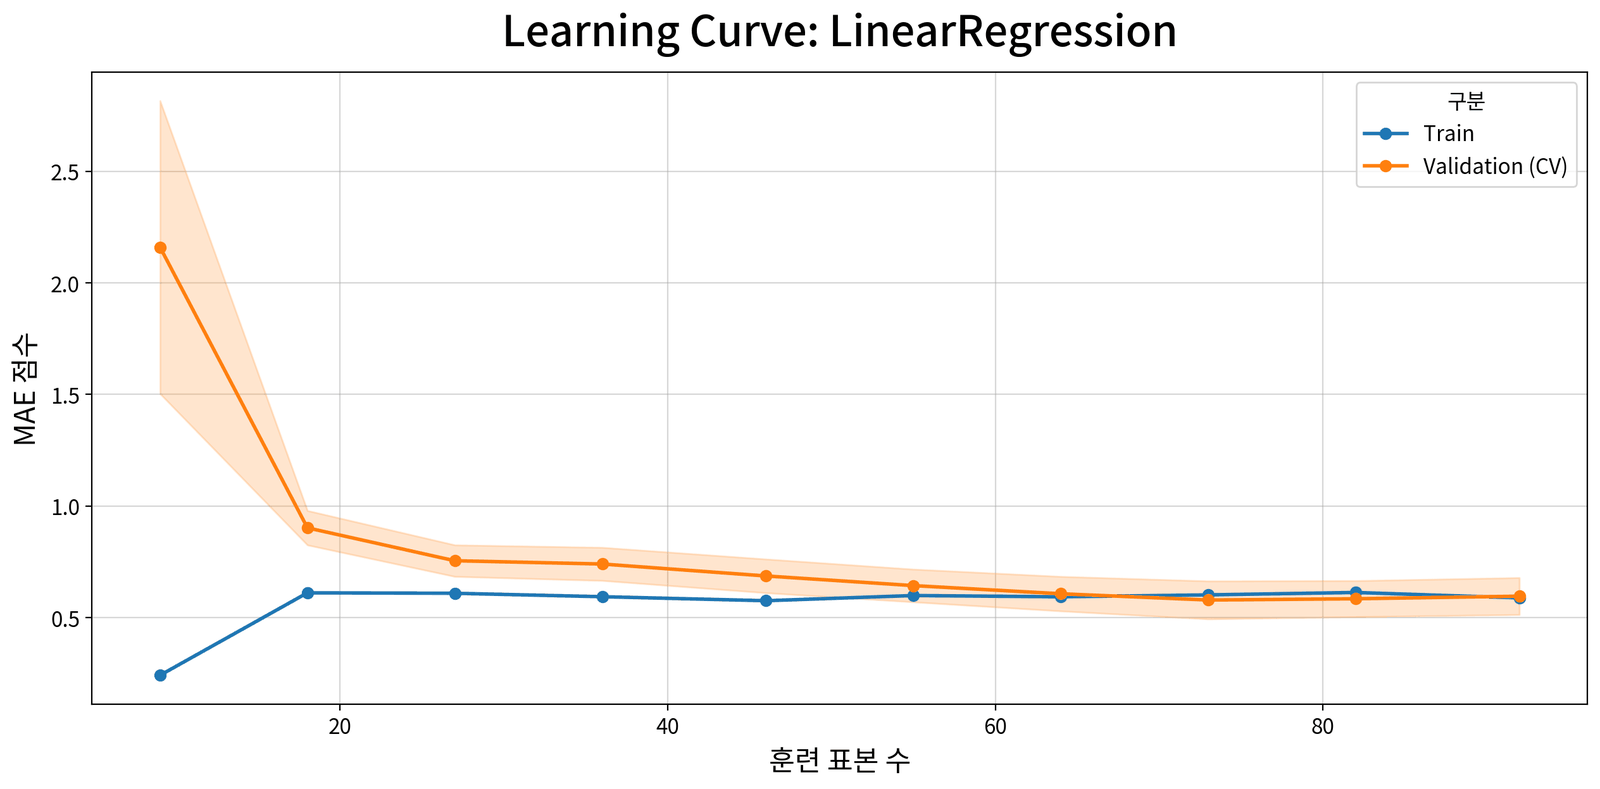

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.555435,0.570669,0.060881,0.597611,0.015233,2.67,일반화
RMSE,0.735474,0.742132,0.090792,0.832996,0.006659,0.90,일반화
R2,0.148217,0.079845,0.109449,0.091823,0.068372,6.84,일반화



◆ Fit Diagnosis: LinearRegression (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5554 CV=     0.5707 (±0.0609) Test=     0.5976 Gap%=    2.67% [일반화] [정상]
  - RMSE     Train=     0.7355 CV=     0.7421 (±0.0908) Test=     0.8330 Gap%=    0.90% [일반화] [정상]
  - R2       Train=     0.1482 CV=     0.0798 (±0.1094) Test=     0.0918 Gap%=    6.84% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1482 (과소적합 기준 < 0.05) · CV R2=0.0798


과적합 진단 실행: Tuned: ridge_tuned


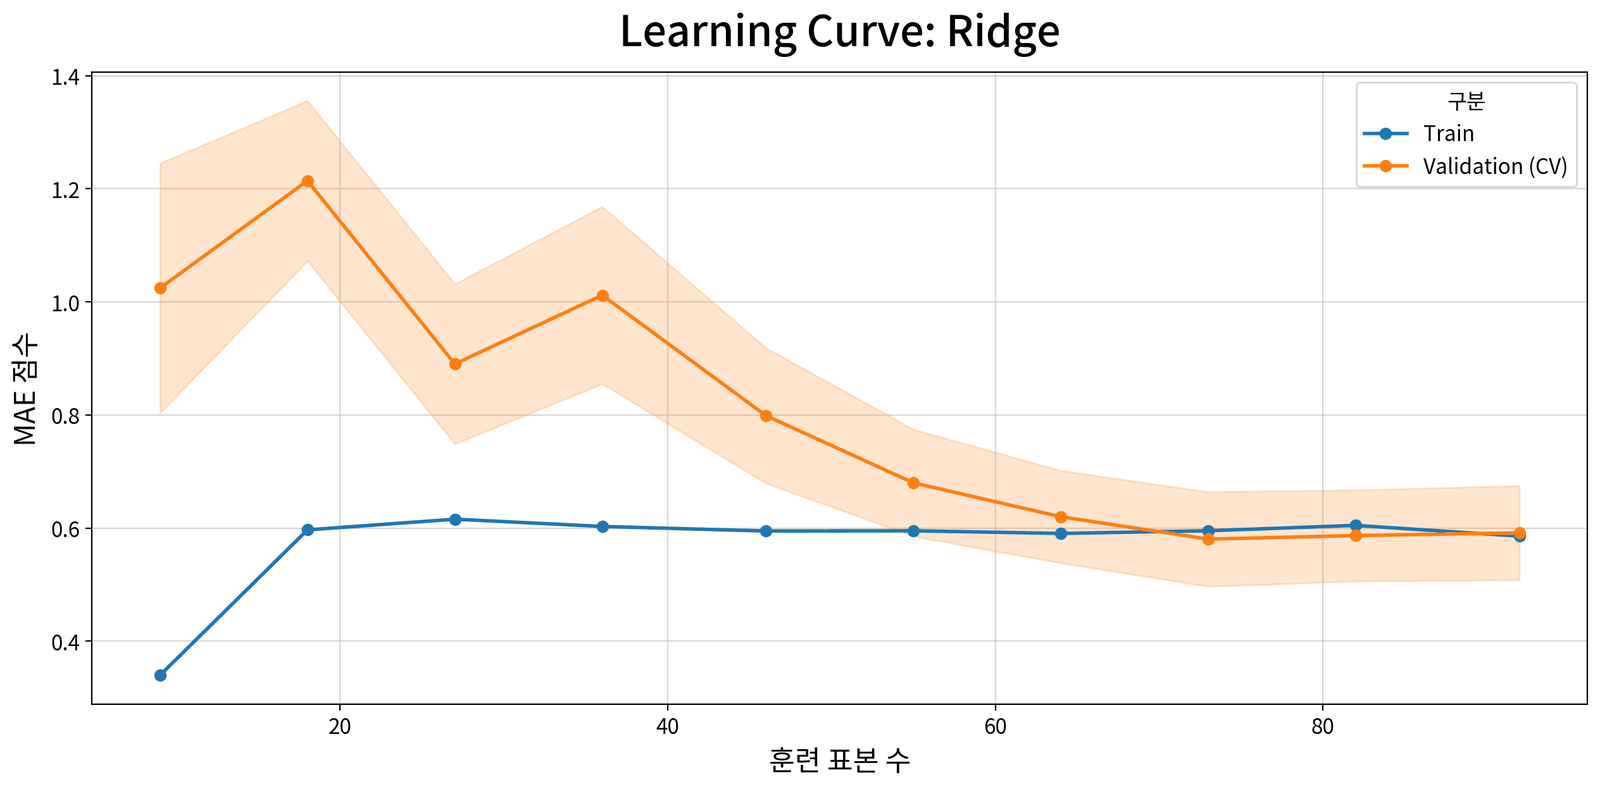

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.555254,0.570369,0.060010,0.584635,0.015114,2.65,일반화
RMSE,0.737505,0.745599,0.087413,0.815869,0.008094,1.09,일반화
R2,0.143506,0.073399,0.075757,0.128783,0.070108,7.01,일반화



◆ Fit Diagnosis: Ridge (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5553 CV=     0.5704 (±0.0600) Test=     0.5846 Gap%=    2.65% [일반화] [정상]
  - RMSE     Train=     0.7375 CV=     0.7456 (±0.0874) Test=     0.8159 Gap%=    1.09% [일반화] [정상]
  - R2       Train=     0.1435 CV=     0.0734 (±0.0758) Test=     0.1288 Gap%=    7.01% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1435 (과소적합 기준 < 0.05) · CV R2=0.0734


과적합 진단 실행: ML: ridge


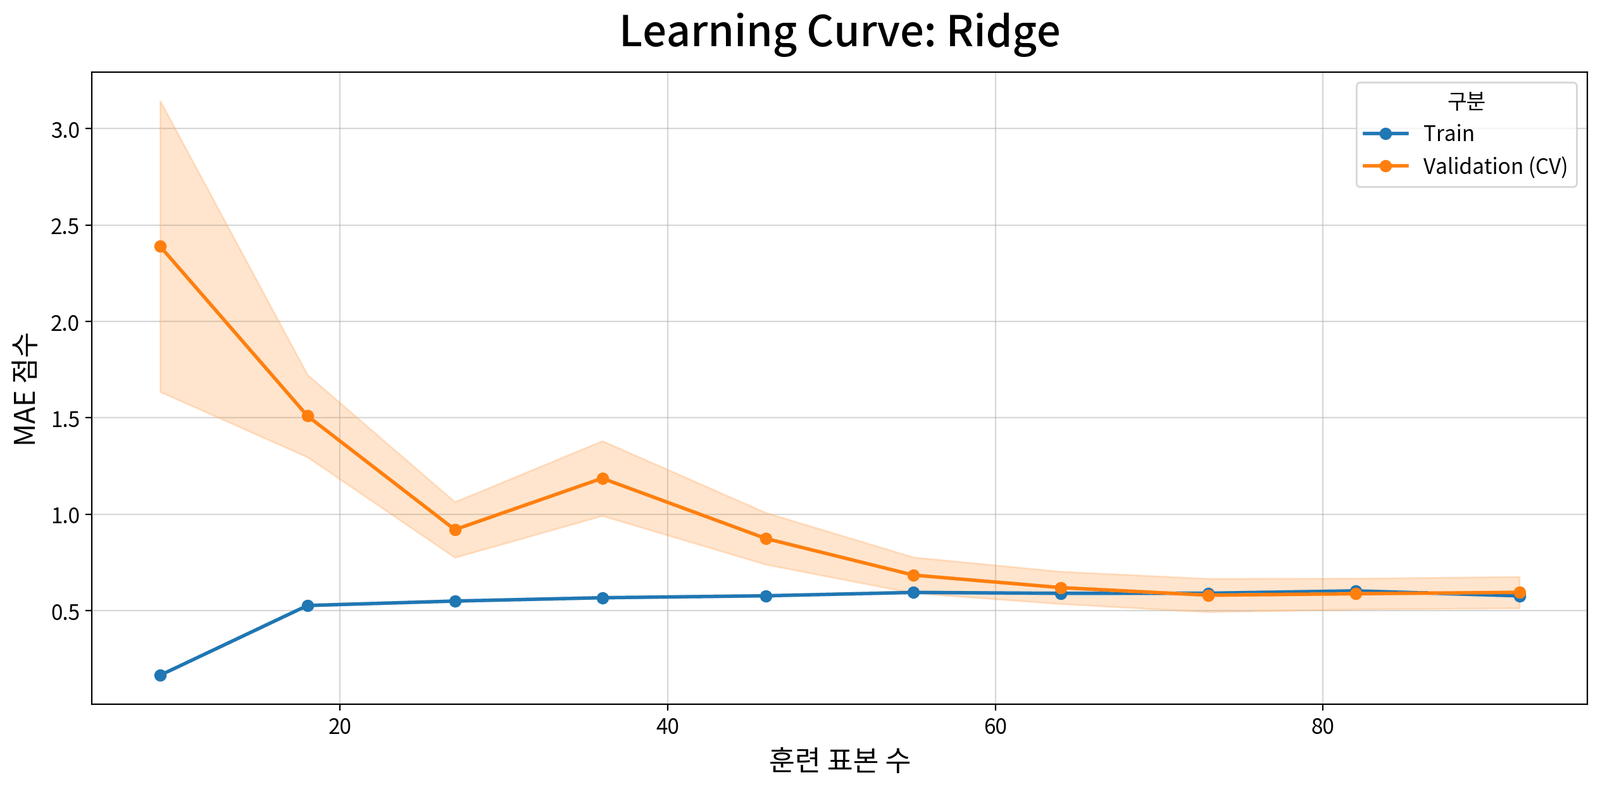

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.554231,0.573561,0.054902,0.580703,0.019330,3.37,일반화
RMSE,0.734780,0.748013,0.084798,0.808717,0.013233,1.77,일반화
R2,0.149824,0.065380,0.090319,0.143990,0.084444,8.44,일반화



◆ Fit Diagnosis: Ridge (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5542 CV=     0.5736 (±0.0549) Test=     0.5807 Gap%=    3.37% [일반화] [정상]
  - RMSE     Train=     0.7348 CV=     0.7480 (±0.0848) Test=     0.8087 Gap%=    1.77% [일반화] [정상]
  - R2       Train=     0.1498 CV=     0.0654 (±0.0903) Test=     0.1440 Gap%=    8.44% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1498 (과소적합 기준 < 0.05) · CV R2=0.0654


과적합 진단 실행: Tuned: elasticnet_tuned


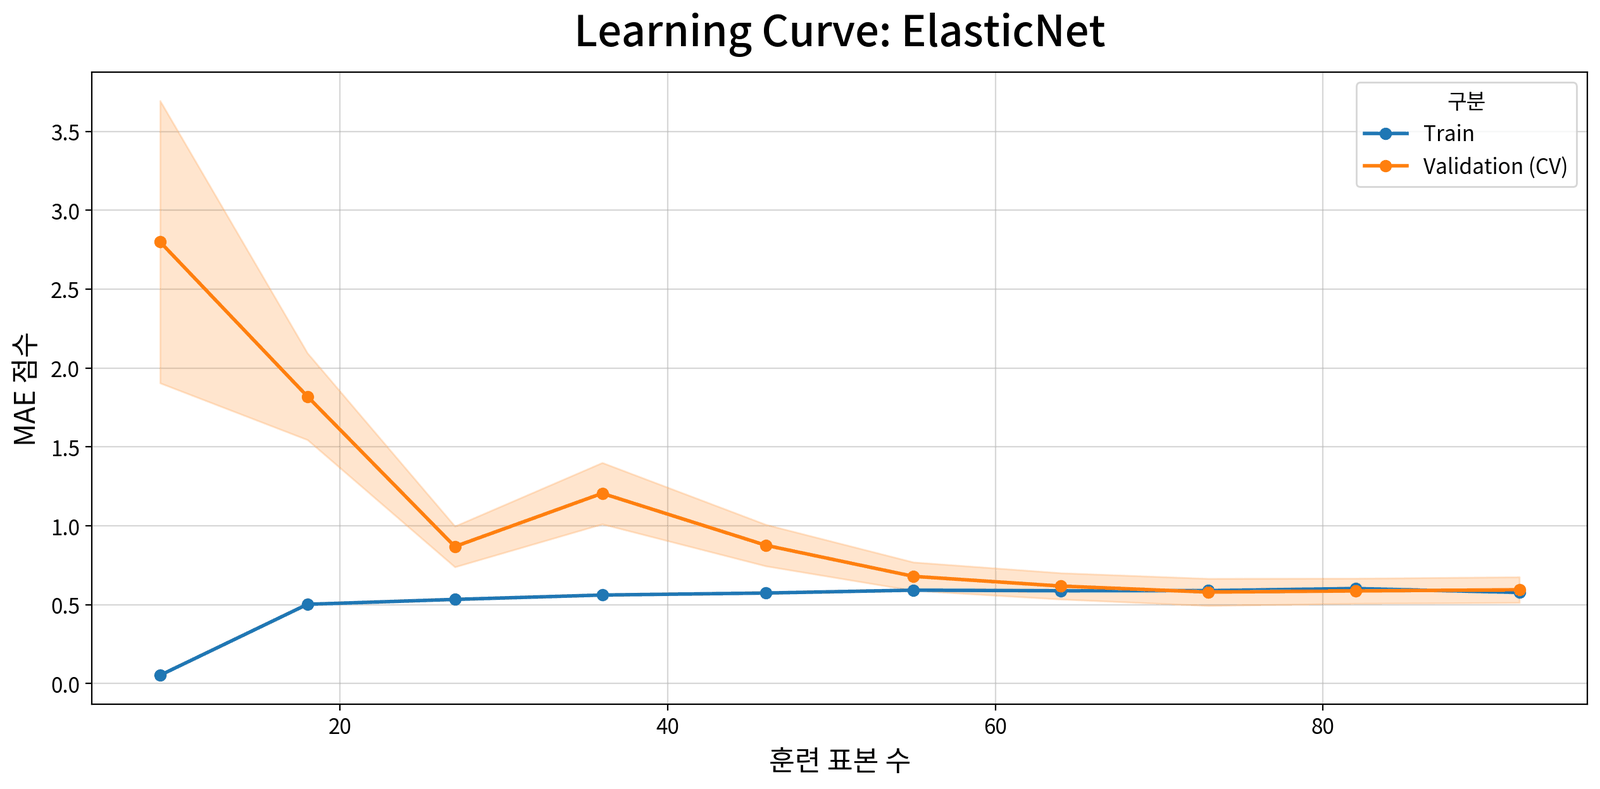

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.555161,0.573443,0.058268,0.587899,0.018283,3.19,일반화
RMSE,0.736644,0.748309,0.086396,0.821278,0.011665,1.56,일반화
R2,0.145505,0.065297,0.088359,0.117193,0.080209,8.02,일반화



◆ Fit Diagnosis: ElasticNet (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5552 CV=     0.5734 (±0.0583) Test=     0.5879 Gap%=    3.19% [일반화] [정상]
  - RMSE     Train=     0.7366 CV=     0.7483 (±0.0864) Test=     0.8213 Gap%=    1.56% [일반화] [정상]
  - R2       Train=     0.1455 CV=     0.0653 (±0.0884) Test=     0.1172 Gap%=    8.02% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1455 (과소적합 기준 < 0.05) · CV R2=0.0653


과적합 진단 실행: Tuned: lasso_tuned


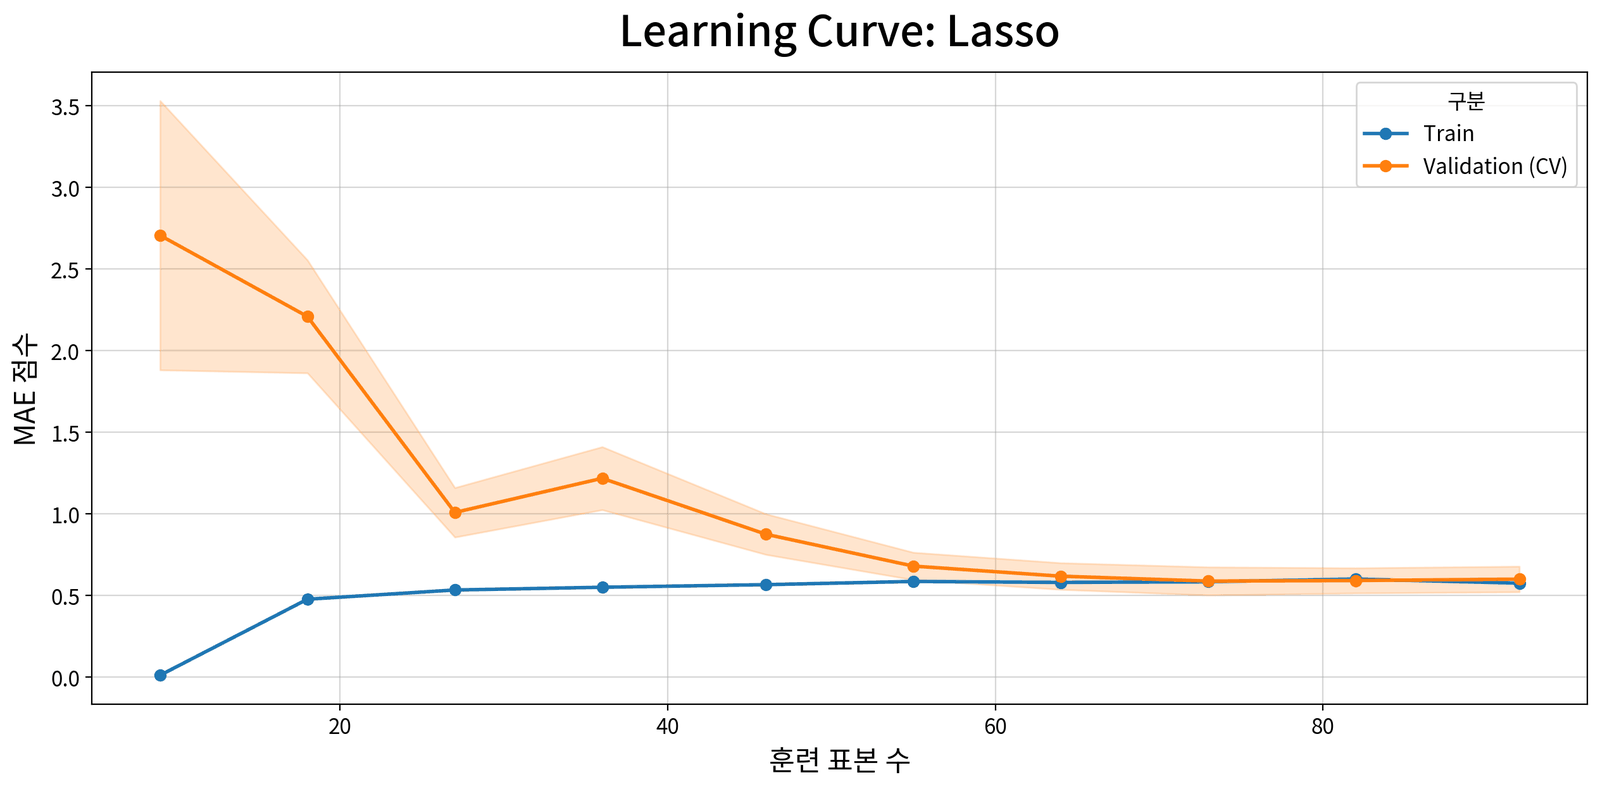

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.554324,0.576460,0.054626,0.590356,0.022135,3.84,일반화
RMSE,0.735063,0.750935,0.083310,0.823667,0.015871,2.11,일반화
R2,0.149168,0.057308,0.093716,0.112051,0.091860,9.19,일반화



◆ Fit Diagnosis: Lasso (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5543 CV=     0.5765 (±0.0546) Test=     0.5904 Gap%=    3.84% [일반화] [정상]
  - RMSE     Train=     0.7351 CV=     0.7509 (±0.0833) Test=     0.8237 Gap%=    2.11% [일반화] [정상]
  - R2       Train=     0.1492 CV=     0.0573 (±0.0937) Test=     0.1121 Gap%=    9.19% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1492 (과소적합 기준 < 0.05) · CV R2=0.0573


과적합 진단 실행: Tuned: svr_tuned


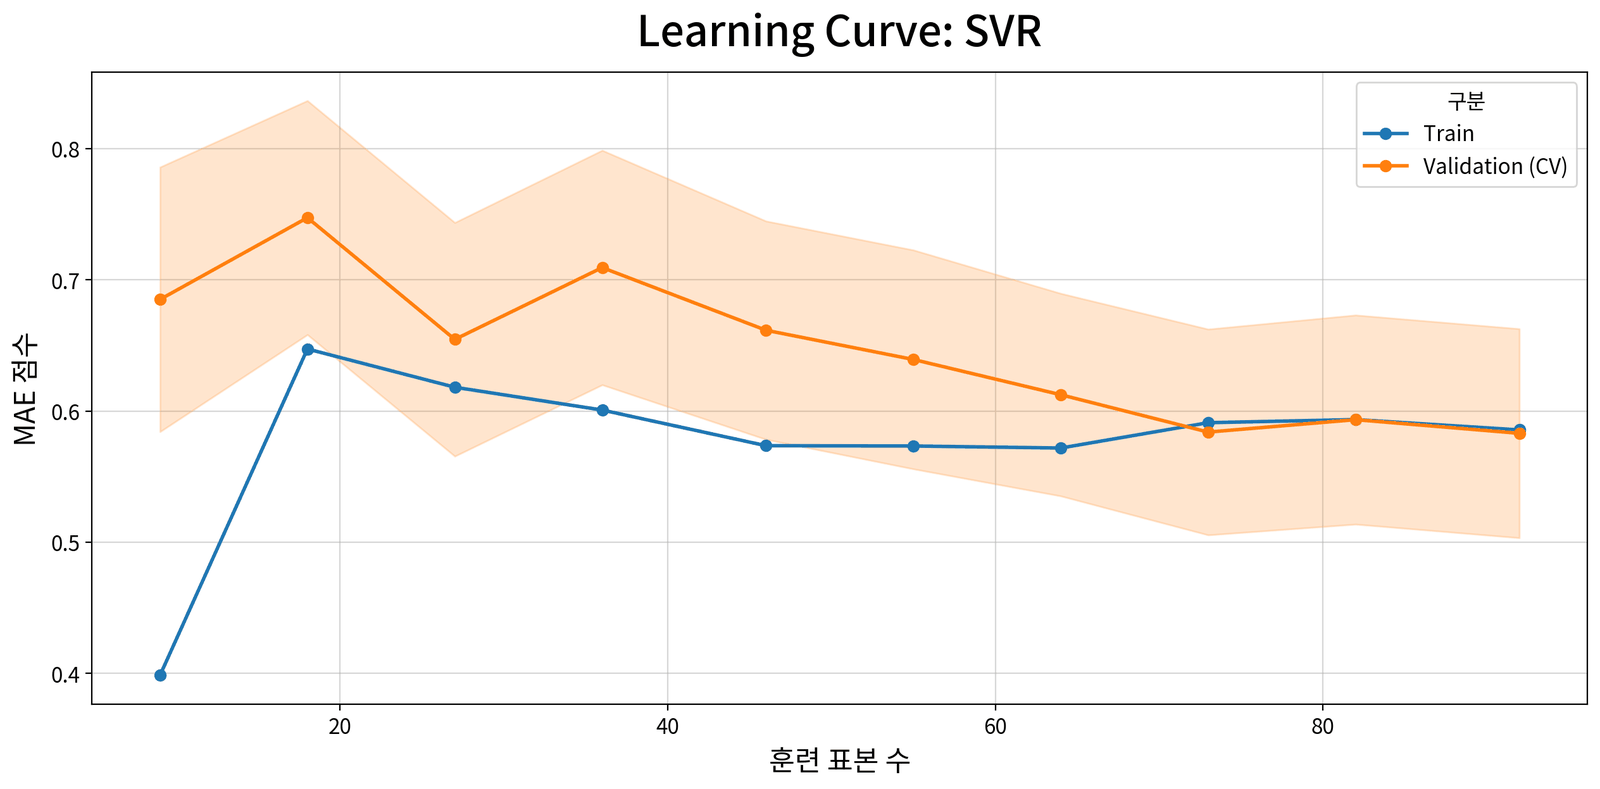

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.550594,0.573094,0.066603,0.671536,0.022500,3.93,일반화
RMSE,0.742454,0.752214,0.092065,0.913082,0.009761,1.30,일반화
R2,0.131974,0.058744,0.064852,-0.091201,0.073230,7.32,일반화



◆ Fit Diagnosis: SVR (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5506 CV=     0.5731 (±0.0666) Test=     0.6715 Gap%=    3.93% [일반화] [정상]
  - RMSE     Train=     0.7425 CV=     0.7522 (±0.0921) Test=     0.9131 Gap%=    1.30% [일반화] [정상]
  - R2       Train=     0.1320 CV=     0.0587 (±0.0649) Test=    -0.0912 Gap%=    7.32% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1320 (과소적합 기준 < 0.05) · CV R2=0.0587


과적합 진단 실행: ML: linear


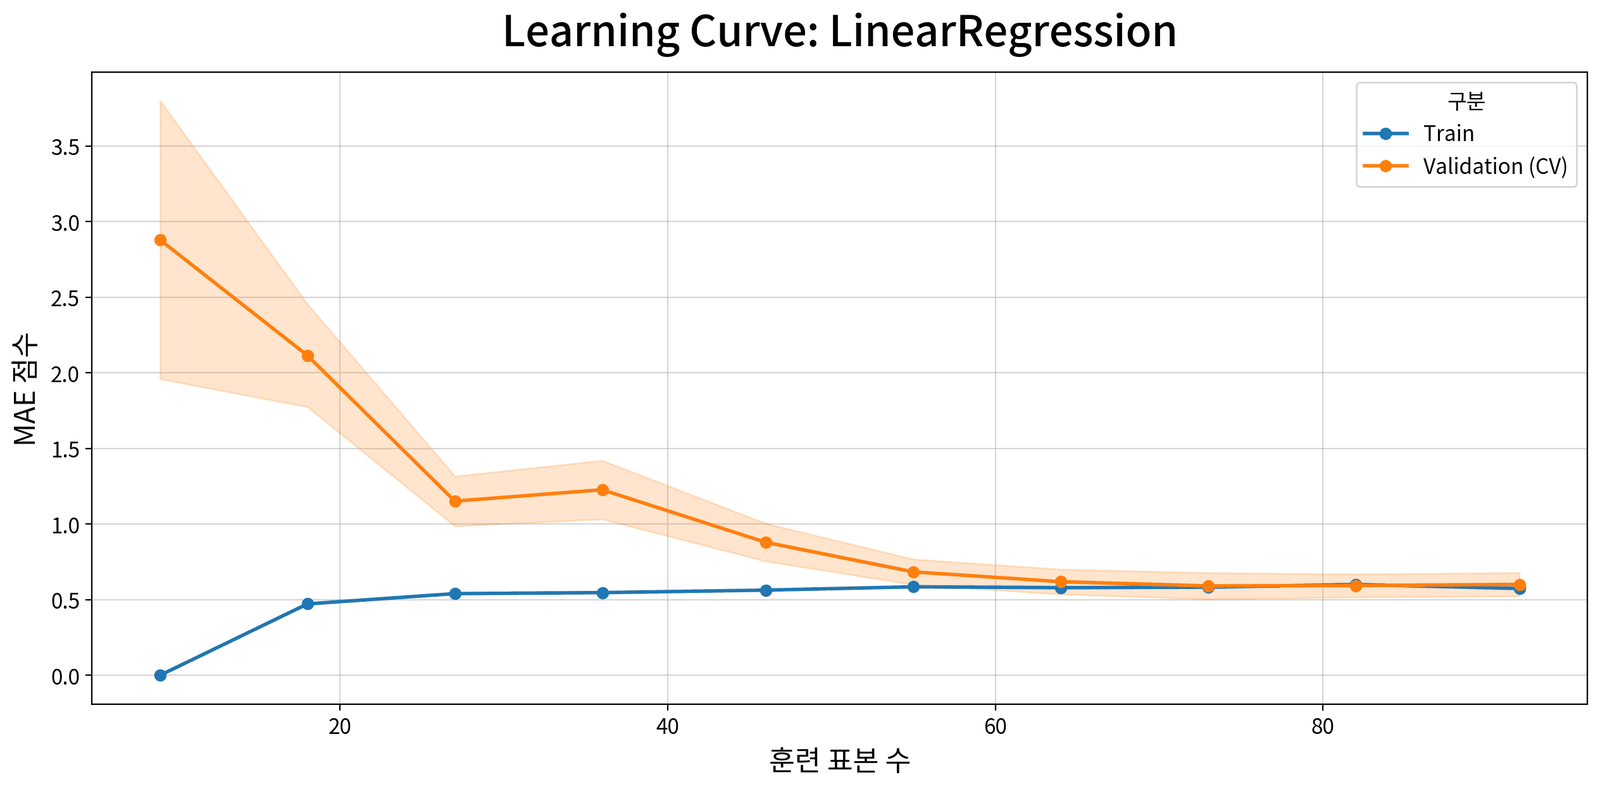

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.554322,0.577914,0.052648,0.581483,0.023592,4.08,일반화
RMSE,0.734664,0.752413,0.082697,0.808431,0.017748,2.36,일반화
R2,0.150091,0.053305,0.094827,0.144596,0.096786,9.68,일반화



◆ Fit Diagnosis: LinearRegression (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5543 CV=     0.5779 (±0.0526) Test=     0.5815 Gap%=    4.08% [일반화] [정상]
  - RMSE     Train=     0.7347 CV=     0.7524 (±0.0827) Test=     0.8084 Gap%=    2.36% [일반화] [정상]
  - R2       Train=     0.1501 CV=     0.0533 (±0.0948) Test=     0.1446 Gap%=    9.68% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1501 (과소적합 기준 < 0.05) · CV R2=0.0533


과적합 진단 실행: Tuned: kneighbors_tuned


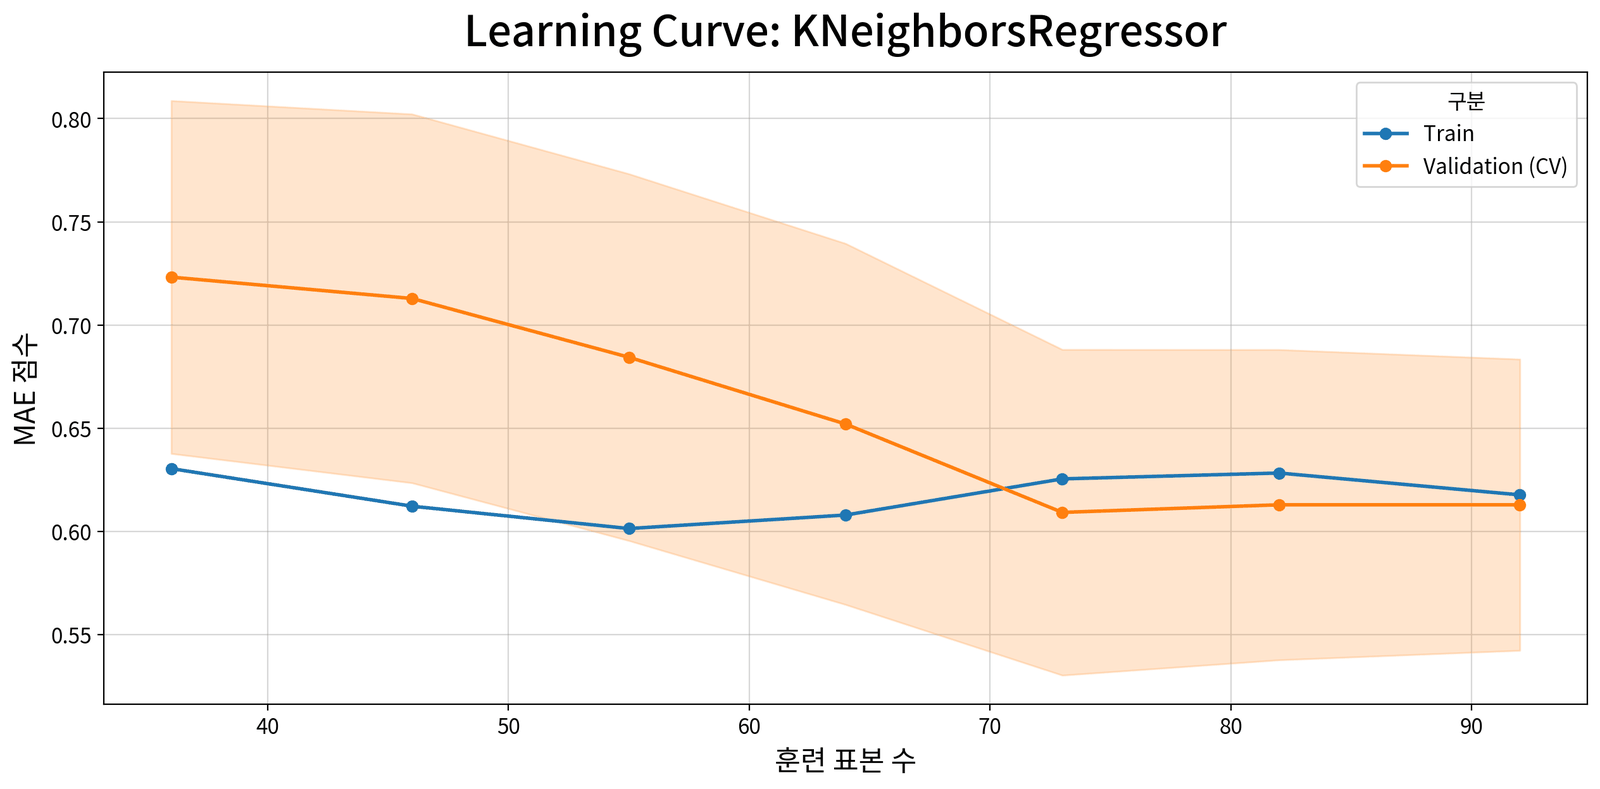

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.559576,0.589991,0.068754,0.602553,0.030414,5.16,일반화
RMSE,0.738007,0.763088,0.099805,0.822652,0.025080,3.29,일반화
R2,0.142339,0.033749,0.063845,0.114238,0.108591,10.86,일반화



◆ Fit Diagnosis: KNeighborsRegressor (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.5596 CV=     0.5900 (±0.0688) Test=     0.6026 Gap%=    5.16% [일반화] [정상]
  - RMSE     Train=     0.7380 CV=     0.7631 (±0.0998) Test=     0.8227 Gap%=    3.29% [일반화] [정상]
  - R2       Train=     0.1423 CV=     0.0337 (±0.0638) Test=     0.1142 Gap%=   10.86% [일반화] [정상]

  ▶ 진단: ✔ 일반화 (Good fit) - 격차가 작고 훈련 성능도 양호
    · train R2=0.1423 (과소적합 기준 < 0.05) · CV R2=0.0337


과적합 진단 실행: Tuned: randomforest_tuned


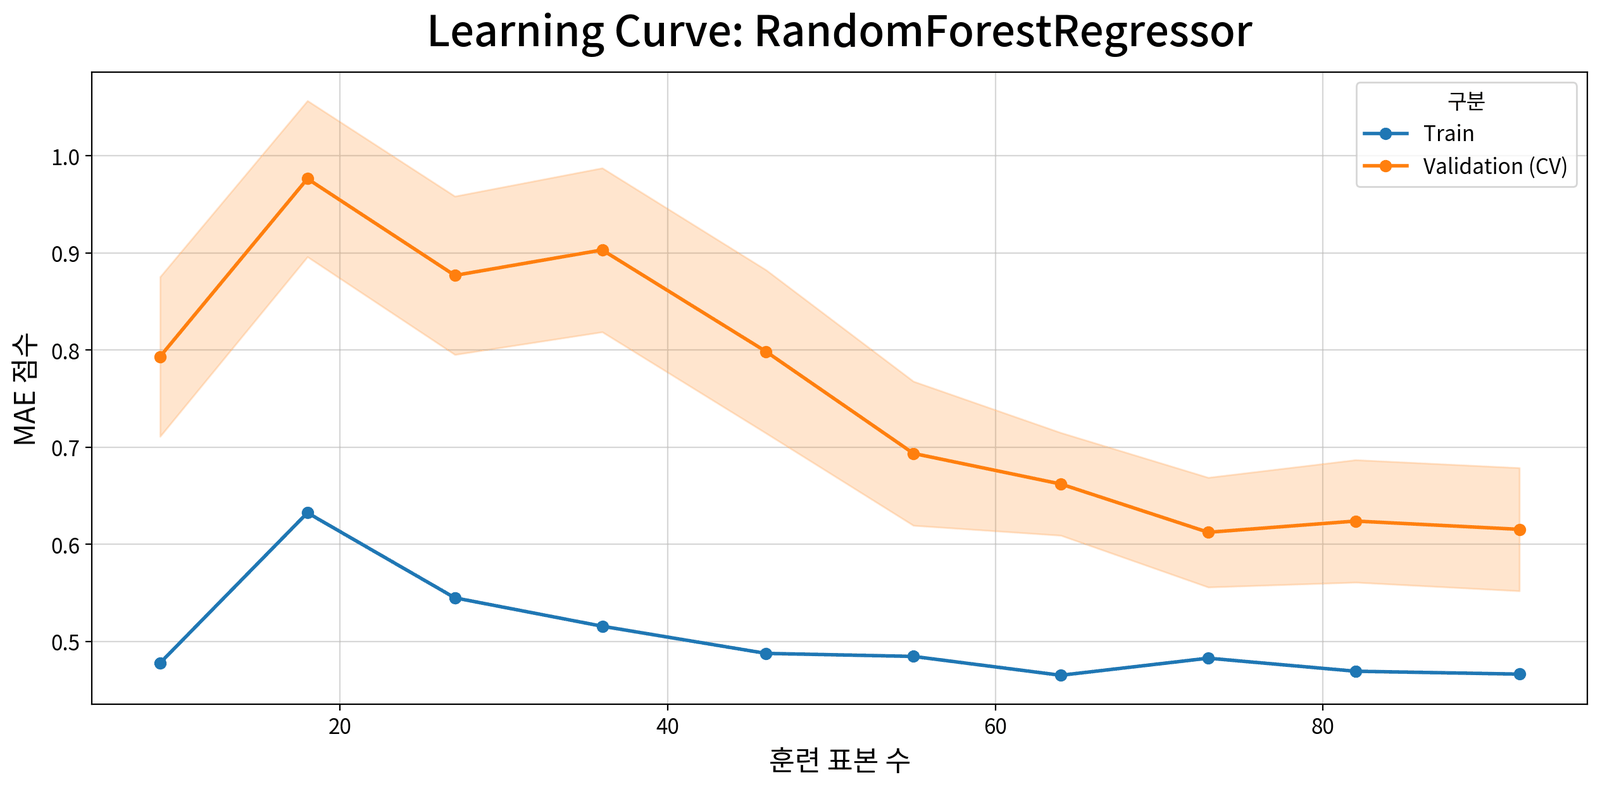

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.415253,0.593416,0.062081,0.600493,0.178164,30.02,과대적합
RMSE,0.561220,0.772351,0.092436,0.810031,0.211131,27.34,과대적합
R2,0.504024,0.003297,0.111739,0.141207,0.500728,50.07,과대적합



◆ Fit Diagnosis: RandomForestRegressor (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.4153 CV=     0.5934 (±0.0621) Test=     0.6005 Gap%=   30.02% [과대적합] [주의]
  - RMSE     Train=     0.5612 CV=     0.7724 (±0.0924) Test=     0.8100 Gap%=   27.34% [과대적합] [주의]
  - R2       Train=     0.5040 CV=     0.0033 (±0.1117) Test=     0.1412 Gap%=   50.07% [과대적합] [주의]

  ▶ 진단: △ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
    · train R2=0.5040 (과소적합 기준 < 0.05) · CV R2=0.0033


과적합 진단 실행: ML: svr


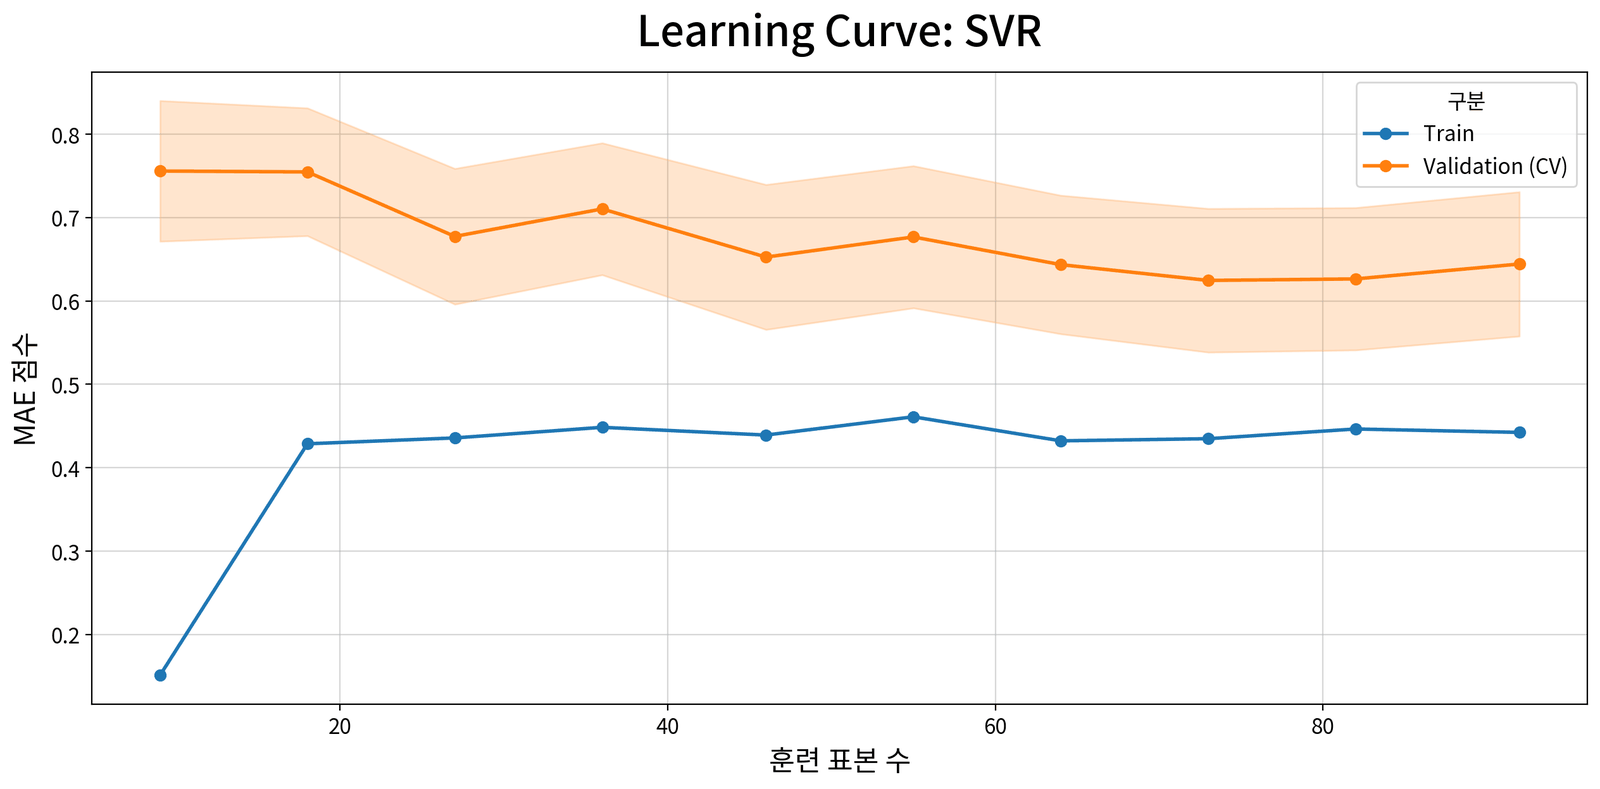

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
MAE,0.471324,0.595643,0.064270,0.666193,0.124319,20.87,과대적합
RMSE,0.676832,0.782349,0.087504,0.873969,0.105517,13.49,일반화
R2,0.278633,-0.019546,0.056300,0.000283,0.298179,29.82,과대적합



◆ Fit Diagnosis: SVR (threshold=20%, 기준=Train↔CV TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)-Fold)
  ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - MAE      Train=     0.4713 CV=     0.5956 (±0.0643) Test=     0.6662 Gap%=   20.87% [과대적합] [주의]
  - RMSE     Train=     0.6768 CV=     0.7823 (±0.0875) Test=     0.8740 Gap%=   13.49% [일반화] [정상]
  - R2       Train=     0.2786 CV=    -0.0195 (±0.0563) Test=     0.0003 Gap%=   29.82% [과대적합] [주의]

  ▶ 진단: △ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
    · train R2=0.2786 (과소적합 기준 < 0.05) · CV R2=-0.0195



In [42]:
# =========================================================================
# 1~2. 과적합 진단 대상: 6.2.2 교차검증 기준 근소 격차 그룹 (cv_contenders)
# =========================================================================
def load_by_name(name):
    """'ML: 모델명' / 'Tuned: 모델명_tuned' 형식의 이름으로 저장된 모델을 불러온다."""
    kind, stem = name.split(": ", 1)
    folder = "baseline" if kind == "ML" else "tuned"
    return my_ml.load_model(Path(PROJECT_NAME) / folder / f"{stem}.pkl")

models = {name: load_by_name(name) for name in cv_contenders}

# =========================================================================
# 3. 시계열 교차검증 분할기: 6.2에서 정의한 tscv(TimeSeriesSplit(n_splits=5))를 그대로 사용
# =========================================================================

# =========================================================================
# 4. 근소 격차 그룹 일괄 과적합 진단 실행 (my_diag.overfit)
# =========================================================================
print(f"근소 격차 그룹 {len(models)}개 과적합/미적합 진단 시작...\n")

for name, model in models.items():
    print("\n" + "=" * 80)
    print(f"과적합 진단 실행: {name}")
    print("=" * 80)

    # my_diag.overfit 호출 (지표표 및 학습곡선 그래프 자동 출력)
    my_diag.overfit(
        estimator=model,
        x_train=X_train,
        y_train=y_train,
        x_test=X_test,
        y_test=y_test,
        metrics=["MAE", "RMSE", "R2"],
        cv=tscv,
        threshold=0.20,  # Train ↔ CV 격차 20% 이상 시 과대적합 판정
        learning_curve=True,
        width=1280,
        height=640,
        verbose=True,
    )

#### 6.3.1 최종 모델 선정

##### 1. 선정 과정 요약

최종 모델은 네 단계를 거쳐 선정했습니다.

1. **근소 격차 그룹 선별**: 베이스 11종과 튜닝 11종을 학습 구간 시계열 교차검증(5겹)으로 평가해 원화 CV MAE 1등 대비 5% 이내인 10개 모델을 Contender로 선별했습니다(6.2.2).
2. **보조 지표 결함 점검**: RMSE와 R²를 보조 지표로 확인한 결과, `Tuned: randomforest_tuned`와 `ML: svr`이 R² 결함으로 순위가 밀렸습니다.
3. **과적합 진단**: `TimeSeriesSplit`(5겹) 기반 과적합 진단(MAE 기준 Gap% ≥ 20%를 과대적합으로 판정)을 거쳐 튜닝 RandomForest(30.02%)와 베이스 SVR(20.87%)을 제외했습니다.
4. **최종 후보 비교**: 그 결과 LinearRegression, Ridge, 튜닝된 Linear·Ridge·ElasticNet·Lasso의 선형 계열 6개와 튜닝 SVR, 튜닝 KNN까지 8개 모델이 남았습니다. 이들을 비교해 최종 모델을 정했습니다.

---

##### 2. 최종 후보 8개 모델 비교

비교에는 아래 세 기준을 썼습니다.

| 기준 | 지표 | 의미 |
| :--- | :--- | :--- |
| **CV 성능** | 5개 폴드 원화 MAE의 평균 | 학습 구간 안에서 평균적으로 얼마나 정확한가 (낮을수록 좋음) |
| **안정성** | 5개 폴드 원화 MAE의 **표준편차** | 학습·평가 기간이 바뀌어도 성능이 얼마나 일정한가. 값이 작을수록 기간에 따른 흔들림이 적음 |
| **Test 성능** | 테스트 구간(138일) 원화 MAE | 한 번도 보지 않은 최근 구간에서의 정확도 (최종 확인용) |

| 모델 | CV MAE (원) | CV 표준편차 (원) | Gap% (MAE, 로그) | Test MAE (원) | CV MAE 순위 | 안정성 순위 | Test MAE 순위 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Base: Ridge** | 308,706 | 58,496 | 3.37% | **269,120** | 3 | 3 | **1** |
| Base: Linear | 310,321 | **57,083** | 4.08% | 270,316 | 7 | **1** | 3 |
| Tuned: Linear | **307,377** | 58,737 | 2.67% | 277,650 | **1** | 4 | 6 |
| Tuned: Ridge | 308,044 | 62,283 | 2.65% | 269,942 | 2 | 6 | 2 |
| Tuned: ElasticNet | 308,871 | 60,128 | 3.19% | 271,623 | 4 | 5 | 4 |
| Tuned: Lasso | 309,717 | 58,003 | 3.84% | 273,939 | 5 | 2 | 5 |
| Tuned: SVR | 310,006 | 65,660 | 3.93% | 315,184 | 6 | 7 | 8 |
| Tuned: KNN | 317,320 | 66,637 | 5.16% | 280,213 | 8 | 8 | 7 |

남은 8개 모델의 원화 CV MAE는 307,377원~317,320원 범위에 있고 최대 차이는 9,943원(약 3.2%)입니다. 이 차이는 CV 표준편차(약 5.7만~6.7만 원)의 6분의 1 수준입니다. 선형 계열 6개끼리는 최대 2,944원밖에 차이 나지 않아 모델 간 성능 차이를 실질적인 차이로 보기는 어렵다고 판단했습니다. Train–CV 격차(Gap%)도 2.65~5.16%로 모두 임계치(20%)를 크게 밑돌아 일반화 측면에서도 뚜렷한 우열이 없었습니다.

성능과 일반화에서 차이가 나지 않았으므로 최종 선택은 **기준 간 균형, 단순성, 해석 가능성, 안정성**을 기준으로 했습니다. 모델 선택은 CV 결과를 중심으로 하고 Test 성능은 최종 확인용 참고 지표로만 활용했습니다. Test 성능만 보고 모델을 반복해서 고르면 테스트셋에 과도하게 맞춰진 선택이 될 수 있기 때문입니다.

---

##### 3. 최종 선정: Ridge (Base)

`Base: Ridge`를 최종 모델로 선정했습니다. 근거는 네 가지입니다.

**첫째, 기준 간 균형이 가장 좋습니다.** CV 성능(3위), 안정성(3위), Test 성능(1위) 세 기준 모두에서 상위 3위 안에 든 유일한 모델입니다. `Tuned: Linear`는 CV MAE 1위지만 Test 성능이 6위입니다. `Base: Linear`는 안정성 1위지만 CV MAE는 7위이고 `Tuned: Ridge`는 안정성이 6위입니다. 실제 운영 환경에서는 특정 기준에서만 1등인 모델보다 약점이 없는 모델이 더 신뢰할 만하다고 봤습니다.

**둘째, 튜닝 모델은 이득이 불분명하고 해석에 제약이 있습니다.** 베이스 대비 CV MAE는 소폭(Ridge −662원, Linear −2,944원) 낮아졌지만 그 차이는 CV 표준편차 범위 안에 있고 Test MAE는 오히려 증가했습니다(Ridge +822원, Linear +7,334원). 특히 `Tuned: Linear`는 `positive=True`로 모든 회귀계수를 0 이상으로 강제하기 때문에 음(−)의 효과를 가질 수 있는 변수의 방향이 왜곡됩니다. 튜닝 모델을 고르면 하이퍼파라미터 의존성만 늘어나므로 재학습과 운영이 단순한 베이스 모델을 택했습니다.

**셋째, 안정성도 상위권입니다.** CV 표준편차는 58,496원으로 8개 중 3위이고 1위인 `Base: Linear`(57,083원)와는 1,413원 차이입니다.

**넷째, 규제를 통해 해석 가능성과 안정성을 함께 확보합니다.** 가장 가까운 경쟁 모델은 `Base: Linear`(규제 없음)입니다. 이 모델은 학습곡선에서 표본이 적은 구간에서는 Train MAE가 0까지 내려가 과적합 성향을 보였습니다. 반면 Ridge는 같은 구간에서도 Train MAE가 약 0.17을 유지했습니다. Ridge는 L2 규제로 계수의 불안정성을 억제하면서도 선형 모델의 해석 가능성은 그대로 살리므로 요일·공휴일 등 매출 요인의 영향을 매장 운영자에게 직관적으로 설명할 수 있습니다.

차선책으로는 `Base: LinearRegression`을 두었습니다. 규제 유무 말고는 Ridge와 성능과 특성이 거의 동일합니다(Test MAE 차이 1,196원).

---

##### 4. 한계 및 후속 과제

* **설명력 한계**: 선정된 모델의 CV R²는 약 0.07, Test R²는 약 0.14로 설명력이 낮은 편입니다. 요일에 따른 평소 매출 수준은 잡아내지만 단체 손님 등 일회성 급등은 예측하지 못합니다.
* **기준선 대비 성과**: Test MAE는 "학습구간 전체 평균" 대비 약 17.3%, "최근 4주 동일 요일 평균" 대비 약 17.3% 낮습니다. 그러나 "학습구간 요일별 중앙값"(베이스라인 3) 대비로는 약 1.9% 낮은 데 그쳐 개선분의 대부분은 요일 정보에서 나옵니다. 이 차이가 의미 있는지는 6.3.3에서 검증합니다.
* **향후 개선 방향**: 성능 개선은 모델 교체보다 피처 보강에 초점을 둘 필요가 있습니다. 기온·강수·기상특보·유동인구 변수는 이미 검토했으나 매출과의 유의한 관련성이 확인되지 않았으므로 이번 데이터에 없던 정보를 추가하는 방향이 필요합니다. 예를 들어 월급일 전후 여부, 단체 예약 여부, 주변 상권 행사 일정, 영업시간 변동 기록 등을 고려할 수 있습니다.

#### 6.3.2 최종 모델의 폴드별·기간별 성능

교차검증 평균값만으로는 기간에 따른 성능 변동과 테스트 구간의 계절 구성을 알 수 없습니다. 최종 모델을 교차검증 각 폴드와 테스트 구간에서 각각 평가하고 평가 구간마다 실제 날짜 범위를 함께 표시합니다. (날짜는 5.3에서 보존한 `영업일_final` 사용)

* **판단 기준**: 폴드 간 MAE 편차가 크거나 특정 계절 구간에서만 성능이 나쁘면, 최종 성능은 계절에 따라 달라질 수 있다는 한계로 기록합니다. 테스트 구간의 날짜 범위로 테스트 성능이 어느 계절을 대표하는지도 확인합니다.

In [43]:
# =========================================================================
# 6.3.2 최종 모델의 폴드별 성능 및 기간 확인
# =========================================================================
# 교차검증 평균 뒤에 가려진 기간별 성능 변동과, 테스트 구간이 어느 계절에 해당하는지 확인한다.
from sklearn.base import clone

# 최종 모델(Base: Ridge)은 이후 6.3.3·6.4에서도 그대로 재사용한다
FINAL_MODEL_PATH = Path(PROJECT_NAME) / "baseline" / "ridge.pkl"
final_model = my_ml.load_model(FINAL_MODEL_PATH)
final_pipeline = my_ml._unwrap_estimator(final_model)[2]   # 교차검증에서 폴드마다 새로 학습할 원본 파이프라인
train_dates = 영업일_final.iloc[:len(X_train)].reset_index(drop=True)
test_dates = 영업일_final.iloc[len(X_train):].reset_index(drop=True)

def period(dates):
    return f"{dates.iloc[0]:%Y-%m-%d} ~ {dates.iloc[-1]:%Y-%m-%d}"

fold_rows = []
for k, (tr, va) in enumerate(tscv.split(X_train), 1):
    m = clone(final_pipeline).fit(X_train.iloc[tr], y_train.iloc[tr])
    pred = m.predict(X_train.iloc[va])
    fold_rows.append({
        "구분": f"CV 폴드 {k}",
        "학습 기간": period(train_dates.iloc[tr]),
        "평가 기간": period(train_dates.iloc[va]),
        "평가 행수": len(va),
        "MAE(로그)": round(mean_absolute_error(y_train.iloc[va], pred), 4),
        "MAE(원)": round(mean_absolute_error(np.exp(y_train.iloc[va]), np.exp(pred))),
        "R2(로그)": round(r2_score(y_train.iloc[va], pred), 4),
    })

# 테스트 구간 (6.1에서 학습 구간 전체로 적합한 최종 모델)
test_pred = final_model.predict(X_test)
fold_rows.append({
    "구분": "테스트",
    "학습 기간": period(train_dates),
    "평가 기간": period(test_dates),
    "평가 행수": len(X_test),
    "MAE(로그)": round(mean_absolute_error(y_test, test_pred), 4),
    "MAE(원)": round(mean_absolute_error(np.exp(y_test), np.exp(test_pred))),
    "R2(로그)": round(r2_score(y_test, test_pred), 4),
})

display(Markdown("##### 최종 모델(Base: Ridge) 폴드별·기간별 성능"))
display(DataFrame(fold_rows))

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


##### 최종 모델(Base: Ridge) 폴드별·기간별 성능

,구분,학습 기간,평가 기간,평가 행수,MAE(로그),MAE(원),R2(로그)
0,CV 폴드 1,2024-07-17 ~ 2024-10-19,2024-10-20 ~ 2025-01-20,92,0.6000,258044,-0.0580
1,CV 폴드 2,2024-07-17 ~ 2025-01-20,2025-01-21 ~ 2025-04-23,92,0.5339,279961,0.0889
2,CV 폴드 3,2024-07-17 ~ 2025-04-23,2025-04-24 ~ 2025-08-06,92,0.4930,248665,0.0028
3,CV 폴드 4,2024-07-17 ~ 2025-08-06,2025-08-07 ~ 2025-11-06,92,0.5895,364498,0.2094
4,CV 폴드 5,2024-07-17 ~ 2025-11-06,2025-11-07 ~ 2026-02-08,92,0.6514,392361,0.0838
5,테스트,2024-07-17 ~ 2026-02-08,2026-02-09 ~ 2026-06-30,138,0.5807,269120,0.1440


##### 6.3.2 결과 해석

| 구분 | 평가 기간 | MAE (원) | MAE (로그) | R² (로그) |
| :--- | :--- | :---: | :---: | :---: |
| CV 폴드 1 | 2024-10-20 ~ 2025-01-20 | 258,044 | 0.6000 | −0.058 |
| CV 폴드 2 | 2025-01-21 ~ 2025-04-23 | 279,961 | 0.5339 | 0.089 |
| CV 폴드 3 | 2025-04-24 ~ 2025-08-06 | 248,665 | 0.4930 | 0.003 |
| CV 폴드 4 | 2025-08-07 ~ 2025-11-06 | 364,498 | 0.5895 | 0.209 |
| CV 폴드 5 | 2025-11-07 ~ 2026-02-08 | 392,361 | 0.6514 | 0.084 |
| **테스트** | **2026-02-09 ~ 2026-06-30** | **269,120** | **0.5807** | **0.144** |

* **기간에 따라 원화 오차가 크게 다릅니다 (약 25만 ~ 39만 원).** 2025년 늦겨울~여름(폴드 2·3, 1월 하순~8월 초)은 25만~28만 원이었지만 늦여름부터 연말·연초(폴드 4·5, 8월 초~이듬해 2월 초)는 36만~39만 원으로 컸습니다. 폴드 5에는 연말·연초와 5.1에서 확인한 2026년 1월의 초대형 매출이 포함되어 있습니다. 로그 MAE(비율 오차에 가까움)는 0.49~0.65로 원화만큼 크게 벌어지지 않습니다. 오차가 커진 데에는 매출 규모와 변동이 큰 시기라는 점도 함께 작용했습니다.
* **설명력은 기간마다 들쭉날쭉합니다.** 학습 데이터가 약 3개월뿐인 폴드 1은 R²가 음수(평균 예측보다 못함)였고 폴드 3도 거의 0이었으며 가장 높은 폴드 4가 0.21이었습니다. 이렇게 고르게 높지 않은 설명력은 요일 외 변수의 기여가 크지 않다는 결과와 같은 방향을 가리킵니다.
* **테스트 구간의 대표성**: 테스트 구간은 2026년 2월 9일~6월 30일(늦겨울~초여름)이고 원화 MAE(269,120원)는 폴드 평균(308,706원)보다 낮은 편입니다. 테스트 구간이 특별히 운이 나쁜 시기는 아니지만 가을·연말 구간을 포함하지 않으므로 **연중 다른 시기에는 오차가 더 클 수 있습니다.**

#### 6.3.3 요일 기준선 대비 모델의 부가가치 검증

6.1의 베이스라인 3(학습구간 요일별 중앙값)은 테스트 MAE 274,446원으로, 최종 모델 Ridge(269,120원)와의 차이가 5,326원(약 1.9%)에 불과했습니다. 전체 평균(베이스라인 1) 대비 Ridge가 줄인 오차 56,458원 중 약 91%(51,132원)는 요일만으로도 얻을 수 있는 몫이고 요일 외 변수의 기여는 약 9%입니다. 베이스 ML 모델 11종 가운데 Ridge와 Linear를 뺀 9종은 요일 기준선보다도 오차가 컸습니다.

이 작은 차이가 우연인지, 어디에서 생기는지를 네 가지로 확인합니다.

| 점검 | 방법 | 판단 기준 |
| :--- | :--- | :--- |
| ① 날짜별 대응 비교 | 테스트 138일 각각의 절대오차를 짝지어 검정 (`my_stats.test_paired`) | `less` 대립가설이 유의(p < 0.05)하면 Ridge 오차가 요일 기준선보다 확실히 작음 |
| ② 교차검증 폴드별 비교 | 폴드마다 학습 구간으로 두 방법을 새로 만들어 검증 구간 오차 비교 | 5개 폴드 대부분에서 Ridge가 우세하면 차이가 안정적 |
| ③ 날짜 유형별 분해 | 공휴일, 공휴일 전날, 휴무 직후 3일, 금·토·일, 월~목으로 나눠 오차 비교 | 이득이 특정 유형에 몰려 있는지 확인 |
| ④ 단순 모델 비교 | 요일·공휴일여부·공휴일전날여부 3개 변수만 쓴 Ridge와 최종 모델 비교 | 성능이 비슷하면 운영자가 쓰기 쉬운 단순 모델이 실무용으로 적합 |

* **결론의 갈림길 (사전에 정한 판단 기준)**: ①·②에서 차이가 유의하지 않으면 주 분석 결론을 "일매출은 요일로 대부분 설명되며, 현재 변수로는 요일 평균 이상의 예측이 어렵다"로 바꾸고 6.4의 SHAP 해석(요일·공휴일 등 매출 요인의 크기와 방향)을 주된 성과로 제시합니다. 차이가 유의하면 기존 결론을 유지하되 "요일 외 변수의 부가가치는 약 2%로 제한적"임을 명시합니다.

In [44]:
# =========================================================================
# 6.3.3 요일 기준선 대비 모델의 부가가치 검증
# =========================================================================
from sklearn.linear_model import Ridge
# clone·cross_validate 와 final_model·final_pipeline 은 6.2.2·6.3.2 셀에서 불러온 것을 그대로 사용


def dow_median_pred(x_fit, y_fit, x_new):
    """학습 데이터의 요일별 매출 중앙값(원)을 새 데이터의 요일에 대응시켜 예측한다 (베이스라인 3)."""
    dow_median = np.exp(y_fit).groupby(x_fit["요일"].astype(int)).median()
    return x_new["요일"].astype(int).map(dow_median).values


# -------------------------------------------------------------------------
# 1. 테스트 날짜별 절대오차 대응 비교 (my_stats.test_paired)
#    - 같은 날짜의 두 오차를 짝지어 비교: 'less' 대립가설이 유의하면 Ridge 오차가 더 작다
# -------------------------------------------------------------------------
y_test_won = np.exp(y_test).values
err_df = DataFrame({
    "요일기준선_오차": np.abs(y_test_won - dow_median_pred(X_train, y_train, X_test)),
    "Ridge_오차": np.abs(y_test_won - np.exp(final_model.predict(X_test))),
})
display(Markdown("##### ① 테스트 날짜별 절대오차 대응 비교 (136일)"))
display(err_df.mean().round(0).rename("MAE(원)").to_frame())
display(my_stats.test_paired(err_df, before="요일기준선_오차", after="Ridge_오차", plot=False))
print(f"Ridge가 더 정확했던 날: {(err_df['Ridge_오차'] < err_df['요일기준선_오차']).sum()}일 / {len(err_df)}일")

# -------------------------------------------------------------------------
# 2. 교차검증 각 폴드에서도 같은 비교 (폴드마다 학습 구간으로 두 방법을 새로 만든다)
# -------------------------------------------------------------------------
cv_rows = []
for k, (tr, va) in enumerate(tscv.split(X_train), 1):
    x_tr, y_tr, x_va, y_va = X_train.iloc[tr], y_train.iloc[tr], X_train.iloc[va], y_train.iloc[va]
    ridge_pred = np.exp(clone(final_pipeline).fit(x_tr, y_tr).predict(x_va))
    base_pred = dow_median_pred(x_tr, y_tr, x_va)
    ridge_mae = mean_absolute_error(np.exp(y_va), ridge_pred)
    base_mae = mean_absolute_error(np.exp(y_va), base_pred)
    cv_rows.append({
        "폴드": k,
        "요일기준선 MAE(원)": round(base_mae),
        "Ridge MAE(원)": round(ridge_mae),
        "차이(원)": round(base_mae - ridge_mae),
        "개선율(%)": round((base_mae - ridge_mae) / base_mae * 100, 1),
        "Ridge 우세": ridge_mae < base_mae,
    })
display(Markdown("##### ② 교차검증 폴드별 비교 (차이가 양수면 Ridge가 더 정확)"))
display(DataFrame(cv_rows))

# -------------------------------------------------------------------------
# 3. 날짜 유형별 분해: 모델의 이득이 어떤 날에서 생기는가
#    (분류 우선순위: 공휴일 > 공휴일 전날 > 휴무 직후 3일 > 금·토·일 > 월~목)
# -------------------------------------------------------------------------
x_days = X_test.reset_index(drop=True)
dow_code = x_days["요일"].astype(int)          # 6.1 인코딩: 화=0, 월=1, 수=2, 목=3, 금=4, 토=5, 일=6
err_df["날짜유형"] = np.select(
    [
        x_days["공휴일여부"].astype(int) == 1,
        x_days["공휴일전날여부"].astype(int) == 1,
        np.exp(x_days["연속영업일수"]) <= 3,     # 5.4.5에서 log 변환되었으므로 되돌려 판단
        dow_code.isin([4, 5, 6]),
    ],
    ["공휴일", "공휴일 전날", "휴무 직후 3일", "금·토·일"],
    default="월~목",
)
type_df = err_df.groupby("날짜유형").agg(
    일수=("Ridge_오차", "size"),
    요일기준선_MAE=("요일기준선_오차", "mean"),
    Ridge_MAE=("Ridge_오차", "mean"),
)
type_df["하루평균 개선(원)"] = type_df["요일기준선_MAE"] - type_df["Ridge_MAE"]     # 양수면 Ridge가 더 정확
type_df["개선 총액(원)"] = type_df["하루평균 개선(원)"] * type_df["일수"]
type_df["전체 개선분 중 비중(%)"] = type_df["개선 총액(원)"] / type_df["개선 총액(원)"].sum() * 100
display(Markdown("##### ③ 날짜 유형별 오차 분해 (테스트 구간)"))
display(type_df.round(1))

# -------------------------------------------------------------------------
# 4. 단순 모델 비교: 요일 + 공휴일여부 + 공휴일전날여부만 사용한 Ridge (최종 모델과 같은 전처리 설정)
# -------------------------------------------------------------------------
simple_cols = ["요일", "공휴일여부", "공휴일전날여부"]
simple_model = my_ml.fit_pipeline(
    Ridge(random_state=RANDOM_STATE), X_train[simple_cols], y_train,
    vif=True, scale=True, drop_first=True, name="ridge_simple", verbose=False,
)
cv_mae = lambda est, cols: -cross_validate(
    est, X_train[cols], y_train, cv=tscv, scoring="neg_mean_absolute_error")["test_score"].mean()

compare_rows = []
for name, est, cols in [
    ("요일 기준선 (베이스라인 3)", None, None),
    ("단순 Ridge (요일·공휴일·공휴일전날)", simple_model, simple_cols),
    ("최종 Ridge (11개 변수)", final_pipeline, list(X_train.columns)),
]:
    if est is None:
        pred = dow_median_pred(X_train, y_train, X_test)
        cv_val = np.nan
    else:
        pred = np.exp(est.predict(X_test[cols]))
        cv_val = round(cv_mae(est, cols), 4)
    compare_rows.append({
        "모델": name,
        "변수 수": 1 if est is None else len(cols),
        "CV MAE(로그)": cv_val,
        "Test MAE(원)": round(mean_absolute_error(y_test_won, pred)),
        "Test RMSE(원)": round(root_mean_squared_error(y_test_won, pred)),
    })
display(Markdown("##### ④ 단순 모델과 최종 모델 비교"))
display(DataFrame(compare_rows))

##### ① 테스트 날짜별 절대오차 대응 비교 (136일)

,MAE(원)
요일기준선_오차,274446.0
Ridge_오차,269120.0


statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided       4365.0   0.3602        False   
                          less            4365.0   0.1801        False   
                          greater         4365.0   0.8199        False   

                                                    result  
test                      alternative                       
Wilcoxon signed-rank test two-sided    Ridge_오차 = 요일기준선_오차  
                          less         Ridge_오차 ≥ 요일기준선_오차  
                          greater      Ridge_오차 ≤ 요일기준선_오차

Ridge가 더 정확했던 날: 78일 / 138일


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


...

##### ③ 날짜 유형별 오차 분해 (테스트 구간)

,일수,요일기준선_MAE,Ridge_MAE,하루평균 개선(원),개선 총액(원),전체 개선분 중 비중(%)
날짜유형,,,,,,
공휴일,10,633800.0,510700.4,123099.6,1230996.2,167.5
공휴일 전날,6,97041.7,279133.0,-182091.4,-1092548.1,-148.7
금·토·일,52,298043.3,289948.0,8095.2,420952.6,57.3
월~목,62,225298.4,220659.6,4638.7,287601.8,39.1
휴무 직후 3일,8,185812.5,199827.1,-14014.6,-112116.5,-15.3


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


##### ④ 단순 모델과 최종 모델 비교

,모델,변수 수,CV MAE(로그),Test MAE(원),Test RMSE(원)
0,요일 기준선 (베이스라인 3),1,NaN,274446,422479
1,단순 Ridge (요일·공휴일·공휴일전날),3,0.5879,272244,417444
2,최종 Ridge (11개 변수),11,0.5736,269120,411020


##### 6.3.3 결과 해석

**① 날짜별 대응 비교: 차이가 통계적으로 유의하지 않습니다.**
테스트 138일의 절대오차를 짝지어 비교한 결과(윌콕슨 부호순위 검정), "Ridge 오차가 더 작다"는 단측 검정의 p값은 0.180으로 유의하지 않았습니다. Ridge가 더 정확했던 날은 138일 중 78일(56.5%)로 절반을 조금 넘습니다. MAE 기준 5,326원(1.9%)의 차이는 우연으로도 나올 수 있는 크기입니다.

**② 폴드별 비교: 5개 폴드 중 4개에서 우세하지만 차이는 작습니다.**

| 폴드 | 요일 기준선 MAE(원) | Ridge MAE(원) | 차이(원) | 개선율 |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 275,910 | 258,044 | +17,866 | +6.5% |
| 2 | 283,614 | 279,961 | +3,653 | +1.3% |
| 3 | 242,236 | 248,665 | −6,428 | −2.7% |
| 4 | 373,411 | 364,498 | +8,912 | +2.4% |
| 5 | 398,633 | 392,361 | +6,272 | +1.6% |

Ridge는 폴드 3을 제외한 4개 폴드에서 이겼고 폴드 평균으로는 약 6,055원 나았습니다. 방향은 대체로 Ridge가 낫지만 개선율이 대부분 1~2%대로 작고 폴드 3처럼 오히려 못한 기간도 있습니다.

**③ 날짜 유형별 분해: 이득은 공휴일에 몰려 있고 공휴일 전날·휴무 직후에는 오히려 손해입니다.**

| 날짜 유형 | 일수 | 하루평균 개선(원) | 해석 |
| :--- | :---: | :---: | :--- |
| 공휴일 | 10 | **+123,100** | 공휴일 매출 상승을 모델이 반영하여 크게 개선 |
| 금·토·일 | 52 | +8,095 | 소폭 개선 |
| 월~목 | 62 | +4,639 | 소폭 개선 |
| 휴무 직후 3일 | 8 | −14,015 | 휴무 직후 매출 저하를 과하게 반영 |
| 공휴일 전날 | 6 | **−182,091** | 학습 기간에 나타난 공휴일 전날 매출 상승이 테스트 기간에는 나타나지 않아 과대 예측 |

모델이 요일 기준선을 앞선 개선분은 공휴일 10일에서 가장 크게 나왔습니다. 반대로 공휴일 전날(6일)에는 학습 기간에 배운 "공휴일 전날 매출 상승"이 테스트 기간(2026년 2~6월)에는 나타나지 않아 크게 빗나갔습니다. 이 손해가 공휴일의 이득을 대부분 상쇄했습니다. 공휴일 전날은 표본이 적어(전체 35일) 효과가 기간마다 달라질 수 있습니다.

**④ 단순 모델 비교: 3개 변수만으로도 거의 같은 성능입니다.**
요일·공휴일여부·공휴일전날여부 3개만 쓴 단순 Ridge는 Test MAE 272,244원으로 최종 모델(269,120원)과 3,124원(1.2%) 차이였고 Test RMSE도 417,444원으로 최종 모델(411,020원)과 차이가 작았습니다. CV MAE(로그)는 0.5879로 최종 모델(0.5736)보다 조금 높습니다. 나머지 8개 변수(시차 매출, 연속영업일수, 리뷰·광고 변수 등)가 더한 개선은 작습니다.

**종합**: ①에서 차이는 통계적으로 유의하지 않았고 ②에서는 5개 폴드 중 4개에서 Ridge가 나았지만 개선율이 대부분 1~2%대였습니다. 요일 외 변수가 보태는 몫은 방향은 대체로 일관되지만 크기가 작아 통계적으로 확인될 만큼은 아닙니다. 사전에 정한 기준에 따라 주 분석의 결론을 **"일매출은 요일로 대부분 설명되며, 현재 수집된 변수로는 요일별 평소 매출보다 크게 나은 예측이 어렵다"**로 정리합니다. 따라서 모델의 실질적 가치는 예측 정확도 향상보다 요일·공휴일 등 매출 요인의 크기와 방향을 수치로 규명하는 데 있습니다. 이어지는 6.4에서 SHAP으로 이를 분석합니다. 예측 측면에서는 공휴일처럼 드물지만 영향이 큰 날을 반영할 때 제한적으로 도움이 됩니다.

최종채택 모델 로드 완료: sales_prediction_proj\baseline\ridge.pkl


Background dataset has 552 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=552 when initializing the masker.


Background dataset has 138 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=138 when initializing the masker.


모델: Ridge / explainer: LinearExplainer
설명 대상: 552행 × 16변수 / base value: 12.9985 / SHAP 값의 단위: 예측값(y 단위)
SHAP 분석 결과 저장 완료 → sales_prediction_proj\shap_train\ridge_shap.pkl
모델: Ridge / explainer: LinearExplainer
설명 대상: 138행 × 16변수 / base value: 13.0804 / SHAP 값의 단위: 예측값(y 단위)
SHAP 분석 결과 저장 완료 → sales_prediction_proj\shap\ridge_shap.pkl
학습 SHAP: 552행 / 테스트 SHAP: 138행


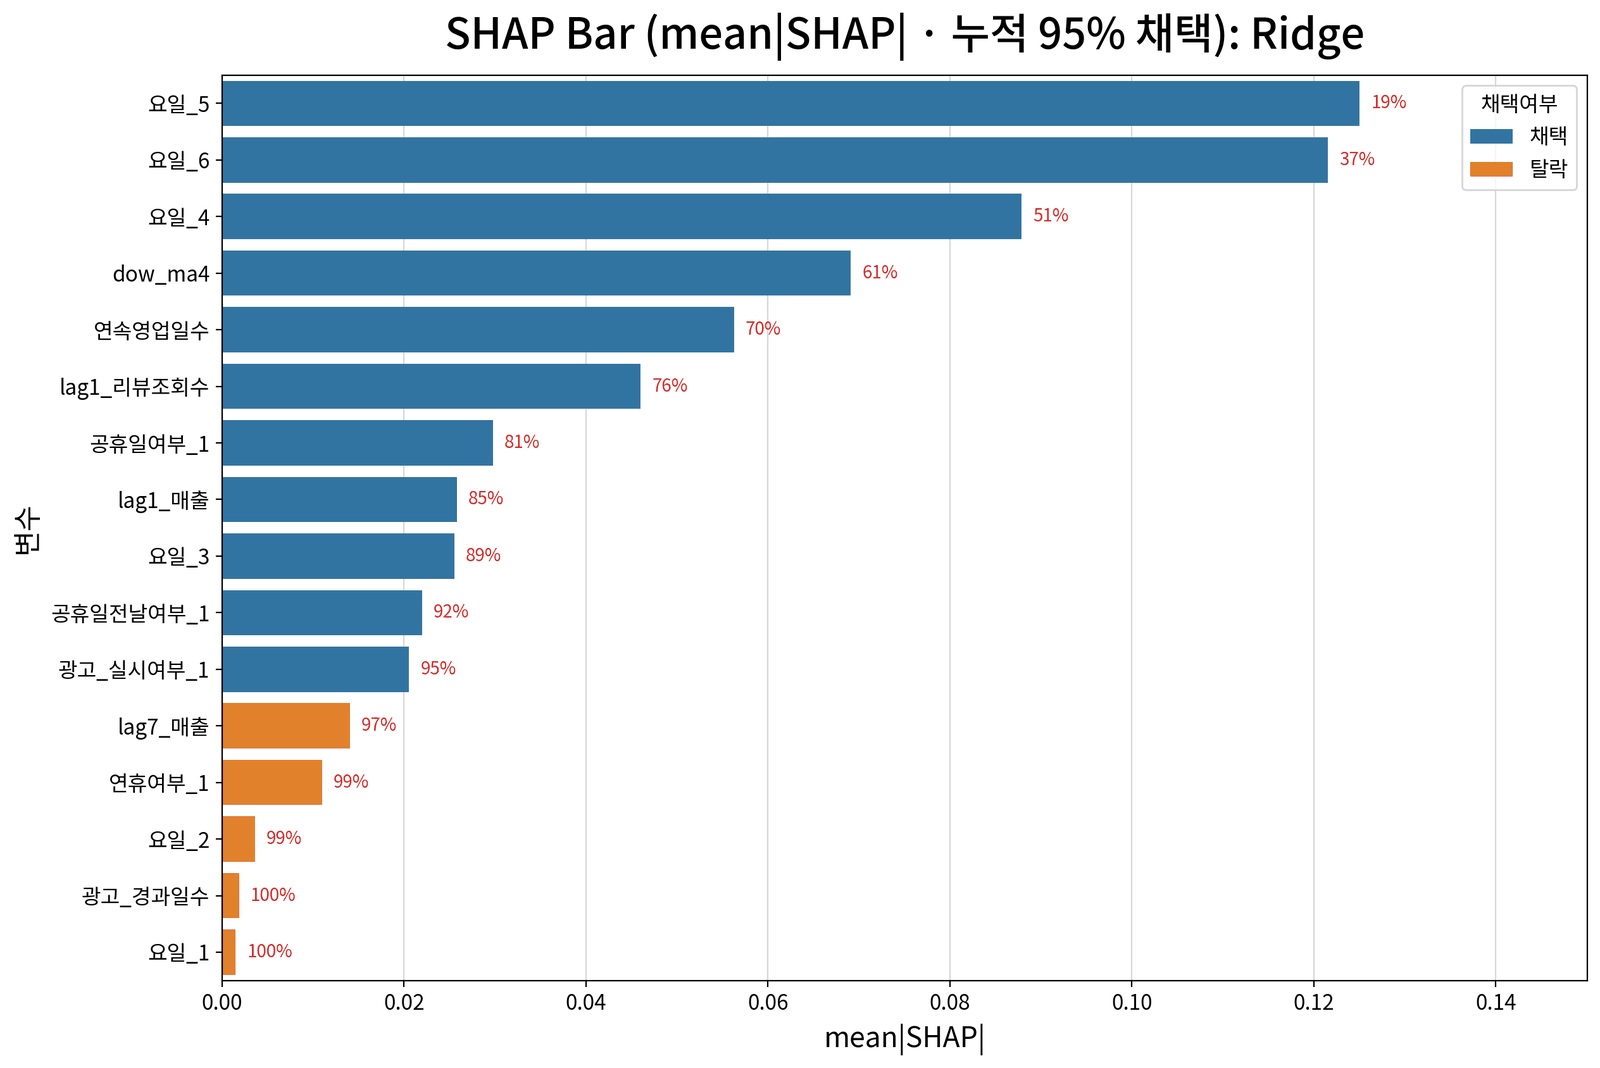

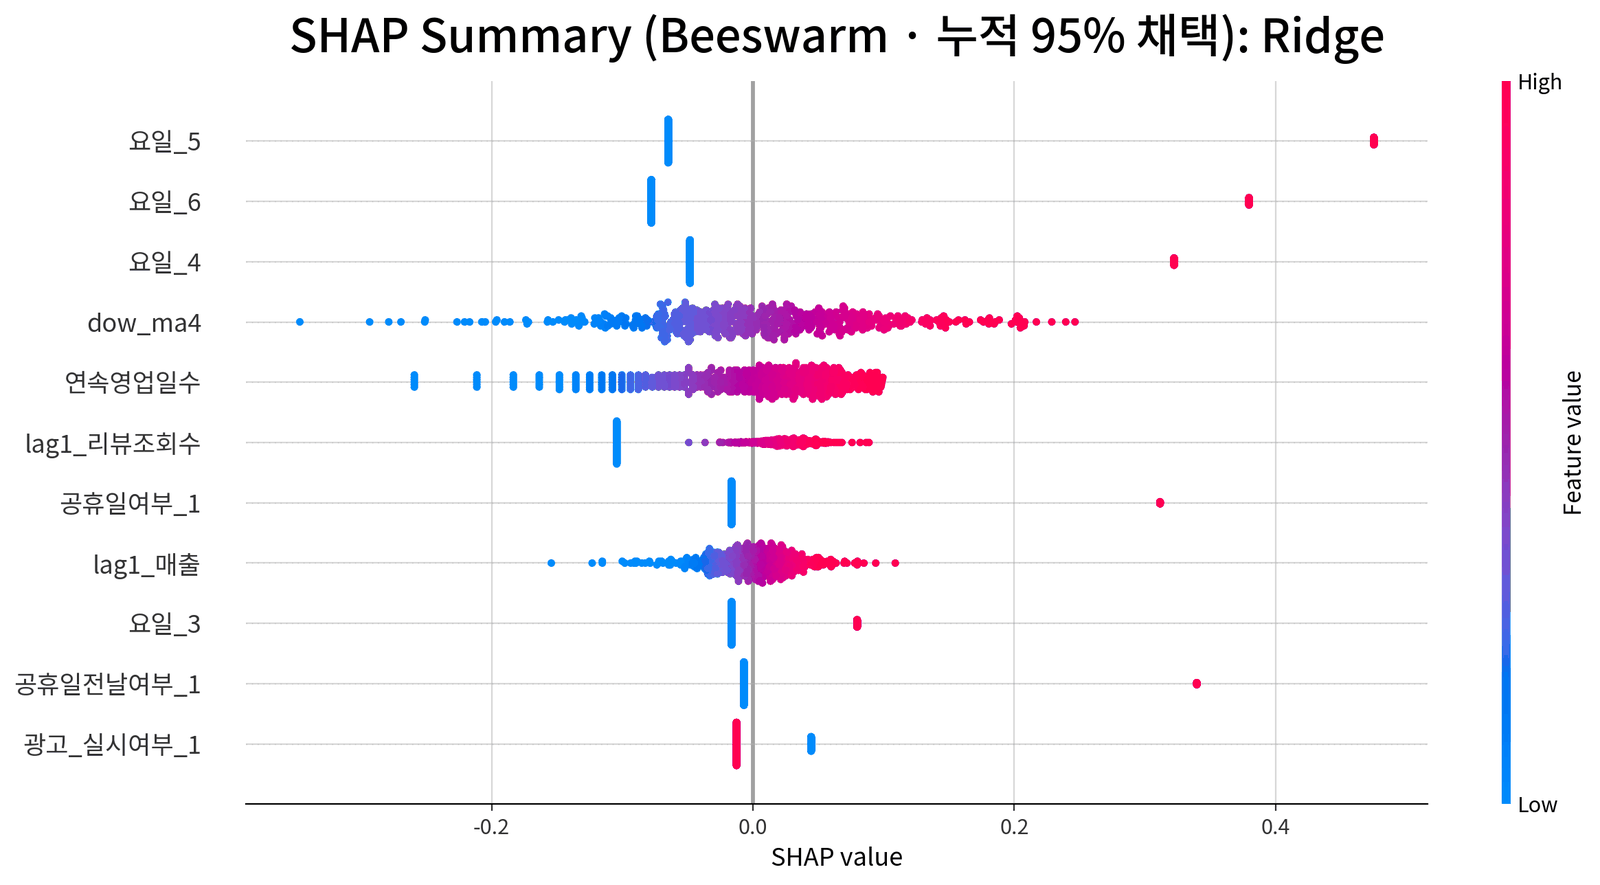

drop_first 기준 요일(그래프에서 제외): 화요일 (요일_0)
   요일_1 = 월요일
   요일_2 = 수요일
   요일_3 = 목요일
   요일_4 = 금요일
   요일_5 = 토요일
   요일_6 = 일요일


In [45]:
# =========================================================================
# 0. my_diag 모듈 내 save_model 함수 참조 오류 패치
# =========================================================================
my_diag.save_model = my_ml.save_model

# =========================================================================
# 1. 최종 승자 모델 로드
# =========================================================================
best_model_path = FINAL_MODEL_PATH     # 6.3.2 셀에서 정의한 최종 모델 경로
best_model = final_model               # 6.3.2 셀에서 불러온 최종 모델 재사용
print(f"최종채택 모델 로드 완료: {best_model_path}")

# =========================================================================
# 2. SHAP 값 계산
#    - summary_train : 학습 데이터(X_train, 544행) → 요인 순위·방향
#    - summary       : 테스트 데이터(X_test, 136행) → 최근 14영업일 Waterfall (6.5절 Waterfall 셀)
# =========================================================================
summary_train = my_diag.shap_analysis(
    project_name=PROJECT_NAME, estimator=best_model, x=X_train, workdir="shap_train"
)

summary = my_diag.shap_analysis(
    project_name=PROJECT_NAME, estimator=best_model, x=X_test
)

print(f"학습 SHAP: {summary_train.attrs['shap_values'].shape[0]}행 / "
      f"테스트 SHAP: {summary.attrs['shap_values'].shape[0]}행")

# =========================================================================
# 3. SHAP 분석 결과 시각화 (학습 데이터 기준)
# =========================================================================
# (1) 변수별 mean|SHAP| 영향력 순위 막대그래프
my_diag.shap_bar_plot(summary_train, cum_ratio=0.95, width=1280)

# (2) 변수값과 방향성을 보여주는 Beeswarm 요약 그래프
my_diag.shap_summary_plot(summary_train, cum_ratio=0.95, width=1280)

# =========================================================================
# 4. 요일 더미 번호 ↔ 요일명 확인 (drop_first 기준 요일 검증)
# =========================================================================
# (1) 실제 요일 인코딩 매핑 (Tuesday=0 이 drop_first 기준 범주)
dow_label_map = {"Tuesday": 0, "Monday": 1, "Wednesday": 2, "Thursday": 3,
                 "Friday": 4, "Saturday": 5, "Sunday": 6}

# (2) 코드 → 한글 요일명 변환표
en2ko = {"Monday": "월요일", "Tuesday": "화요일", "Wednesday": "수요일", "Thursday": "목요일",
         "Friday": "금요일", "Saturday": "토요일", "Sunday": "일요일"}

code2day = {i: en2ko[d] for d, i in dow_label_map.items()}

# (3) 실제 인코딩에 쓰인 0번 요일을 출력 (REF_DAY / ref_day 불일치 방지)
print(f"drop_first 기준 요일(그래프에서 제외): {code2day[0]} (요일_0)")
for c in summary_train.attrs["feature_names"]:
    if c.startswith("요일_"):
        code = int(float(c.split("_", 1)[1]))
        print(f"   {c} = {code2day[code]}")

### 6.4 최종 모델 SHAP 변수 기여도 해석

`my_diag.shap_analysis`로 도출한 **SHAP Bar Plot** 및 **SHAP Summary Plot**을 바탕으로 `Base: Ridge` 모델의 변수별 기여도와 영향 방향을 해석한 결과입니다. (학습 데이터 552행 기준, `LinearExplainer`)

> **해석 전 유의사항**
> * **SHAP 값의 단위는 `log(매출액)`**입니다. SHAP 값 $\phi$는 평균적인 날의 예측 대비 매출을 약 $e^{\phi}$배로 움직이는 효과로 읽습니다(예: +0.48 → 약 1.6배, −0.10 → 약 0.9배).
> * 파이프라인에서 범주형 변수가 **원-핫 인코딩(drop_first)**되어 총 16개 변수로 설명됩니다. 요일은 **화요일(요일_0)이 기준 범주**이며 `요일_1`=월, `요일_2`=수, `요일_3`=목, `요일_4`=금, `요일_5`=토, `요일_6`=일입니다. 이진 변수는 `공휴일여부_1`처럼 값이 1인 경우를 나타냅니다.
> * 수치형 변수는 로그 변환 후 표준화된 값으로 입력되므로, Beeswarm의 색상은 표준화된 상대 수준을 뜻합니다.
> * **SHAP 기여도는 모델이 예측에 어떤 변수를 얼마나 썼는지를 보여 주는 것이며, 인과 효과가 아닙니다.** 관측 데이터에서 학습한 연관이므로 "토요일이면 매출이 오른다"는 읽기는 가능하지만, "광고를 하면 매출이 몇 % 오른다" 같은 개입 효과로 해석하지 않습니다.

---

#### 1) 누적 기여도(95%) 기반 핵심 변수 선별

전체 16개 변수 중 누적 기여도 95%에 도달하는 **상위 11개 변수**가 채택되었습니다.

| 순위 | 변수 | 의미 | mean\|SHAP\| (약) | 누적 비율 |
| :---: | :--- | :--- | :---: | :---: |
| 1 | `요일_5` | 토요일 | 0.125 | 19% |
| 2 | `요일_6` | 일요일 | 0.122 | 37% |
| 3 | `요일_4` | 금요일 | 0.088 | 51% |
| 4 | `dow_ma4` | 같은 요일 최근 4회 평균 매출 | 0.069 | 61% |
| 5 | `연속영업일수` | 휴무 후 연속 영업 일수 | 0.056 | 70% |
| 6 | `lag1_리뷰조회수` | 전일 블로그 리뷰 조회수 | 0.046 | 76% |
| 7 | `공휴일여부_1` | 공휴일 | 0.030 | 81% |
| 8 | `lag1_매출` | 직전 영업일 매출 | 0.026 | 85% |
| 9 | `요일_3` | 목요일 | 0.026 | 89% |
| 10 | `공휴일전날여부_1` | 공휴일 전날 | 0.022 | 92% |
| 11 | `광고_실시여부_1` | 체험단 광고 집행일 | 0.021 | 95% |

* **탈락 변수(누적 95% 이후)**: `lag7_매출`, `연휴여부_1`, `요일_2`(수), `광고_경과일수`, `요일_1`(월)
* **요일 효과의 비중**: 요일 더미 6개를 합치면 전체 기여도의 **약 55%**를 차지하며, 이 중 토·일·금 3개 요일이 약 51%입니다. 이 모델의 예측은 **"주말인가, 평일인가"**가 가장 크게 좌우합니다.
* **그다음 순서**: `dow_ma4`(약 10%), `연속영업일수`(약 9%), `lag1_리뷰조회수`(약 7%)가 뒤를 잇습니다.
* **`lag7_매출`이 탈락한 이유**: `lag7_매출`(약 2%)은 지난주 같은 요일 매출로 정확히 계산되었지만, 같은 요일 정보를 더 안정적으로 담은 `dow_ma4`와 상관이 높아(ρ = 0.60, 5.4.2) 모델이 주로 `dow_ma4`를 썼습니다. 하루짜리 값보다 4회 평균이 튀는 날의 영향을 덜 받기 때문입니다.

---

#### 2) 변수별 영향 방향 해석

* **요일 (`요일_5` 토, `요일_6` 일, `요일_4` 금, `요일_3` 목)**
  * 해당 요일인 날(High, 빨강)은 SHAP 값이 **토 약 +0.48, 일 약 +0.38, 금 약 +0.32, 목 약 +0.08**로 양(+)의 방향에 위치하고 해당 요일이 아닌 날(Low, 파랑)은 소폭 음(−)의 값을 가집니다.
  * 즉 **토 > 일 > 금 > 목** 순으로 평균 대비 매출을 끌어올리며(토요일 약 1.6배), 5.4.2 ANOVA에서 확인한 "금·토·일은 높고 월~목은 낮은" 구조와 같습니다. 월요일(`요일_1`)과 수요일(`요일_2`)은 기준인 화요일과 차이가 작아 탈락 구간에 위치합니다.

* **`dow_ma4` (4위) · `lag1_매출` (8위)**
  * 두 변수 모두 값이 높을수록(빨강) SHAP 값이 양(+)으로 이동합니다. `dow_ma4`는 약 −0.35 ~ +0.25, `lag1_매출`은 약 −0.15 ~ +0.11 범위로, 최근 같은 요일의 매출 수준과 직전 영업일 매출이 높을수록 당일 예측도 높아집니다.
  * 다만 요일 더미가 이미 요일별 수준 차이를 설명하므로, 두 시차 변수의 기여도를 합쳐도(약 14%) 요일 더미 전체의 약 4분의 1 수준입니다.

* **`연속영업일수` (5위)**
  * 값이 낮을수록(파랑) SHAP 값이 최대 약 −0.26까지 내려가고, 값이 높을수록(빨강) 약 +0.10까지 올라가는 **양(+)의 관계**입니다.
  * 휴무 직후 영업을 재개한 초기 며칠은 매출이 낮고 연속 영업이 이어질수록 매출이 회복되는 패턴으로 해석됩니다. 다만 개업 초기(2024년 7월) 역시 연속영업일수가 낮은 구간이므로, **개업 초기 효과가 섞여 있는지 6.6에서 확인합니다.**

* **`lag1_리뷰조회수` (6위)**
  * 조회수가 0인 날(파랑, 약 −0.10)과 조회가 발생한 날(보라~빨강, 약 −0.05 ~ +0.09)이 뚜렷하게 나뉩니다.
  * 조회수 0인 날은 대부분 **체험단 광고 시작(2024-11-24) 이전 구간**이므로, 이 변수의 음(−) 효과에는 리뷰 효과뿐 아니라 **개업 초기 저매출 기간이 함께 반영**되어 있을 수 있습니다. 이 역시 6.6에서 확인합니다.

* **`공휴일여부_1` (7위) · `공휴일전날여부_1` (10위)**
  * 공휴일인 날은 약 **+0.31**, 공휴일 전날은 약 **+0.34**의 양(+) 기여를 보입니다(평균 대비 약 1.36~1.40배).
  * 해당일이 드물어 평균 기여도(mean|SHAP|) 순위는 낮지만 **발생한 날의 개별 효과 크기는 목요일 효과보다 큽니다.** 5.4.2 단변량 ANOVA에서는 공휴일이 유의하지 않았지만 요일을 함께 넣은 모델에서는 뚜렷한 상승 요인으로 나타났습니다. 요일 차이에 가려져 있던 효과가 드러난 것으로 볼 수 있습니다.
  * 단, 이 값은 **학습 기간(552행) 기준**입니다. 6.3.3 검증에서 공휴일은 테스트 기간에도 모델의 이득이 가장 컸던 날이었지만, **공휴일 전날의 상승 효과는 테스트 기간(2026년 2~6월)에 재현되지 않아** 오히려 과대 예측의 원인이 되었습니다. 공휴일 전날 효과는 표본(35일)이 적어 기간마다 달라질 수 있는 불안정한 효과로 봅니다.

* **`광고_실시여부_1` (11위)**
  * 광고 집행일(빨강)이 약 **−0.01**, 미집행일(파랑)이 약 **+0.045**로, 다른 변수를 통제한 상태에서는 광고 집행일의 예측이 오히려 소폭 낮습니다.
  * 광고 실시 여부는 `lag1_리뷰조회수`와 상관이 높아(ρ = +0.61) 두 변수가 효과를 나눠 가진 결과로 보입니다. 또 학습 구간의 광고 미집행일은 개업 초기와 광고 종료 후로 성격이 다르고 테스트 구간은 전부 광고 종료 후라(5.4.4) **광고의 순수한 효과로 해석하지 않습니다.**

drop_first 기준 요일: 화요일 (요일_0)
수요일    2
목요일    2
금요일    2
토요일    2
일요일    2
월요일    2
화요일    2
Name: count, dtype: int64


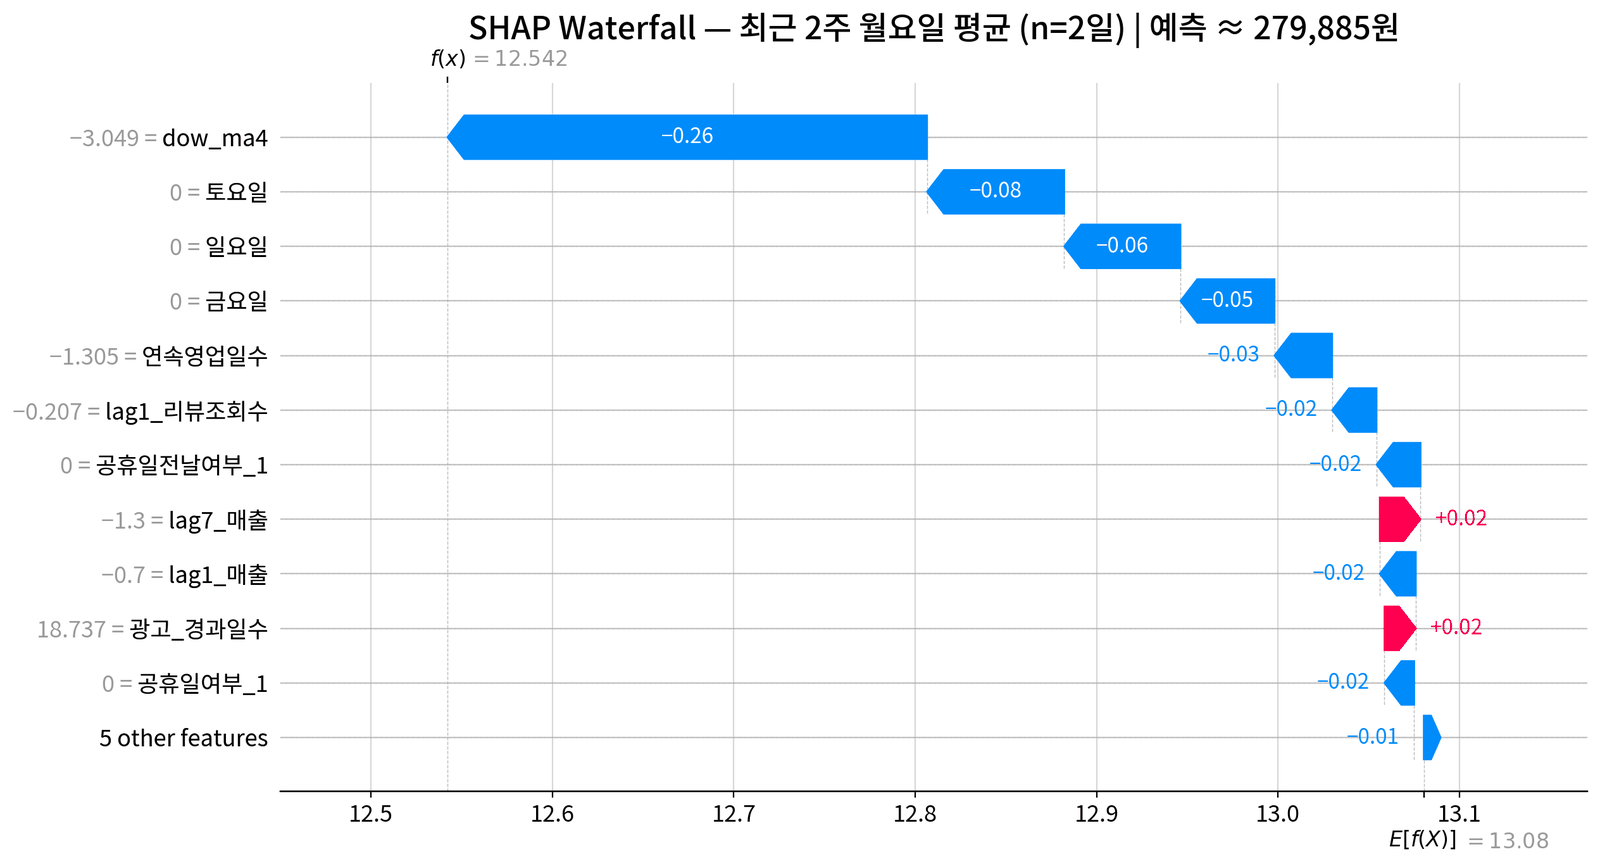

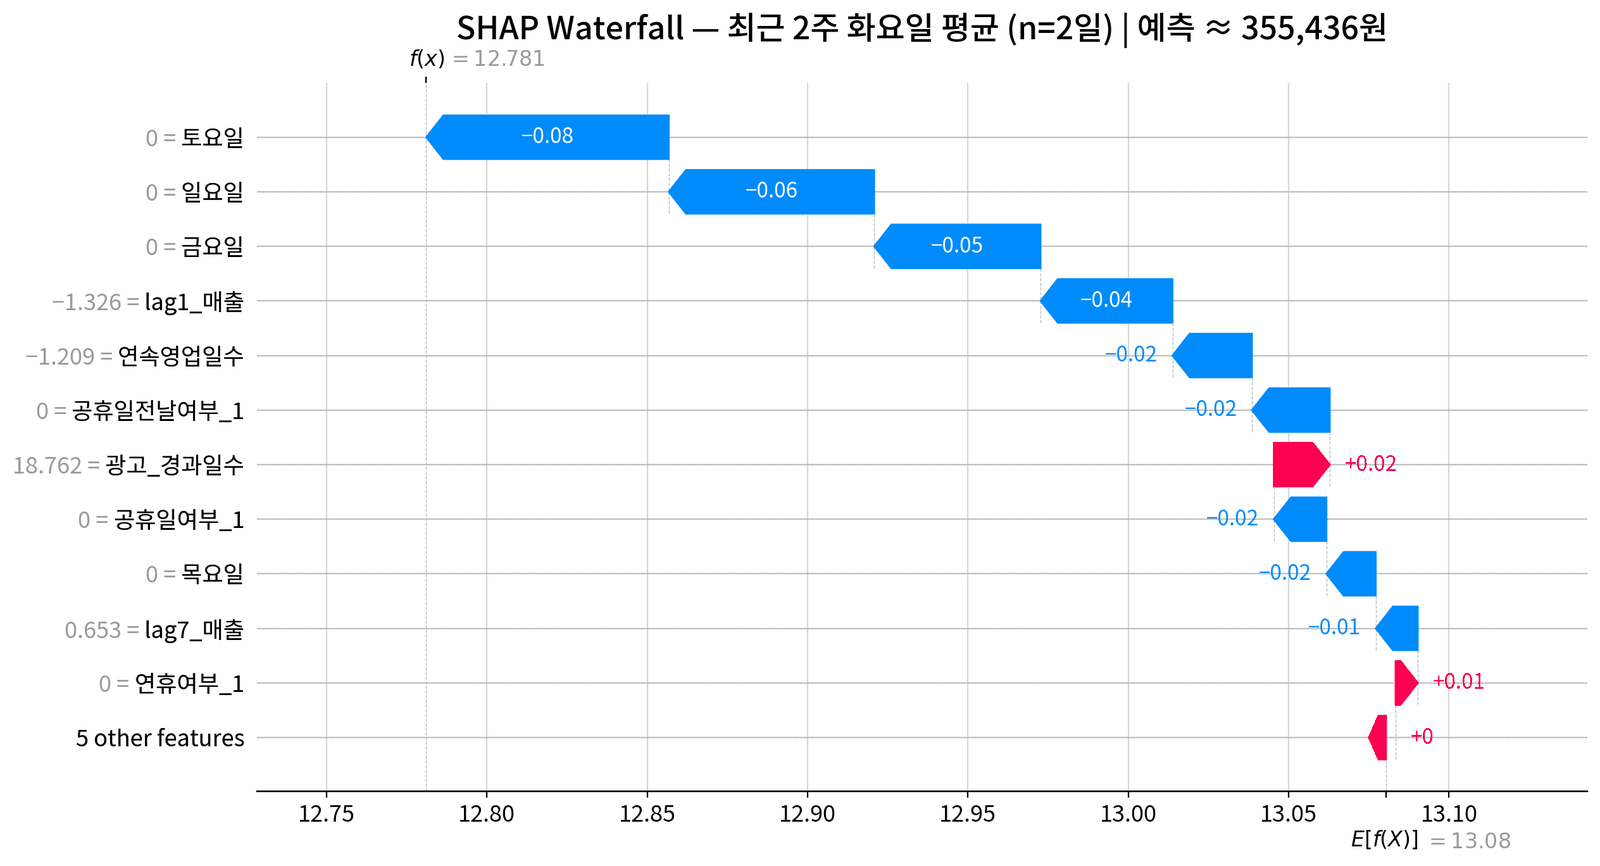

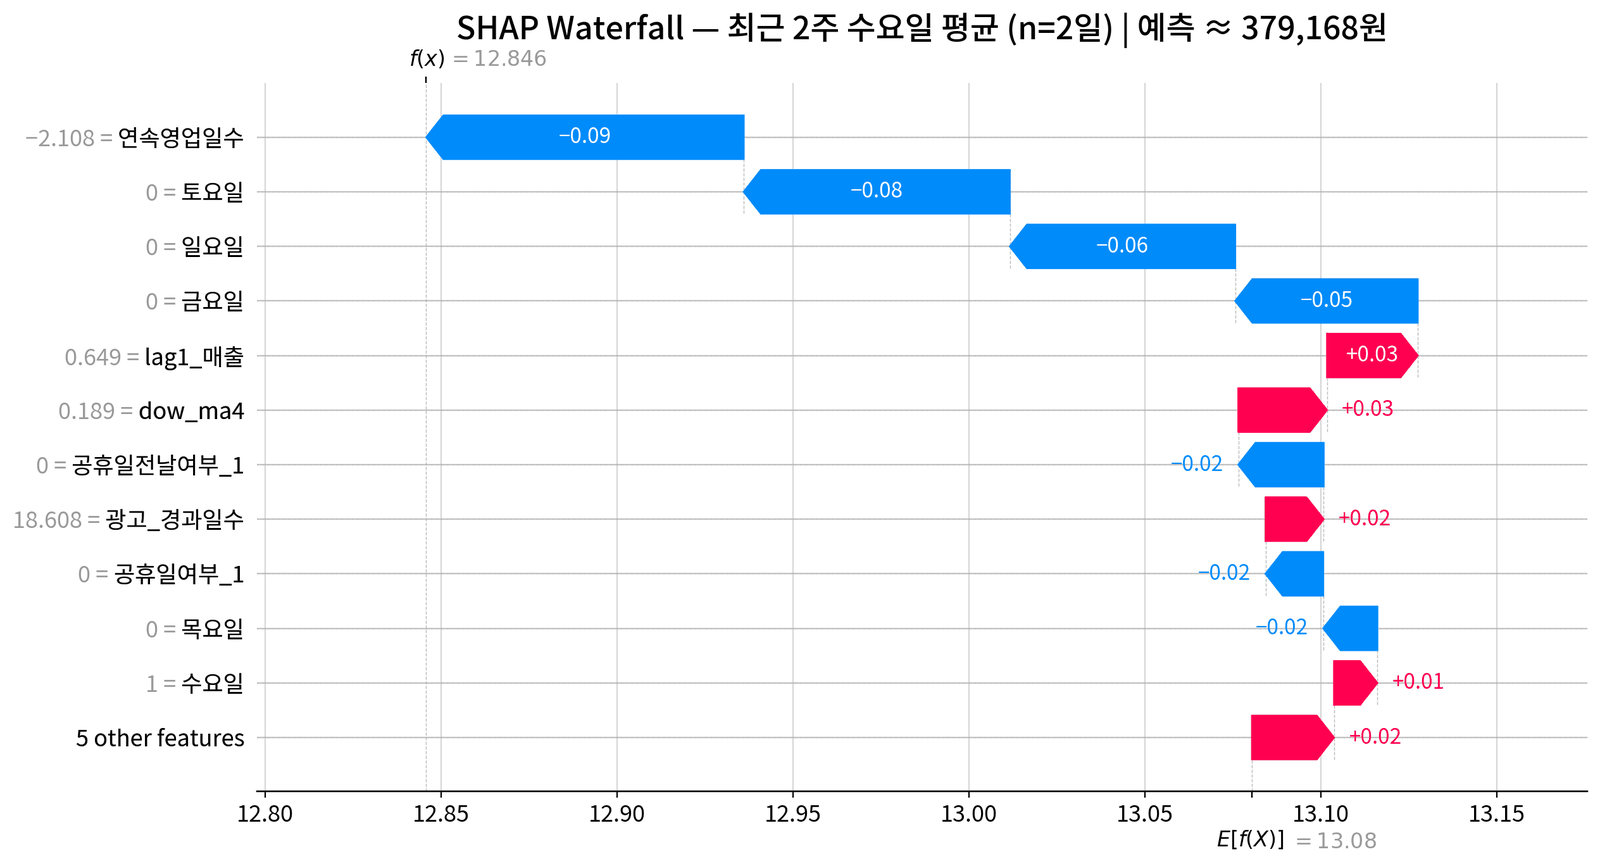

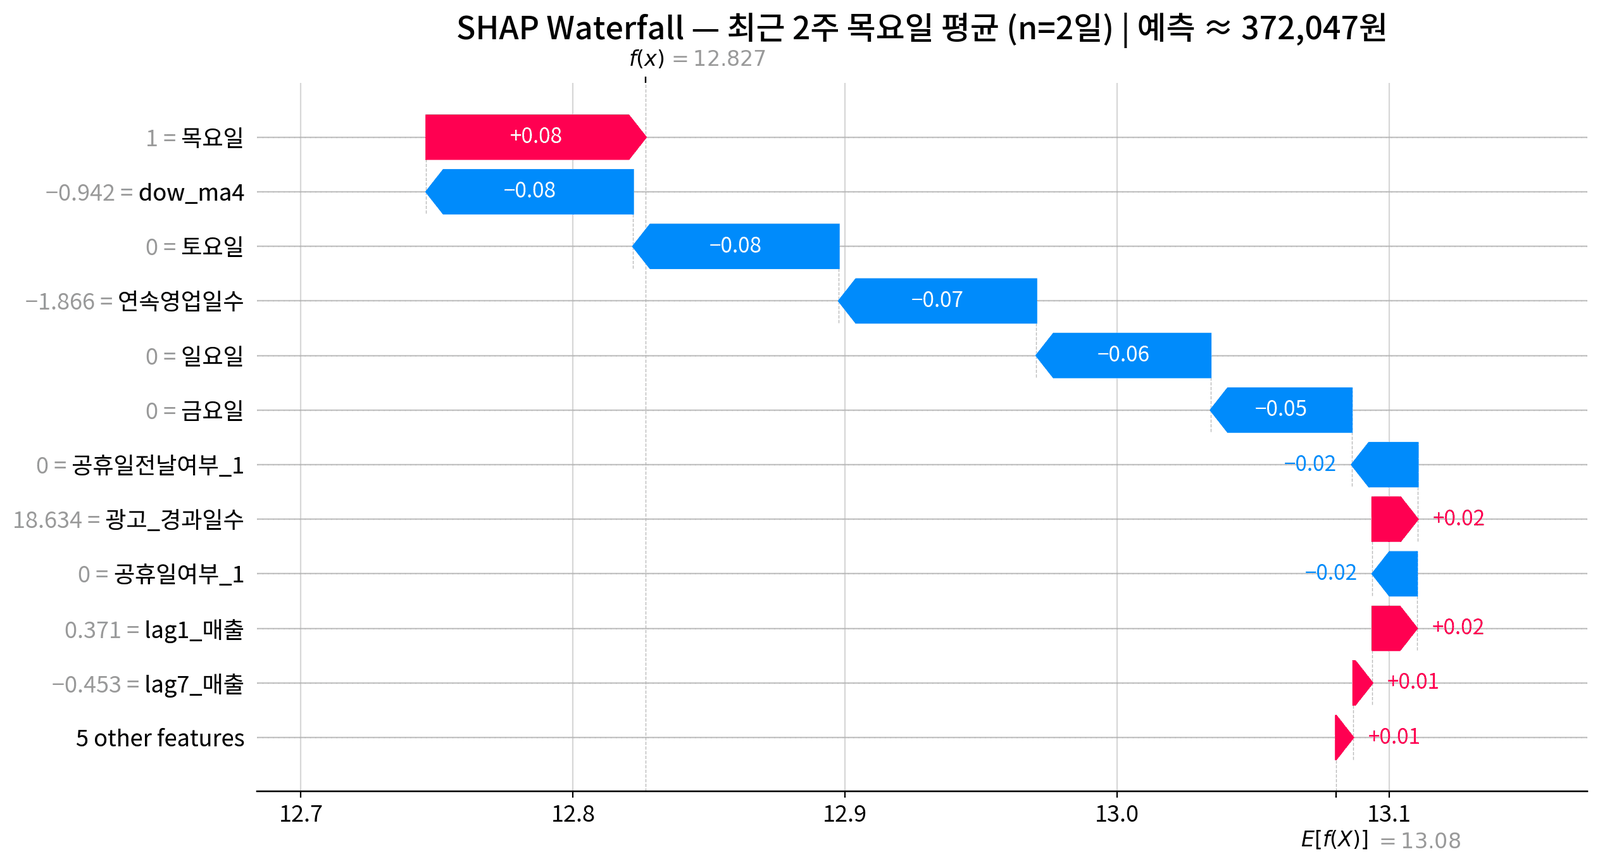

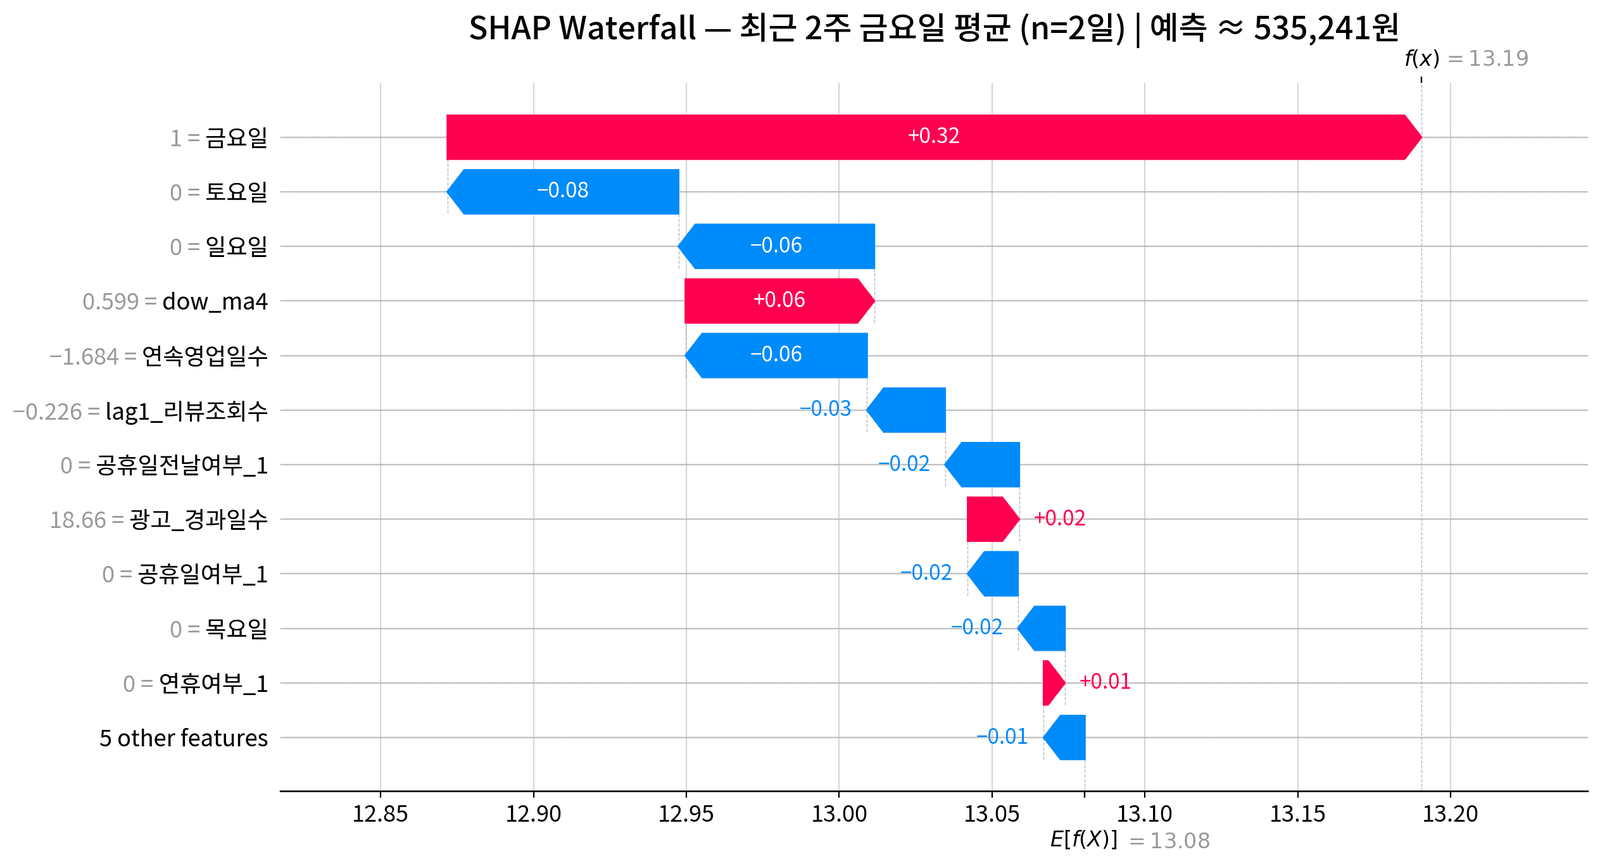

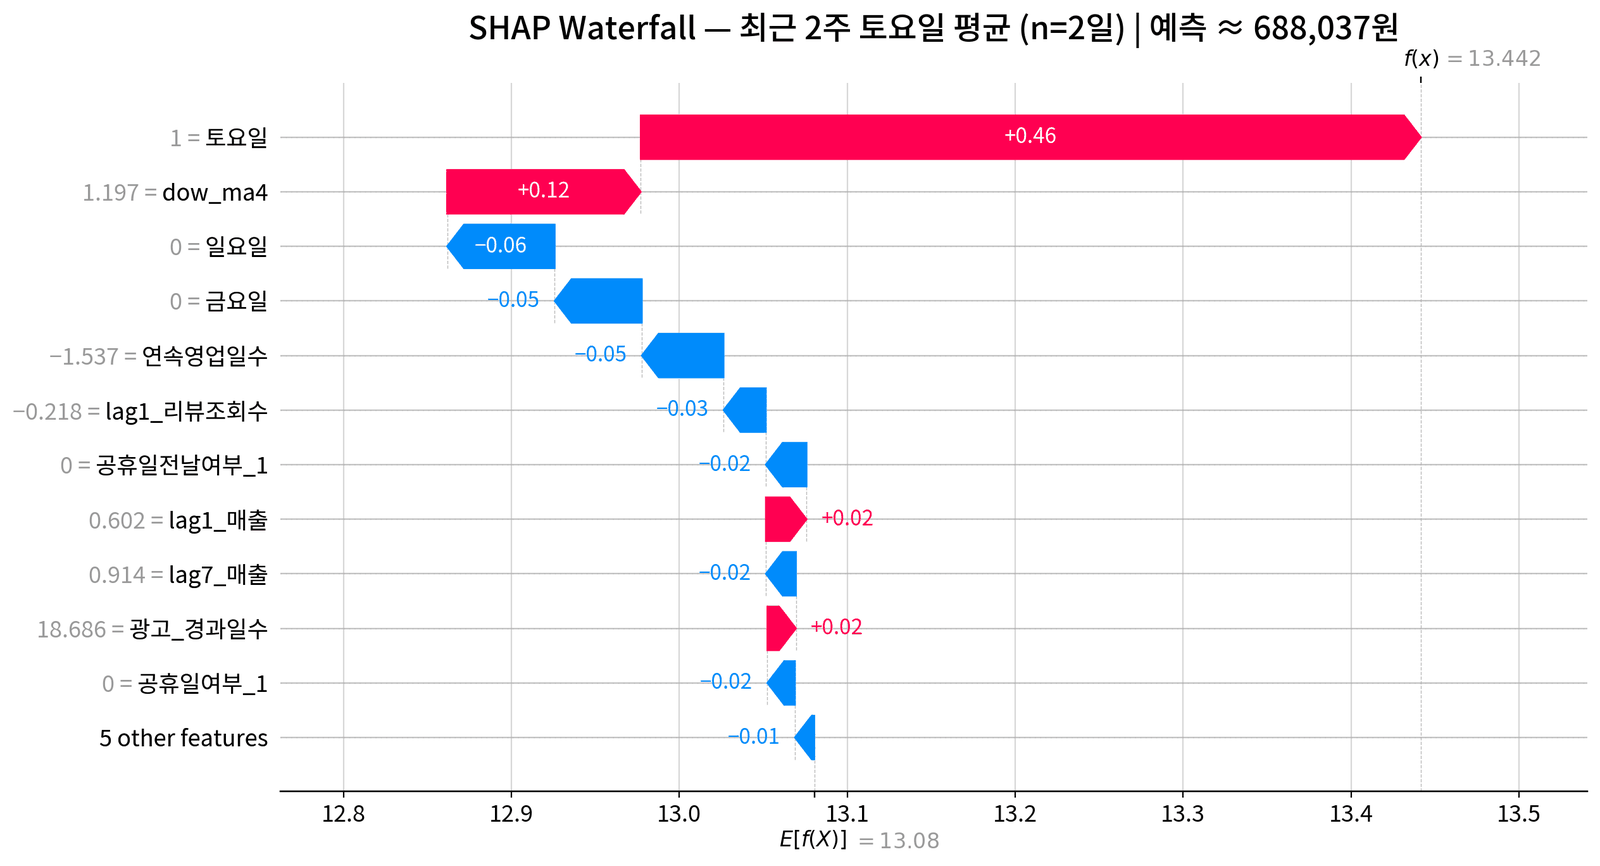

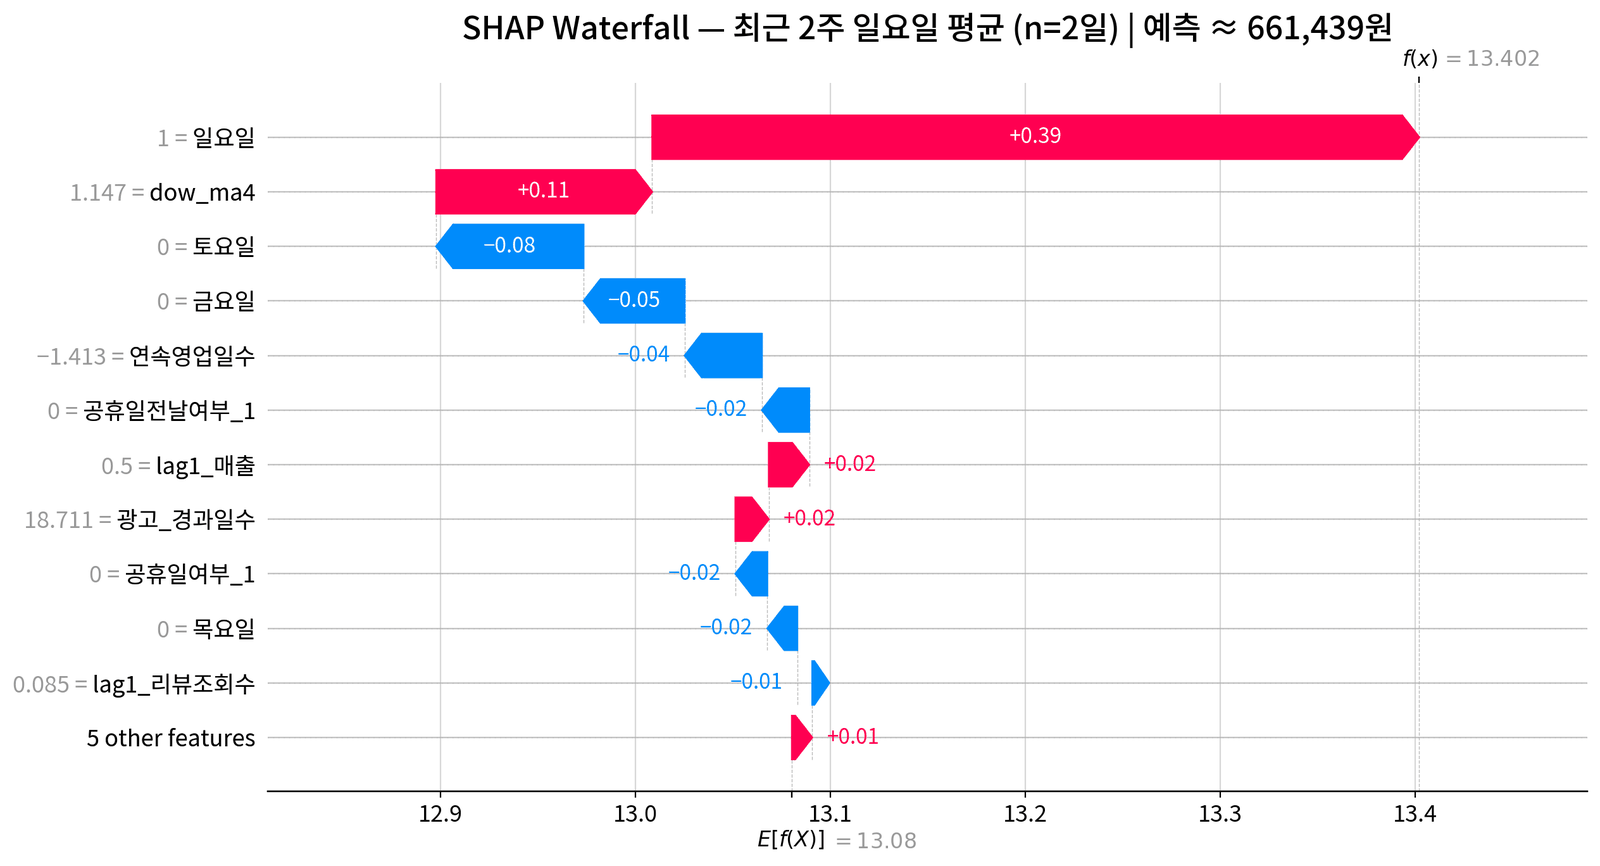

In [46]:
# =========================================================================
# - 최근 2주(14영업일) 같은 요일 평균 SHAP Waterfall — my_diag.shap_waterfall_plot 활용
#    - 요일 인코딩은 6.4 셀에서 정의한 dow_label_map 기준
#    - 요일_0(= ref_day)은 drop_first로 빠진 기준 범주

# =========================================================================
RECENT_DAYS = 14   # 최근 14영업일

# =========================================================================
# 1. 요일 코드 -> 요일명 매핑 (6.4 셀의 dow_label_map 기준)
# =========================================================================
#    (en2ko·code2day 는 6.4 셀에서 정의한 것을 그대로 사용)

# 요일 더미 컬럼명 -> 요일명 (기준 요일 0번은 더미가 없으므로 제외)
dow_column_means = {f"요일_{i}": name for i, name in code2day.items() if i != 0}
print(f"drop_first 기준 요일: {code2day[0]} (요일_0)")

# =========================================================================
# 2. 원시 SHAP 및 데이터 추출 (최근 14행만)
# =========================================================================
shap_vals = np.asarray(summary.attrs["shap_values"], dtype=float)[-RECENT_DAYS:]
all_x_data = summary.attrs["data"].iloc[-RECENT_DAYS:]
feat_names = list(summary.attrs["feature_names"])
base_value = float(summary.attrs["expected_value"])

# =========================================================================
# 3. 행별 요일명 복원 (SHAP 행은 X_test와 같은 순서 → X_test 원본 요일 코드 사용)
# =========================================================================
if len(X_test) != len(summary.attrs["shap_values"]):
    raise ValueError("SHAP 행 수와 X_test 행 수가 다릅니다. shap_analysis에 x=X_test를 넣었는지 확인하세요.")

day_labels = X_test["요일"].astype(int).iloc[-RECENT_DAYS:].map(code2day).values

# =========================================================================
# 4. 요일별 평균 SHAP·평균 변수값 (월~일 순서)
# =========================================================================
dow_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]

shap_avg = (
    DataFrame(shap_vals, columns=feat_names)
    .groupby(day_labels).mean()
    .reindex(dow_order).dropna()
)
x_avg = (
    all_x_data[feat_names].reset_index(drop=True)
    .groupby(day_labels).mean()
    .reindex(dow_order).dropna()
)
day_counts = pd.Series(day_labels).value_counts()
print(day_counts)   # 요일별 2일씩이면 정상

# =========================================================================
# 5. 평균 7행을 담은 summary 복사본 (cum_ratio 등 요약표는 원본 그대로)
# =========================================================================
summary_dow = summary.copy()
summary_dow.attrs = {
    **summary.attrs,
    "shap_values": shap_avg.values,
    "data": x_avg,
}

# =========================================================================
# 6. my_diag 모듈로 요일별 Waterfall 시각화
# =========================================================================
for i, day_name in enumerate(shap_avg.index):
    pred = base_value + shap_avg.loc[day_name].sum()   # 로그 예측값

    my_diag.shap_waterfall_plot(
        summary_dow,
        index=i,
        cum_ratio=0.95,
        title=(
            f"SHAP Waterfall — 최근 2주 {day_name} 평균 (n={day_counts[day_name]}일)"
            f" | 예측 ≈ {np.exp(pred):,.0f}원"
        ),
        column_means=dow_column_means,
        width=1280,
    )

### 6.5 최근 2주(14영업일) 요일별 SHAP Waterfall 해석

테스트 구간 마지막 14영업일(요일별 2일씩)의 SHAP 값을 요일별로 평균하여 Waterfall로 분해한 결과입니다. 모든 그래프의 출발점은 테스트 구간 평균 예측값 $E[f(X)] = 13.08$(로그, 약 47.9만 원)이며, 막대를 모두 더한 값이 해당 요일의 평균 예측값 $f(x)$입니다.

> **읽는 법**: 요일 더미는 "해당 요일이 아님(0)"일 때도 작은 음(−)의 막대가 생깁니다. 평균 예측에는 토·일·금요일의 높은 매출이 섞여 있으므로, 그 요일이 아닌 날은 평균보다 그만큼 낮게 조정되기 때문입니다. 예를 들어 평일 그래프의 `0 = 토요일 (−0.08)`은 "토요일이 아니므로 평균보다 약 8% 낮다"는 뜻입니다.

---

#### 1) 요일별 예측 매출 요약

| 요일 | 예측 f(x) (로그) | 예측 매출(원) | 가장 큰 상승 요인 | 가장 큰 하락 요인 |
| :---: | :---: | :---: | :--- | :--- |
| 토 | 13.442 | **688,037** | 토요일 +0.46, dow_ma4 +0.12 | 일·금요일 아님 −0.11, 연속영업일수 −0.05 |
| 일 | 13.402 | **661,439** | 일요일 +0.39, dow_ma4 +0.11 | 토·금요일 아님 −0.13, 연속영업일수 −0.04 |
| 금 | 13.190 | **535,241** | 금요일 +0.32, dow_ma4 +0.06 | 토·일요일 아님 −0.14, 연속영업일수 −0.06 |
| 수 | 12.846 | 379,168 | lag1_매출 +0.03, dow_ma4 +0.03 | 토·일·금요일 아님 −0.19, 연속영업일수 −0.09 |
| 목 | 12.827 | 372,047 | 목요일 +0.08 | 토·일·금요일 아님 −0.19, dow_ma4 −0.08, 연속영업일수 −0.07 |
| 화 | 12.781 | 355,436 | (기준 요일, 뚜렷한 상승 요인 없음) | 토·일·금요일 아님 −0.19, lag1_매출 −0.04 |
| 월 | 12.542 | **279,885** | 없음 | dow_ma4 −0.26, 토·일·금요일 아님 −0.19 |

* 예측 매출은 **토 > 일 > 금 > 수 ≈ 목 > 화 > 월** 순으로, 주말 3일(금·토·일)과 평일 4일의 격차가 뚜렷합니다. 6.4의 전역 해석과 같은 구조입니다.

---

#### 2) 요일별 상세 해석

* **토요일 · 일요일 (주말 최고점)**
  * 요일 자체 효과(토 +0.46, 일 +0.39)가 가장 크고 최근 4주 같은 요일 평균(`dow_ma4`, 표준화값 약 +1.2)도 높아 +0.11~0.12를 더합니다.
  * 예측 매출은 각각 약 **68.8만 원, 66.1만 원**으로 테스트 구간 평균 예측(약 47.9만 원)보다 약 38~44% 높습니다.

* **금요일 (주말 진입)**
  * 금요일 효과 +0.32가 가장 크고 `dow_ma4`도 +0.06으로 기여해 약 **53.5만 원**으로 평균보다 약 12% 높습니다.

* **화 · 수 · 목요일 (평일 중위권, 약 36만~38만 원)**
  * 주말 요일이 아니어서 생기는 하향 조정(합계 약 −0.19)이 공통 바탕입니다.
  * 목요일은 요일 효과 +0.08이 있지만 `dow_ma4`(−0.08)와 `연속영업일수`(−0.07)가 상쇄합니다.
  * 수요일은 `연속영업일수`가 −0.09로 가장 크게 끌어내렸지만 직전 영업일 매출과 최근 수요일 평균이 높아 일부 만회했습니다.
  * 화요일은 기준 요일이라 요일 자체의 상승 요인이 없고 직전 영업일 매출(`lag1_매출`, −0.04)도 낮았습니다.

* **월요일 (최저점, 약 28.0만 원)**
  * 최근 4주 월요일 평균(`dow_ma4`)이 표준화값 약 −3.0으로 매우 낮아 **−0.26**으로 가장 크게 작용합니다. 요일 효과 자체보다 **최근 월요일 매출이 부진했던 흐름**이 예측을 끌어내린 것입니다.

---

#### 3) 최근 2주에 공통으로 나타난 특징

* **연속영업일수의 일관된 하향 압력 (−0.02 ~ −0.09)**: 7개 요일 모두에서 음(−)의 막대가 나타납니다. 최근 2주는 휴무 후 영업을 재개한 직후 구간이어서 모델이 휴무 직후 기간을 매출이 낮아지는 구간으로 학습한 영향이 요일과 관계없이 반영되었습니다.
* **공휴일·공휴일 전날 없음**: 최근 2주에는 공휴일과 공휴일 전날이 없어 모든 요일에서 두 변수가 각각 약 −0.02로 소폭 음(−)으로 작용했습니다.
* **광고 종료 후 경과일수**: 모든 요일에서 `광고_경과일수`가 +0.02로 나타났습니다. 6.4에서 누적 95% 밖이었던 작은 효과이며, 광고 종료 후 시간이 많이 지난 시기라는 점만 반영된 것으로 봅니다.
* **연휴 기간의 방향 (탈락 변수 참고)**: 누적 95% 밖이라 6.4 Beeswarm에는 표시되지 않았던 `연휴여부_1`이 일부 요일에서 `0 = 연휴여부_1 (+0.01)`로 나타납니다. 연휴가 아닌 날이 소폭 양(+)이라는 뜻이므로, 연휴 기간은 오히려 소폭 **음(−)의 방향**으로 작용합니다.

### 6.6 개업 초기 효과 점검

6.4에서 `연속영업일수`와 `lag1_리뷰조회수`는 값이 낮을수록 매출을 낮추는 방향으로 작용했습니다. 그런데 두 변수가 낮은 날은 개업 초기(2024년 7~11월)에 몰려 있어, 이것이 변수 자체의 효과인지 "가게가 막 문을 연 시기라 손님이 적었던" 효과인지 구분되지 않습니다. 광고 시작 전 기간도 개업 초기와 겹쳐 광고 효과 역시 같은 문제를 안고 있습니다.

이를 확인하기 위해 학습 구간을 **광고 시작일(2024-11-24) 이후로 한정**한 모델을 최종 모델과 같은 설정(`Base: Ridge`)으로 다시 학습하고 변수 기여도 순위를 비교합니다.

| 결과 | 해석 |
| :--- | :--- |
| 개업 초기를 빼도 `연속영업일수`·`lag1_리뷰조회수`의 순위가 유지됨 | 변수 자체의 효과 |
| 개업 초기를 빼면 두 변수의 순위가 크게 떨어짐 | 개업 초기 효과가 섞여 있었음 |

※ 광고 시작 이후 기간에는 리뷰 조회수가 0인 날(광고 전 기간)이 사라지므로, `lag1_리뷰조회수`의 기여가 개업 초기의 낮은 매출에서 나온 것인지 직접 확인할 수 있습니다.

In [47]:
# =========================================================================
# 6.6 개업 초기 효과 점검: 광고 시작일 이후로 학습을 한정한 모델과 비교
# =========================================================================
from sklearn.linear_model import Ridge

AD_START = pd.Timestamp("2024-11-24")   # 체험단 광고 시작일 (3.2에서 확인)

# 1. 학습 구간 중 광고 시작일 이후만 남긴 데이터 (날짜는 5.3에서 보존한 영업일_final 사용)
train_dates = 영업일_final.iloc[:len(X_train)].reset_index(drop=True)
after_ad = (train_dates >= AD_START).values
X_train_ad, y_train_ad = X_train[after_ad], y_train[after_ad]
print(f"전체 학습 {len(X_train)}행 → 광고 시작 이후 {len(X_train_ad)}행 (개업 초기 {len(X_train) - len(X_train_ad)}행 제외)")

# 2. 최종 모델과 같은 설정(Base: Ridge, VIF·스케일링·더미)으로 다시 학습
ridge_ad = my_ml.fit_pipeline(
    Ridge(random_state=RANDOM_STATE), X_train_ad, y_train_ad,
    vif=True, scale=True, drop_first=True, name="ridge_after_ad", verbose=False,
)

# 3. 두 모델의 SHAP 기여도(mean|SHAP|) 순위 비교 (my_diag.shap_analysis)
summary_ad = my_diag.shap_analysis(
    project_name=PROJECT_NAME, estimator=ridge_ad, x=X_train_ad, workdir="shap_after_ad"
)

def shap_importance(summary):
    """shap_analysis 결과에서 변수별 mean|SHAP| 을 큰 순서로 반환한다."""
    values = summary.attrs["shap_values"]
    values = getattr(values, "values", values)
    return pd.Series(np.abs(np.asarray(values)).mean(axis=0),
                     index=summary.attrs["feature_names"]).sort_values(ascending=False)

imp_full, imp_ad = shap_importance(summary_train), shap_importance(summary_ad)
compare_df = DataFrame({
    "전체 학습 순위": imp_full.rank(ascending=False).astype(int),
    "전체 학습 mean|SHAP|": imp_full.round(4),
    "광고 이후 학습 순위": imp_ad.rank(ascending=False).astype(int),
    "광고 이후 학습 mean|SHAP|": imp_ad.round(4),
}).sort_values("전체 학습 순위")
compare_df["순위 변화"] = compare_df["전체 학습 순위"] - compare_df["광고 이후 학습 순위"]
display(Markdown("##### 학습 기간에 따른 변수 기여도 순위 비교 (순위 변화 양수 = 광고 이후 학습에서 순위 상승)"))
display(compare_df)

# 4. 테스트 구간 성능 비교 (원화 MAE)
y_test_won_ = np.exp(y_test)
perf_df = DataFrame({
    "학습 기간": ["전체 학습 구간", "광고 시작 이후"],
    "학습 행수": [len(X_train), len(X_train_ad)],
    "Test MAE(원)": [
        round(mean_absolute_error(y_test_won_, np.exp(best_model.predict(X_test)))),
        round(mean_absolute_error(y_test_won_, np.exp(ridge_ad.predict(X_test)))),
    ],
})
display(Markdown("##### 테스트 구간 성능 비교"))
display(perf_df)

Background dataset has 425 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=425 when initializing the masker.


전체 학습 552행 → 광고 시작 이후 425행 (개업 초기 127행 제외)
모델: Ridge / explainer: LinearExplainer
설명 대상: 425행 × 16변수 / base value: 13.0121 / SHAP 값의 단위: 예측값(y 단위)
SHAP 분석 결과 저장 완료 → sales_prediction_proj\shap_after_ad\ridge_after_ad_shap.pkl


##### 학습 기간에 따른 변수 기여도 순위 비교 (순위 변화 양수 = 광고 이후 학습에서 순위 상승)

,전체 학습 순위,전체 학습 mean|SHAP|,광고 이후 학습 순위,광고 이후 학습 mean|SHAP|,순위 변화
요일_5,1,0.1251,1,0.1472,0
요일_6,2,0.1215,2,0.1253,0
요일_4,3,0.0879,3,0.0905,0
dow_ma4,4,0.0691,7,0.0324,-3
연속영업일수,5,0.0563,4,0.0619,1
lag1_리뷰조회수,6,0.0460,13,0.0093,-7
공휴일여부_1,7,0.0298,5,0.0359,2
lag1_매출,8,0.0258,11,0.0123,-3
요일_3,9,0.0255,6,0.0328,3
공휴일전날여부_1,10,0.0220,8,0.0322,2


##### 테스트 구간 성능 비교

,학습 기간,학습 행수,Test MAE(원)
0,전체 학습 구간,552,269120
1,광고 시작 이후,425,278530


##### 6.6 결과 해석

학습 구간 552행 중 광고 시작 전 개업 초기 127행을 빼고 광고 시작 이후 425행으로 같은 설정의 Ridge를 다시 학습했습니다.

| 변수 | 전체 학습 순위 (mean\|SHAP\|) | 광고 이후 학습 순위 (mean\|SHAP\|) | 판정 |
| :--- | :---: | :---: | :--- |
| `요일_5`·`요일_6`·`요일_4` (토·일·금) | 1·2·3위 | 1·2·3위 | 변화 없음 |
| `연속영업일수` | 5위 (0.056) | **4위 (0.062)** | **유지·강화 → 변수 자체의 효과** |
| `lag1_리뷰조회수` | 6위 (0.046) | **13위 (0.009)** | **크게 하락 → 개업 초기 효과였음** |
| `dow_ma4` | 4위 (0.069) | 7위 (0.032) | 하락 |
| `공휴일여부_1` | 7위 (0.030) | 5위 (0.036) | 유지·강화 |
| `공휴일전날여부_1` | 10위 (0.022) | 8위 (0.032) | 유지 |
| `요일_1` (월) | 16위 (0.002) | 9위 (0.020) | 상승 |
| 테스트 MAE | 269,120원 | 278,530원 | 학습 데이터가 줄어 오차 증가 |

* **`lag1_리뷰조회수`의 기여는 대부분 개업 초기에서 나왔습니다.** 개업 초기를 빼자 기여도가 약 5분의 1로 줄어 13위로 떨어졌습니다. 전체 학습에서 보인 "조회수가 0인 날은 매출이 낮다"는 패턴은 리뷰의 효과라기보다 **광고 시작 전, 즉 가게가 막 문을 연 시기의 낮은 매출**을 반영한 것입니다. 광고 기간 안에서는 조회수 많고 적음이 매출을 거의 설명하지 못합니다.
* **`연속영업일수`의 효과는 개업 초기와 무관합니다.** 개업 초기를 빼도 순위가 오히려 올랐으므로, "휴무 직후에는 매출이 낮고 연속 영업이 이어질수록 회복된다"는 해석을 유지할 수 있습니다.
* **요일·공휴일 효과는 학습 기간을 바꿔도 그대로입니다.** 주 분석의 핵심 결론(주말·공휴일 효과)은 개업 초기의 영향을 받지 않습니다. 개업 초기를 빼면 월요일(`요일_1`)의 기여도도 커지는데, 기준인 화요일과의 차이가 더 분명해졌다는 뜻이며 방향(높음/낮음)은 이 표만으로는 판단하지 않습니다.
* **최종 모델은 그대로 유지합니다.** 광고 이후로 학습을 한정하면 테스트 MAE가 9,410원 커져 예측 성능이 나빠지므로, 예측용으로는 전체 학습 모델을 쓰고 **리뷰조회수의 해석만 위 결과에 맞춰 제한**합니다.

## 7. [주 분석 결과] 일매출 예측 성능과 매출 요인 요약

---

### 7.1 기준선 대비 모델 성능과 최종 모델

모델이 예측한 `log(매출액)`을 원 단위로 되돌려 테스트 구간(최근 138영업일)에서 **주 지표 MAE**와 **보조 지표 RMSE**로 비교한 결과입니다.

#### 기준선 vs 예측 모델 성능 비교표 (테스트 구간)

| 구분 | 모델명 | Test MAE (원) | Test RMSE (원) | Test R² (로그) | CV MAE (원, 괄호는 로그) | 훈련↔CV Gap% | 판정 |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **베이스라인 1** | 학습 구간 전체 평균 | 325,578 | 440,270 | - | - | - | 비교 기준선 |
| **베이스라인 2** | 최근 4주 같은 요일 평균 (`dow_ma4`) | 325,533 | 470,743 | - | - | - | 비교 기준선 |
| **베이스라인 3** | 학습 구간 요일별 중앙값 | 274,446 | 422,479 | - | - | - | 요일 효과 기준선 |
| **선형** | **Base: Ridge (최종 모델)** | **269,120** | 411,020 | 0.1440 | 308,706 (0.5736) | **3.37%** | **최종 채택** |
| 선형 | Base: Linear | 270,316 | 411,512 | 0.1446 | 310,321 (0.5779) | 4.08% | 일반화 (차선책) |
| 선형 | Tuned: Ridge (`alpha=10`) | 269,942 | 411,563 | 0.1288 | 308,044 (0.5704) | 2.65% | 일반화 |
| 선형 | Tuned: Linear (`positive=True`) | 277,650 | 409,385 | 0.0918 | 307,377 (0.5707) | 2.67% | 일반화 (계수가 0 이상으로 제한됨) |
| 비선형 | Tuned: KNN | 280,213 | 429,571 | 0.1142 | 317,320 (0.5900) | 5.16% | 일반화 (CV 성능·안정성 최하위) |
| 비선형 | Tuned: SVR | 315,184 | 435,416 | −0.0912 | 310,006 (0.5731) | 3.93% | 일반화 (교차검증·테스트 차이 큼) |
| 비선형 | Tuned: RandomForest | 279,492 | 429,722 | 0.1412 | 318,536 (0.5934) | 30.02% | 과대적합 |
| 비선형 | Base: SVR | 312,370 | 462,673 | 0.0003 | 319,957 (0.5956) | 20.87% | 과대적합 |
| 부스팅 | Tuned: CatBoost (부스팅 중 최고) | 282,867 | 438,505 | 0.1247 | 325,620 | - | 근소 격차 그룹 밖 |

* **단순 기준선 대비**: 최종 모델 `Base: Ridge`의 테스트 MAE는 **269,120원**으로, 베이스라인 1보다 **56,458원(약 17.3%)**, 베이스라인 2보다 **56,413원(약 17.3%)** 작습니다.
* **요일 기준선 대비**: 베이스라인 3(요일별 중앙값)보다는 MAE **5,326원(약 1.9%)**, RMSE 11,459원(약 2.7%) 작을 뿐입니다. 베이스라인 1 대비 줄어든 오차의 약 91%는 요일만으로 얻을 수 있는 몫입니다. 6.3.3에서 이 차이는 통계적으로 유의하지 않았고(윌콕슨 검정 p = 0.18), 교차검증 5개 폴드 중 4개에서 Ridge가 나았지만 개선율은 대부분 1~2%대였습니다. 모델이 더 나았던 몫은 공휴일에서 가장 컸습니다. 그래서 주 분석의 결론은 **"일매출은 요일로 대부분 설명된다"**입니다.
* **최종 모델 선정 과정** (자세한 내용은 6.3.1):
  1. 학습 구간 교차검증의 원화 MAE로 1위의 5% 이내 모델 10개를 고르고(6.2.2), 보조 지표 점검과 과적합 진단(Gap% 20% 이상 제외)을 거쳐 후보 8개(선형 6개 + 튜닝 SVR·KNN)를 남겼습니다. 테스트 구간은 선택에 쓰지 않았습니다.
  2. 후보 8개의 교차검증 원화 MAE 차이(최대 9,943원, 약 3.2%)는 폴드 간 표준편차(약 5.7만~6.7만 원)의 6분의 1 수준이라 실질적인 차이로 보기 어려웠으므로 기준 간 균형, 단순성, 해석 가능성, 안정성으로 골랐습니다.
  3. `Base: Ridge`는 교차검증 성능(3위)·안정성(3위)·테스트 성능(1위) 모두 3위 안에 든 유일한 모델이고 튜닝 없이 L2 규제만으로 안정성과 해석 가능성을 함께 갖춰 최종 채택했습니다. 차선책은 `Base: Linear`입니다.
* **비선형 모델**: 튜닝 RandomForest와 베이스 SVR은 훈련↔검증 격차가 커서 과대적합으로 판정되었습니다. 튜닝 SVR은 격차는 작았지만 테스트 MAE가 315,184원으로 교차검증 성능과 차이가 컸고, 튜닝 KNN은 교차검증 성능과 안정성이 후보 중 가장 낮았습니다. 부스팅 계열은 튜닝 후에도 근소 격차 그룹에 들지 못했습니다.

---

### 7.2 과적합 진단

`my_diag.overfit`으로 `TimeSeriesSplit`(5겹) 교차검증을 수행해 학습 성능(Train MAE)과 검증 성능(CV MAE)의 차이를 구했습니다.

* **과적합 판단 기준**: `Gap% < 20%` (경험칙)
* **Ridge 모델 계산 (로그 MAE 기준)**:
  $$\text{Gap\%} = \frac{\vert{}\text{CV MAE} - \text{Train MAE}\vert{}}{\text{CV MAE}} \times 100 = \frac{0.5736 - 0.5542}{0.5736} \times 100 = 3.37\%$$
* **결론**: Gap%가 기준 20%보다 훨씬 작아 과적합 없이 일반화된 것으로 판정했습니다.
* **설명력의 한계**: 다만 CV R²는 0.0654, 테스트 R²는 0.1440으로, 일매출 변동의 대부분(**약 85% 이상**)은 투입한 변수로 설명되지 않습니다. 모델은 요일과 영업 흐름에 따른 "평소 수준"은 잡아내지만 단체 손님 같은 일회성 급등은 예측하지 못합니다(테스트 RMSE가 MAE의 약 1.5배).

---

### 7.3 SHAP 변수 기여도와 영향 방향 요약 (자세한 내용은 6.4·6.6)

* **요일이 가장 큰 요인**: 요일 더미 전체가 기여도의 약 55%를 차지하며, 화요일 대비 토(+0.48) > 일(+0.38) > 금(+0.32) > 목(+0.08) 순으로 매출을 끌어올립니다.
* **그다음 요인**: `dow_ma4`(약 10%), `연속영업일수`(약 9%), `lag1_리뷰조회수`(약 7%) 순입니다. 공휴일(+0.31)과 공휴일 전날(+0.34)은 드물지만 해당일의 개별 효과가 큽니다. 단, 공휴일 전날 효과는 테스트 기간에 재현되지 않았습니다(6.3.3).
* **개업 초기 효과 점검 (6.6)**: 개업 초기를 빼고 학습하면 `lag1_리뷰조회수`의 기여가 약 5분의 1로 줄어(6위 → 13위), 이 변수의 효과는 대부분 개업 초기의 낮은 매출을 반영한 것이었습니다. 반면 `연속영업일수`와 요일·공휴일 효과는 그대로 유지되었습니다. `광고_실시여부`는 통제 후 오히려 소폭 음(−)으로 나타나 광고·리뷰의 순수한 매출 효과는 이 데이터로 확인되지 않았습니다.

---

### 7.4 최근 2주(14영업일) 요일별 예측 요약 (자세한 내용은 6.5)

* 예측 매출은 **토(약 68.8만 원) > 일(약 66.1만 원) > 금(약 53.5만 원) > 수·목(약 37만~38만 원) > 화(약 35.5만 원) > 월(약 28.0만 원)** 순입니다.
* 주말 3일은 요일 효과가, 월요일은 최근 4주 월요일 매출 부진(`dow_ma4` −0.26)이 예측을 가장 크게 좌우했습니다.
* 최근 2주는 휴무 후 영업 재개 직후 구간이라 모든 요일에서 `연속영업일수`가 예측을 소폭 낮췄습니다.

## 8. [보조 분석] K-Means 군집 분석으로 영업일 유형 나누기

---

### 8.0 보조 분석 개요와 변수 구성 (묶음 B)

주 분석(회귀)에서 뺀 **영업 방식 변수(묶음 B)**로, 날마다 매장이 어떤 방식으로 장사했는지 유형을 나눕니다.

* **입력 변수**:
  * 매출액, 요일, 날씨 같은 결과·외부 변수는 군집 입력에서 빼고, 영업 방식을 나타내는 4개 변수(`주류비율`(수량 기준), `메인비율`, `피크집중도`(19~21시에 첫 주문한 영수증 비율), 팀당 메뉴 지표)만 넣습니다.
  * 팀당 메뉴 지표는 방문 규모의 영향을 빼기 위해 영수증수로 나눈 값이며, 5.4에서 영수증수와의 상관이 0에 더 가까운 쪽을 선택했습니다.
  * 영수증 2건 이하인 날은 비율 변수가 0 또는 1로 극단화되어 유형이 아닌 잡음에 가까우므로 군집에서 빼고 '미분류'로 둡니다. 미분류일은 8.3 검정과 9장 유형 비율 계산에서 빠지며, 요일별 미분류 비율은 따로 표시합니다.
  * 이렇게 하면 유형은 "그날 손님이 무엇을, 언제, 얼마나 다양하게 주문했는가"로 나뉩니다. "매출이 높은 날 / 낮은 날" 같은 단순 구분과는 기준이 다릅니다.
* **분석 순서**:
  1. `my_cluster.best_k`로 군집 수(k) 탐색 (엘보우·실루엣) — 8.1
  2. `my_cluster.kmeans` 실행, 변수별 대표값(평균/중앙값) 산출, 군집별 특성 해석과 유형 이름 붙이기 (군집에 넣지 않은 `매출액`·`평균 객단가`·`영수증수`도 비교) — 8.2
  3. 군집 번호를 매출 중앙값 순서의 고정 번호로 바꾸고, 해석을 근거로 유형 이름 부여 — 8.2.1
  4. 유형별 크기, 안정성(시드·부분표본 재군집), 영수증이 적은 날의 영향, 방문 규모와의 겹침 점검 — 8.2.2
  5. 달력 변수(`요일`, `공휴일여부`, `공휴일전날여부`, `연휴여부`)와 카이제곱 독립성 검정(`my_stats.chi2_independence`, 홀름 보정·몬테카를로 순열검정), 조정 표준화 잔차 분석 — 8.3

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
주류비율                 0.11 ~ 0.79          -4.02 ~ 2.49
메인비율                 0.00 ~ 0.50          -2.63 ~ 5.36
피크집중도                0.00 ~ 1.00          -1.40 ~ 3.30
팀당_주문수량             2.25 ~ 25.67         -1.60 ~ 11.12


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

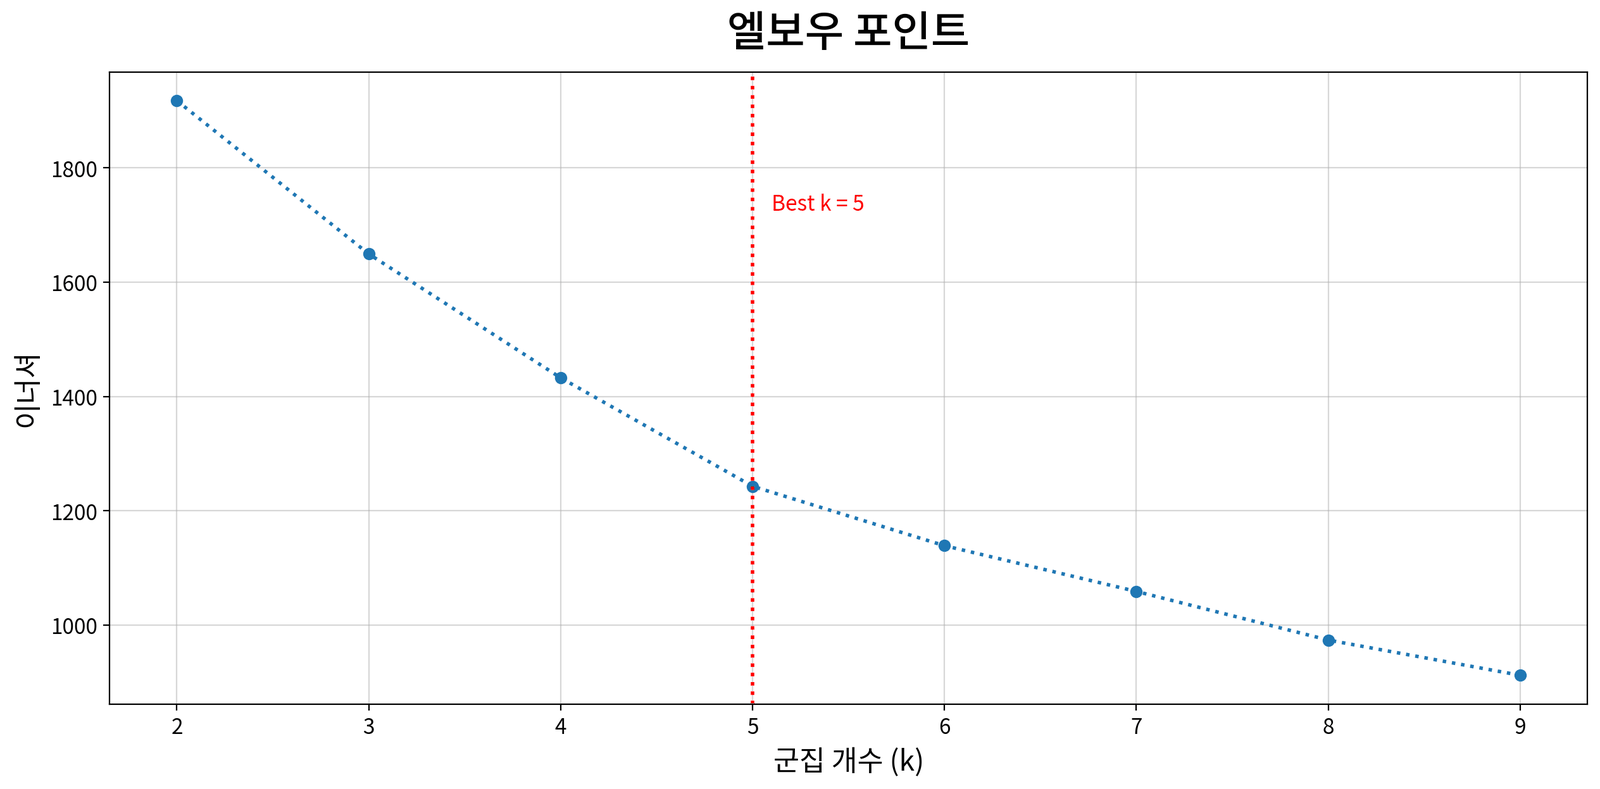

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

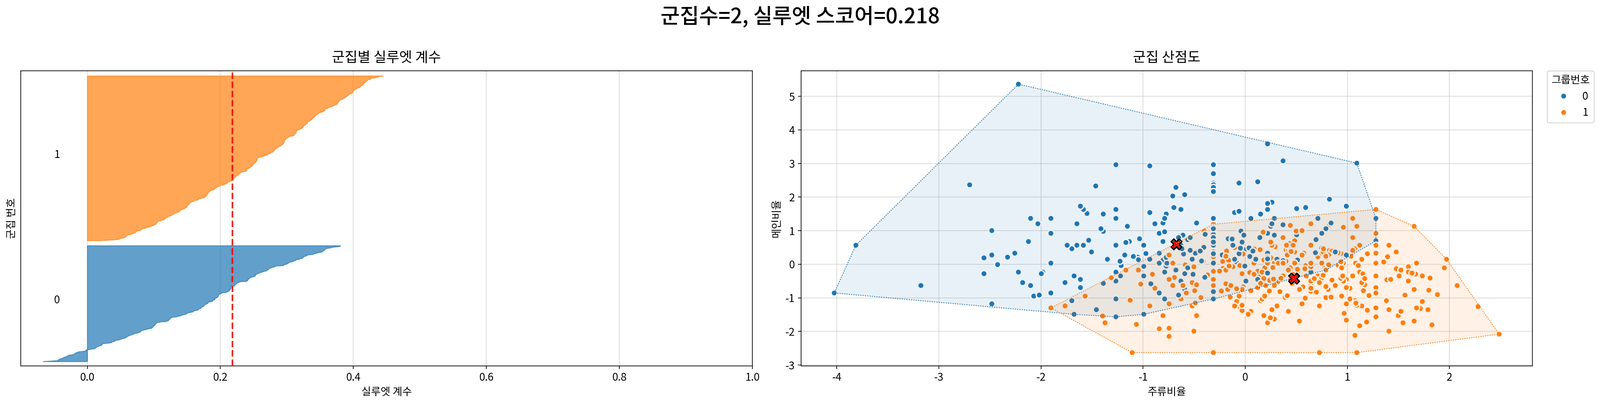

[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5 : 균형지수 0.0073 (스코어 0.2223, 두께비 7.1613)
  · k = 2 : 균형지수 0.0974 (스코어 0.2183, 두께비 1.4206)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,1917.7173,NaN,0.2183,133.1467,1.4206,0.6337,0.0974
1,3,1649.3493,268.3680,0.1964,119.8209,1.8013,0.8219,0.0896
2,4,1432.5077,216.8416,0.2142,130.6438,8.1250,0.2112,0.0056
3,5,1242.7067,189.8009,0.2223,135.6231,7.1613,0.2360,0.0073
4,6,1138.7026,104.0041,0.1904,116.1473,4.7097,0.3178,0.0128
5,7,1058.6067,80.0960,0.1889,115.2472,4.9231,0.3214,0.0123
6,8,973.4697,85.1370,0.1958,119.4348,29.5000,0.0582,0.0004
7,9,911.8371,61.6325,0.1904,116.1654,25.5000,0.0574,0.0004


산출된 추천 최적 k: 2


In [48]:
# =========================================================================
# [보조 분석 - 1단계] 최적 군집 수(k) 탐색 
# =========================================================================
# 묶음 B 전용 내부 운영 행태 변수 4종 투입 (5.4에서 정의한 feature_cols_cluster, 영수증 3건 이상인 날)

# my_cluster 모듈을 활용한 최적 k 탐색 (StandardScaler 자동 적용)
best_k_val, k_metrics_df = my_cluster.best_k(
    data=df_cluster_final,
    klist=range(2, 10),
    columns=feature_cols_cluster,
    scaling='standard'
)

# k별 엘보우 및 실루엣 평가 지표 확인
display(k_metrics_df)
print(f"산출된 추천 최적 k: {best_k_val}")

### 8.1 군집 수($k$) 결정

`my_cluster.best_k`로 $k=2$부터 $k=9$까지의 **이너셔(군집 안의 흩어짐)**와 **실루엣 지표(뭉침·분리·크기 균형)**를 비교했습니다. 군집 대상은 영수증 3건 이상인 610일입니다.

| $k$ | 이너셔 | 감소량 | 실루엣 스코어 | 두께비 | 최소상대면적 | 균형지수 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 2 | 1917.72 | - | 0.2183 | 1.42 | 0.634 | **0.0974** |
| 3 | 1649.35 | 268.37 | 0.1964 | 1.80 | 0.822 | 0.0896 |
| 4 | 1432.51 | 216.84 | 0.2142 | 8.13 | 0.211 | 0.0056 |
| **5** | **1242.71** | **189.80** | **0.2223** | 7.16 | 0.236 | 0.0073 |
| 6 | 1138.70 | 104.00 | 0.1904 | 4.71 | 0.318 | 0.0128 |
| 7 | 1058.61 | 80.10 | 0.1889 | 4.92 | 0.321 | 0.0123 |
| 8 | 973.47 | 85.14 | 0.1958 | 29.50 | 0.058 | 0.0004 |
| 9 | 911.84 | 61.63 | 0.1904 | 25.50 | 0.057 | 0.0004 |

* **두 지표가 다른 $k$를 가리킵니다.**
  * **엘보우**: $k=5$에서 감소량이 189.80이었다가 $k=6$에서 104.00으로 크게 줄어 $k=5$가 꺾이는 지점입니다.
  * **실루엣 균형지수**: $k=2$가 가장 높고(0.0974), 모듈은 $k=2$를 추천했습니다. $k=5$는 실루엣 스코어 자체는 0.2223으로 8개 중 가장 높지만, 군집 크기가 고르지 않아(두께비 7.16, 최소상대면적 0.236) 균형지수가 낮게 나왔습니다.
* **최종 결정: $k=5$**
  * $k=2$는 날들을 크게 두 묶음으로만 나눠, "어떤 방식으로 장사한 날인가"를 구분하려는 보조 분석의 목적에 비해 해석이 거칠어집니다.
  * $k=5$는 엘보우 지점이면서 실루엣 스코어가 가장 높습니다. 균형지수가 낮은 이유는 크기가 작은 군집이 하나 있기 때문인데, 이 군집이 실무적으로 의미 있는 날인지 8.2에서 확인하고 크기와 안정성은 8.2.2에서 따로 점검합니다.
  * 모듈도 "지표는 후보를 좁혀 줄 뿐이므로 목적과 도메인 지식으로 한 번 더 확인할 것"이라고 안내하므로, 해석 가능성을 근거로 $k=5$를 택합니다.
* **군집 구조의 강도**: 실루엣 스코어가 0.2 안팎이라 군집 간 경계는 중간 정도로 나뉜 구조입니다. 경계가 뚜렷하다고 보기는 어렵습니다.

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
주류비율                 0.11 ~ 0.79          -4.02 ~ 2.49
메인비율                 0.00 ~ 0.50          -2.63 ~ 5.36
피크집중도                0.00 ~ 1.00          -1.40 ~ 3.30
팀당_주문수량             2.25 ~ 25.67         -1.60 ~ 11.12


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


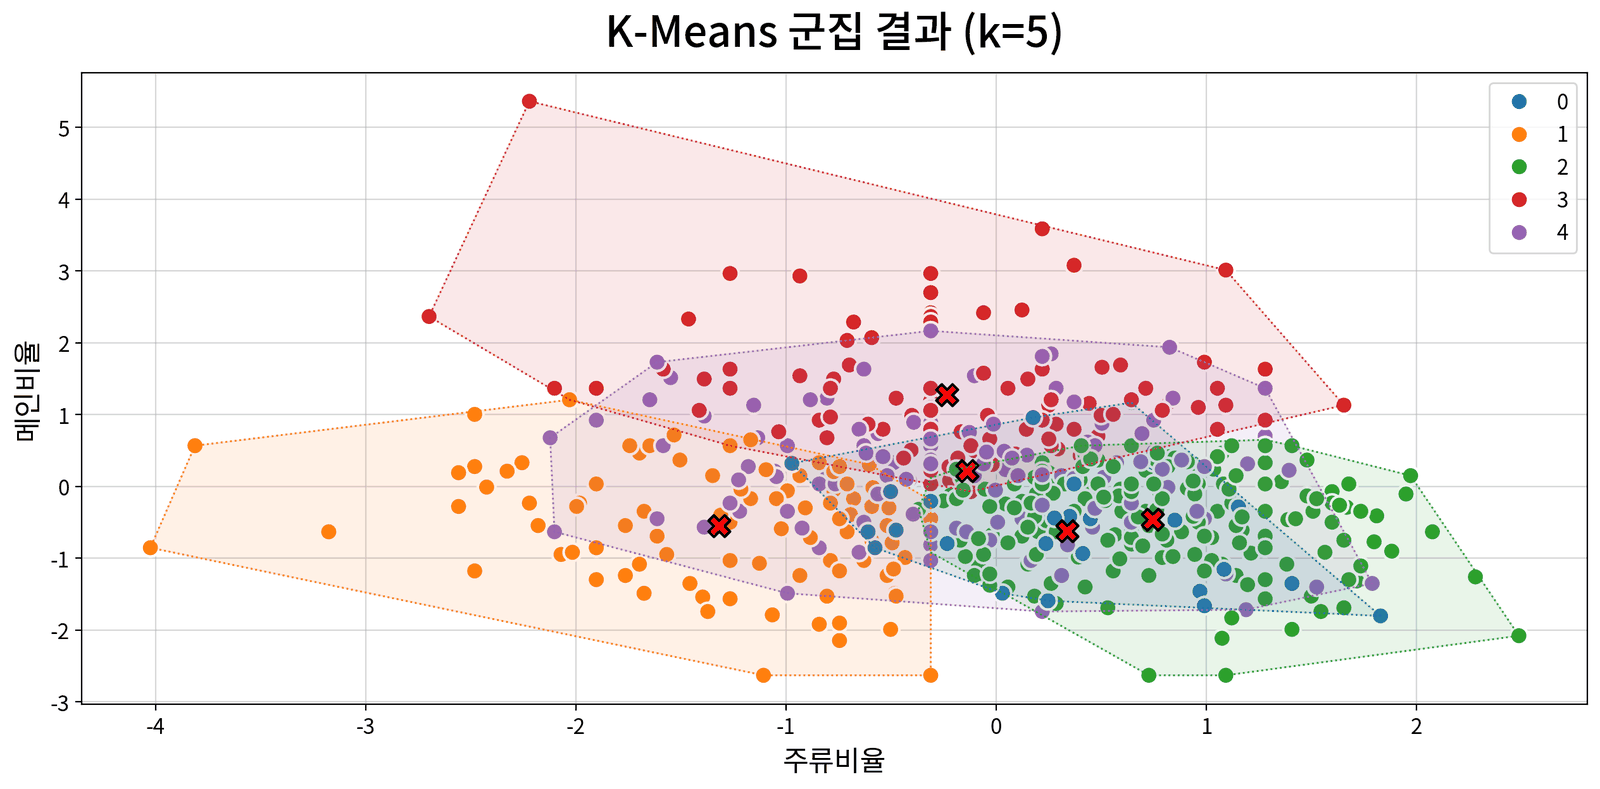

K-Means 군집 모델 저장 완료: sales_prediction_proj\kmeans_model.pkl


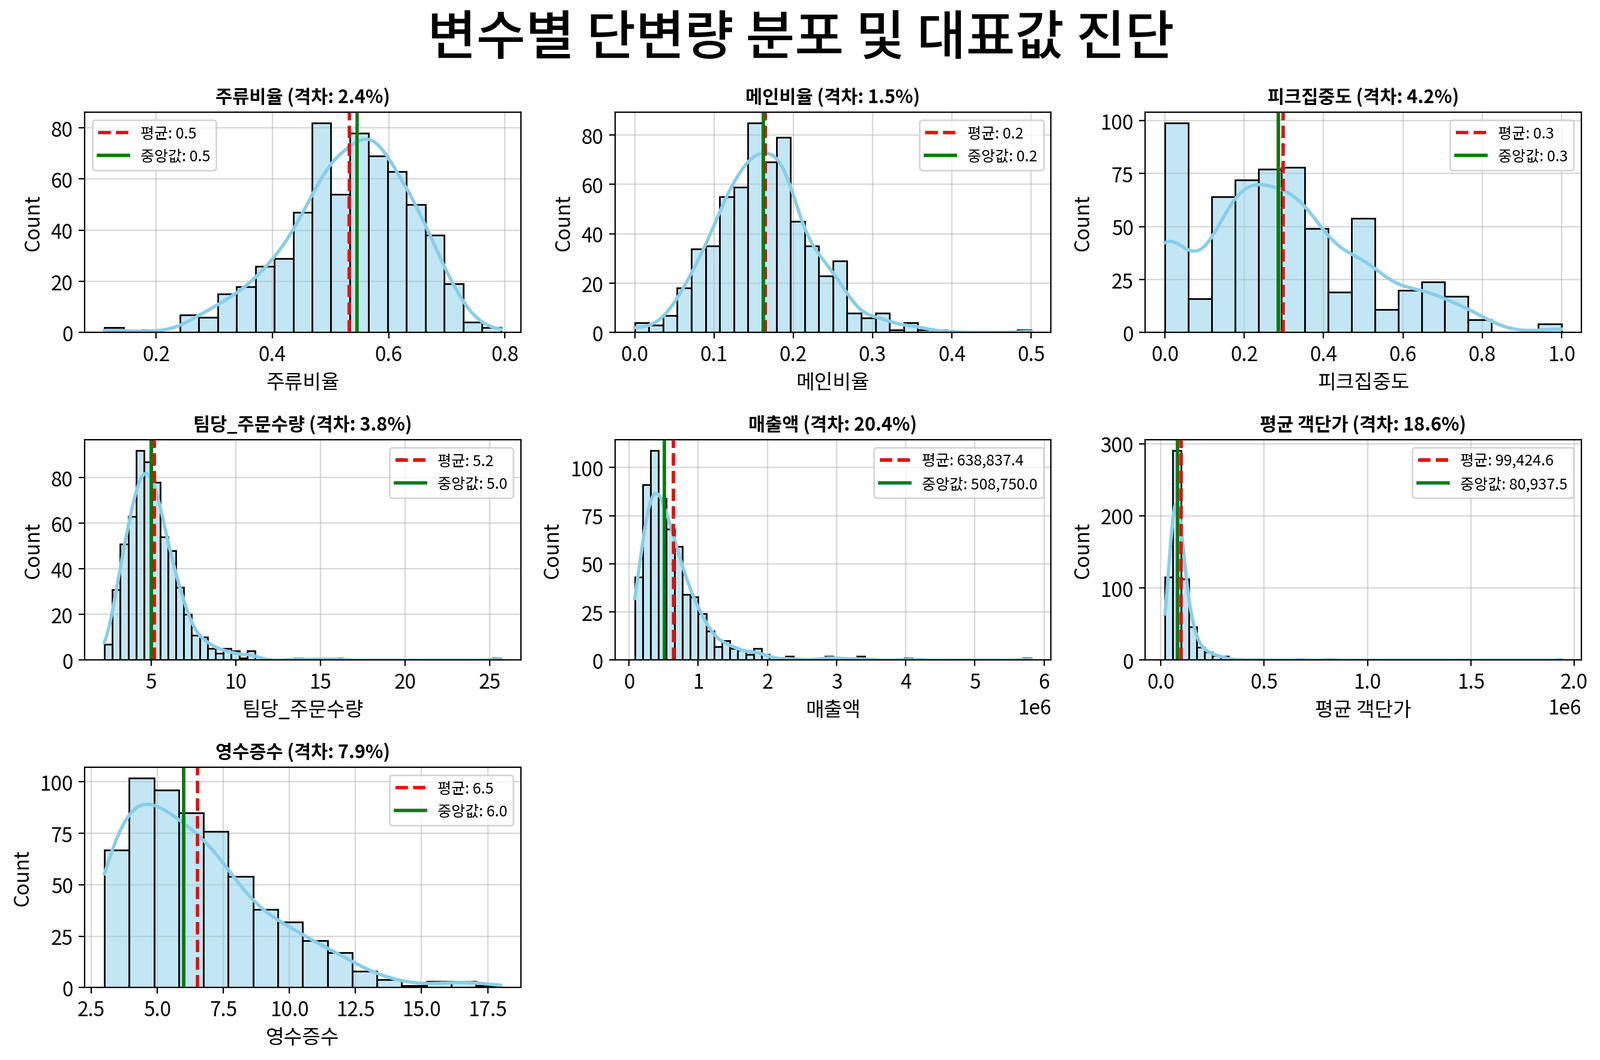

[변수별 분포 진단 및 대표값 선택 기준표]


,변수명,평균,중앙값,차이율(%),왜도,p-value,정규성 판정,최종 대표값
0,주류비율,0.53,0.55,2.41,-0.53,0.0,대략적 정규,평균
1,메인비율,0.16,0.16,1.47,0.57,0.0,대략적 정규,평균
2,피크집중도,0.30,0.29,4.22,0.54,0.0,대략적 정규,평균
3,팀당_주문수량,5.20,5.00,3.84,3.49,0.0,대략적 정규,평균
4,매출액,638837.38,508750.00,20.36,3.65,0.0,비정규/왜곡,중앙값
5,평균 객단가,99424.56,80937.50,18.59,12.31,0.0,비정규/왜곡,중앙값
6,영수증수,6.51,6.00,7.90,1.05,0.0,대략적 정규,평균



[영업일 유형별 맞춤 대표값(평균/중앙값 선택) 종합 요약표]


,주류비율 (평균),메인비율 (평균),피크집중도 (평균),팀당_주문수량 (평균),매출액 (중앙값),평균 객단가 (중앙값),영수증수 (평균)
영업일_유형,,,,,,,
0,0.57,0.13,0.31,10.33,1358500.0,229688.0,5.87
1,0.39,0.13,0.23,4.86,406000.0,71944.5,6.22
2,0.61,0.14,0.20,5.22,578000.0,88819.5,6.92
3,0.51,0.24,0.18,4.23,437750.0,67728.0,6.76
4,0.52,0.18,0.57,5.05,448000.0,80167.0,6.04


In [49]:
# =========================================================================
# [보조 분석 - 2단계] K-Means (k=5) 실행 및 변수별 대표값(평균/중앙값) 선택 집계
# =========================================================================
# 1. 군집 투입 변수(4개, 8.1) + 실적 해석 변수(3개, 5.4) 결합
all_target_cols = feature_cols_cluster + feature_cols_perf

# 2. k=5 K-Means 군집 분석 실행 (StandardScaler 자동 적용, my_cluster 모듈 사용)
estimator, df_scaled, center_scaled_df = my_cluster.kmeans(
    data=df_cluster_final,
    k=5,
    columns=feature_cols_cluster,
    scaling="standard",
    cluster_name="영업일_유형",
    plot=True,
)

# 3. K-Means 군집 모델 저장 (회귀 모델과 같은 프로젝트 폴더, my_ml.save_model 은 폴더를 자동 생성)
kmeans_save_path = Path(PROJECT_NAME) / "kmeans_model.pkl"
my_ml.save_model(estimator, kmeans_save_path)
print(f"K-Means 군집 모델 저장 완료: {kmeans_save_path}")

# 4. 군집 테이블(df_cluster_final)과 마스터(df_final)에 군집 번호 할당
#    (번호의 페르소나 고정은 결과 해석 후 8.2.1에서 수행)
df_cluster_final["영업일_유형"] = df_scaled["영업일_유형"]
df_final["영업일_유형"] = df_scaled["영업일_유형"]

# -------------------------------------------------------------------------
# 5. 자체 모듈(my_qtcheck, my_stats) 기반 진단 및 대표값 판정
# -------------------------------------------------------------------------
# 5-1) 수치형 요약 통계량 추출 (my_qtcheck)
num_summary = my_qtcheck.numerical_summary(
    df_cluster_final, columns=all_target_cols
)

# 5-2) 정규성 검정 (my_stats)
norm_tests = my_stats.test_assumptions(
    df_cluster_final, columns=all_target_cols
)

diag_list = []

# 5-3) my_plot.init 캔버스 생성 (3x3 서브플롯)
fig, axes = my_plot.init(
    width=450, height=300, rows=3, cols=3, title="변수별 단변량 분포 및 대표값 진단"
)

for i, col in enumerate(all_target_cols):
    mean_val = num_summary.loc[col, "mean"]
    median_val = num_summary.loc[col, "50%"]
    diff_pct = (
        abs(mean_val - median_val) / mean_val * 100 if mean_val != 0 else 0
    )
    skew_val = num_summary.loc[col, "skew"]
    p_val = norm_tests.loc[col, "p-value"]

    # 대표값 판정: 1단계 p-value >= 0.05 (정규 → 평균) / 2단계 차이율 <= 10% (대략적 정규 → 평균) / 3단계 그 외 (중앙값)
    if p_val >= 0.05:
        chosen_metric = "평균"
        norm_label = "정규"
    elif diff_pct <= 10.0:
        chosen_metric = "평균"
        norm_label = "대략적 정규"
    else:
        chosen_metric = "중앙값"
        norm_label = "비정규/왜곡"

    diag_list.append({
        "변수명": col,
        "평균": round(mean_val, 2),
        "중앙값": round(median_val, 2),
        "차이율(%)": round(diff_pct, 2),
        "왜도": round(skew_val, 2),
        "p-value": round(p_val, 4),
        "정규성 판정": norm_label,
        "최종 대표값": chosen_metric,
    })

    # 5-4) my_plot.histplot 시각화 및 평균/중앙값 가이드 표시
    ax = axes[i]
    my_plot.histplot(
        data=df_cluster_final, x=col, kde=True, color="skyblue", ax=ax
    )
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"평균: {mean_val:,.1f}")
    ax.axvline(median_val, color="green", linestyle="-", linewidth=2, label=f"중앙값: {median_val:,.1f}")
    ax.set_title(f"{col} (격차: {diff_pct:.1f}%)", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

# 미사용 서브플롯 삭제
for j in range(len(all_target_cols), len(axes)):
    fig.delaxes(axes[j])

my_plot.show()

# 진단 결과 표 출력
diag_df = pd.DataFrame(diag_list)
print("[변수별 분포 진단 및 대표값 선택 기준표]")
display(diag_df)

# -------------------------------------------------------------------------
# 6. 선택된 대표값(평균/중앙값) 기준 영업일 유형별 종합 요약표 생성
#    (8.2.1에서 번호를 고정한 뒤에도 같은 기준으로 다시 만들 수 있도록 함수로 둔다)
# -------------------------------------------------------------------------
def rep_summary(data, diag_list, group_col="영업일_유형"):
    """변수별로 선택한 대표값(평균 또는 중앙값)으로 유형별 요약표를 만든다."""
    table = {}
    for row in diag_list:
        col, metric = row["변수명"], row["최종 대표값"]
        if "평균" in metric:
            table[f"{col} (평균)"] = data.groupby(group_col)[col].mean()
        else:
            table[f"{col} (중앙값)"] = data.groupby(group_col)[col].median()
    return DataFrame(table)


summary_rep = rep_summary(df_cluster_final, diag_list)

print("\n[영업일 유형별 맞춤 대표값(평균/중앙값 선택) 종합 요약표]")
display(summary_rep.round(2))

### 8.2 변수별 대표값 산출과 5개 영업일 유형 정의

K-Means($k=5$)로 나눈 군집별 대표값을 구해 유형을 정의합니다. 대상은 영수증 3건 이상인 610일입니다.

* **대표값 선택**: 정규성 검정(p < 0.05)에서 모든 변수가 정규분포가 아니었지만, 평균과 중앙값의 차이율이 10% 이하인 변수는 평균, 그보다 큰 변수는 중앙값을 대표값으로 썼습니다.
  * **평균**: `주류비율`(차이율 2.41%), `메인비율`(1.47%), `피크집중도`(4.22%), `팀당_주문수량`(3.84%), `영수증수`(7.90%)
  * **중앙값**: `매출액`(20.36%, 왜도 3.65), `평균 객단가`(18.59%, 왜도 12.31)
* **군집 입력 확인**: 5.4에서 고른 `팀당_주문수량`(영수증 1건당 주문한 메뉴 수량)은 영수증수와의 상관이 0.036으로, 방문 규모의 영향이 빠진 변수입니다.

---

#### 1. 군집별 대표값 요약 (8.2 출력의 군집 번호 기준)

| 군집 번호 | 주류비율 | 메인비율 | 피크집중도 | 팀당 주문수량 | 매출액 (중앙값) | 객단가 (중앙값) | 영수증수 | 유형 이름 |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| 0 | 0.57 | 0.13 | 0.31 | **10.33** | **1,358,500원** | **229,688원** | 5.87 | **대량 주문형** |
| 2 | **0.61** | 0.14 | 0.20 | 5.22 | 578,000원 | 88,820원 | **6.92** | **술자리 중심형** |
| 4 | 0.52 | 0.18 | **0.57** | 5.05 | 448,000원 | 80,167원 | 6.04 | **원웨이브 러시형** |
| 3 | 0.51 | **0.24** | 0.18 | 4.23 | 437,750원 | 67,728원 | 6.76 | **식사 중심형** |
| 1 | **0.39** | 0.13 | 0.23 | 4.86 | 406,000원 | 71,945원 | 6.22 | **라이트 방문형** |
| (전체) | 0.53 | 0.16 | 0.30 | 5.20 | 508,750원 | 80,938원 | 6.51 | |

---

#### 2. 유형별 특징

> ※ 아래 **데이터 특징**은 위 표의 수치로 확인된 내용입니다. **운영 포인트**는 데이터에 없는 매장 운영 정보(1인 운영, 테이블 구성, 원가 구조 등)를 전제로 한 **가설**이므로, 실제 운영 기록으로 검증이 필요합니다.

* **대량 주문형 (군집 0)**
  * **데이터 특징**: 팀당 주문수량이 10.33개로 전체 평균(5.20개)의 약 2배이고, 객단가(약 23.0만 원)와 매출(약 135.9만 원)이 전체 중앙값의 약 2.7~2.8배입니다. 반면 영수증수는 5.87건으로 평소 수준입니다. 손님 팀이 많이 온 날이 아니라 **한 팀이 많이 시킨 날**(단체 모임·회식 등)입니다.
  * **운영 포인트 (가설)**: 단체 예약 여부를 미리 확인하면 대비할 수 있는 날입니다. 대량 주문에 맞춘 재료 준비와 조리 순서 정리가 중요합니다.

* **술자리 중심형 (군집 2)**
  * **데이터 특징**: 주류비율 0.61로 가장 높고 영수증수 6.92건으로 손님 팀도 가장 많습니다. 매출(57.8만 원)과 객단가(8.9만 원)는 대량 주문형 다음으로 높습니다.
  * **운영 포인트 (가설)**: 주류는 조리 부담이 적어 1인 운영에 유리한 유형입니다. 주류 재고와 간단한 안주를 중심으로 준비합니다.

* **원웨이브 러시형 (군집 4)**
  * **데이터 특징**: 피크집중도 0.57로, 영수증의 절반 이상이 19~21시에 첫 주문을 넣은 날입니다. 다른 지표는 전체 평균과 비슷합니다.
  * **운영 포인트 (가설)**: 짧은 시간에 주문이 몰리므로, 피크 전 밑작업과 빠르게 낼 수 있는 메뉴 추천이 병목을 줄입니다.

* **식사 중심형 (군집 3)**
  * **데이터 특징**: 메인비율 0.24로 가장 높고 팀당 주문수량(4.23개)과 객단가(약 6.8만 원)는 가장 낮습니다. 식사 위주로 적게 시키는 손님이 많았습니다.
  * **운영 포인트 (가설)**: 메인 요리에 주류를 묶은 세트로 객단가를 높일 여지가 있습니다.

* **라이트 방문형 (군집 1)**
  * **데이터 특징**: 주류비율 0.39로 가장 낮고 매출(40.6만 원)도 가장 낮습니다. 술보다 가볍게 먹고 가는 손님이 많은 날입니다.
  * **운영 포인트 (가설)**: 잔술·하이볼·저도주처럼 부담이 적은 주류 메뉴로 첫 주문을 유도할 여지가 있습니다.

* **유형 구분의 성격**: 군집 입력에서 방문 규모(손님 팀 수)를 뺐기 때문에, 영수증수는 다섯 유형 모두 5.9~6.9건으로 비슷합니다. 유형은 손님이 많고 적음보다 주문 내용(술·식사·주문량)과 주문 시간대에 따라 나뉘었습니다. 매출 차이는 주로 대량 주문형과 나머지 유형 사이에서 생깁니다.

> ※ 군집 번호는 재실행 시 바뀔 수 있으므로, 다음 8.2.1에서 이 해석을 근거로 유형 이름을 붙이고 매출 중앙값 순서의 고정 번호(T0~T4)로 바꿉니다.

#### 8.2.1 군집 번호 고정 (재현성 확보)

K-Means의 군집 번호(0~4)는 초기값이나 데이터가 바뀌면 재실행 시 다른 번호로 뒤바뀔 수 있습니다. 번호가 바뀌면 8.2의 해석과 8.3의 검정 결과가 서로 어긋나므로, 군집별 **매출 중앙값이 높은 순서**로 고정 번호(T0~T4)를 붙이고 8.2에서 정한 유형 이름을 연결합니다. 매출액은 군집 입력이 아니므로 번호를 정하는 기준으로만 씁니다.

| 고정 번호 | 유형 이름 | 8.2 출력의 군집 번호 | 매출 중앙값 |
| :---: | :--- | :---: | :---: |
| T0 | 대량 주문형 | 0 | 1,358,500원 |
| T1 | 술자리 중심형 | 2 | 578,000원 |
| T2 | 원웨이브 러시형 | 4 | 448,000원 |
| T3 | 식사 중심형 | 3 | 437,750원 |
| T4 | 라이트 방문형 | 1 | 406,000원 |

In [50]:
# =========================================================================
# [보조 분석 - 2-1단계] 군집 번호 → 고정 유형 번호 매핑
# =========================================================================
# K-Means 군집 번호는 재실행 시 뒤바뀔 수 있으므로, 군집별 매출 중앙값이 높은 순서로 고정 번호(T0~T4)를 붙인다.
# (매출액은 군집 입력이 아니므로 번호 기준으로만 쓰며, 유형의 성격은 8.2의 해석으로 정의한다.)
raw_label = df_cluster_final["영업일_유형"].copy()
raw_profile = df_cluster_final[feature_cols_cluster + ["매출액"]].groupby(raw_label).agg(
    {**{c: "mean" for c in feature_cols_cluster}, "매출액": "median"}
)
order = raw_profile["매출액"].sort_values(ascending=False).index
raw2type = {raw: k for k, raw in enumerate(order)}

# 고정 번호별 유형 이름 (8.2 해석 결과로 정의, 매출 중앙값 높은 순)
PERSONA_NAME = {
    0: "대량 주문형",
    1: "술자리 중심형",
    2: "원웨이브 러시형",
    3: "식사 중심형",
    4: "라이트 방문형",
}
PERSONA_ID = {name: k for k, name in PERSONA_NAME.items()}
persona_by_type = PERSONA_NAME

mapping_df = raw_profile.round(3).assign(
    고정번호=[raw2type[i] for i in raw_profile.index],
    유형=[PERSONA_NAME[raw2type[i]] for i in raw_profile.index],
)
mapping_df.index.name = "현재 군집번호"
display(Markdown("##### 군집 번호 → 고정 유형 번호 매핑표 (매출 중앙값 높은 순)"))
display(mapping_df.sort_values("고정번호"))

# 고정 번호와 유형 이름을 군집 테이블(df_cluster_final)과 마스터(df_final)에 반영
# (영수증 2건 이하로 군집에서 제외한 날은 df_final 에서 빈칸 = 미분류로 남는다)
fixed_type = raw_label.map(raw2type)
for target in (df_cluster_final, df_final):
    target["영업일_유형"] = fixed_type
    target["페르소나"] = fixed_type.map(persona_by_type)

# 매핑표 저장 (재사용 시 동일한 번호 복원용)
my_ml.save_model(raw2type, Path(PROJECT_NAME) / "kmeans_label_map.pkl")

# 고정 번호 기준 대표값 요약표 재출력 (8.2 표와 동일한 기준: 평균/중앙값 선택)
summary_fixed = rep_summary(df_cluster_final, diag_list)   # 8.2 셀에서 정의한 함수 재사용
summary_fixed.insert(0, "유형", summary_fixed.index.map(persona_by_type))
display(Markdown("##### 고정 번호 기준 영업일 유형별 대표값 요약표"))
display(summary_fixed.round(2))

##### 군집 번호 → 고정 유형 번호 매핑표 (매출 중앙값 높은 순)

,주류비율,메인비율,피크집중도,팀당_주문수량,매출액,고정번호,유형
현재 군집번호,,,,,,,
0,0.568,0.126,0.308,10.334,1358500.0,0,대량 주문형
2,0.611,0.136,0.204,5.224,578000.0,1,술자리 중심형
4,0.518,0.178,0.575,5.050,448000.0,2,원웨이브 러시형
3,0.508,0.244,0.179,4.226,437750.0,3,식사 중심형
1,0.395,0.130,0.232,4.859,406000.0,4,라이트 방문형


##### 고정 번호 기준 영업일 유형별 대표값 요약표

,유형,주류비율 (평균),메인비율 (평균),피크집중도 (평균),팀당_주문수량 (평균),매출액 (중앙값),평균 객단가 (중앙값),영수증수 (평균)
영업일_유형,,,,,,,,
0,대량 주문형,0.57,0.13,0.31,10.33,1358500.0,229688.0,5.87
1,술자리 중심형,0.61,0.14,0.20,5.22,578000.0,88819.5,6.92
2,원웨이브 러시형,0.52,0.18,0.57,5.05,448000.0,80167.0,6.04
3,식사 중심형,0.51,0.24,0.18,4.23,437750.0,67728.0,6.76
4,라이트 방문형,0.39,0.13,0.23,4.86,406000.0,71944.5,6.22


#### 8.2.2 군집 신뢰성 점검

8.1의 실루엣 스코어(0.22)는 군집 간 경계가 뚜렷하지 않은 수준입니다. 이 상태에서 5개 페르소나를 주장하려면 아래 네 가지를 확인해야 합니다.

| 점검 | 방법 | 판단 기준 |
| :--- | :--- | :--- |
| 유형별 크기 | 유형별 일수와 비율 | 극단적으로 작은 유형(예: 5% 미만)은 해석 신뢰도가 낮음 |
| 안정성 | 시드 변경 10회, 80% 부분표본 30회 재군집 후 원래 분할과의 조정 랜드 지수(ARI) | ARI 0.8 이상이면 안정, 0.6 미만이면 유형 경계가 불안정 |
| 비율 극단값 | 유형별 영수증수 중앙값, 피크집중도가 0 또는 1인 날의 비율 | 영수증 2건 이하인 날을 뺀 뒤에도 극단값이 특정 유형에 몰리는지 확인 |
| 규모 대리 여부 | 팀당 메뉴 지표와 `영수증수`·`매출액`의 상관 | 상관이 약하면 군집 입력에서 방문 규모의 영향이 빠졌다는 근거 |

In [51]:
# =========================================================================
# [보조 분석 - 2-2단계] 군집 신뢰성 점검
# =========================================================================
from sklearn.metrics import adjusted_rand_score

base_labels = df_cluster_final["영업일_유형"].values

# -------------------------------------------------------------------------
# 1. 유형별 크기
# -------------------------------------------------------------------------
size_df = (
    df_cluster_final.groupby("영업일_유형")
    .agg(유형=("페르소나", "first"), 일수=("페르소나", "size"))
    .assign(비율=lambda d: (d["일수"] / d["일수"].sum()).round(3))
)
display(Markdown("##### 유형별 크기"))
display(size_df)

# -------------------------------------------------------------------------
# 2. 안정성 점검 (조정 랜드 지수 ARI: 1 = 완전히 같은 분할, 0 = 우연 수준)
# -------------------------------------------------------------------------
# (1) 초기값(시드)만 바꿔 재군집
seed_ari = []
for seed in [0, 1, 7, 42, 100, 2024, 777, 1234, 5678, 9999]:
    _, d_seed, _ = my_cluster.kmeans(
        data=df_cluster_final, k=5, columns=feature_cols_cluster, scaling="standard",
        cluster_name="_seed", random_state=seed, verbose=False, plot=False,
    )
    seed_ari.append(adjusted_rand_score(base_labels, d_seed["_seed"]))

# (2) 표본 80%를 무작위 추출해 재군집한 뒤 전체 데이터에 적용 (30회)
scaled_all = my_prep.scaling(df_cluster_final[feature_cols_cluster], method="standard", verbose=False)
rng = np.random.default_rng(RANDOM_STATE)
boot_ari = []
for _ in range(30):
    idx = rng.choice(len(scaled_all), size=int(len(scaled_all) * 0.8), replace=False)
    est_b, _, _ = my_cluster.kmeans(
        data=scaled_all.iloc[idx], k=5, columns=feature_cols_cluster, scaling=None,
        cluster_name="_boot", verbose=False, plot=False,
    )
    boot_ari.append(adjusted_rand_score(base_labels, est_b.predict(scaled_all[feature_cols_cluster])))

stability_df = DataFrame({
    "점검 방식": ["시드 변경 (10회)", "80% 부분표본 (30회)"],
    "ARI 평균": [np.mean(seed_ari), np.mean(boot_ari)],
    "ARI 최소": [np.min(seed_ari), np.min(boot_ari)],
    "ARI 최대": [np.max(seed_ari), np.max(boot_ari)],
}).round(3)
display(Markdown("##### 군집 안정성 점검"))
display(stability_df)

# -------------------------------------------------------------------------
# 3. 비율 변수의 극단값 점검 (군집 대상은 영수증 3건 이상인 날)
# -------------------------------------------------------------------------
extreme_df = (
    df_cluster_final.assign(피크집중도_극단=df_cluster_final["피크집중도"].isin([0, 1]))
    .groupby("영업일_유형")
    .agg(
        유형=("페르소나", "first"),
        영수증수_중앙값=("영수증수", "median"),
        피크집중도_0또는1_비율=("피크집중도_극단", "mean"),
    )
    .round(3)
)
display(Markdown("##### 유형별 영수증수와 피크집중도 극단값 비율"))
display(extreme_df)

# -------------------------------------------------------------------------
# 4. 군집 입력 팀당 메뉴 지표의 방문 규모 대리 여부 (my_stats.multi_correlation)
# -------------------------------------------------------------------------
scale_corr = my_stats.multi_correlation(
    df_cluster_final, columns=[team_col, "영수증수", "매출액"], alpha=0.05, plot=False
)
display(Markdown(f"##### {team_col}와 방문 규모 지표의 상관"))
display(scale_corr[["method", "coef", "p-value", "strength"]])

##### 유형별 크기

,유형,일수,비율
영업일_유형,,,
0,대량 주문형,31,0.051
1,술자리 중심형,222,0.364
2,원웨이브 러시형,147,0.241
3,식사 중심형,112,0.184
4,라이트 방문형,98,0.161


C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\yeold\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

...

##### 유형별 영수증수와 피크집중도 극단값 비율

,유형,영수증수_중앙값,피크집중도_0또는1_비율
영업일_유형,,,
0,대량 주문형,6.0,0.065
1,술자리 중심형,6.5,0.198
2,원웨이브 러시형,6.0,0.027
3,식사 중심형,6.0,0.268
4,라이트 방문형,6.0,0.235


,팀당_주문수량,영수증수,매출액
팀당_주문수량,1.000,0.036,0.596
영수증수,0.036,1.000,0.709
매출액,0.596,0.709,1.000


##### 팀당_주문수량와 방문 규모 지표의 상관

method    coef  p-value  strength
x       y                                        
팀당_주문수량 영수증수  Spearman  0.0358   0.3768      Weak
        매출액   Spearman  0.5964   0.0000  Moderate
영수증수    매출액   Spearman  0.7093   0.0000    Strong

##### 8.2.2 결과 해석

| 점검 | 결과 | 판정 |
| :--- | :--- | :--- |
| 유형별 크기 | 술자리 222일(36.4%), 원웨이브 147일(24.1%), 식사 112일(18.4%), 라이트 98일(16.1%), 대량 주문 31일(5.1%) | 5% 미만 유형은 없으나 **대량 주문형이 경계선** |
| 안정성 (시드 변경) | ARI 평균 0.943 (최소 0.855) | 안정 |
| 안정성 (80% 부분표본) | ARI 평균 0.826 (최소 0.607) | 평균은 안정 기준(0.8) 이상, **일부 표본에서는 경계가 흔들림** |
| 비율 극단값 | 피크집중도가 0 또는 1인 날: 식사 26.8%, 라이트 23.5%, 술자리 19.8%, 대량 주문 6.5%, 원웨이브 2.7% | 식사·라이트형에 남아 있음 |
| 규모 대리 여부 | `팀당_주문수량`과 영수증수 ρ = 0.036 (p = 0.377), 매출액 ρ = 0.596 | **방문 규모와 무관** |

* 군집 입력인 `팀당_주문수량`은 영수증수와 상관이 거의 없어(ρ = 0.036) **방문 규모의 영향이 빠졌습니다.** 유형이 손님이 많이 온 날을 다시 나누는 문제는 이로써 해결되었습니다. 매출액과의 상관(ρ = 0.596)은 한 팀이 많이 시키면 매출이 오르는 당연한 관계입니다.
* **유형 구분은 대체로 재현됩니다.** 초기값을 바꾸면 거의 같은 분할이 나오고(ARI 0.943), 표본의 80%만 써도 평균적으로 비슷한 분할이 나옵니다(ARI 0.826). 그러나 부분표본에서는 최소 0.607까지 내려가기도 해서 유형 사이 경계에 있는 날들은 표본에 따라 다른 유형으로 바뀔 수 있습니다. 8.1의 실루엣 스코어(0.22)에서 보았듯 경계 자체가 뚜렷하지 않은 탓입니다.
* 대량 주문형은 31일(5.1%)로 가장 작아 8.1에서 균형지수를 낮춘 원인이었습니다. 그래도 매출·객단가가 다른 유형의 2배 이상인 날들이라 **작지만 의미 있는 유형**으로 따로 구분할 가치가 있습니다. 표본이 적은 만큼 이 유형에 대한 통계적 결론은 조심스럽게 봅니다.
* **비율 극단값은 일부 남아 있습니다.** 영수증 2건 이하인 날을 뺐는데도 식사 중심형과 라이트 방문형은 피크집중도가 0 또는 1인 날이 약 4분의 1입니다. 이 두 유형의 피크 관련 특징은 손님 수가 적은 날의 비율 변동이 일부 섞인 결과일 수 있습니다.

### 8.3 달력 변수별 영업일 유형(페르소나) 교차분석 및 카이제곱 독립성 검정

8.2에서 나눈 5개 영업일 유형(T0~T4)이 어떤 날에 주로 나타나는지 알아보려고 군집에 쓰지 않은 달력 변수 4개(`요일`, `공휴일여부`, `공휴일전날여부`, `연휴여부`)와 영업일 유형의 관계를 **카이제곱 독립성 검정**으로 확인합니다.

군집 입력에 사용한 4개 운영 행태 변수(`주류비율`, `메인비율`, `피크집중도`, `팀당_주문수량`)로 유형 간 차이를 다시 검정하면 순환 논리가 되어 새로운 정보를 얻을 수 없습니다. (반면 `매출액`·`평균 객단가`·`영수증수`는 군집 입력이 아니므로 유형 간 차이 검정이 유효합니다.) 이 절은 어떤 날에 어떤 유형이 나타나는지만 확인합니다. 그 결과가 9장 **운영 캘린더**의 근거가 됩니다. 

---

#### 분석 절차

| 단계 | 내용 | 목적 |
| :---: | :--- | :--- |
| **① 교차 빈도 점검** | 유형 × 각 달력 변수의 교차표 확인 | 공휴일·연휴 등 연중 발생일이 적은 변수의 희소 셀 사전 파악 |
| **② 카이제곱 독립성 검정** | 4개 변수 일괄 검정 및 효과크기(Cramér's V) 산출 | 유형과 달력 변수 간 연관성 유무 및 강도 판정 |
| **③ 다중비교 보정** | Holm 방식 p-value 보정 | 동일 군집 변수로 4회 검정함에 따른 1종 오류 누적 방지 |
| **④ 가정 위반 보완** | 기대빈도 가정(5 이상 셀 80% 이상, 최소 1 이상) 위반 시 몬테카를로 순열검정(10,000회) p-value 채택 | 5×2, 5×7 표는 피셔 정확검정 적용이 불가하므로 대안 확보 |
| **⑤ 요일 병합 재검정** | `월–목 / 금 / 토 / 일`, `주중 / 주말` 단위로 재구성 | 5×7(35칸) 희소 셀 완화 및 운영 관점의 해석 단순화 |
| **⑥ 사후 분석** | 조정 표준화 잔차 히트맵 | 유의한 변수에서 **어떤 유형이 어떤 날에 과대·과소 출현하는지** 특정 (\|r\| > 1.96 유의, Bonferroni 임계값 병기) |
| **⑦ 변수 간 중복 점검** | 달력 변수 간 Cramér's V 행렬 | `공휴일여부`↔`연휴여부` 등 겹치는 변수의 동일 효과 중복 해석 방지 |

---

#### 검증 가설

8.2에서 정의한 유형의 특징을 근거로 다음 사항을 확인합니다.

- **H1** : 대량 주문형(T0)은 단체 모임이 많은 주말·공휴일에 과대 출현한다.
- **H2** : 원웨이브 러시형(T2)은 퇴근 후 모임이 몰리는 평일형으로, 주말에는 과소 출현한다.
- **H3** : 공휴일·연휴는 일반 요일 효과와 구분되는 독자적인 유형 분포를 보인다.

> 검정은 유형이 배정된 610일로 하며 군집에서 제외한 영수증 2건 이하인 날(미분류 80일)은 요일별 분포만 따로 확인합니다. 결과는 각 변수의 최종 p-value(가정 충족 시 카이제곱, 위반 시 몬테카를로, 모두 Holm 보정), Cramér's V, 잔차 기반 과대·과소 출현 조합 순으로 정리합니다.

##### 요일별 미분류(영수증 2건 이하) 일수

,분류,미분류,미분류 비율(%)
요일,,,
월,74,19,20.4
화,78,19,19.6
수,83,16,16.2
목,90,10,10.0
금,94,6,6.0
토,99,2,2.0
일,92,8,8.0


**영업일 유형 × 요일 교차 빈도**

요일,월,화,수,목,금,토,일,합계
Type,,,,,,,,
T0 대량 주문형,3,4,5,1,2,6,10,31
T1 술자리 중심형,34,23,26,28,30,38,43,222
T2 원웨이브 러시형,17,23,25,24,29,17,12,147
T3 식사 중심형,10,14,12,18,17,27,14,112
T4 라이트 방문형,10,14,15,19,16,11,13,98
합계,74,78,83,90,94,99,92,610


**영업일 유형 × 공휴일여부 교차 빈도**

...

**영업일 유형 × 공휴일전날여부 교차 빈도**

공휴일전날여부,해당없음,공휴일전날,합계
Type,,,
T0 대량 주문형,27,4,31
T1 술자리 중심형,209,13,222
T2 원웨이브 러시형,138,9,147
T3 식사 중심형,107,5,112
T4 라이트 방문형,95,3,98
합계,576,34,610


**영업일 유형 × 연휴여부 교차 빈도**

연휴여부,비연휴,연휴,합계
Type,,,
T0 대량 주문형,28,3,31
T1 술자리 중심형,216,6,222
T2 원웨이브 러시형,144,3,147
T3 식사 중심형,110,2,112
T4 라이트 방문형,92,6,98
합계,590,20,610


C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


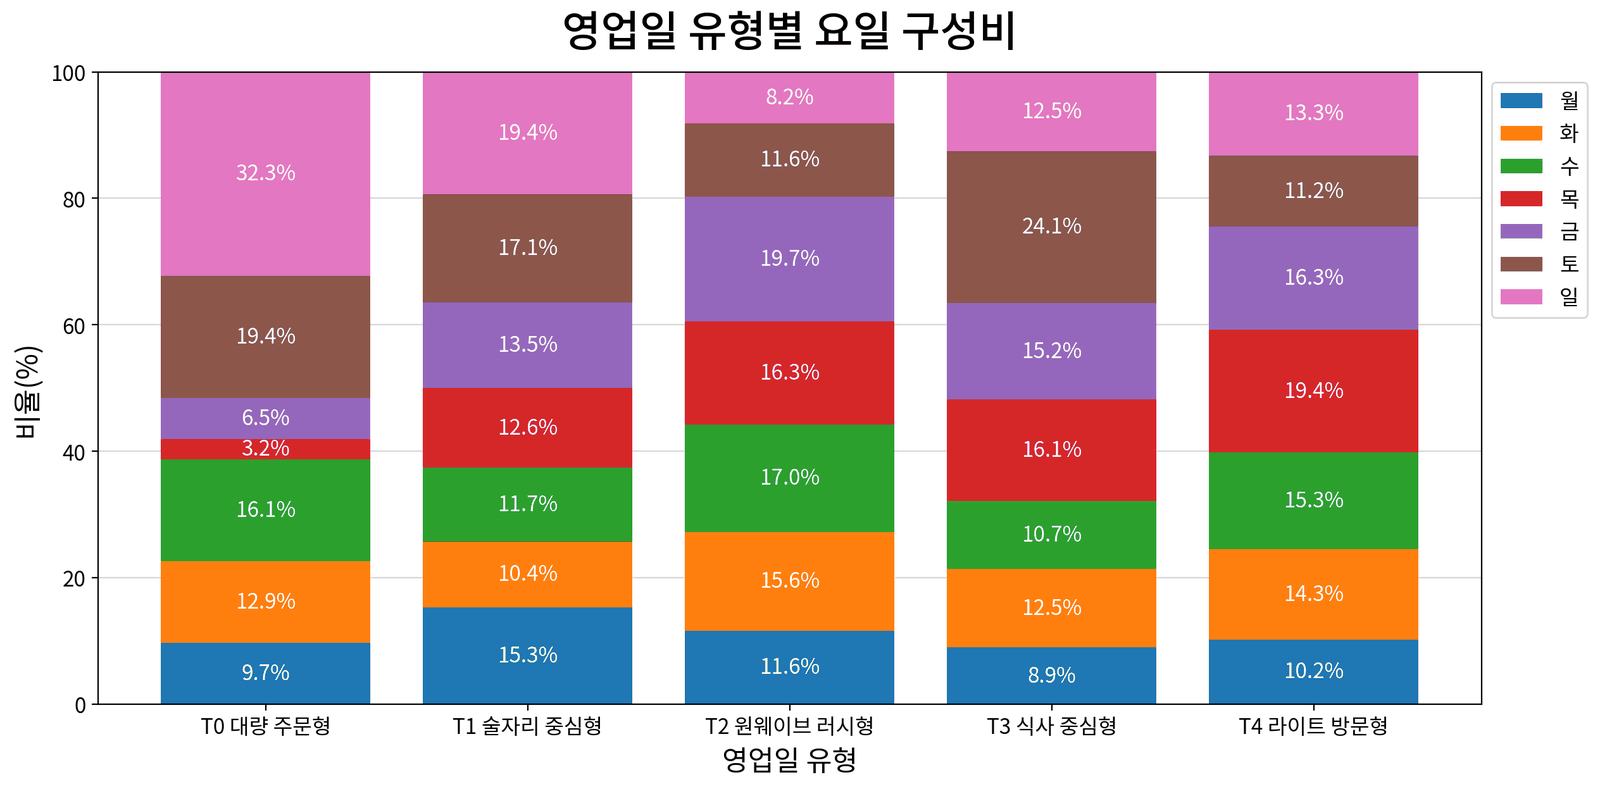

C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


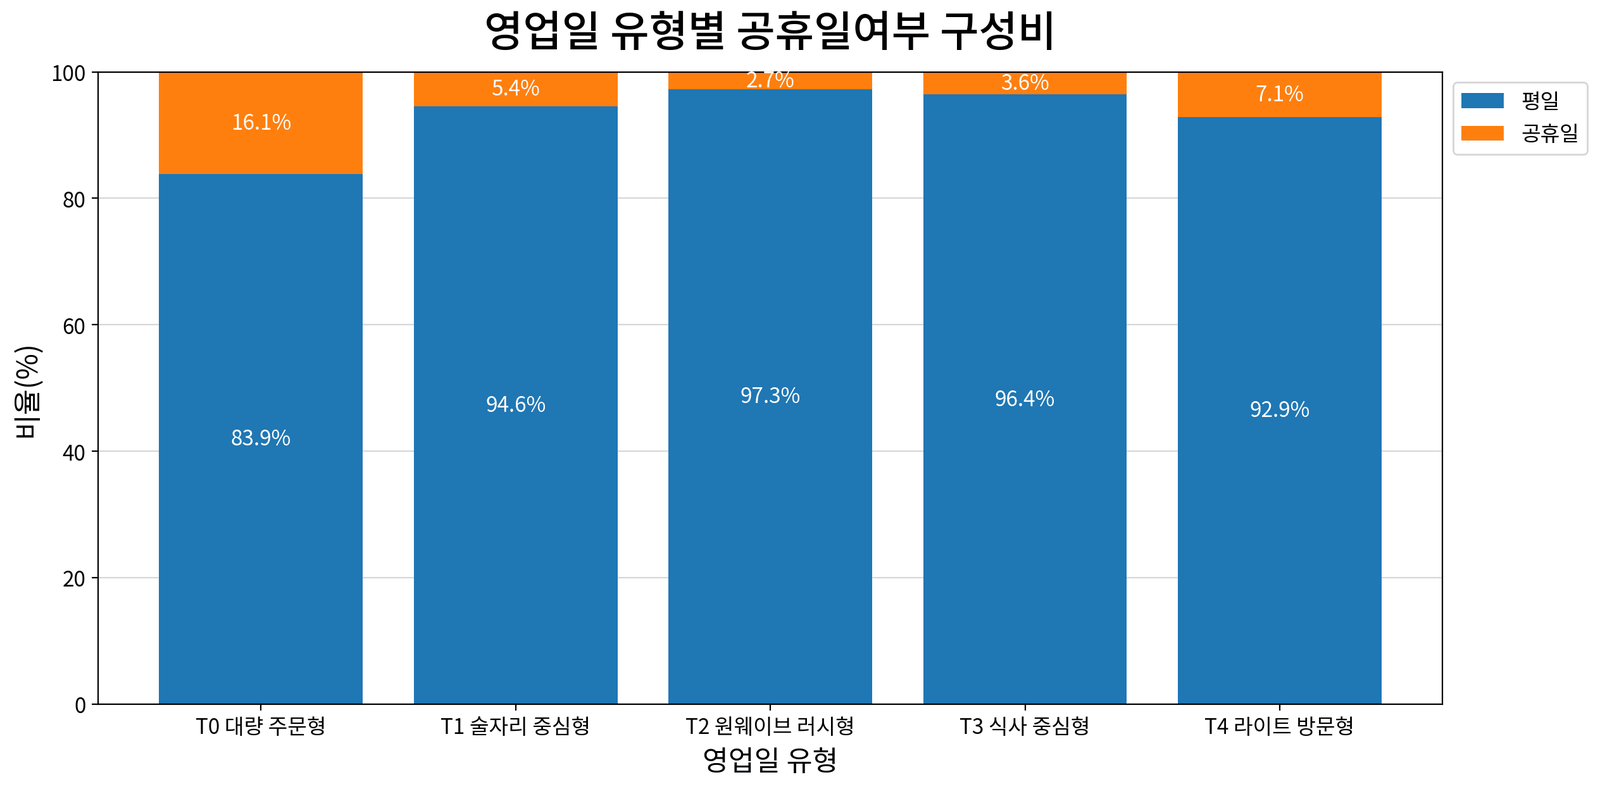

C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


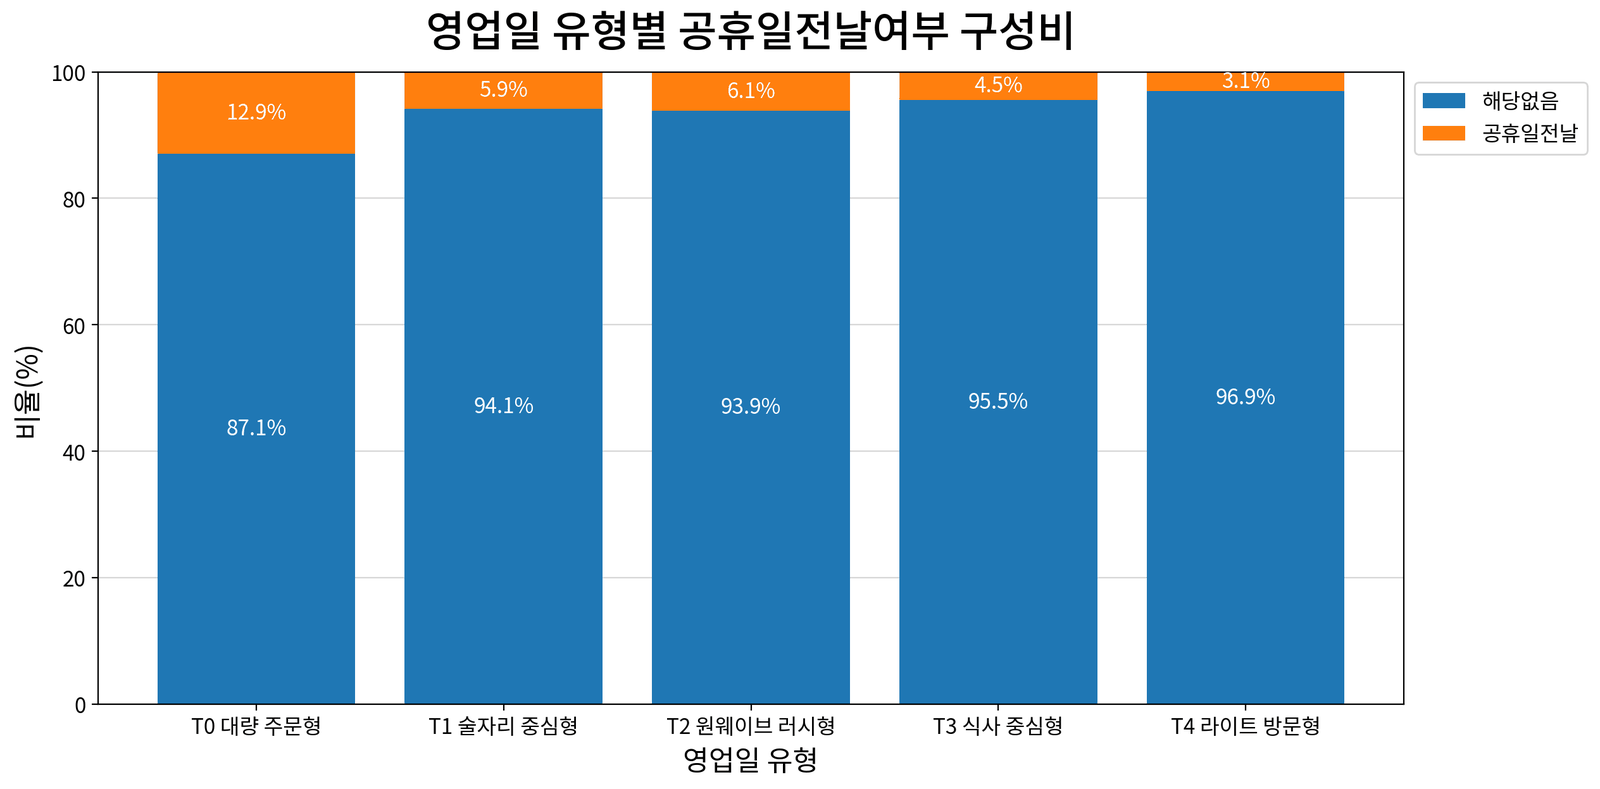

C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


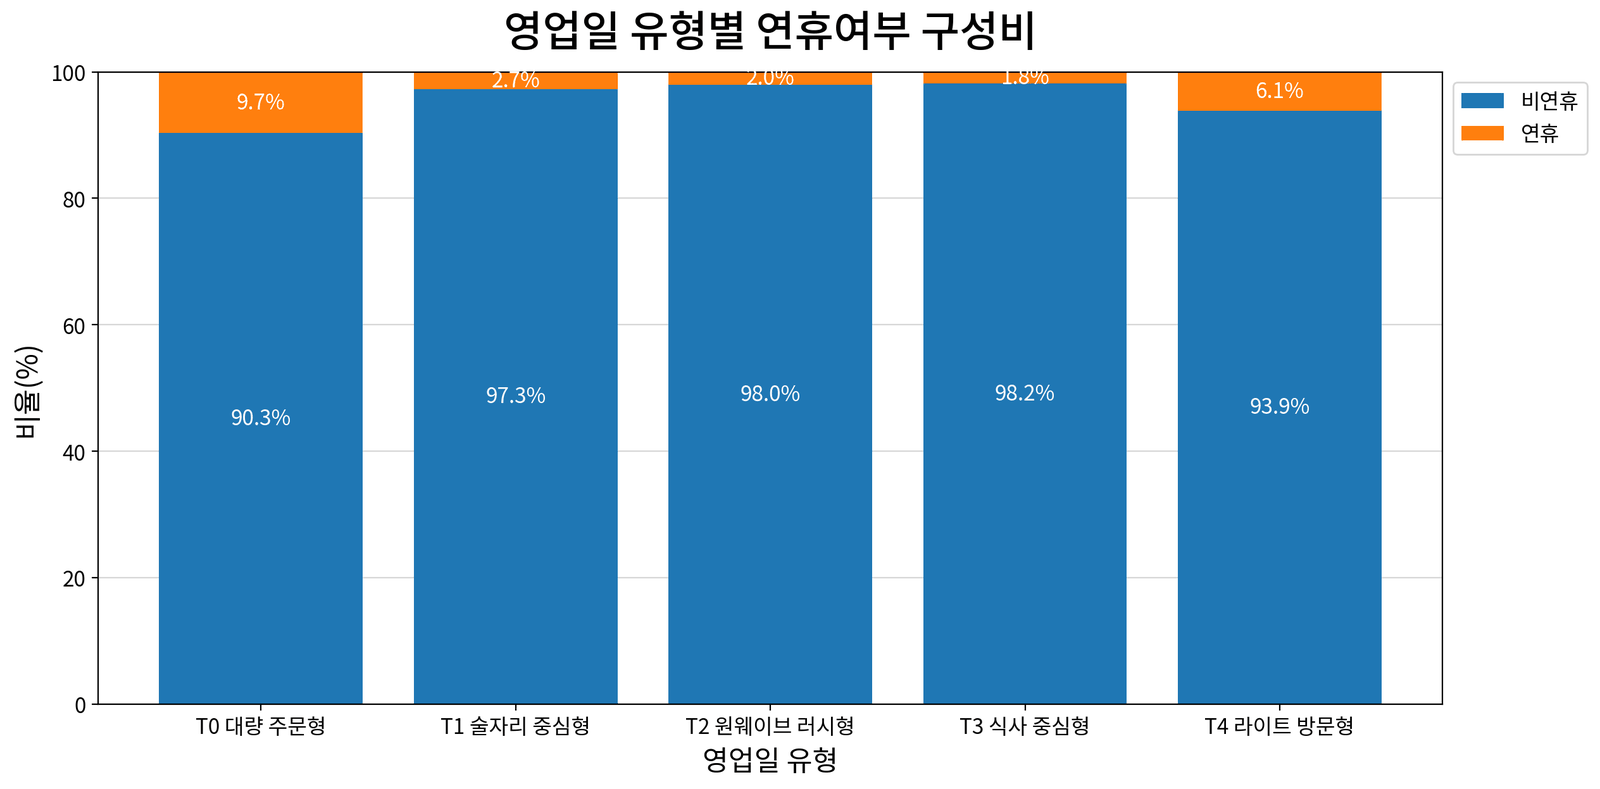

##### 영업일 유형 × 달력 변수 카이제곱 검정 결과

chi2  dof  min_expected  assumption   p-value  p-montecarlo  \
row  col                                                                       
Type 요일       39.7739   24          3.76        True  0.022613      0.024398   
     공휴일여부    10.6245    4          1.63        True  0.031125      0.030897   
     공휴일전날여부   4.7193    4          1.73        True  0.317334      0.313069   
     연휴여부      8.2314    4          1.02       False  0.083461      0.076792   

               p-final            p-source  significant(final)  effect(V)  \
row  col                                                                    
Type 요일       0.090452   Chi-square (Holm)               False     0.1277   
     공휴일여부    0.093375   Chi-square (Holm)               False     0.1320   
     공휴일전날여부  0.317334   Chi-square (Holm)               False     0.0880   
     연휴여부     0.153584  Monte Carlo (Holm)               False     0.1162   

                strength  
row  col                  
Type 요일             Weak  
     공휴일여부          Weak  
     공휴일전날여부  Negligible  
     연휴여부           Weak

C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


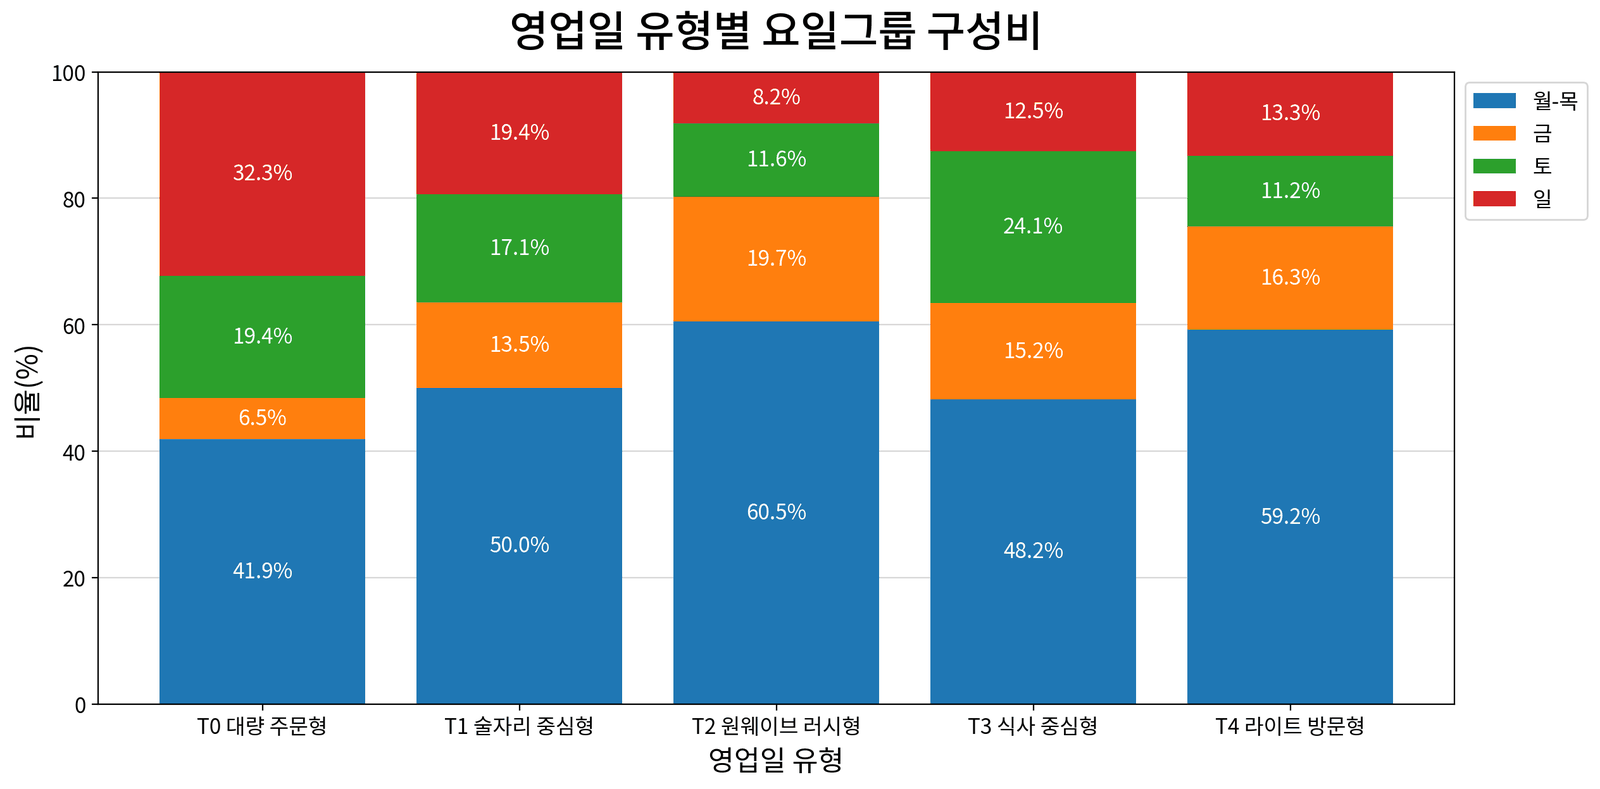

C:\Users\yeold\OneDrive\Desktop\helpers\my_plot.py:649: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


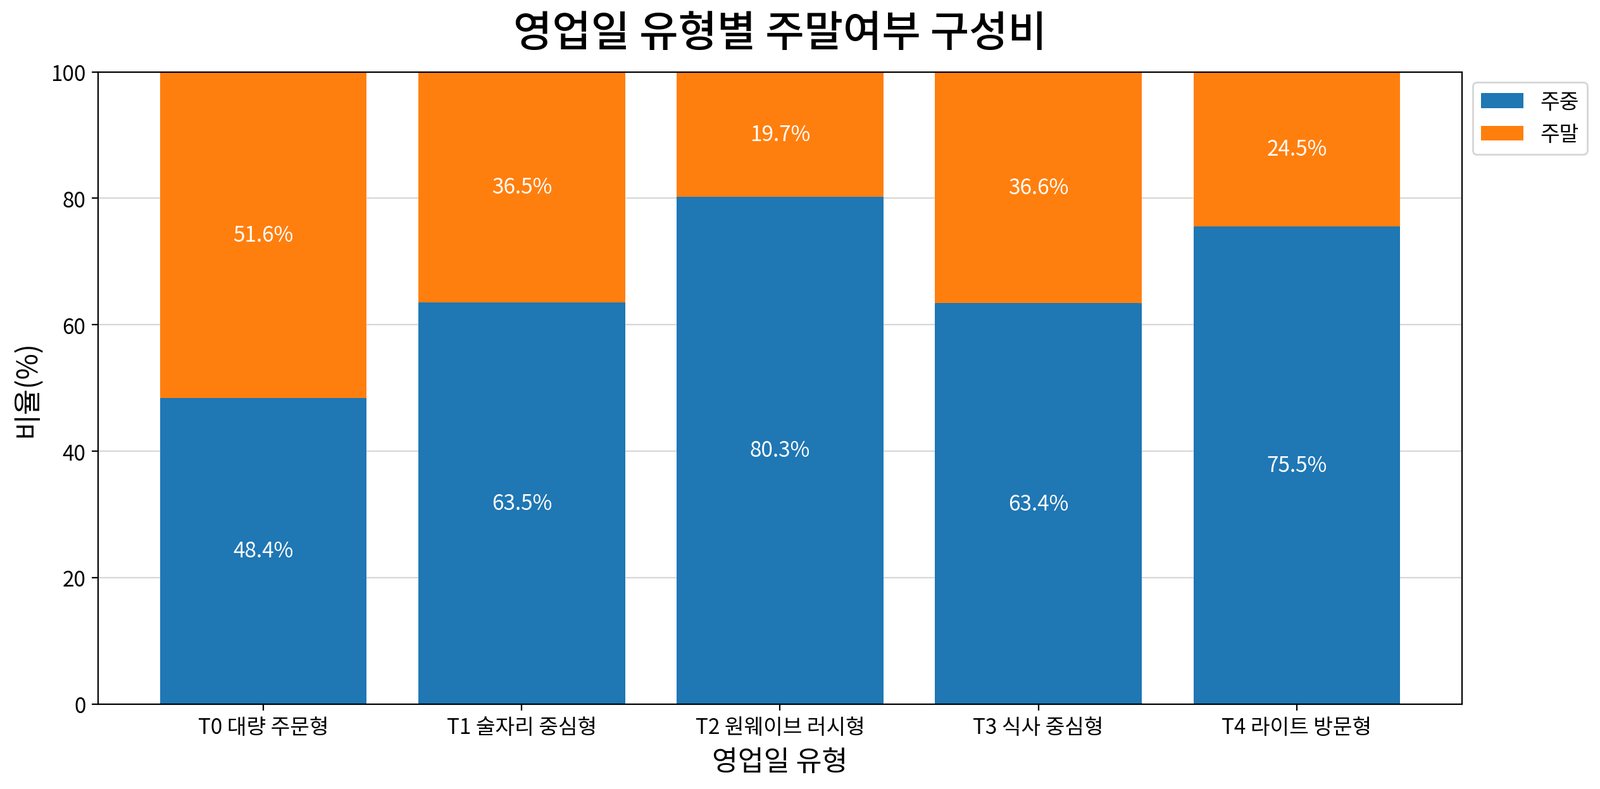

##### 요일 병합 버전 재검정 결과

chi2  dof  min_expected  assumption   p-value  p-montecarlo  \
row  col                                                                    
Type 요일그룹  30.0073   12          4.68        True  0.002785        0.0028   
     주말여부  21.4567    4          9.71        True  0.000257        0.0001   

           effect(V) strength  
row  col                       
Type 요일그룹     0.1281     Weak  
     주말여부     0.1875     Weak

In [52]:
# =========================================================================
# [보조 분석 - 3단계] 영업일 유형 × 달력 변수 카이제곱 독립성 검정
# =========================================================================
# ※ 달력 변수는 군집 전용 테이블(df_cluster_final)에는 없고 마스터(df_final)에 있다.
#    df_final 은 6.1에서 final_selected_dataset.xlsx 를 다시 불러온 상태이므로
#    요일은 코드값(Tuesday=0, Monday=1, … Sunday=6), 이진 변수는 0/1 이다.
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05
N_ITER = 10000                                   # 몬테카를로 순열 반복 횟수
CAL_VARS = ["요일", "공휴일여부", "공휴일전날여부", "연휴여부"]
WEEK_ORDER = ["월", "화", "수", "목", "금", "토", "일"]

# -------------------------------------------------------------------------
# 1. 분석용 데이터 구성 (코드값 → 한글 라벨 → 범주형)
# -------------------------------------------------------------------------
DOW_CODE2KO = {0: "화", 1: "월", 2: "수", 3: "목", 4: "금", 5: "토", 6: "일"}   # 6.1 인코딩 기준
BINARY_LABELS = {
    "공휴일여부": ["평일", "공휴일"],
    "공휴일전날여부": ["해당없음", "공휴일전날"],
    "연휴여부": ["비연휴", "연휴"],
}
TYPE_ORDER = [f"T{i} {p}" for p, i in sorted(PERSONA_ID.items(), key=lambda x: x[1])]

chi_df = DataFrame(index=df_final.index)
# 영수증 2건 이하로 군집에서 제외된 날은 '미분류'
chi_df["Type"] = pd.Categorical(
    [f"T{int(t)} {p}" if pd.notna(t) else "미분류" for t, p in zip(df_final["영업일_유형"], df_final["페르소나"])],
    categories=TYPE_ORDER + ["미분류"], ordered=True,
)
chi_df["요일"] = pd.Categorical(
    df_final["요일"].astype(int).map(DOW_CODE2KO), categories=WEEK_ORDER, ordered=True
)
for col, labels in BINARY_LABELS.items():
    chi_df[col] = pd.Categorical(
        df_final[col].astype(int).map({0: labels[0], 1: labels[1]}),
        categories=labels, ordered=True,
    )

# 매핑 누락 검증 (조용히 NaN 이 되는 것을 방지)
if chi_df.isna().any().any():
    raise ValueError(f"라벨 변환 중 결측 발생:\n{chi_df.isna().sum()}")

# 요일 병합 파생 (희소 셀 완화용)
chi_df["요일그룹"] = pd.Categorical(
    chi_df["요일"].astype(str).map({"월": "월-목", "화": "월-목", "수": "월-목", "목": "월-목",
                                   "금": "금", "토": "토", "일": "일"}),
    categories=["월-목", "금", "토", "일"], ordered=True,
)
chi_df["주말여부"] = pd.Categorical(
    np.where(chi_df["요일"].isin(["토", "일"]), "주말", "주중"), categories=["주중", "주말"]
)

# 요일별 미분류(영수증 2건 이하) 일수와 비율
chi_all = chi_df.copy()   # 미분류 포함 전체 (9장 캘린더용)
unclassified = pd.crosstab(chi_all["요일"], chi_all["Type"] == "미분류")
unclassified.columns = ["분류", "미분류"]
unclassified["미분류 비율(%)"] = (unclassified["미분류"] / unclassified.sum(axis=1) * 100).round(1)
display(Markdown("##### 요일별 미분류(영수증 2건 이하) 일수"))
display(unclassified)

# 이후 검정은 유형이 배정된 날만 사용
chi_df = chi_all[chi_all["Type"] != "미분류"].copy()
chi_df["Type"] = chi_df["Type"].cat.remove_unused_categories()

# -------------------------------------------------------------------------
# 2. 교차 빈도 사전 점검
# -------------------------------------------------------------------------
for var in CAL_VARS:
    display(Markdown(f"**영업일 유형 × {var} 교차 빈도**"))
    display(pd.crosstab(chi_df["Type"], chi_df[var], margins=True, margins_name="합계"))

# -------------------------------------------------------------------------
# 3. 몬테카를로 순열 p-value 함수
#    my_stats.chi2_independence 는 가정 위반 시 2x2 표에서만 피셔 검정으로 분기하므로,
#    5x2·5x7 표는 행 라벨을 섞어 만든 귀무분포로 p-value 를 보완한다.
# -------------------------------------------------------------------------
def chi2_monte_carlo(data, row, col, n_iter=N_ITER, random_state=RANDOM_STATE):
    """행 라벨 순열로 카이제곱 통계량의 귀무분포를 만들어 (관측 chi2, p-value)를 반환한다."""
    r = pd.Categorical(data[row]).remove_unused_categories().codes
    c = pd.Categorical(data[col]).remove_unused_categories().codes
    nr, nc, n = r.max() + 1, c.max() + 1, len(r)
    obs = np.bincount(r * nc + c, minlength=nr * nc).reshape(nr, nc)
    expected = obs.sum(1, keepdims=True) * obs.sum(0, keepdims=True) / n
    stat = lambda t: float(((t - expected) ** 2 / expected).sum())
    chi2_obs = stat(obs)
    rng = np.random.default_rng(random_state)
    hits = 0
    for _ in range(n_iter):
        t = np.bincount(rng.permutation(r) * nc + c, minlength=nr * nc).reshape(nr, nc)
        hits += stat(t) >= chi2_obs - 1e-12
    return chi2_obs, (hits + 1) / (n_iter + 1)

# -------------------------------------------------------------------------
# 4. 카이제곱 독립성 검정 (my_stats) + 몬테카를로 보완 + Holm 보정
# -------------------------------------------------------------------------
results = []
for var in CAL_VARS:
    r = my_stats.chi2_independence(
        data=chi_df, x="Type", y=var, alpha=ALPHA, plot=True,
        title=f"영업일 유형별 {var} 구성비", xlabel="영업일 유형",
    )
    r["p-montecarlo"] = round(chi2_monte_carlo(chi_df, "Type", var)[1], 6)
    results.append(r)

chi2_df = pd.concat(results)
chi2_df["p-holm"] = multipletests(chi2_df["p-value"], method="holm")[1].round(6)
chi2_df["p-mc-holm"] = multipletests(chi2_df["p-montecarlo"], method="holm")[1].round(6)
# 기대빈도 가정 충족 → 카이제곱 p / 위반 → 몬테카를로 p (둘 다 Holm 보정)
chi2_df["p-final"] = np.where(chi2_df["assumption"], chi2_df["p-holm"], chi2_df["p-mc-holm"])
chi2_df["p-source"] = np.where(chi2_df["assumption"], "Chi-square (Holm)", "Monte Carlo (Holm)")
chi2_df["significant(final)"] = chi2_df["p-final"] < ALPHA

display(Markdown("##### 영업일 유형 × 달력 변수 카이제곱 검정 결과"))
display(chi2_df[["chi2", "dof", "min_expected", "assumption", "p-value", "p-montecarlo",
                 "p-final", "p-source", "significant(final)", "effect(V)", "strength"]])

# -------------------------------------------------------------------------
# 5. 요일 병합 버전 재검정 (월-목/금/토/일, 주중/주말)
# -------------------------------------------------------------------------
merged = []
for var in ["요일그룹", "주말여부"]:
    r = my_stats.chi2_independence(
        data=chi_df, x="Type", y=var, alpha=ALPHA, plot=True,
        title=f"영업일 유형별 {var} 구성비", xlabel="영업일 유형",
    )
    r["p-montecarlo"] = round(chi2_monte_carlo(chi_df, "Type", var)[1], 6)
    merged.append(r)

display(Markdown("##### 요일 병합 버전 재검정 결과"))
display(pd.concat(merged)[["chi2", "dof", "min_expected", "assumption", "p-value",
                           "p-montecarlo", "effect(V)", "strength"]])

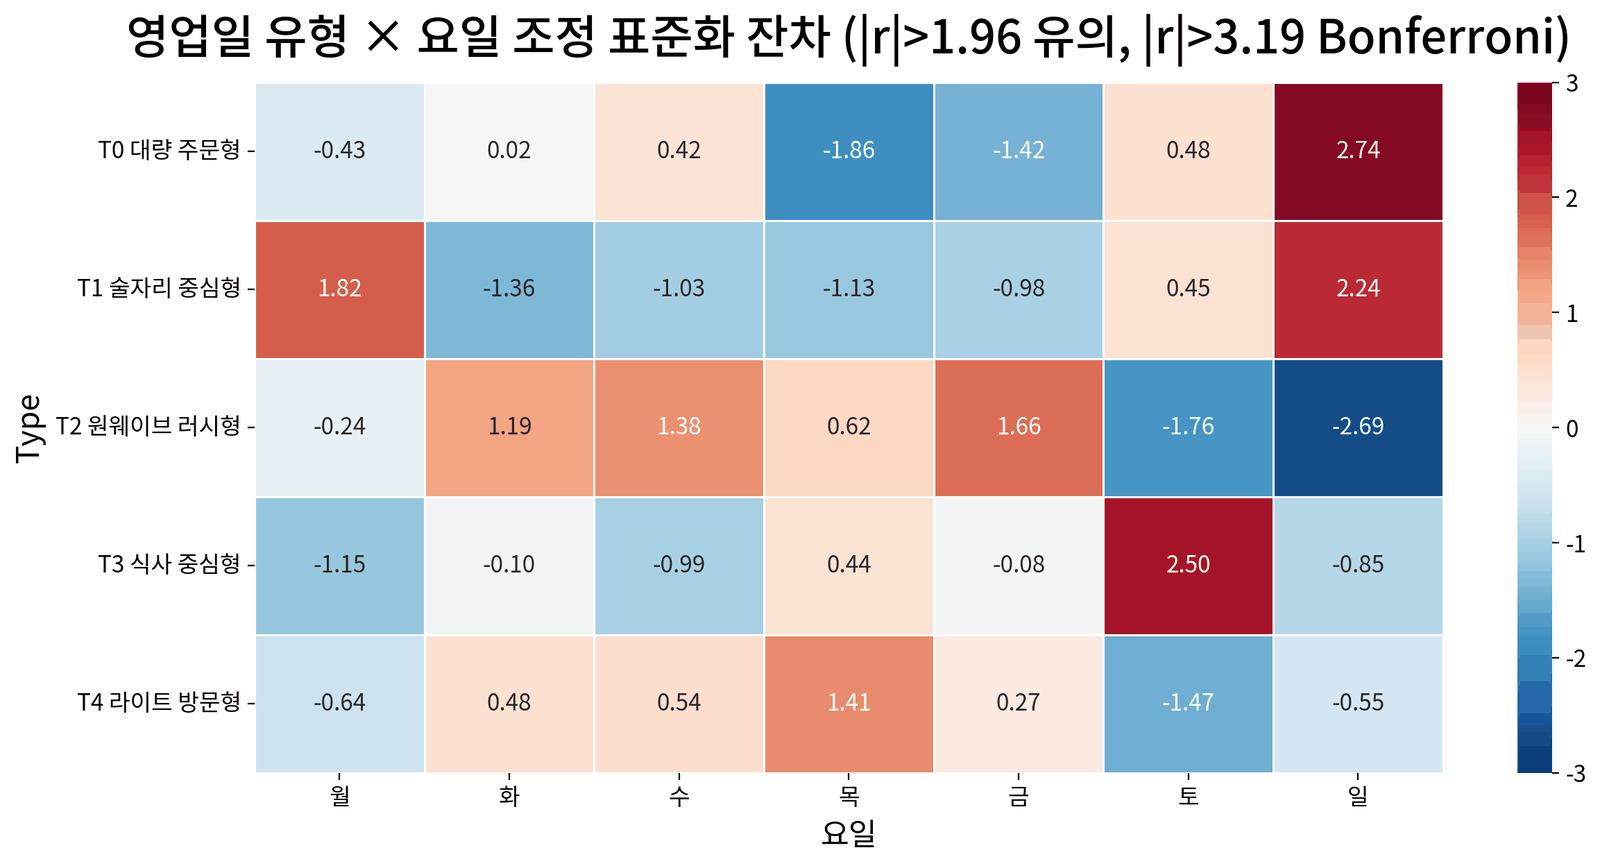

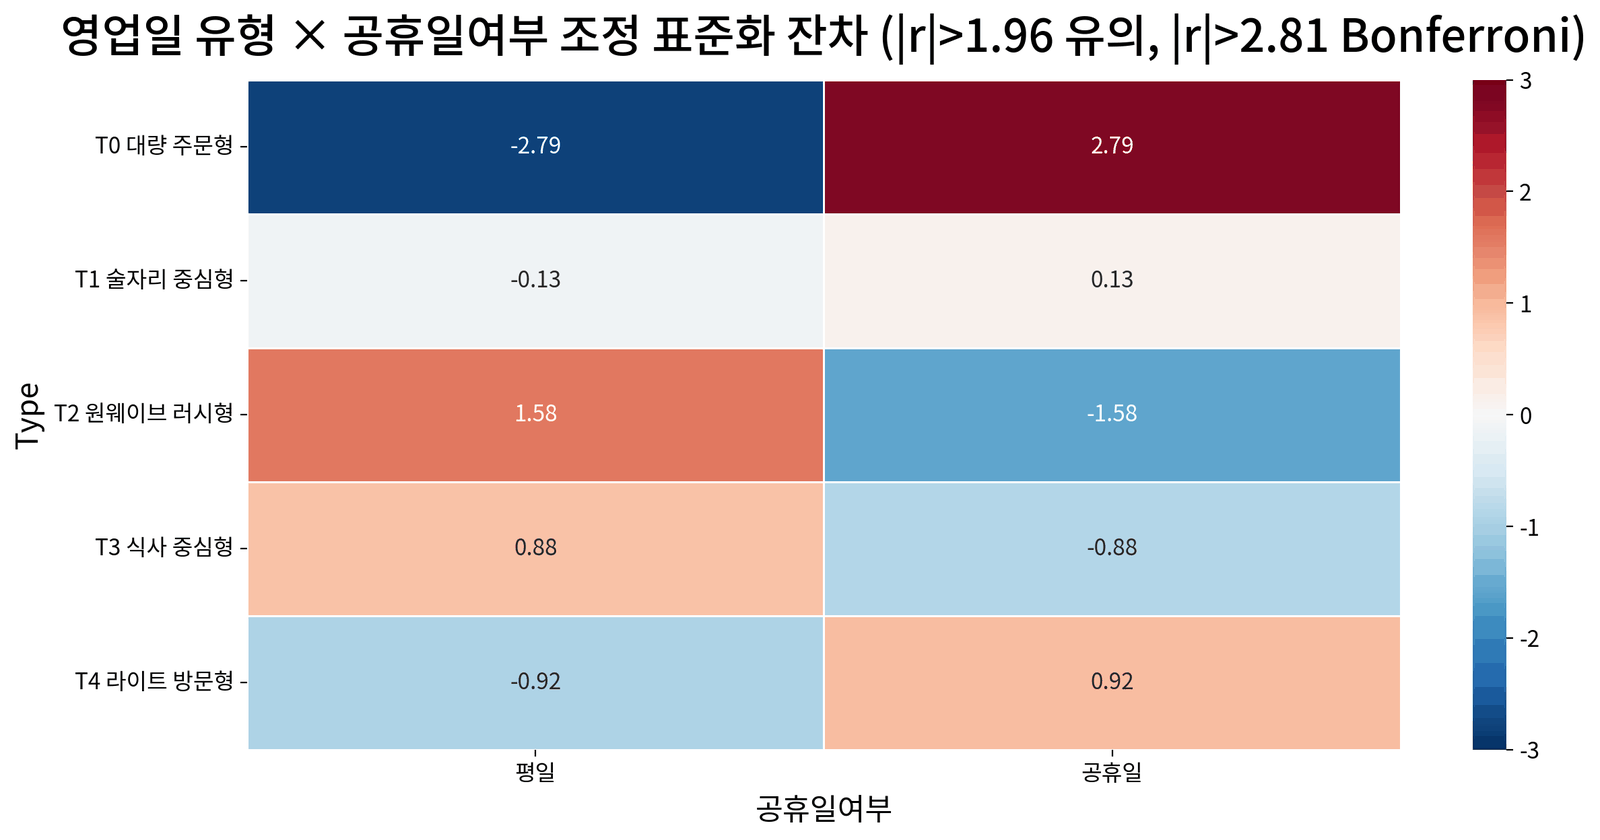

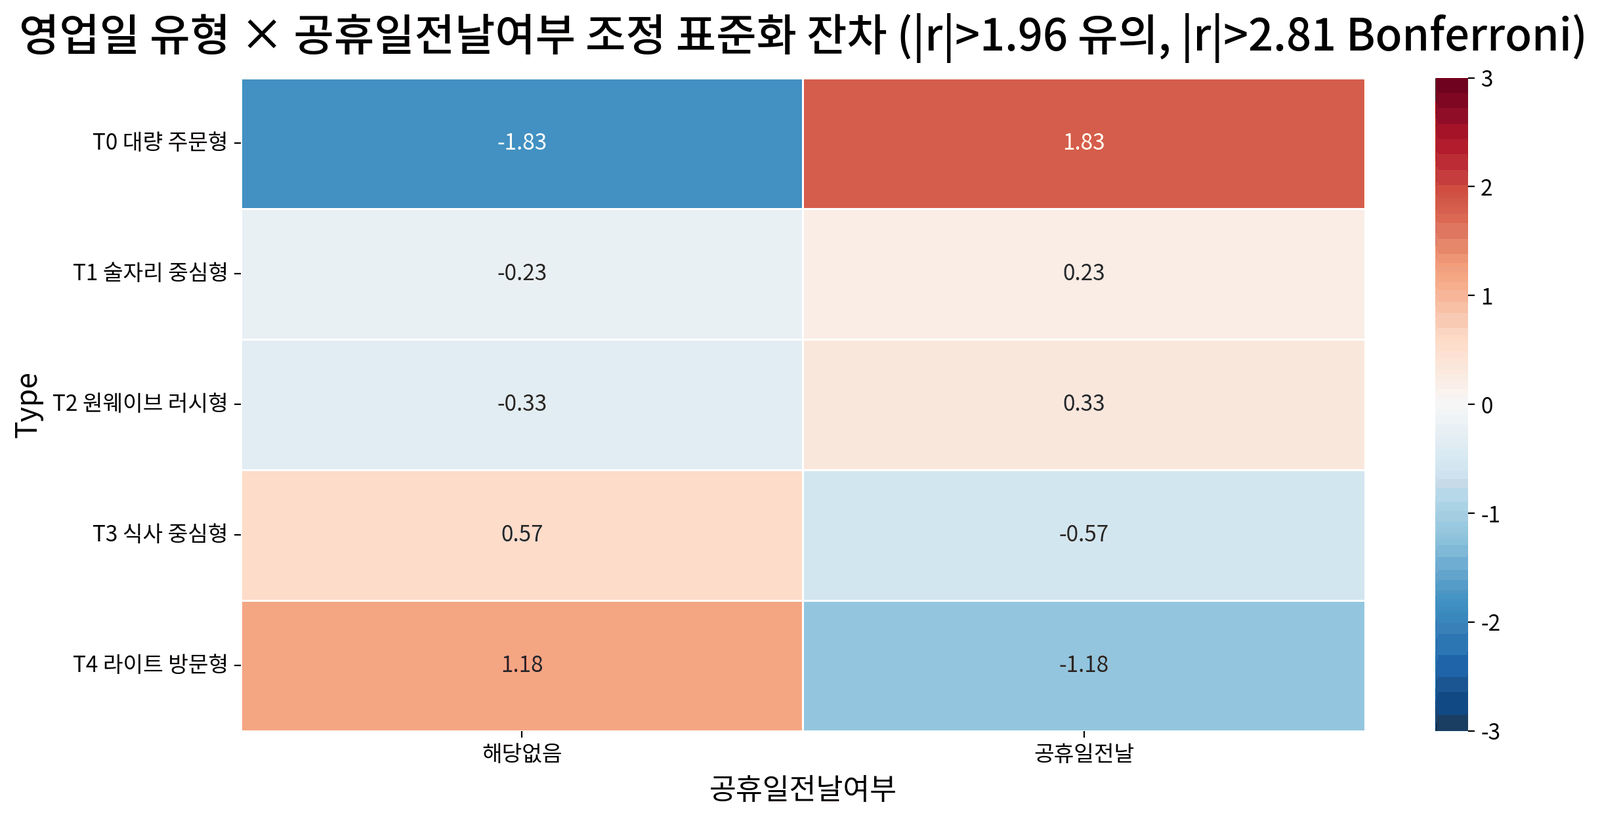

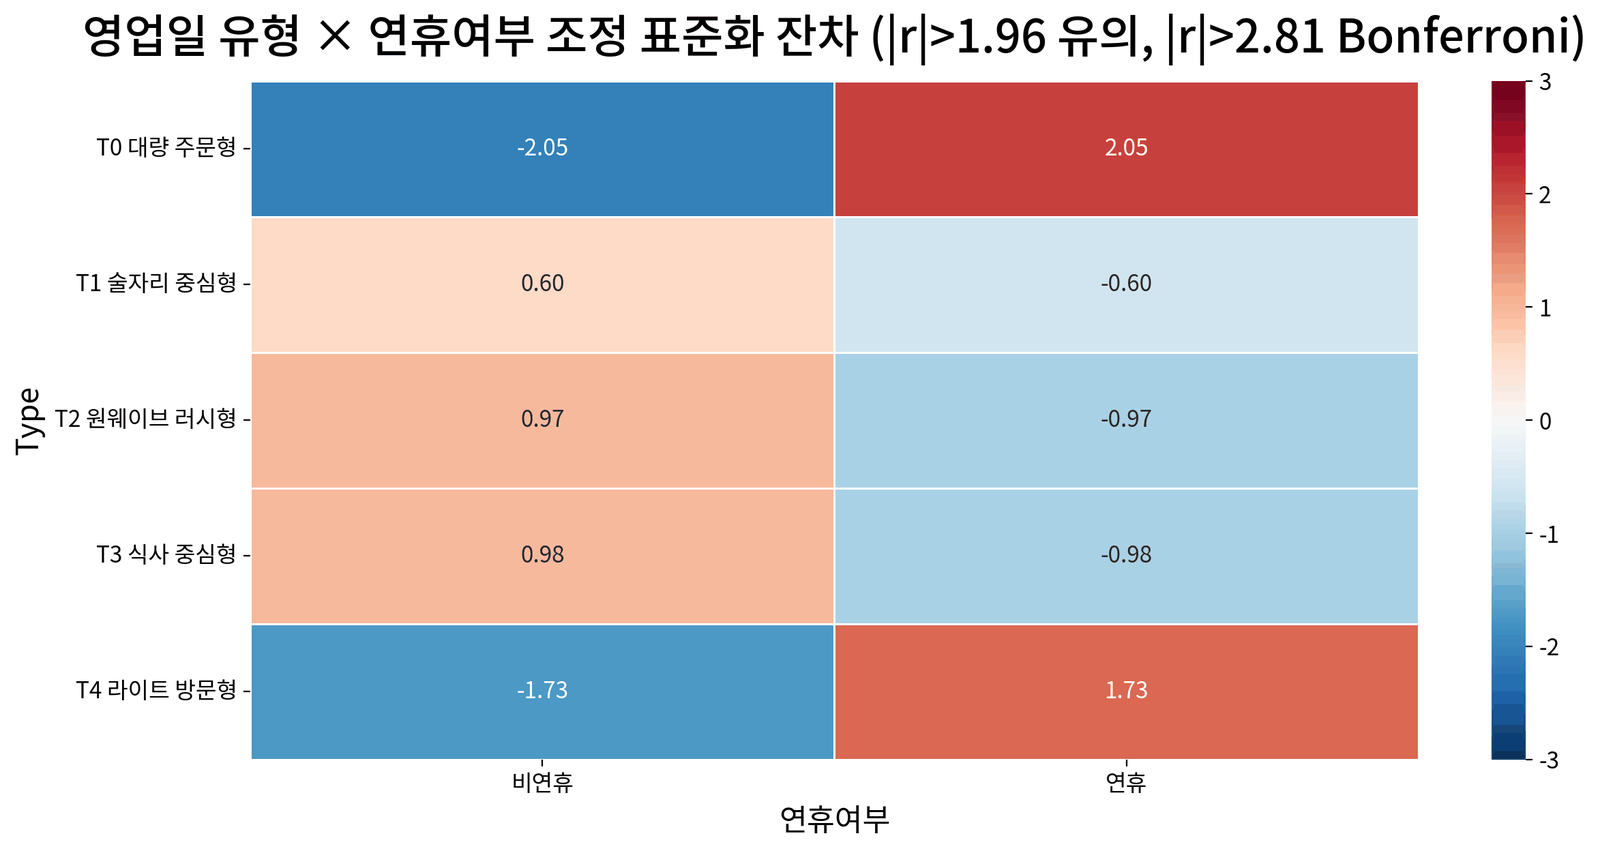

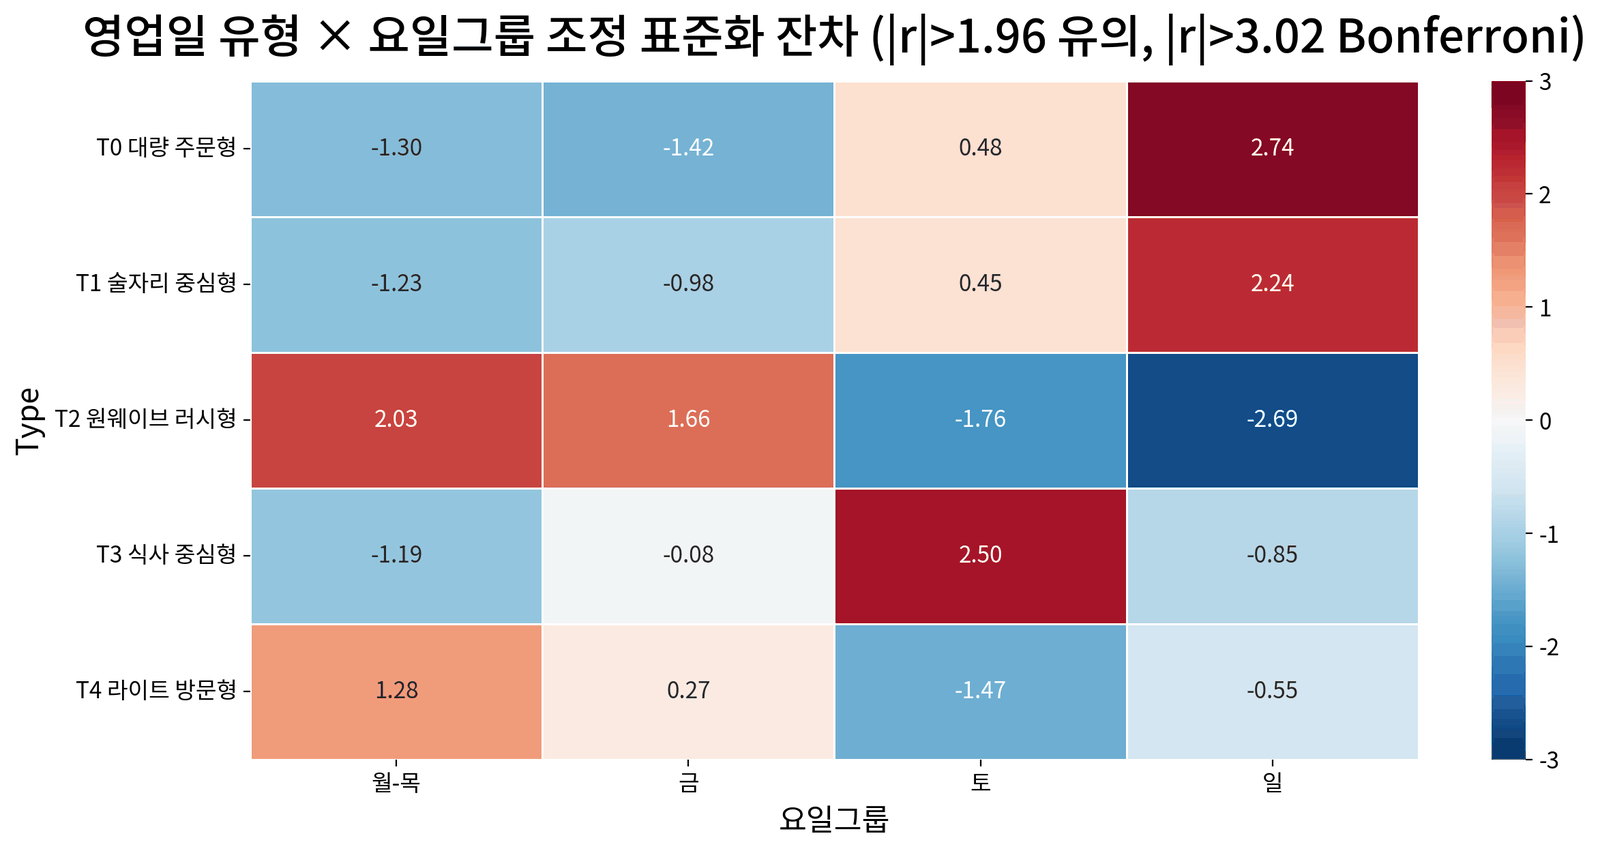

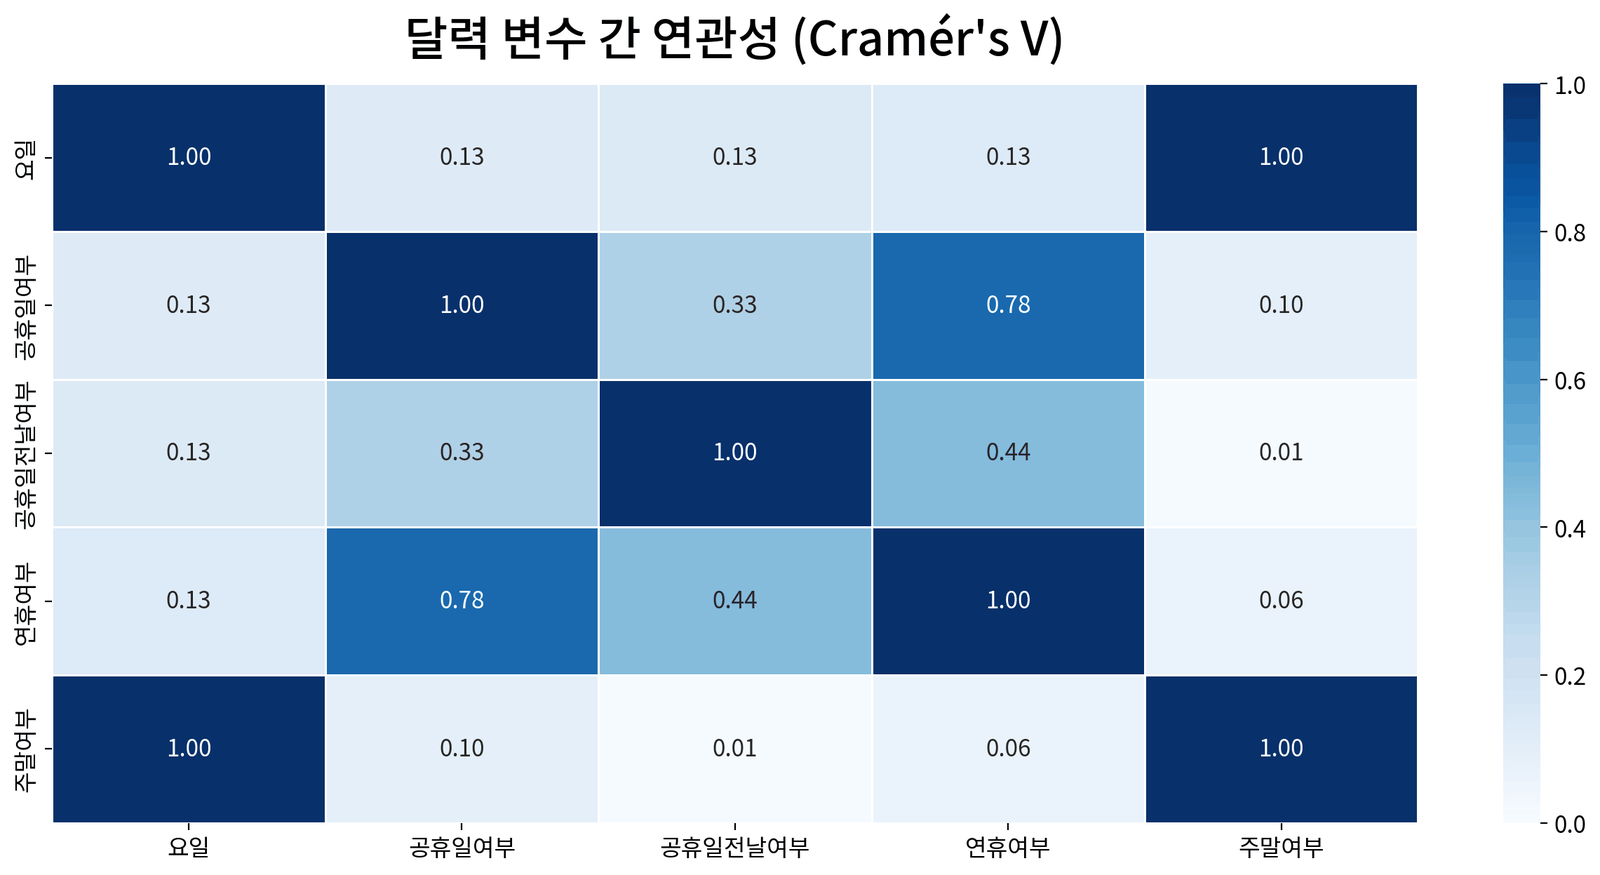

##### 영업일 유형 × 달력 변수 연관성 요약

,달력 변수,검정 근거,최종 p-value,유의성,Cramér's V,효과 강도,과대 출현 (+),과소 출현 (-)
0,요일,Chi-square (Holm),0.090452,비유의,0.1277,Weak,"T0 대량 주문형→일(+2.74), T1 술자리 중심형→일(+2.24), T3 식사 중심형→토(+2.50)",T2 원웨이브 러시형→일(-2.69)
1,공휴일여부,Chi-square (Holm),0.093375,비유의,0.1320,Weak,T0 대량 주문형→공휴일(+2.79),T0 대량 주문형→평일(-2.79)
2,공휴일전날여부,Chi-square (Holm),0.317334,비유의,0.0880,Negligible,-,-
3,연휴여부,Monte Carlo (Holm),0.153584,비유의,0.1162,Weak,T0 대량 주문형→연휴(+2.05),T0 대량 주문형→비연휴(-2.05)


In [53]:
# =========================================================================
# [보조 분석 - 4단계] 사후 분석: 조정 표준화 잔차 및 달력 변수 간 중복도 점검
# =========================================================================
# -------------------------------------------------------------------------
# 1. 조정 표준화 잔차 (|r| > 1.96 : 유의 / Bonferroni 임계값 병기)
#    빨강 = 기대보다 많이 출현, 파랑 = 기대보다 적게 출현
# -------------------------------------------------------------------------
def adjusted_residuals(data, row, col, alpha=ALPHA):
    """교차표의 조정 표준화 잔차표와 (1.96 기준, Bonferroni 기준) 임계값을 반환한다."""
    ct = pd.crosstab(data[row], data[col])
    n = ct.values.sum()
    expected = chi2_contingency(ct, correction=False)[3]
    row_p = ct.sum(axis=1).values[:, None] / n
    col_p = ct.sum(axis=0).values[None, :] / n
    resid = (ct.values - expected) / np.sqrt(expected * (1 - row_p) * (1 - col_p))
    crit = norm.ppf(1 - alpha / 2)
    crit_bonf = norm.ppf(1 - alpha / (2 * ct.size))
    return DataFrame(resid, index=ct.index, columns=ct.columns), crit, crit_bonf

residual_tables = {}
for var in CAL_VARS + ["요일그룹"]:
    resid_df, crit, crit_bonf = adjusted_residuals(chi_df, "Type", var)
    residual_tables[var] = resid_df
    lim = max(3.0, float(np.abs(resid_df.values).max()))
    my_plot.heatmap(
        data=resid_df, annot=True, fmt="0.2f", palette="RdBu_r",
        title=f"영업일 유형 × {var} 조정 표준화 잔차 (|r|>{crit:.2f} 유의, |r|>{crit_bonf:.2f} Bonferroni)",
        xlabel=var, ylabel="영업일 유형", center=0, vmin=-lim, vmax=lim,
    )

# -------------------------------------------------------------------------
# 2. 달력 변수 간 크라메르 V (0.5 이상이면 같은 효과를 중복 해석할 위험)
# -------------------------------------------------------------------------
#    ※ my_stats.chi2_independence 도 크라메르 V 를 주지만 2x2 표에 예이츠 보정을 적용하고 누적 막대그래프를
#      함께 그리므로, 변수 간 비교용 행렬은 보정 없는 값으로 직접 계산한다.
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if min(ct.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(ct, correction=False)[0]
    return float(np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))))

overlap_vars = CAL_VARS + ["주말여부"]
v_mat = DataFrame(
    [[1.0 if a == b else cramers_v(chi_df[a], chi_df[b]) for b in overlap_vars] for a in overlap_vars],
    index=overlap_vars, columns=overlap_vars,
)
my_plot.heatmap(data=v_mat, annot=True, fmt="0.2f", palette="Blues",
                title="달력 변수 간 연관성 (Cramér's V)", vmin=0, vmax=1)

# -------------------------------------------------------------------------
# 3. 보고서용 요약표: 유의성 + 과대/과소 출현 조합
# -------------------------------------------------------------------------
def top_cells(resid_df, crit=1.96):
    over = [f"{t}→{c}({v:+.2f})" for t in resid_df.index for c in resid_df.columns
            if (v := resid_df.loc[t, c]) > crit]
    under = [f"{t}→{c}({v:+.2f})" for t in resid_df.index for c in resid_df.columns
             if (v := resid_df.loc[t, c]) < -crit]
    return ", ".join(over) or "-", ", ".join(under) or "-"

summary_rows = []
for var in CAL_VARS:
    row = chi2_df.xs(var, level="col").iloc[0]
    over, under = top_cells(residual_tables[var])
    summary_rows.append({
        "달력 변수": var,
        "검정 근거": row["p-source"],
        "최종 p-value": row["p-final"],
        "유의성": "유의" if row["significant(final)"] else "비유의",
        "Cramér's V": row["effect(V)"],
        "효과 강도": row["strength"],
        "과대 출현 (+)": over,
        "과소 출현 (-)": under,
    })

display(Markdown("##### 영업일 유형 × 달력 변수 연관성 요약"))
display(DataFrame(summary_rows))

#### 8.3.1 검정 결과 해석

##### 1) 요일별 미분류(영수증 2건 이하)일

| 요일 | 월 | 화 | 수 | 목 | 금 | 토 | 일 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 미분류 일수 | 19 | 19 | 16 | 10 | 6 | 2 | 8 |
| 미분류 비율 | **20.4%** | **19.6%** | 16.2% | 10.0% | 6.0% | 2.0% | 8.0% |

* 손님이 1~2팀뿐인 날은 **월·화요일에 약 5일 중 1일꼴**로 나타나고 토요일에는 거의 없습니다. 유형 검정에서는 빠지는 날들이지만 주초 평일에 손님이 매우 적은 날이 잦다는 사실은 그 자체로 운영 정보가 됩니다.

##### 2) 달력 변수별 연관성

| 달력 변수 | 검정 전 p값 | 최종 p값 (홀름 보정) | 크라메르 V | 판정 |
| :--- | :---: | :---: | :---: | :--- |
| 요일 | 0.023 | 0.090 | 0.128 | 비유의 (보정 전에는 유의) |
| 공휴일여부 | 0.031 | 0.093 | 0.132 | 비유의 (보정 전에는 유의) |
| 공휴일전날여부 | 0.317 | 0.317 | 0.088 | 비유의 |
| 연휴여부 (몬테카를로) | 0.077 | 0.154 | 0.116 | 비유의 |
| (참고) 주말여부: 주중 / 토·일 | 0.0003 | - | 0.188 | **유의** |
| (참고) 요일그룹: 월-목 / 금 / 토 / 일 | 0.003 | - | 0.128 | **유의** |

* 네 변수 모두 다중비교 보정 후에는 유의하지 않았고 크라메르 V도 0.09~0.13으로 약합니다. 즉 **유형은 달력과 약하게만 연결됩니다.** 방문 규모를 뺀 유형은 무슨 요일이냐보다 그날 온 손님의 주문 성향에 따라 정해지는 성격이 강합니다.
* 그래도 요일을 주중과 토·일로 묶으면 p = 0.0003(V = 0.19)으로 **주중·주말 구분은 유의합니다.** 유형 분포가 주말과 평일에 다르다는 점은 확인됩니다.

##### 3) 과대·과소 출현 (조정 표준화 잔차)

| 유형 | 월 | 화 | 수 | 목 | 금 | 토 | 일 | 주말(토·일) | 공휴일 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| T0 대량 주문형 | −0.43 | 0.02 | 0.42 | −1.86 | −1.42 | 0.48 | **+2.74** | **+2.50** | **+2.79** |
| T1 술자리 중심형 | 1.82 | −1.36 | −1.03 | −1.13 | −0.98 | 0.45 | **+2.24** | **+2.08** | 0.13 |
| T2 원웨이브 러시형 | −0.24 | 1.19 | 1.38 | 0.62 | 1.66 | −1.76 | **−2.69** | **−3.48** | −1.58 |
| T3 식사 중심형 | −1.15 | −0.10 | −0.99 | 0.44 | −0.08 | **+2.50** | −0.85 | 1.34 | −0.88 |
| T4 라이트 방문형 | −0.64 | 0.48 | 0.54 | 1.41 | 0.27 | −1.47 | −0.55 | −1.59 | 0.92 |

(|r| > 1.96이면 해당 칸이 기대보다 유의하게 많거나 적음. 35칸 동시 검정을 고려한 본페로니 기준은 |r| > 3.19)

* **원웨이브 러시형은 평일형입니다.** 주말에 뚜렷하게 적고(−3.48, 본페로니 기준도 넘음) 일요일에 특히 적습니다. 짧은 시간에 주문이 몰리는 패턴은 퇴근 후 모임이 겹치는 평일 저녁에 주로 나타납니다.
* 대량 주문형은 일요일(+2.74), 공휴일(+2.79), 연휴(+2.05)에 기대보다 많이 나타났습니다. **일요일·공휴일에 많은 유형**이지만 31일짜리 작은 유형이라 전체 검정은 보정 후 유의하지 않았습니다.
* 술자리 중심형은 일요일(+2.24)에, 식사 중심형은 토요일(+2.50)에 많이 나타납니다.
* **라이트 방문형은 어느 요일에도 유의하게 몰리지 않습니다.**

##### 4) 가설 판정

| 가설 | 판정 | 근거 |
| :--- | :--- | :--- |
| **H1** 대량 주문형은 주말·공휴일에 과대 출현 | **경향 확인 (부분 채택)** | 일요일·주말·공휴일 잔차는 유의하지만 요일·공휴일 전체 검정은 홀름 보정 후 비유의. 31일뿐이라 결론은 조심스럽게 봄 |
| **H2** 원웨이브 러시형은 평일형 | **채택** | 주말 과소 출현 잔차 −3.48(본페로니 기준 초과), 주중·주말 구분 검정 p = 0.0003 |
| **H3** 공휴일·연휴는 독자적 유형 분포 | **기각** | 공휴일(보정 후 p = 0.093), 연휴(p = 0.154) 모두 비유의. 대량 주문형만 공휴일에 많은 경향 |

> ※ 일별 데이터는 서로 독립이 아니므로(7일 주기 자기상관) 위 p값은 다소 낙관적일 수 있습니다. 이 때문에 보정 후에도 유의한 주중·주말 구분 외의 결과는 경향으로만 해석합니다.

## 9. [최종 산출] 예측과 유형화 결합: 요일별 운영 캘린더

프로젝트 목표 ③은 "사전에 알 수 있는 정보로 내일의 매출과 장사 형태를 미리 가늠해 운영에 활용하는 것"입니다. 주 분석(7장)에서 일매출은 요일로 대부분 설명되었고 보조 분석(8장)에서 영업 유형은 주중·주말 구분과 약하게 연결되었습니다. 따라서 복잡한 예측 모델 대신, **요일별 평소 매출 수준, 손님이 매우 적은 날의 비율, 영업 유형 출현 비율**을 한 표로 묶은 운영 캘린더를 최종 산출물로 제시합니다.

### 9.1 운영 캘린더 구성

* **매출 수준**: 요일별 매출 중앙값 (6.3.3에서 요일별 중앙값과 최종 모델의 차이가 유의하지 않았으므로, 운영용으로는 이 단순한 기준으로 충분)
* **미분류 비율**: 영수증 2건 이하인, 손님이 매우 적은 날의 비율 (8.3.1)
* **유형 비율**: 미분류를 뺀 날 중 각 영업일 유형이 나타난 비율 (8.3의 교차표)
* **활용 방식**: 확률이 가장 높은 유형 하나로 단정하지 않고 상위 유형들의 운영 포인트(8.2)를 함께 준비하는 방식으로 사용합니다. 유형과 달력의 연관이 약하므로(주중·주말 V = 0.19) 비율은 "대비 우선순위"로만 해석합니다.

In [54]:
# =========================================================================
# 9.1 요일별 운영 캘린더 (매출 중앙값 + 영업일 유형 출현 확률 + 미분류 비율)
# =========================================================================
# 8.3의 chi_all(유형·요일·공휴일 라벨, 미분류 포함)과 df_cluster_all(매출액, 전체 영업일)을 사용한다.
# 두 표는 df_final 과 같은 행 순서이다.
sales = df_cluster_all["매출액"]

def calendar_row(mask, label):
    """조건(mask)에 해당하는 날들의 매출 중앙값, 미분류 비율, 유형별 출현 비율(%)을 한 행으로 만든다.
    유형 비율은 미분류(영수증 2건 이하)를 뺀 날들 기준으로 계산한다."""
    types = chi_all.loc[mask, "Type"]
    typed = types[types != "미분류"]
    type_share = typed.value_counts(normalize=True).reindex(TYPE_ORDER).fillna(0) * 100
    row = {
        "구분": label,
        "일수": int(mask.sum()),
        "매출 중앙값(원)": round(sales[mask].median()),
        "미분류 비율(%)": round((types == "미분류").mean() * 100, 1),
    }
    row.update(type_share.round(1).to_dict())
    row["가장 흔한 유형"] = type_share.idxmax()
    return row

rows = [calendar_row(chi_all["요일"] == d, f"{d}요일") for d in WEEK_ORDER]
rows.append(calendar_row(chi_all["공휴일전날여부"] == "공휴일전날", "공휴일 전날"))
rows.append(calendar_row(chi_all["공휴일여부"] == "공휴일", "공휴일"))
rows.append(calendar_row(pd.Series(True, index=chi_all.index), "전체"))

operating_calendar = DataFrame(rows).set_index("구분")
display(Markdown("##### 요일별 운영 캘린더 (미분류 비율은 해당 조건 전체 기준, 유형 열은 미분류를 뺀 날 기준 출현 비율 %)"))
display(operating_calendar)

##### 요일별 운영 캘린더 (미분류 비율은 해당 조건 전체 기준, 유형 열은 미분류를 뺀 날 기준 출현 비율 %)

,일수,매출 중앙값(원),미분류 비율(%),T0 대량 주문형,T1 술자리 중심형,T2 원웨이브 러시형,T3 식사 중심형,T4 라이트 방문형,가장 흔한 유형
구분,,,,,,,,,
월요일,93,349000,20.4,4.1,45.9,23.0,13.5,13.5,T1 술자리 중심형
화요일,97,397500,19.6,5.1,29.5,29.5,17.9,17.9,T1 술자리 중심형
수요일,99,367000,16.2,6.0,31.3,30.1,14.5,18.1,T1 술자리 중심형
목요일,100,371750,10.0,1.1,31.1,26.7,20.0,21.1,T1 술자리 중심형
금요일,100,589000,6.0,2.1,31.9,30.9,18.1,17.0,T1 술자리 중심형
토요일,101,742500,2.0,6.1,38.4,17.2,27.3,11.1,T1 술자리 중심형
일요일,100,646250,8.0,10.9,46.7,13.0,15.2,14.1,T1 술자리 중심형
공휴일 전날,35,535000,2.9,11.8,38.2,26.5,14.7,8.8,T1 술자리 중심형
공휴일,35,635000,8.6,15.6,37.5,12.5,12.5,21.9,T1 술자리 중심형


### 9.2 운영 캘린더 해석과 활용 제언

| 구분 | 매출 중앙값 | 미분류 비율 | 1순위 유형 (비율) | 2순위 유형 (비율) | 눈여겨볼 점 |
| :--- | :---: | :---: | :--- | :--- | :--- |
| 월요일 | 349,000원 | **20.4%** | 술자리 중심형 (45.9%) | 원웨이브 러시형 (23.0%) | 손님이 매우 적은 날이 5일 중 1일 |
| 화요일 | 397,500원 | **19.6%** | 술자리 중심형 (29.5%) | 원웨이브 러시형 (29.5%) | 원웨이브가 술자리와 같은 비율 |
| 수요일 | 367,000원 | 16.2% | 술자리 중심형 (31.3%) | 원웨이브 러시형 (30.1%) | 원웨이브 비중이 높음 |
| 목요일 | 371,750원 | 10.0% | 술자리 중심형 (31.1%) | 원웨이브 러시형 (26.7%) | 유형이 가장 고르게 섞임 |
| 금요일 | **589,000원** | 6.0% | 술자리 중심형 (31.9%) | 원웨이브 러시형 (30.9%) | 주말 매출 수준에 피크 몰림까지 |
| 토요일 | **742,500원** | 2.0% | 술자리 중심형 (38.4%) | 식사 중심형 (27.3%) | 식사 손님 비중이 가장 높음 |
| 일요일 | **646,250원** | 8.0% | 술자리 중심형 (46.7%) | 식사 중심형 (15.2%) | 대량 주문형 10.9%(평소의 약 2배) |
| 공휴일 전날 | 535,000원 | 2.9% | 술자리 중심형 (38.2%) | 원웨이브 러시형 (26.5%) | 대량 주문형 11.8% (35일 기준) |
| 공휴일 | 635,000원 | 8.6% | 술자리 중심형 (37.5%) | 라이트 방문형 (21.9%) | 대량 주문형 15.6%(평소의 약 3배) |
| (전체) | 455,000원 | 11.6% | 술자리 중심형 (36.4%) | 원웨이브 러시형 (24.1%) | 대량 주문형 5.1% |

* **매출 수준은 요일로 뚜렷하게 갈립니다.** 토(74.3만 원) > 일(64.6만 원) > 공휴일(63.5만 원) > 금(58.9만 원) 순이고 월~목은 35만~40만 원 수준입니다. 발주와 인력 계획의 기본 기준으로 쓸 수 있습니다.
* 월·화요일은 약 20%가 손님 1~2팀뿐인 날입니다. **주초 평일에는 이런 날에 대비해** 재료를 적게 준비하고 영업시간·인력을 탄력적으로 운영할 여지가 있습니다.
* **평일은 피크 몰림(원웨이브)에 대비합니다.** 화~금요일은 원웨이브 러시형이 27~31%로, 19~21시 피크 전 밑작업이 효과적입니다. 주말에는 이 비율이 13~17%로 낮아집니다.
* **일요일·공휴일은 단체 주문 가능성을 확인합니다.** 대량 주문형이 평소(5.1%)의 2~3배로 나타나므로 단체 예약 문의를 미리 확인하고 재료를 넉넉히 준비합니다. 대량 주문형은 31일짜리 표본이어서 이 비율은 참고 수준입니다.
* **술자리 중심형은 어느 날에도 가장 흔합니다.** 30~47%로 모든 조건에서 1순위이므로 주류 재고는 요일과 관계없이 기본으로 갖춰 둡니다.
* 유형과 달력의 연관은 약하므로(8.3.1) **비율은 대비 우선순위로만 사용합니다.** 당일 예약 현황 등 운영자가 가진 추가 정보와 함께 판단해야 합니다.

## 10. 종합 결론

### 10.1 주 분석: 일매출 예측과 매출 요인

1. **일매출은 요일로 대부분 설명됩니다.** 전체 평균 대비 줄일 수 있는 오차의 약 91%는 요일만으로 얻을 수 있었고 최종 모델(Ridge)과 요일별 중앙값 기준선의 차이(약 1.9%)는 통계적으로 유의하지 않았습니다. 교차검증 5개 폴드 중 4개에서 Ridge가 조금 나았지만 개선율은 대부분 1~2%대였습니다(6.3.3).
2. **최종 모델의 가치는 매출 요인의 규명에 있습니다.** SHAP 분석 결과 요일이 예측 기여도의 약 55%를 차지하며 평균적인 날 대비 토요일은 약 1.6배, 일·금요일도 크게 높았습니다. 공휴일은 발생 빈도는 낮지만 해당일 매출을 뚜렷이 끌어올렸고 모델이 요일 기준선보다 나았던 몫도 공휴일에서 가장 컸습니다(6.4, 6.3.3).
3. **휴무 직후의 매출 저하는 실제 효과로 보입니다.** 개업 초기를 빼고 학습해도 `연속영업일수`의 기여는 유지되었습니다(6.6).
4. **효과가 확인되지 않은 요인도 분명히 했습니다.** 기온·강수·기상특보·유동인구는 매출과 유의한 관련이 없었습니다. 리뷰 조회수의 효과는 대부분 개업 초기의 낮은 매출을 반영한 것이었고(6.6) 광고의 순수한 매출 효과는 확인되지 않았습니다. 공휴일 전날의 매출 상승은 학습 기간에는 나타났지만 테스트 기간에는 재현되지 않았습니다.
5. **복잡한 모델보다 단순한 모델이 적합합니다.** 트리·부스팅 계열은 기본 설정에서 요일별 중앙값 기준선보다도 오차가 컸고 튜닝 후에도 근소 격차 그룹에 들지 못했습니다. 요일·공휴일·공휴일 전날 3개 변수만 쓴 단순 모델도 최종 모델과 1.2% 차이에 그쳤습니다.

### 10.2 보조 분석: 영업일 유형화

1. **방문 규모를 뺀 다섯 가지 영업일 유형을 정의했습니다.** 군집 입력을 영수증수와 무관한 `팀당_주문수량`(ρ = 0.036)으로 바꾸고 손님이 1~2팀뿐인 날을 제외하자, 유형은 손님 수가 아니라 **주문 내용과 시간대**로 나뉘었습니다: 대량 주문형, 술자리 중심형, 원웨이브 러시형, 식사 중심형, 라이트 방문형.
2. **유형 구분은 대체로 재현되지만 경계는 흐립니다.** 초기값·표본을 바꿔도 평균적으로 비슷한 분할이 나왔으나(ARI 0.83~0.94), 실루엣 스코어(0.22)와 일부 부분표본의 낮은 ARI(최소 0.61)는 경계에 있는 날이 많다는 뜻입니다.
3. **유형은 주중·주말과 약하게 연결됩니다.** 원웨이브 러시형은 평일형으로 확인되었고 대량 주문형은 일요일·공휴일에 많은 경향이 있었습니다. 다만 요일·공휴일 전체 검정은 보정 후 유의하지 않아 유형은 달력보다 그날 손님의 성향에 크게 좌우됩니다.
4. **손님이 매우 적은 날은 주초에 몰립니다.** 영수증 2건 이하인 날이 월·화요일에는 약 20%였습니다.

### 10.3 실무 제언

* **발주·인력 계획은 요일별 평소 매출 수준을 기준으로 합니다.** 예측 모델을 따로 운영하지 않아도 요일별 중앙값으로 비슷한 정확도를 얻을 수 있습니다(9장 캘린더).
* **공휴일은 따로 챙깁니다.** 요일 기준보다 매출이 크게 오르고 대량 주문형도 많아지는 날이므로, 단체 예약을 확인하고 재고와 인력을 추가로 준비합니다.
* **주초 평일은 최소 준비, 평일 저녁은 피크 대비를 기본으로 합니다.** 월·화요일은 손님이 매우 적은 날이 잦고 화~금요일은 19~21시 피크 몰림이 잦습니다.
* **예측을 개선하려면 새로운 정보를 기록합니다.** 단체 예약 여부, 월급일, 주변 행사, 영업시간 변동처럼 이번 데이터에 없던 정보가 쌓이면, 요일만으로는 설명되지 않던 매출 변동(특히 대량 주문형)을 설명할 수 있습니다.

## 11. 분석의 한계 및 향후 과제

### 11.1 매출 예측 모델의 한계

1. **변수를 고르는 방식에 세 가지 허점이 있습니다**
   5.4에서 모델에 넣을 변수를 고를 때 다음 세 가지 한계가 있었습니다.
   * **시험 문제를 미리 본 셈입니다**: 모델 성능을 마지막에 확인하려고 최근 20% 기간(테스트 구간)을 따로 떼어 두었는데, 변수를 고르는 단계에서는 이 기간까지 포함한 전체 데이터를 사용했습니다. 시험 문제를 미리 보고 공부 범위를 정한 것과 비슷해서 성능이 실제보다 조금 좋게 나왔을 수 있습니다.
   * **모델과 다른 기준으로 골랐습니다**: 모델은 로그로 변환한 매출을 예측하지만 변수를 고를 때의 검정은 원래 매출 금액으로 했습니다. 기준이 달라서 모델 입장에서 중요한 변수를 놓쳤을 수 있습니다.
   * **요일 효과에 가려진 변수를 놓쳤을 수 있습니다**: 변수를 하나씩 따로 검정했기 때문에, 요일 영향이 워낙 커서 다른 변수의 효과가 묻혔을 수 있습니다. 실제로 `공휴일여부`는 변수 선택 단계에서는 유의하지 않았지만 요일과 함께 넣은 모델에서는 뚜렷한 상승 효과(+0.31)를 보였습니다. 같은 이유로 제외된 기온·강수·계절 변수도 요일을 함께 고려하면 결과가 달라질 수도 있습니다.

   이를 바로잡으려면 학습 구간 데이터만으로, 로그 매출 기준에서, 요일을 함께 고려한 상태로 변수 선택을 처음부터 다시 해야 합니다.

2. **광고가 매출을 얼마나 올렸는지는 알 수 없습니다**
   광고를 한 날에는 리뷰 조회수도 함께 늘어서 두 효과가 섞여 있고 광고를 하지 않은 기간은 개업 초기와 광고 종료 후로 성격이 다릅니다. 6.6에서 개업 초기를 빼고 학습하자 리뷰 조회수의 기여가 약 5분의 1로 줄어 리뷰 조회수의 효과로 보였던 것은 대부분 개업 초기의 낮은 매출이었음을 확인했습니다. 광고만의 순수한 효과를 알려면 광고를 켜고 끄는 기간을 번갈아 두는 등 비교할 수 있는 설계가 필요합니다.

3. **모델이 요일별 평소 매출보다 크게 나은 예측을 하지 못합니다**
   모델이 일매출의 오르내림 중 설명하는 비율(R²)은 약 7~14%이고 요일별 중앙값으로만 예측한 기준선과의 차이는 약 1.9%(5,326원)로 통계적으로 유의하지 않았습니다(p = 0.18). 갑자기 단체 손님이 온 날처럼 튀는 매출은 예측하지 못합니다. 성능을 더 올리려면 모델을 바꾸기보다 단체 예약, 월급일, 주변 행사 같은 새로운 정보를 모으는 것이 효과적입니다.

4. **같은 요일 정보가 두 변수에 겹쳐 있습니다**
   `lag7_매출`은 지난주 같은 요일 매출로 정확히 계산되었지만 같은 요일 정보를 담은 `dow_ma4`와 상관이 높아(ρ = 0.60) 모델에서 기여가 약 2%에 그쳤습니다. 두 변수 중 하나만 쓰거나 하나로 합쳐도 성능 차이는 작을 것으로 보입니다.

5. **예측값을 더해서 월 매출을 구하면 실제보다 적게 나옵니다**
   매출의 극단값 영향을 줄이려고 로그로 변환해 예측한 뒤 다시 원 단위로 되돌렸습니다. 이렇게 되돌린 값은 "평균적인 날"보다 "보통인 날(중앙값)"에 가까워서 하루하루 오차를 볼 때는 괜찮지만 일주일·한 달 매출을 합산하면 실제보다 낮게 나올 수 있습니다.

6. **특정 계절에서만 최종 성능을 확인했습니다**
   최종 성능을 확인한 테스트 구간은 2026년 2월 9일~6월 30일(늦겨울~초여름) 한 구간뿐입니다. 교차검증에서는 늦여름~연말·연초 구간(폴드 4·5)의 오차가 약 36만~39만 원으로 테스트(약 27만 원)보다 컸습니다. 따라서 가을이나 연말에는 실제 오차가 테스트 결과보다 클 수 있습니다.

7. **드문 날의 효과는 기간마다 달라질 수 있습니다**
   공휴일 전날은 전체 35일뿐이라, 학습 기간에 나타난 매출 상승(+0.34)이 테스트 기간에는 재현되지 않아 오히려 크게 빗나갔습니다(6.3.3). 발생 횟수가 적은 날의 효과는 데이터가 더 쌓인 뒤 다시 확인해야 합니다.

8. **테스트 한 구간의 성적은 우연에 좌우될 수 있습니다**
   베이스 CatBoost는 테스트 구간에서 ML 모델 중 3위였지만 교차검증에서는 22개 중 20위였고 튜닝 SVR은 교차검증 6위였지만 테스트에서는 하위권이었습니다. 한 구간의 결과만으로 모델을 고르면 판단이 흔들릴 수 있어 모델 선택은 교차검증을 기준으로 하였습니다.

### 11.2 통계 검정의 한계

9. **하루하루의 매출이 서로 독립적이지 않습니다**
   상관분석, 분산분석, 카이제곱 검정 같은 통계 검정은 "각 날짜의 값이 서로 영향을 주지 않는다"고 가정합니다. 그런데 실제 매출은 일주일 단위로 비슷한 패턴이 반복되어 날짜끼리 서로 닮아 있습니다. 이 경우 검정 결과가 실제보다 "유의하다"고 나오기 쉬우므로, p값은 다소 너그럽게 나왔다고 보는 것이 안전합니다.

10. **여러 번 검정하면 우연히 유의하게 나오는 경우가 생깁니다**
    5.4에서 변수를 고를 때 수십 번의 검정을 했는데, 검정을 많이 하면 실제로는 관련이 없어도 우연히 유의하게 나오는 변수가 섞일 수 있습니다. 예를 들어 `공휴일전날여부`는 p = 0.0499로 기준을 겨우 넘었습니다. 이를 바로잡는 보정은 8.3의 달력 변수 검정(홀름 보정)에만 적용했고 5.4에는 적용하지 않았습니다.

### 11.3 영업일 유형화의 한계

11. **군집 수 선택에 판단이 들어갔습니다**
    엘보우는 $k=5$, 실루엣 균형지수는 $k=2$를 가리켰고 해석 가능성을 근거로 $k=5$를 택했습니다. 실루엣 스코어도 0.22로 낮아 다섯 유형은 확실히 다른 다섯 무리라기보다 이어져 있는 날들을 다섯 구간으로 나눈 것에 가깝습니다.

12. **일부 유형은 경계가 흔들리고 표본이 작습니다**
    표본의 80%로 다시 군집하면 평균적으로 비슷한 분할이 나왔지만(ARI 0.83) 최소 0.61까지 내려가는 경우도 있었습니다. 또 대량 주문형은 31일(5.1%)뿐이라 이 유형에 대한 달력 분석 결과는 경향 수준으로만 볼 수 있습니다.

13. **손님이 적은 날의 비율 왜곡이 일부 남아 있습니다**
    영수증 2건 이하인 날(80일)은 제외했지만 식사 중심형과 라이트 방문형은 피크집중도가 0 또는 1인 날이 여전히 약 4분의 1이었습니다. 이 두 유형의 피크 관련 특징에는 손님 수가 적은 날의 비율 변동이 일부 섞여 있을 수 있습니다.

14. **유형별 운영 전략은 검증되지 않은 가설입니다**
    각 유형의 데이터 수치는 실제 결과지만 그에 대한 운영 포인트는 데이터에 없는 정보(1인 운영, 테이블 구성, 원가 등)를 가정하고 세운 것입니다. 실제로 효과가 있는지는 매장 운영 기록으로 확인해야 합니다.

### 11.4 재현성의 한계

15. **셀을 순서대로 실행해야만 같은 결과가 나옵니다**
    분석용 데이터(`df_final`)가 여러 셀에서 새로 만들어지거나 중간에 바뀝니다. 그래서 중간 셀만 골라 실행하면 결과가 달라질 수 있으며 같은 결과를 얻으려면 노트북을 처음부터 끝까지 순서대로 실행해야 합니다.

## 부록: AI 활용 방식

분석 주제와 조건 설정, 실행과 결과 검증, 최종 판단은 직접 했습니다. 코드 작성과 디버깅 원인 분석, 보고서 문장 교정에는 생성형 AI를 보조 도구로 썼습니다. 분석 모듈(`my_prep`, `my_stats`, `my_ml` 등)은 교육 과정에서 배포된 것을 활용했습니다.

| 단계 | 도구 | 내가 한 일 | AI가 한 일 |
|---|---|---|---|
| 모델링 파이프라인 | Gemini | 시계열 분할 조건과 평가 지표 지정, 로컬 실행 | 배포 모듈 구조에 맞춘 코드 작성 |
| 디버깅 | Gemini | 이상 결과 발견, 에러와 결과값 전달, 수정 후 재실행 확인 | 원인 분석, 수정 코드 제시 |
| 방향 전환 | (직접 판단) | 기준선 비교 결과를 근거로 예측 파이프라인 폐기, 운영 캘린더로 전환 | — |
| 보고서 교정 | Claude Code + humanize-korean 플러그인 | 도구 선택, 오류 수정 지시, 반영 여부 판단 | 문장 교정, 교정 전후 대조 |

---

### ① 모델링 파이프라인 구축 (Gemini)

**요청한 조건 (요약)**
- 배포 모듈 `my_ml.reg_baseline`으로 회귀 베이스라인 11종을 구축할 것
- 시계열이므로 `shuffle=False`로 앞 80%는 학습, 뒤 20%는 테스트로 나눠 미래 데이터가 섞이지 않게 할 것
- 주 지표는 원화 MAE, 보조 지표는 RMSE와 R²로 할 것. RMSE는 오차를 제곱해서 단체 손님처럼 드물게 크게 틀린 며칠에 순위가 좌우되므로, 평소 날의 오차를 고르게 보는 MAE를 주 지표로 삼음

요일은 화요일을 기준 범주로 하는 더미 변수로 넣었습니다. 사후검정에서 다른 요일과의 평균 효과크기가 가장 작은 요일을 기준으로 골랐습니다.

---

### ② 대표 사례: AI와 만든 예측 파이프라인을 폐기한 이유

**상황**: 최종 모델로 Ridge를 고른 뒤, Gemini와 함께 마감 후 실적을 입력하면 다음 날 매출을 예측하는 SOP 파이프라인까지 만들었습니다. 실행 오류와 입력 스케일 불일치 같은 문제도 디버깅해 동작하게 했습니다.

**의문**: 모델이 정말 "요일별 평소 매출"보다 나은가?

**검증 결과**
- 테스트 MAE: Ridge 269,120원, 요일별 중앙값 기준선 274,446원. 차이는 **5,326원(약 1.9%)**에 불과
- 전체 평균 대비 Ridge가 줄인 오차 중 **약 91%는 요일만으로도 얻을 수 있는 몫**
- 138일 오차를 짝지어 비교한 윌콕슨 검정: p = 0.180으로 **유의하지 않음**
- 교차검증 5개 폴드 중 4개에서 Ridge가 나았지만 개선율은 대부분 1~2%대
- 요일·공휴일·공휴일 전날 3개 변수만 쓴 단순 모델과의 차이도 1.2%

**판단**: 분석 전에 정해 둔 기준에 따라 결론을 "일매출은 요일로 대부분 설명되며, 현재 변수로는 요일별 평소 매출보다 크게 나은 예측이 어렵다"로 바꿨습니다. 매일 모델을 돌리는 예측 파이프라인은 폐기했습니다.

**대안**: 요일별 매출 수준(회귀 분석)과 영업일 유형(K-Means 군집 분석)을 합쳐 **요일 기반 운영 캘린더**를 최종 산출물로 만들었습니다.
- 토(74.3만 원) > 일(64.6만 원) > 공휴일(63.5만 원) > 금(58.9만 원), 월~목은 35만~40만 원 수준
- 월·화요일은 약 20%가 손님 1~2팀뿐인 날이라 재료와 인력을 탄력적으로 운영
- 일요일·공휴일은 대량 주문형이 평소의 2~3배라 단체 예약 문의를 미리 확인

**배운 점**: 복잡한 모델을 만드는 것보다 단순한 기준선과 비교해 모델이 정말 필요한지 확인하는 단계가 먼저입니다. 이미 만든 결과물이라도 근거가 약하면 내려놓고 현장에서 바로 쓸 수 있는 형태로 바꾸는 판단이 더 중요하다는 것을 배웠습니다.

---

### ③ 보고서 문체 교정과 내용 점검 (Claude Code + humanize-korean)

**실제 요청**: "humanize-korean 플러그인으로 노트북 마크다운 셀을 교정해 원본에 반영하고, 파일 위치 변경으로 어긋난 데이터 경로도 수정"

**결과**: 마크다운 84개 셀 중 56개를 교정했습니다. AI가 교정 전후를 대조해 의미가 달라진 문장 3곳(통계 판정 누락, 원문에 없던 근거 추가)을 원래대로 되돌렸습니다. 이 과정에서 원래 보고서에 있던 오류 두 건(실루엣 스코어 0.22/0.23 혼용, 폴드 기간의 계절 표현)도 발견했고 코드 출력값을 기준으로 고치라고 지시해 반영했습니다.

---

### AI를 쓰면서 지킨 원칙
1. 실행 결과는 직접 돌려 보고 숫자가 상식적인지 확인합니다.
2. AI와 만든 결과물도 단순한 기준선과 비교해 쓸 가치가 있는지 검증합니다.
3. AI의 설명도 틀릴 수 있으므로, 노트북의 실제 출력과 맞는지 대조합니다.